# 24 — Mask Robustness Analysis

**Origin:** New analysis stage separated from Notebook 06 generation\
**Refactor status:** Finished\
**Validation status:** Finished\
**Completion gate passed:** Yes\
**Output root:** `outputs/24_mask_robustness_analysis/`\
**Depends on:** Notebooks 06, 08–17, 20, and 21, including Notebook 12A

## Purpose

Measure how strongly restoration evidence changes when the placement, geometry, or component arrangement of a binary damage mask changes while damaged area remains approximately matched.

The controlled mask-robustness population contains:

- 35 paintings, balanced at seven per broad visual category;
- three mask families per painting;
- five variants per painting–family group;
- 105 matched robustness groups;
- 525 restoration cases;
- OpenCV Telea, LaMa, HINT, and Stable Diffusion Inpainting;
- 2,100 preselected primary restoration candidates.

Stable Diffusion uses its primary generic-prompt candidate with seed `2026`. Candidate selection is fixed before metric inspection.

## Approved robustness interpretation

This notebook measures **input-mask robustness**, not stochastic model uncertainty.

A model is more robust when its quality evidence and relative ranking change less across the five matched mask variants. Low variation does not prove that a restoration is correct, historically authentic, visually acceptable, or conservation appropriate.

## Main analyses

The notebook evaluates:

- mask-area matching and geometric distinctness;
- within-group quality dispersion using standard deviation, median absolute deviation, and range;
- paired model differences in primary dispersion;
- family-balanced model ranks for every mask variant;
- model-ranking and anchor-winner stability;
- conclusions that change with mask realization;
- exploratory relationships with mask location and morphology;
- painting-specific and mask-family robustness profiles;
- runtime dispersion as separate operational evidence;
- representative restoration panels and failure cases.

All 11 quality anchors remain available as separate descriptive evidence. Confirmatory inference is restricted to seven predeclared primary anchors.

Painting is the independent unit. Mask variants, families, cases, regions, and metrics are repeated or nested observations. Inference uses 5,000 seeded painting-cluster bootstrap draws and 100,000 seeded batched sign flips with the finite-simulation `+1` correction.

No combined quality score or trust score is created.

## Critical design boundary

Mask family and target damaged area are deliberately paired:

- `scratch_thin`: 2%;
- `loss_small`: 4.5%;
- `loss_large`: 12.5%.

Consequently, this notebook may describe family-specific robustness profiles but cannot estimate independent mask-family or damage-size effects. Notebook 23 remains the canonical damage-size analysis.

The 35 paintings—not the 525 cases—are the independent units. The seven paintings per broad visual category support exploratory category summaries, not independent art-historical style effects.

## Canonical outputs

- `metrics/mask_robustness_analysis.csv`
- `figures/robustness_variance.png`
- `figures/ranking_stability.png`
- `reports/mask_robustness_analysis.html`
- `manifests/run_manifest.json`
- `manifests/artifacts.csv`
- `validation/checks.csv`

## Batch 1 — Contract and preflight

This batch:

- locates the repository without assuming the notebook working directory;
- loads and validates the approved Notebook 24 configuration;
- defines the complete input and output contract;
- checks the refreshed inventory and governance records;
- verifies every direct upstream completion gate;
- confirms the fixed population and analysis-row arithmetic;
- enforces the family–area confounding boundary;
- verifies that unsupported scientific claims remain disabled;
- creates only Notebook 24's owned output directories.

It does not load full metric tables, perform analysis, generate figures, or write canonical outputs.

In [1]:
from __future__ import annotations

import json
import platform
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import display


def locate_project_root(start: Path) -> Path:
    """Locate the repository from either its root or notebooks directory."""
    start = start.resolve()

    for candidate in (start, *start.parents):
        if (
            (candidate / "src" / "restoration_eval").is_dir()
            and (candidate / "config").is_dir()
            and (candidate / "notebooks").is_dir()
        ):
            return candidate

    raise RuntimeError(
        "Could not locate the painting-restoration-eval repository root."
    )


PROJECT_ROOT = locate_project_root(Path.cwd())
SRC_ROOT = PROJECT_ROOT / "src"

if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from restoration_eval.mask_robustness_analysis import (
    ANALYSIS_COLUMNS,
    ANALYSIS_SCHEMA_VERSION,
    CONFIG_SCHEMA_VERSION,
    DISPERSION_NAMES,
    MODULE_NAME,
    MODULE_VERSION,
    atomic_write_csv,
    benjamini_hochberg,
    build_multi_model_adapter_config,
    build_runtime_evidence,
    compute_group_dispersion,
    compute_variant_family_balanced_ranks,
    dispersion_statistics,
    empty_analysis_frame,
    exact_sign_flip_test,
    exhaustive_bootstrap_interval,
    family_balanced_ranks,
    load_mask_robustness_analysis_config,
    matched_rank_biserial,
    monte_carlo_sign_flip_test,
    normalise_quality_evidence,
    resolve_analysis_inputs,
    select_mask_robustness_population,
    select_quality_anchor_values,
    seeded_cluster_bootstrap_interval,
    validate_mask_robustness_analysis,
    validate_mask_robustness_report_html,
    validate_upstream_run_manifests,
    within_group_centered_spearman,
)
from restoration_eval.manifests import (
    artifact_records_dataframe,
    build_artifact_record,
    build_run_manifest,
    configuration_checksums,
    environment_summary,
    git_state,
    package_versions,
    sha256_file,
    utc_now_iso,
    write_artifact_manifest,
    write_run_manifest,
)
from restoration_eval.validation import ValidationCollector

pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 190)
pd.set_option("display.max_colwidth", 140)

mpl.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 180,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.22,
    }
)

RUN_STARTED_AT_UTC = utc_now_iso()
VALIDATION = ValidationCollector()

print("Notebook 24 environment initialized.")
print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {platform.python_version()}")
print(f"Analysis helper: {MODULE_NAME} {MODULE_VERSION}")

Notebook 24 environment initialized.
Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Python: 3.12.6
Analysis helper: restoration_eval.mask_robustness_analysis 2.0.0


In [2]:
CONFIG_PATH = (
    PROJECT_ROOT
    / "config"
    / "evaluation"
    / "mask_robustness_analysis.yaml"
)

ANALYSIS_CONFIG = load_mask_robustness_analysis_config(CONFIG_PATH)
SETTINGS = ANALYSIS_CONFIG["mask_robustness_analysis"]

INPUT_PATHS = resolve_analysis_inputs(
    ANALYSIS_CONFIG,
    PROJECT_ROOT,
    must_exist=True,
)

OUTPUT_SPEC = SETTINGS["output"]
OUTPUT_ROOT = (PROJECT_ROOT / OUTPUT_SPEC["root"]).resolve()

OUTPUT_PATHS = {
    "metrics": OUTPUT_ROOT / OUTPUT_SPEC["metrics_path"],
    "robustness_figure": (
        OUTPUT_ROOT / OUTPUT_SPEC["robustness_figure_path"]
    ),
    "ranking_figure": (
        OUTPUT_ROOT / OUTPUT_SPEC["ranking_figure_path"]
    ),
    "report": OUTPUT_ROOT / OUTPUT_SPEC["report_path"],
    "run_manifest": OUTPUT_ROOT / OUTPUT_SPEC["run_manifest_path"],
    "artifacts": OUTPUT_ROOT / OUTPUT_SPEC["artifacts_path"],
    "validation": OUTPUT_ROOT / OUTPUT_SPEC["validation_path"],
}

WORK_ROOT = OUTPUT_ROOT / OUTPUT_SPEC["work_root"]
CANONICAL_OUTPUT_PATHS = tuple(OUTPUT_PATHS.values())

preexisting_output_files = (
    sorted(path for path in OUTPUT_ROOT.rglob("*") if path.is_file())
    if OUTPUT_ROOT.exists()
    else []
)

for output_path in CANONICAL_OUTPUT_PATHS:
    output_path.parent.mkdir(parents=True, exist_ok=True)

WORK_ROOT.mkdir(parents=True, exist_ok=True)

paths_inside_output_root = all(
    path.resolve().is_relative_to(OUTPUT_ROOT)
    for path in (*CANONICAL_OUTPUT_PATHS, WORK_ROOT)
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="supported_python_version",
    check_description="Python uses an approved major and minor version.",
    severity="blocking",
    expected=["3.11", "3.12"],
    observed=f"{sys.version_info.major}.{sys.version_info.minor}",
    passed=(
        sys.version_info.major,
        sys.version_info.minor,
    ) in {(3, 11), (3, 12)},
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="configuration_schema_version",
    check_description="The loaded configuration uses the supported schema.",
    severity="blocking",
    expected=CONFIG_SCHEMA_VERSION,
    observed=ANALYSIS_CONFIG["config_schema_version"],
    passed=(
        ANALYSIS_CONFIG["config_schema_version"]
        == CONFIG_SCHEMA_VERSION
    ),
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="analysis_schema_version",
    check_description="The configured analysis schema matches the helper.",
    severity="blocking",
    expected=ANALYSIS_SCHEMA_VERSION,
    observed=SETTINGS["analysis_schema_version"],
    passed=(
        SETTINGS["analysis_schema_version"]
        == ANALYSIS_SCHEMA_VERSION
    ),
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="all_declared_inputs_exist",
    check_description="Every explicitly declared Notebook 24 input exists.",
    severity="blocking",
    expected=len(SETTINGS["inputs"]),
    observed=sum(path.exists() for path in INPUT_PATHS.values()),
    passed=all(path.exists() for path in INPUT_PATHS.values()),
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="output_path_ownership",
    check_description="Every output is inside Notebook 24's owned root.",
    severity="blocking",
    expected=OUTPUT_SPEC["root"],
    observed=str(
        OUTPUT_ROOT.relative_to(PROJECT_ROOT)
    ).replace("\\", "/"),
    passed=paths_inside_output_root,
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="canonical_output_count",
    check_description="The contract contains exactly seven canonical files.",
    severity="blocking",
    expected=SETTINGS["expected_counts"]["canonical_output_files"],
    observed=len(CANONICAL_OUTPUT_PATHS),
    passed=(
        len(CANONICAL_OUTPUT_PATHS)
        == int(
            SETTINGS["expected_counts"]["canonical_output_files"]
        )
    ),
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="initial_output_state_recorded",
    check_description=(
        "Existing Notebook 24 files are recorded without deletion."
    ),
    severity="info",
    expected="informational",
    observed={
        "preexisting_file_count": len(preexisting_output_files),
        "paths": [
            str(path.relative_to(PROJECT_ROOT)).replace("\\", "/")
            for path in preexisting_output_files
        ],
    },
    passed=True,
)

print("Configuration and path contract validated.")
print(f"Declared inputs: {len(INPUT_PATHS)}")
print(f"Canonical outputs: {len(CANONICAL_OUTPUT_PATHS)}")
print(f"Pre-existing output files: {len(preexisting_output_files)}")

Configuration and path contract validated.
Declared inputs: 38
Canonical outputs: 7
Pre-existing output files: 0


In [3]:
with INPUT_PATHS["inventory_run_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    INVENTORY_RUN = json.load(handle)

INVENTORY = pd.read_csv(
    INPUT_PATHS["inventory_path"],
    low_memory=False,
)

with INPUT_PATHS["project_paths_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    PROJECT_PATHS_REGISTRY = json.load(handle)

with INPUT_PATHS["evidence_coverage_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    EVIDENCE_COVERAGE = yaml.safe_load(handle)

EVIDENCE_AUDIT_TEXT = INPUT_PATHS[
    "evidence_audit_path"
].read_text(encoding="utf-8-sig")

evidence_audit_lower = EVIDENCE_AUDIT_TEXT.lower()

inventory_relative_paths = set(
    INVENTORY["relative_path"]
    .astype(str)
    .str.replace("\\", "/", regex=False)
)

required_preparation_paths = {
    "config/evaluation/mask_robustness_analysis.yaml",
    "src/restoration_eval/mask_robustness_analysis.py",
    "tests/test_mask_robustness_analysis.py",
    "notebooks/24_mask_robustness_analysis.ipynb",
}

registered_artifacts = {
    str(record["artifact_key"]): record
    for record in PROJECT_PATHS_REGISTRY.get("artifacts", [])
}

required_registry_keys = {
    "dataset.artworks",
    "mask_robustness.cases",
    "mask_robustness.generation_audit",
    "mask_robustness.masks",
    "mask_robustness.damaged_images",
    "experiment_contracts.case_registry",
    "experiment_contracts.model_eligibility",
    "experiment_contracts.region_policy",
    "opencv_telea.restorations",
    "lama.restorations",
    "hint.restorations",
    "stable_diffusion.candidates",
    "classical_metrics.metrics",
    "lpips_metrics.metrics",
    "feature_similarity.metrics",
    "spatial_diagnostics.metrics",
    "local_consistency.metrics",
    "semantic_structural.metrics",
    "multi_model_comparison.metrics",
}

coverage_root = EVIDENCE_COVERAGE.get(
    "evidence_coverage",
    EVIDENCE_COVERAGE,
)

planned_notebooks = {
    str(record["notebook_id"]): record
    for record in coverage_root.get("planned_notebooks", [])
}

n23_coverage = planned_notebooks.get("23", {})
n24_coverage = planned_notebooks.get("24", {})

inventory_status_ok = (
    INVENTORY_RUN.get("status") == "completed"
    and int(
        INVENTORY_RUN.get("summary", {}).get(
            "read_error_count",
            -1,
        )
    )
    == 0
)

audit_mentions_n24 = (
    "notebook 24" in evidence_audit_lower
    or "| 24 mask robustness |" in evidence_audit_lower
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="inventory_run_completed",
    check_description=(
        "The current inventory completed without read errors."
    ),
    severity="blocking",
    expected={"status": "completed", "read_error_count": 0},
    observed={
        "status": INVENTORY_RUN.get("status"),
        "read_error_count": INVENTORY_RUN.get(
            "summary",
            {},
        ).get("read_error_count"),
        "inventory_run_id": INVENTORY_RUN.get(
            "inventory_run_id"
        ),
    },
    passed=inventory_status_ok,
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="preparation_files_in_inventory",
    check_description="Notebook 24 preparation files are indexed.",
    severity="blocking",
    expected=sorted(required_preparation_paths),
    observed=sorted(
        required_preparation_paths & inventory_relative_paths
    ),
    passed=required_preparation_paths.issubset(
        inventory_relative_paths
    ),
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="required_artifacts_registered",
    check_description=(
        "Every required upstream artifact is registered."
    ),
    severity="blocking",
    expected=sorted(required_registry_keys),
    observed=sorted(
        required_registry_keys & set(registered_artifacts)
    ),
    passed=required_registry_keys.issubset(
        registered_artifacts
    ),
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="notebook_23_evidence_frozen",
    check_description=(
        "Notebook 23 is completed and available without modification."
    ),
    severity="blocking",
    expected={
        "status": "completed_validation_passed",
        "completion_gate_passed": True,
    },
    observed=n23_coverage,
    passed=(
        n23_coverage.get("status")
        == "completed_validation_passed"
        and bool(n23_coverage.get("completion_gate_passed"))
    ),
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="notebook_24_evidence_ready",
    check_description=(
        "Notebook 24 is registered as a supported planned analysis."
    ),
    severity="blocking",
    expected="planned_supported",
    observed=n24_coverage.get("status"),
    passed=(
        n24_coverage.get("status")
        == "planned_supported"
    ),
)
VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="evidence_audit_covers_notebook_24",
    check_description=(
        "The evidence dependency audit contains Notebook 24."
    ),
    severity="blocking",
    expected="24 Mask robustness",
    observed={
        "audit_row_present": (
            "| 24 mask robustness |"
            in evidence_audit_lower
        ),
    },
    passed=audit_mentions_n24,
)

print("Inventory and governance records loaded.")
print(f"Inventory run: {INVENTORY_RUN['inventory_run_id']}")
print(f"Inventory rows: {len(INVENTORY):,}")
print(f"Registered artifacts: {len(registered_artifacts):,}")
print(f"Notebook 24 audit coverage: {audit_mentions_n24}")

Inventory and governance records loaded.
Inventory run: inventory_20260921T195316Z_18816287
Inventory rows: 141,663
Registered artifacts: 249
Notebook 24 audit coverage: True


In [4]:
UPSTREAM_MANIFEST_INPUTS = {
    "06": "mask_robustness_run_manifest_path",
    "08": "contracts_run_manifest_path",
    "09": "opencv_run_manifest_path",
    "10": "lama_run_manifest_path",
    "11": "stable_diffusion_run_manifest_path",
    "12A": "hint_run_manifest_path",
    "13": "classical_run_manifest_path",
    "14": "lpips_run_manifest_path",
    "15": "feature_run_manifest_path",
    "16": "spatial_run_manifest_path",
    "17": "local_run_manifest_path",
    "20": "semantic_run_manifest_path",
    "21": "comparison_run_manifest_path",
}

UPSTREAM_MANIFESTS = {}

for notebook_id, input_key in UPSTREAM_MANIFEST_INPUTS.items():
    with INPUT_PATHS[input_key].open(
        "r",
        encoding="utf-8-sig",
    ) as handle:
        UPSTREAM_MANIFESTS[notebook_id] = json.load(handle)

UPSTREAM_MANIFEST_STATUS = validate_upstream_run_manifests(
    UPSTREAM_MANIFESTS
)

for row in UPSTREAM_MANIFEST_STATUS.itertuples(index=False):
    VALIDATION.add(
        validation_stage="batch_1_preflight",
        check_id=(
            f"upstream_notebook_{row.notebook_id}_completion_gate"
        ),
        check_description=(
            f"Notebook {row.notebook_id} completed with "
            "passed validation."
        ),
        severity="blocking",
        expected={
            "run_status": "completed",
            "validation_status": "passed",
            "completion_gate_passed": True,
        },
        observed={
            "run_status": row.run_status,
            "validation_status": row.validation_status,
            "completion_gate_passed": bool(
                row.completion_gate_passed
            ),
        },
        passed=bool(row.passed),
    )

display(UPSTREAM_MANIFEST_STATUS)

print("Direct upstream manifests checked.")
print(
    "Passed completion gates: "
    f"{int(UPSTREAM_MANIFEST_STATUS['passed'].sum())}/"
    f"{len(UPSTREAM_MANIFEST_STATUS)}"
)

,notebook_id,manifest_present,run_status,validation_status,completion_gate_passed,passed
0,06,True,completed,passed,True,True
1,08,True,completed,passed,True,True
2,09,True,completed,passed,True,True
3,10,True,completed,passed,True,True
4,11,True,completed,passed,True,True
5,12A,True,completed,passed,True,True
6,13,True,completed,passed,True,True
7,14,True,completed,passed,True,True
8,15,True,completed,passed,True,True
9,16,True,completed,passed,True,True


Direct upstream manifests checked.
Passed completion gates: 13/13


In [5]:
EXPECTED = SETTINGS["expected_counts"]
POPULATION = SETTINGS["population"]
STATISTICS = SETTINGS["statistics"]
REPORT = SETTINGS["report"]
POLICY = SETTINGS["evidence_policy"]

population_contract = pd.DataFrame(
    [
        ("Paintings", EXPECTED["paintings"]),
        ("Broad visual categories", EXPECTED["categories"]),
        (
            "Paintings per category",
            EXPECTED["paintings_per_category"],
        ),
        ("Mask families", EXPECTED["mask_families"]),
        ("Robustness groups", EXPECTED["robustness_groups"]),
        ("Variants per group", EXPECTED["variants_per_group"]),
        ("Cases", EXPECTED["cases"]),
        ("Primary candidates", EXPECTED["candidates"]),
        ("Quality anchors", EXPECTED["quality_anchors"]),
        (
            "Primary inferential anchors",
            len(STATISTICS["primary_inferential_anchors"]),
        ),
        (
            "Normalized quality rows",
            EXPECTED["normalized_quality_rows"],
        ),
        ("Runtime rows", EXPECTED["runtime_rows"]),
        (
            "Canonical analysis rows",
            EXPECTED["canonical_analysis_rows"],
        ),
        (
            "Canonical output files",
            EXPECTED["canonical_output_files"],
        ),
    ],
    columns=["contract_item", "expected_count"],
)

output_contract = pd.DataFrame(
    [
        {
            "artifact": artifact,
            "relative_path": str(
                path.relative_to(PROJECT_ROOT)
            ).replace("\\", "/"),
            "exists_before_analysis": path.exists(),
        }
        for artifact, path in OUTPUT_PATHS.items()
    ]
)

family_area_contract = pd.DataFrame(
    [
        {
            "mask_family": family,
            "target_damage_fraction": float(fraction),
            "target_damage_percent": 100.0 * float(fraction),
        }
        for family, fraction in POPULATION[
            "target_damage_fraction_by_family"
        ].items()
    ]
)

analysis_row_keys = [
    f"{analysis_kind}_rows"
    for analysis_kind in SETTINGS["analysis_kinds"]
]

computed_analysis_rows = sum(
    int(EXPECTED[key])
    for key in analysis_row_keys
)

approved_models = [
    "opencv_telea",
    "lama",
    "hint_places2",
    "stable_diffusion_inpainting",
]

primary_inferential_anchors = [
    "classical_masked_mae",
    "structural_crop_ssim",
    "perceptual_crop_lpips",
    "feature_dino_crop",
    "texture_crop_p95",
    "colour_masked_delta_e",
    "seam_boundary_gradient",
]

prohibited_policy_keys = [
    "independent_mask_family_effect_permitted",
    "independent_damage_size_effect_permitted",
    "category_effect_permitted",
    "style_effect_permitted",
    "stochastic_uncertainty_claim_permitted",
    "historical_authenticity_claim_permitted",
    "conservation_approval_claim_permitted",
    "runtime_is_quality_evidence",
]

prohibited_claims_disabled = all(
    not bool(POLICY[key])
    for key in prohibited_policy_keys
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="population_arithmetic",
    check_description=(
        "The Controlled-300 mask-robustness population is "
        "internally consistent."
    ),
    severity="blocking",
    expected={
        "paintings": 35,
        "paintings_per_category": 7,
        "groups": 105,
        "cases": 525,
        "candidates": 2100,
    },
    observed={
        "paintings": int(EXPECTED["paintings"]),
        "paintings_per_category": int(
            EXPECTED["paintings_per_category"]
        ),
        "groups": (
            int(EXPECTED["paintings"])
            * int(EXPECTED["mask_families"])
        ),
        "cases": (
            int(EXPECTED["robustness_groups"])
            * int(EXPECTED["variants_per_group"])
        ),
        "candidates": sum(
            int(value)
            for value in EXPECTED[
                "candidates_by_model"
            ].values()
        ),
    },
    passed=(
        int(EXPECTED["paintings"]) == 35
        and int(EXPECTED["categories"]) == 5
        and int(EXPECTED["paintings_per_category"]) == 7
        and int(EXPECTED["paintings"])
        * int(EXPECTED["mask_families"])
        == 105
        and int(EXPECTED["robustness_groups"])
        * int(EXPECTED["variants_per_group"])
        == 525
        and sum(
            int(value)
            for value in EXPECTED[
                "candidates_by_model"
            ].values()
        )
        == 2100
    ),
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="canonical_analysis_row_arithmetic",
    check_description=(
        "The eleven approved analysis blocks total "
        "44,847 canonical rows."
    ),
    severity="blocking",
    expected=EXPECTED["canonical_analysis_rows"],
    observed=computed_analysis_rows,
    passed=(
        computed_analysis_rows
        == int(EXPECTED["canonical_analysis_rows"])
        == 44847
    ),
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="model_scope",
    check_description=(
        "The analysis uses the four approved full-run methods."
    ),
    severity="blocking",
    expected=approved_models,
    observed=list(POPULATION["model_order"]),
    passed=list(POPULATION["model_order"]) == approved_models,
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="metric_independent_candidate_selection",
    check_description=(
        "Stable Diffusion selection is fixed before metric inspection."
    ),
    severity="blocking",
    expected={
        "role": "primary",
        "prompt_variant": "p00_generic",
        "seed": 2026,
        "metric_independent": True,
    },
    observed={
        "role": POPULATION[
            "stable_diffusion_primary_role"
        ],
        "prompt_variant": POPULATION[
            "stable_diffusion_primary_prompt_variant"
        ],
        "seed": POPULATION[
            "stable_diffusion_primary_seed"
        ],
        "metric_independent": POPULATION[
            "metric_independent_selection"
        ],
    },
    passed=(
        POPULATION["stable_diffusion_primary_role"]
        == "primary"
        and POPULATION[
            "stable_diffusion_primary_prompt_variant"
        ]
        == "p00_generic"
        and int(
            POPULATION["stable_diffusion_primary_seed"]
        )
        == 2026
        and bool(
            POPULATION["metric_independent_selection"]
        )
    ),
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="family_area_confounding_locked",
    check_description=(
        "Each mask family remains paired with one fixed target area."
    ),
    severity="blocking",
    expected={
        "scratch_thin": 0.02,
        "loss_small": 0.045,
        "loss_large": 0.125,
    },
    observed=dict(
        POPULATION["target_damage_fraction_by_family"]
    ),
    passed=dict(
        POPULATION["target_damage_fraction_by_family"]
    )
    == {
        "scratch_thin": 0.02,
        "loss_small": 0.045,
        "loss_large": 0.125,
    },
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="bounded_painting_level_inference",
    check_description=(
        "Inference treats painting as independent and uses "
        "bounded seeded resampling."
    ),
    severity="blocking",
    expected={
        "independent_unit": "painting",
        "bootstrap_method": (
            "seeded_painting_cluster_bootstrap"
        ),
        "bootstrap_resamples": 5000,
        "sign_flip_method": (
            "seeded_monte_carlo_two_sided_"
            "sign_flip_mean_statistic"
        ),
        "sign_flip_assignments": 100000,
        "finite_simulation_correction": "plus_one",
    },
    observed={
        "independent_unit": STATISTICS["independent_unit"],
        "bootstrap_method": STATISTICS["bootstrap_method"],
        "bootstrap_resamples": STATISTICS[
            "bootstrap_resamples"
        ],
        "sign_flip_method": STATISTICS["exact_test"],
        "sign_flip_assignments": STATISTICS[
            "sign_flip_assignments"
        ],
        "finite_simulation_correction": STATISTICS[
            "finite_simulation_correction"
        ],
    },
    passed=(
        STATISTICS["independent_unit"] == "painting"
        and STATISTICS["bootstrap_method"]
        == "seeded_painting_cluster_bootstrap"
        and int(STATISTICS["bootstrap_resamples"]) == 5000
        and STATISTICS["exact_test"]
        == (
            "seeded_monte_carlo_two_sided_"
            "sign_flip_mean_statistic"
        )
        and int(
            STATISTICS["sign_flip_assignments"]
        )
        == 100000
        and STATISTICS["finite_simulation_correction"]
        == "plus_one"
    ),
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="primary_inferential_anchor_contract",
    check_description=(
        "Inference is restricted to seven predeclared anchors "
        "while all eleven remain descriptive."
    ),
    severity="blocking",
    expected={
        "primary": primary_inferential_anchors,
        "descriptive_anchor_count": 11,
    },
    observed={
        "primary": list(
            STATISTICS["primary_inferential_anchors"]
        ),
        "descriptive_anchor_count": int(
            STATISTICS["descriptive_anchor_count"]
        ),
    },
    passed=(
        list(
            STATISTICS["primary_inferential_anchors"]
        )
        == primary_inferential_anchors
        and int(
            STATISTICS["descriptive_anchor_count"]
        )
        == 11
        and int(EXPECTED["quality_anchors"]) == 11
    ),
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="robustness_terminology",
    check_description=(
        "Input-mask robustness is not labeled stochastic uncertainty."
    ),
    severity="blocking",
    expected=False,
    observed=STATISTICS["use_uncertainty_terminology"],
    passed=not bool(
        STATISTICS["use_uncertainty_terminology"]
    ),
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="prohibited_claims_disabled",
    check_description=(
        "Unsupported scientific claims remain disabled."
    ),
    severity="blocking",
    expected=True,
    observed=prohibited_claims_disabled,
    passed=prohibited_claims_disabled,
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="no_combined_quality_score",
    check_description=(
        "No combined quality or trust score is enabled."
    ),
    severity="blocking",
    expected=False,
    observed=STATISTICS["combined_quality_score_retained"],
    passed=not bool(
        STATISTICS["combined_quality_score_retained"]
    ),
)

VALIDATION.add(
    validation_stage="batch_1_preflight",
    check_id="approved_report_structure_locked",
    check_description=(
        "The final report must retain the approved 13-section mock."
    ),
    severity="blocking",
    expected={
        "locked": True,
        "section_count": 13,
        "evidence_to_assertion": True,
    },
    observed={
        "locked": REPORT[
            "approved_mock_structure_locked"
        ],
        "section_count": len(
            REPORT["required_section_ids"]
        ),
        "evidence_to_assertion": REPORT[
            "require_evidence_to_assertion_pairs"
        ],
    },
    passed=(
        bool(REPORT["approved_mock_structure_locked"])
        and len(REPORT["required_section_ids"]) == 13
        and bool(
            REPORT["require_evidence_to_assertion_pairs"]
        )
    ),
)

BATCH_1_CHECKS = VALIDATION.to_dataframe()
BATCH_1_SUMMARY = VALIDATION.summary()

display(population_contract)
display(family_area_contract)
display(output_contract)
display(BATCH_1_CHECKS)

VALIDATION.raise_for_blocking()

print("Batch 1 passed.")
print(f"Validation checks: {BATCH_1_SUMMARY['check_count']}")
print(
    "Blocking failures: "
    f"{BATCH_1_SUMMARY['blocking_failure_count']}"
)
print("No canonical Notebook 24 artifact has been written.")
print("Next batch: population and evidence loading.")

,contract_item,expected_count
0,Paintings,35
1,Broad visual categories,5
2,Paintings per category,7
3,Mask families,3
4,Robustness groups,105
5,Variants per group,5
6,Cases,525
7,Primary candidates,2100
8,Quality anchors,11
9,Primary inferential anchors,7


,mask_family,target_damage_fraction,target_damage_percent
0,scratch_thin,0.020,2.0
1,loss_small,0.045,4.5
2,loss_large,0.125,12.5


,artifact,relative_path,exists_before_analysis
0,metrics,outputs/24_mask_robustness_analysis/metrics/mask_robustness_analysis.csv,False
1,robustness_figure,outputs/24_mask_robustness_analysis/figures/robustness_variance.png,False
2,ranking_figure,outputs/24_mask_robustness_analysis/figures/ranking_stability.png,False
3,report,outputs/24_mask_robustness_analysis/reports/mask_robustness_analysis.html,False
4,run_manifest,outputs/24_mask_robustness_analysis/manifests/run_manifest.json,False
5,artifacts,outputs/24_mask_robustness_analysis/manifests/artifacts.csv,False
6,validation,outputs/24_mask_robustness_analysis/validation/checks.csv,False


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_1_preflight,supported_python_version,Python uses an approved major and minor version.,blocking,"[""3.11"", ""3.12""]",3.12,True,
1,batch_1_preflight,configuration_schema_version,The loaded configuration uses the supported schema.,blocking,mask_robustness_analysis_config.v1,mask_robustness_analysis_config.v1,True,
2,batch_1_preflight,analysis_schema_version,The configured analysis schema matches the helper.,blocking,mask_robustness_analysis.v1,mask_robustness_analysis.v1,True,
3,batch_1_preflight,all_declared_inputs_exist,Every explicitly declared Notebook 24 input exists.,blocking,38,38,True,
4,batch_1_preflight,output_path_ownership,Every output is inside Notebook 24's owned root.,blocking,outputs/24_mask_robustness_analysis,outputs/24_mask_robustness_analysis,True,
5,batch_1_preflight,canonical_output_count,The contract contains exactly seven canonical files.,blocking,7,7,True,
6,batch_1_preflight,initial_output_state_recorded,Existing Notebook 24 files are recorded without deletion.,info,informational,"{""paths"": [], ""preexisting_file_count"": 0}",True,
7,batch_1_preflight,inventory_run_completed,The current inventory completed without read errors.,blocking,"{""read_error_count"": 0, ""status"": ""completed""}","{""inventory_run_id"": ""inventory_20260921T195316Z_18816287"", ""read_error_count"": 0, ""status"": ""completed""}",True,
8,batch_1_preflight,preparation_files_in_inventory,Notebook 24 preparation files are indexed.,blocking,"[""config/evaluation/mask_robustness_analysis.yaml"", ""notebooks/24_mask_robustness_analysis.ipynb"", ""src/restoration_eval/mask_robustness...","[""config/evaluation/mask_robustness_analysis.yaml"", ""notebooks/24_mask_robustness_analysis.ipynb"", ""src/restoration_eval/mask_robustness...",True,
9,batch_1_preflight,required_artifacts_registered,Every required upstream artifact is registered.,blocking,"[""classical_metrics.metrics"", ""dataset.artworks"", ""experiment_contracts.case_registry"", ""experiment_contracts.model_eligibility"", ""exper...","[""classical_metrics.metrics"", ""dataset.artworks"", ""experiment_contracts.case_registry"", ""experiment_contracts.model_eligibility"", ""exper...",True,


Batch 1 passed.
Validation checks: 37
Blocking failures: 0
No canonical Notebook 24 artifact has been written.
Next batch: population and evidence loading.


## Batch 2 — Population and evidence loading

This batch:

- loads the 525 Notebook 06 mask-robustness cases and generation audit;
- verifies the balanced 35-painting cohort;
- loads the Notebook 08 case, eligibility, and region contracts;
- selects exactly one approved primary candidate per model and case;
- verifies 2,100 candidates across OpenCV Telea, LaMa, HINT, and Stable Diffusion;
- loads all six raw metric sources;
- checks candidate-level source coverage before normalization;
- loads the Notebook 21 experiment-level comparison subset as a later consistency check.

Stable Diffusion selection remains fixed to the primary generic-prompt candidate with seed `2026`. Metric tables are loaded and coverage-checked here; full normalization belongs to Batch 4.

In [6]:
ARTWORKS = pd.read_csv(
    INPUT_PATHS["artworks_path"],
    low_memory=False,
)
MASK_ROBUSTNESS_CASES = pd.read_csv(
    INPUT_PATHS["mask_robustness_cases_path"],
    low_memory=False,
)
MASK_ROBUSTNESS_AUDIT = pd.read_csv(
    INPUT_PATHS["mask_robustness_audit_path"],
    low_memory=False,
)
CASE_REGISTRY = pd.read_csv(
    INPUT_PATHS["case_registry_path"],
    low_memory=False,
)
MODEL_ELIGIBILITY = pd.read_csv(
    INPUT_PATHS["eligibility_path"],
    low_memory=False,
)
REGION_POLICY = pd.read_csv(
    INPUT_PATHS["region_policy_path"],
    low_memory=False,
)

MASK_CASE_IDS = set(
    MASK_ROBUSTNESS_CASES["case_id"].astype(str)
)

MASK_CASE_REGISTRY = CASE_REGISTRY.loc[
    CASE_REGISTRY["case_id"].astype(str).isin(MASK_CASE_IDS)
].copy()

MASK_MODEL_ELIGIBILITY = MODEL_ELIGIBILITY.loc[
    MODEL_ELIGIBILITY["case_id"].astype(str).isin(MASK_CASE_IDS)
].copy()

design_source_summary = pd.DataFrame(
    [
        {
            "table": "artworks",
            "rows": len(ARTWORKS),
            "selected_rows": ARTWORKS["painting_id"].astype(
                str
            ).isin(POPULATION["painting_ids"]).sum(),
        },
        {
            "table": "mask_robustness_cases",
            "rows": len(MASK_ROBUSTNESS_CASES),
            "selected_rows": len(MASK_ROBUSTNESS_CASES),
        },
        {
            "table": "mask_robustness_audit",
            "rows": len(MASK_ROBUSTNESS_AUDIT),
            "selected_rows": len(MASK_ROBUSTNESS_AUDIT),
        },
        {
            "table": "case_registry",
            "rows": len(CASE_REGISTRY),
            "selected_rows": len(MASK_CASE_REGISTRY),
        },
        {
            "table": "model_eligibility",
            "rows": len(MODEL_ELIGIBILITY),
            "selected_rows": len(MASK_MODEL_ELIGIBILITY),
        },
        {
            "table": "region_policy",
            "rows": len(REGION_POLICY),
            "selected_rows": len(REGION_POLICY),
        },
    ]
)

group_design_summary = (
    MASK_ROBUSTNESS_CASES.groupby(
        [
            "painting_id",
            "mask_type",
            "robustness_group_id",
            "target_damage_fraction",
        ],
        dropna=False,
    )
    .agg(
        variants=("variant_id", "nunique"),
        cases=("case_id", "nunique"),
        realized_fraction_min=(
            "realized_damage_fraction",
            "min",
        ),
        realized_fraction_max=(
            "realized_damage_fraction",
            "max",
        ),
    )
    .reset_index()
    .sort_values(
        ["mask_type", "painting_id"],
        kind="stable",
    )
)

display(design_source_summary)
display(group_design_summary)

print("Mask-robustness design and contract tables loaded.")
print(f"Cases: {len(MASK_ROBUSTNESS_CASES):,}")
print(
    "Robustness groups: "
    f"{MASK_ROBUSTNESS_CASES['robustness_group_id'].nunique():,}"
)
print(
    "Case-registry matches: "
    f"{len(MASK_CASE_REGISTRY):,}"
)
print(
    "Eligibility rows for these cases: "
    f"{len(MASK_MODEL_ELIGIBILITY):,}"
)

,table,rows,selected_rows
0,artworks,300,35
1,mask_robustness_cases,525,525
2,mask_robustness_audit,525,525
3,case_registry,3425,525
4,model_eligibility,17125,2625
5,region_policy,143,143


,painting_id,mask_type,robustness_group_id,target_damage_fraction,variants,cases,realized_fraction_min,realized_fraction_max
0,p001,loss_large,robustness__p001__loss_large__target_12p5pct,0.125,5,5,0.125000,0.125000
3,p009,loss_large,robustness__p009__loss_large__target_12p5pct,0.125,5,5,0.125000,0.125000
6,p018,loss_large,robustness__p018__loss_large__target_12p5pct,0.125,5,5,0.125000,0.125000
9,p026,loss_large,robustness__p026__loss_large__target_12p5pct,0.125,5,5,0.125000,0.125000
12,p039,loss_large,robustness__p039__loss_large__target_12p5pct,0.125,5,5,0.125000,0.125000
...,...,...,...,...,...,...,...,...
92,p256,scratch_thin,robustness__p256__scratch_thin__target_02pct,0.020,5,5,0.020001,0.020001
95,p259,scratch_thin,robustness__p259__scratch_thin__target_02pct,0.020,5,5,0.020000,0.020000
98,p267,scratch_thin,robustness__p267__scratch_thin__target_02pct,0.020,5,5,0.020001,0.020001
101,p284,scratch_thin,robustness__p284__scratch_thin__target_02pct,0.020,5,5,0.019999,0.019999


Mask-robustness design and contract tables loaded.
Cases: 525
Robustness groups: 105
Case-registry matches: 525
Eligibility rows for these cases: 2,625


In [7]:
OPENCV_CANDIDATES = pd.read_csv(
    INPUT_PATHS["opencv_candidates_path"],
    low_memory=False,
)
LAMA_CANDIDATES = pd.read_csv(
    INPUT_PATHS["lama_candidates_path"],
    low_memory=False,
)
HINT_CANDIDATES = pd.read_csv(
    INPUT_PATHS["hint_candidates_path"],
    low_memory=False,
)
STABLE_DIFFUSION_CANDIDATES = pd.read_csv(
    INPUT_PATHS["stable_diffusion_candidates_path"],
    low_memory=False,
)

SELECTED_CANDIDATES = select_mask_robustness_population(
    MASK_ROBUSTNESS_CASES,
    ARTWORKS,
    OPENCV_CANDIDATES,
    LAMA_CANDIDATES,
    HINT_CANDIDATES,
    STABLE_DIFFUSION_CANDIDATES,
    config=ANALYSIS_CONFIG,
)

candidate_coverage = (
    SELECTED_CANDIDATES.groupby(
        ["model_id", "mask_family"],
        dropna=False,
    )
    .agg(
        candidates=("candidate_id", "nunique"),
        cases=("case_id", "nunique"),
        paintings=("painting_id", "nunique"),
        groups=("robustness_group_id", "nunique"),
        variants=("variant_id", "nunique"),
    )
    .reset_index()
    .sort_values(
        ["model_id", "mask_family"],
        kind="stable",
    )
)

candidate_runtime_summary = (
    SELECTED_CANDIDATES.groupby(
        "model_id",
        dropna=False,
    )
    .agg(
        candidates=("candidate_id", "nunique"),
        cases=("case_id", "nunique"),
        runtime_median_seconds=("runtime_seconds", "median"),
        runtime_min_seconds=("runtime_seconds", "min"),
        runtime_max_seconds=("runtime_seconds", "max"),
    )
    .reset_index()
)

selected_restored_paths = [
    PROJECT_ROOT / str(path)
    for path in SELECTED_CANDIDATES["restored_path"]
]

display(candidate_coverage)
display(candidate_runtime_summary)

print("Primary candidate population selected.")
print(f"Selected candidates: {len(SELECTED_CANDIDATES):,}")
print(
    "Unique cases: "
    f"{SELECTED_CANDIDATES['case_id'].nunique():,}"
)
print(
    "Unique robustness groups: "
    f"{SELECTED_CANDIDATES['robustness_group_id'].nunique():,}"
)
print(
    "Selected paintings: "
    f"{SELECTED_CANDIDATES['painting_id'].nunique():,}"
)
print(
    "Restored files present: "
    f"{sum(path.is_file() for path in selected_restored_paths):,}/"
    f"{len(selected_restored_paths):,}"
)

,model_id,mask_family,candidates,cases,paintings,groups,variants
0,hint_places2,loss_large,175,175,35,35,5
1,hint_places2,loss_small,175,175,35,35,5
2,hint_places2,scratch_thin,175,175,35,35,5
3,lama,loss_large,175,175,35,35,5
4,lama,loss_small,175,175,35,35,5
5,lama,scratch_thin,175,175,35,35,5
6,opencv_telea,loss_large,175,175,35,35,5
7,opencv_telea,loss_small,175,175,35,35,5
8,opencv_telea,scratch_thin,175,175,35,35,5
9,stable_diffusion_inpainting,loss_large,175,175,35,35,5


,model_id,candidates,cases,runtime_median_seconds,runtime_min_seconds,runtime_max_seconds
0,hint_places2,525,525,6.758000,6.191000,9.605000
1,lama,525,525,1.498939,1.498939,1.498939
2,opencv_telea,525,525,0.499780,0.256862,1.319532
3,stable_diffusion_inpainting,525,525,8.228142,7.555216,9.067234


Primary candidate population selected.
Selected candidates: 2,100
Unique cases: 525
Unique robustness groups: 105
Selected paintings: 35
Restored files present: 2,100/2,100


In [8]:
CLASSICAL_METRICS = pd.read_csv(
    INPUT_PATHS["classical_metrics_path"],
    low_memory=False,
)
LPIPS_METRICS = pd.read_csv(
    INPUT_PATHS["lpips_metrics_path"],
    low_memory=False,
)
FEATURE_METRICS = pd.read_csv(
    INPUT_PATHS["feature_metrics_path"],
    low_memory=False,
)
SPATIAL_METRICS = pd.read_csv(
    INPUT_PATHS["spatial_metrics_path"],
    low_memory=False,
)
LOCAL_METRICS = pd.read_csv(
    INPUT_PATHS["local_metrics_path"],
    low_memory=False,
)
SEMANTIC_METRICS = pd.read_csv(
    INPUT_PATHS["semantic_metrics_path"],
    low_memory=False,
)
COMPARISON_METRICS = pd.read_csv(
    INPUT_PATHS["comparison_metrics_path"],
    low_memory=False,
)

QUALITY_SOURCE_TABLES = {
    "classical": CLASSICAL_METRICS,
    "perceptual": LPIPS_METRICS,
    "feature": FEATURE_METRICS,
    "spatial": SPATIAL_METRICS,
    "local_consistency": LOCAL_METRICS,
    "semantic_structural": SEMANTIC_METRICS,
}

SELECTED_CANDIDATE_IDS = set(
    SELECTED_CANDIDATES["candidate_id"].astype(str)
)

expected_selected_rows = {
    "classical": int(
        EXPECTED["selected_classical_source_rows"]
    ),
    "perceptual": int(
        EXPECTED["selected_lpips_source_rows"]
    ),
    "feature": int(
        EXPECTED["selected_feature_source_rows"]
    ),
    "spatial": int(
        EXPECTED["selected_spatial_source_rows"]
    ),
    "local_consistency": int(
        EXPECTED["selected_local_source_rows"]
    ),
    "semantic_structural": int(
        EXPECTED["selected_semantic_source_rows"]
    ),
}

source_coverage_records = []

for source_key, source_table in QUALITY_SOURCE_TABLES.items():
    selected_mask = (
        source_table["candidate_id"]
        .astype(str)
        .isin(SELECTED_CANDIDATE_IDS)
    )
    selected_source = source_table.loc[selected_mask]

    source_coverage_records.append(
        {
            "source_key": source_key,
            "raw_rows": len(source_table),
            "selected_rows": len(selected_source),
            "expected_selected_rows": (
                expected_selected_rows[source_key]
            ),
            "selected_candidates": (
                selected_source["candidate_id"]
                .astype(str)
                .nunique()
            ),
            "selected_cases": (
                selected_source["case_id"]
                .astype(str)
                .nunique()
            ),
            "row_count_matches": (
                len(selected_source)
                == expected_selected_rows[source_key]
            ),
        }
    )

RAW_SOURCE_COVERAGE = pd.DataFrame(
    source_coverage_records
)

MASK_COMPARISON_CROSSCHECK = COMPARISON_METRICS.loc[
    COMPARISON_METRICS["analysis_scope"]
    .astype(str)
    .eq("experiment")
    & COMPARISON_METRICS["scope_value"]
    .astype(str)
    .eq("mask_robustness")
].copy()

comparison_crosscheck_summary = (
    MASK_COMPARISON_CROSSCHECK.groupby(
        "model_id",
        dropna=False,
    )
    .size()
    .rename("rows")
    .reset_index()
)

display(RAW_SOURCE_COVERAGE)
display(comparison_crosscheck_summary)

print("Raw metric sources loaded and coverage-counted.")
print(
    "Selected raw metric rows: "
    f"{RAW_SOURCE_COVERAGE['selected_rows'].sum():,}"
)
print(
    "Notebook 21 mask-robustness cross-check rows: "
    f"{len(MASK_COMPARISON_CROSSCHECK):,}"
)
print("No metric normalization has been performed yet.")

,source_key,raw_rows,selected_rows,expected_selected_rows,selected_candidates,selected_cases,row_count_matches
0,classical,477753,63000,63000,2100,525,True
1,perceptual,31608,4200,4200,2100,525,True
2,feature,63216,8400,8400,2100,525,True
3,spatial,143247,18900,18900,2100,525,True
4,local_consistency,2060667,275100,275100,2100,525,True
5,semantic_structural,447312,58800,58800,2100,525,True


,model_id,rows
0,hint_places2,320
1,lama,320
2,opencv_telea,320
3,stable_diffusion_inpainting,320


Raw metric sources loaded and coverage-counted.
Selected raw metric rows: 428,400
Notebook 21 mask-robustness cross-check rows: 1,280
No metric normalization has been performed yet.


In [9]:
# Remove earlier Batch 2 checks so this validation cell is safe to rerun.
preserved_checks = tuple(
    check
    for check in VALIDATION.checks
    if check.validation_stage != "batch_2_input_loading"
)

VALIDATION = ValidationCollector()
VALIDATION.extend(preserved_checks)


def as_boolean(series: pd.Series) -> pd.Series:
    """Normalize persisted Boolean-like values for validation."""
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False).astype(bool)

    return (
        series.fillna(False)
        .astype(str)
        .str.strip()
        .str.lower()
        .isin({"true", "1", "yes", "y"})
    )


audit_area_passed = as_boolean(
    MASK_ROBUSTNESS_AUDIT["area_within_tolerance"]
)
audit_group_passed = as_boolean(
    MASK_ROBUSTNESS_AUDIT["group_gate_passed"]
)

approved_model_ids = set(POPULATION["model_order"])

approved_eligibility = MASK_MODEL_ELIGIBILITY.loc[
    MASK_MODEL_ELIGIBILITY["model_id"]
    .astype(str)
    .isin(approved_model_ids)
].copy()

approved_eligibility_flags = as_boolean(
    approved_eligibility["eligible"]
)

group_variant_counts = (
    MASK_ROBUSTNESS_CASES.groupby(
        "robustness_group_id"
    )["variant_id"]
    .nunique()
)

group_mask_hash_counts = (
    MASK_ROBUSTNESS_CASES.groupby(
        "robustness_group_id"
    )["mask_pixel_sha256"]
    .nunique()
)

candidate_model_counts = (
    SELECTED_CANDIDATES.groupby("model_id")
    .size()
    .to_dict()
)

expected_candidate_model_counts = {
    str(model_id): int(count)
    for model_id, count in EXPECTED[
        "candidates_by_model"
    ].items()
}

selected_painting_ids = set(
    str(painting_id)
    for painting_id in POPULATION["painting_ids"]
)

SELECTED_ARTWORKS = (
    ARTWORKS.loc[
        ARTWORKS["painting_id"]
        .astype(str)
        .isin(selected_painting_ids)
    ]
    .drop_duplicates("painting_id")
    .copy()
)

category_counts = (
    SELECTED_ARTWORKS["category"]
    .astype(str)
    .value_counts()
    .sort_index()
    .to_dict()
)

all_selected_restorations_exist = all(
    path.is_file()
    for path in selected_restored_paths
)

raw_source_counts_match = bool(
    RAW_SOURCE_COVERAGE["row_count_matches"].all()
)

raw_candidate_coverage_complete = bool(
    RAW_SOURCE_COVERAGE["selected_candidates"]
    .eq(int(EXPECTED["candidates"]))
    .all()
)

VALIDATION.add(
    validation_stage="batch_2_input_loading",
    check_id="mask_case_population",
    check_description=(
        "Notebook 06 supplies exactly 525 unique robustness cases."
    ),
    severity="blocking",
    expected=EXPECTED["cases"],
    observed={
        "rows": len(MASK_ROBUSTNESS_CASES),
        "unique_cases": (
            MASK_ROBUSTNESS_CASES["case_id"].nunique()
        ),
        "paintings": (
            MASK_ROBUSTNESS_CASES[
                "painting_id"
            ].nunique()
        ),
    },
    passed=(
        len(MASK_ROBUSTNESS_CASES)
        == int(EXPECTED["cases"])
        and MASK_ROBUSTNESS_CASES[
            "case_id"
        ].nunique()
        == int(EXPECTED["cases"])
        and MASK_ROBUSTNESS_CASES[
            "painting_id"
        ].nunique()
        == int(EXPECTED["paintings"])
    ),
)

VALIDATION.add(
    validation_stage="batch_2_input_loading",
    check_id="balanced_painting_cohort",
    check_description=(
        "The focused cohort contains seven paintings in each "
        "of five broad visual categories."
    ),
    severity="blocking",
    expected={
        "paintings": EXPECTED["paintings"],
        "categories": EXPECTED["categories"],
        "paintings_per_category": (
            EXPECTED["paintings_per_category"]
        ),
    },
    observed={
        "paintings": len(SELECTED_ARTWORKS),
        "categories": len(category_counts),
        "category_counts": category_counts,
    },
    passed=(
        len(SELECTED_ARTWORKS)
        == int(EXPECTED["paintings"])
        and len(category_counts)
        == int(EXPECTED["categories"])
        and all(
            int(count)
            == int(EXPECTED["paintings_per_category"])
            for count in category_counts.values()
        )
    ),
)

VALIDATION.add(
    validation_stage="batch_2_input_loading",
    check_id="five_variants_per_group",
    check_description=(
        "Every robustness group contains five distinct variants."
    ),
    severity="blocking",
    expected=EXPECTED["variants_per_group"],
    observed={
        "groups": len(group_variant_counts),
        "minimum": int(group_variant_counts.min()),
        "maximum": int(group_variant_counts.max()),
    },
    passed=(
        len(group_variant_counts)
        == int(EXPECTED["robustness_groups"])
        and bool(
            group_variant_counts.eq(
                int(EXPECTED["variants_per_group"])
            ).all()
        )
    ),
)

VALIDATION.add(
    validation_stage="batch_2_input_loading",
    check_id="variant_masks_are_distinct",
    check_description=(
        "Every group contains five distinct binary mask realizations."
    ),
    severity="blocking",
    expected=EXPECTED["variants_per_group"],
    observed={
        "groups": len(group_mask_hash_counts),
        "minimum": int(group_mask_hash_counts.min()),
        "maximum": int(group_mask_hash_counts.max()),
    },
    passed=bool(
        group_mask_hash_counts.eq(
            int(EXPECTED["variants_per_group"])
        ).all()
    ),
)

VALIDATION.add(
    validation_stage="batch_2_input_loading",
    check_id="generation_audit_passed",
    check_description=(
        "Every Notebook 06 case passed area and group gates."
    ),
    severity="blocking",
    expected={
        "audit_rows": EXPECTED["cases"],
        "area_failures": 0,
        "group_gate_failures": 0,
    },
    observed={
        "audit_rows": len(MASK_ROBUSTNESS_AUDIT),
        "area_failures": int((~audit_area_passed).sum()),
        "group_gate_failures": int(
            (~audit_group_passed).sum()
        ),
    },
    passed=(
        len(MASK_ROBUSTNESS_AUDIT)
        == int(EXPECTED["cases"])
        and bool(audit_area_passed.all())
        and bool(audit_group_passed.all())
    ),
)

VALIDATION.add(
    validation_stage="batch_2_input_loading",
    check_id="case_registry_alignment",
    check_description=(
        "Every robustness case is represented once in the case registry."
    ),
    severity="blocking",
    expected=EXPECTED["cases"],
    observed={
        "rows": len(MASK_CASE_REGISTRY),
        "unique_cases": (
            MASK_CASE_REGISTRY["case_id"].nunique()
        ),
    },
    passed=(
        len(MASK_CASE_REGISTRY)
        == int(EXPECTED["cases"])
        and MASK_CASE_REGISTRY["case_id"].nunique()
        == int(EXPECTED["cases"])
    ),
)

VALIDATION.add(
    validation_stage="batch_2_input_loading",
    check_id="approved_model_eligibility",
    check_description=(
        "All four evaluated methods are eligible for all 525 cases."
    ),
    severity="blocking",
    expected=EXPECTED["candidates"],
    observed={
        "rows": len(approved_eligibility),
        "eligible_rows": int(
            approved_eligibility_flags.sum()
        ),
        "models": sorted(
            approved_eligibility[
                "model_id"
            ].astype(str).unique()
        ),
    },
    passed=(
        len(approved_eligibility)
        == int(EXPECTED["candidates"])
        and bool(approved_eligibility_flags.all())
        and set(
            approved_eligibility[
                "model_id"
            ].astype(str)
        )
        == approved_model_ids
    ),
)

VALIDATION.add(
    validation_stage="batch_2_input_loading",
    check_id="primary_candidate_population",
    check_description=(
        "Exactly 525 candidates are selected for each full method."
    ),
    severity="blocking",
    expected=expected_candidate_model_counts,
    observed=candidate_model_counts,
    passed=(
        candidate_model_counts
        == expected_candidate_model_counts
    ),
)

VALIDATION.add(
    validation_stage="batch_2_input_loading",
    check_id="candidate_case_pair_uniqueness",
    check_description=(
        "Each method contributes exactly one candidate per case."
    ),
    severity="blocking",
    expected={
        "duplicates": 0,
        "candidate_ids": EXPECTED["candidates"],
    },
    observed={
        "duplicates": int(
            SELECTED_CANDIDATES.duplicated(
                ["model_id", "case_id"]
            ).sum()
        ),
        "candidate_ids": (
            SELECTED_CANDIDATES[
                "candidate_id"
            ].nunique()
        ),
    },
    passed=(
        not SELECTED_CANDIDATES.duplicated(
            ["model_id", "case_id"]
        ).any()
        and SELECTED_CANDIDATES[
            "candidate_id"
        ].nunique()
        == int(EXPECTED["candidates"])
    ),
)

VALIDATION.add(
    validation_stage="batch_2_input_loading",
    check_id="selected_restored_files_exist",
    check_description=(
        "Every selected candidate points to a present restoration."
    ),
    severity="blocking",
    expected=EXPECTED["candidates"],
    observed=sum(
        path.is_file()
        for path in selected_restored_paths
    ),
    passed=all_selected_restorations_exist,
)

VALIDATION.add(
    validation_stage="batch_2_input_loading",
    check_id="raw_metric_source_row_counts",
    check_description=(
        "Each raw source contains the expected selected rows."
    ),
    severity="blocking",
    expected=expected_selected_rows,
    observed={
        row.source_key: int(row.selected_rows)
        for row in RAW_SOURCE_COVERAGE.itertuples(
            index=False
        )
    },
    passed=raw_source_counts_match,
)

VALIDATION.add(
    validation_stage="batch_2_input_loading",
    check_id="raw_metric_candidate_coverage",
    check_description=(
        "Every raw metric source covers all 2,100 candidates."
    ),
    severity="blocking",
    expected=EXPECTED["candidates"],
    observed={
        row.source_key: int(row.selected_candidates)
        for row in RAW_SOURCE_COVERAGE.itertuples(
            index=False
        )
    },
    passed=raw_candidate_coverage_complete,
)

VALIDATION.add(
    validation_stage="batch_2_input_loading",
    check_id="comparison_crosscheck_population",
    check_description=(
        "Notebook 21 contains the expected four-method "
        "mask-robustness subset."
    ),
    severity="blocking",
    expected=EXPECTED["comparison_crosscheck_rows"],
    observed={
        "rows": len(MASK_COMPARISON_CROSSCHECK),
        "models": sorted(
            MASK_COMPARISON_CROSSCHECK[
                "model_id"
            ].astype(str).unique()
        ),
    },
    passed=(
        len(MASK_COMPARISON_CROSSCHECK)
        == int(EXPECTED["comparison_crosscheck_rows"])
        and set(
            MASK_COMPARISON_CROSSCHECK[
                "model_id"
            ].astype(str)
        )
        == approved_model_ids
    ),
)

VALIDATION.add(
    validation_stage="batch_2_input_loading",
    check_id="sdxl_excluded_from_analysis_population",
    check_description=(
        "SDXL is not substituted into the full matched population."
    ),
    severity="blocking",
    expected=False,
    observed=SELECTED_CANDIDATES[
        "model_id"
    ].astype(str).eq("sdxl_inpainting").any(),
    passed=not SELECTED_CANDIDATES[
        "model_id"
    ].astype(str).eq("sdxl_inpainting").any(),
)

BATCH_2_CHECKS = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame["validation_stage"]
        == "batch_2_input_loading"
    ]
    .reset_index(drop=True)
)

BATCH_2_SUMMARY = VALIDATION.summary()

display(BATCH_2_CHECKS)

VALIDATION.raise_for_blocking()

print("Batch 2 passed.")
print(f"Selected paintings: {len(selected_painting_ids):,}")
print(f"Selected cases: {len(MASK_CASE_IDS):,}")
print(f"Selected candidates: {len(SELECTED_CANDIDATES):,}")
print(
    "Selected raw metric rows: "
    f"{RAW_SOURCE_COVERAGE['selected_rows'].sum():,}"
)
print(
    "Notebook 21 cross-check rows: "
    f"{len(MASK_COMPARISON_CROSSCHECK):,}"
)
print(
    "Blocking failures so far: "
    f"{BATCH_2_SUMMARY['blocking_failure_count']}"
)
print("Next batch: representative smoke test and design integrity.")

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_2_input_loading,mask_case_population,Notebook 06 supplies exactly 525 unique robustness cases.,blocking,525,"{""paintings"": 35, ""rows"": 525, ""unique_cases"": 525}",True,
1,batch_2_input_loading,balanced_painting_cohort,The focused cohort contains seven paintings in each of five broad visual categories.,blocking,"{""categories"": 5, ""paintings"": 35, ""paintings_per_category"": 7}","{""categories"": 5, ""category_counts"": {""abstraction_surrealism"": 7, ""architecture_structured"": 7, ""high_texture_brushwork"": 7, ""landscape...",True,
2,batch_2_input_loading,five_variants_per_group,Every robustness group contains five distinct variants.,blocking,5,"{""groups"": 105, ""maximum"": 5, ""minimum"": 5}",True,
3,batch_2_input_loading,variant_masks_are_distinct,Every group contains five distinct binary mask realizations.,blocking,5,"{""groups"": 105, ""maximum"": 5, ""minimum"": 5}",True,
4,batch_2_input_loading,generation_audit_passed,Every Notebook 06 case passed area and group gates.,blocking,"{""area_failures"": 0, ""audit_rows"": 525, ""group_gate_failures"": 0}","{""area_failures"": 0, ""audit_rows"": 525, ""group_gate_failures"": 0}",True,
5,batch_2_input_loading,case_registry_alignment,Every robustness case is represented once in the case registry.,blocking,525,"{""rows"": 525, ""unique_cases"": 525}",True,
6,batch_2_input_loading,approved_model_eligibility,All four evaluated methods are eligible for all 525 cases.,blocking,2100,"{""eligible_rows"": 2100, ""models"": [""hint_places2"", ""lama"", ""opencv_telea"", ""stable_diffusion_inpainting""], ""rows"": 2100}",True,
7,batch_2_input_loading,primary_candidate_population,Exactly 525 candidates are selected for each full method.,blocking,"{""hint_places2"": 525, ""lama"": 525, ""opencv_telea"": 525, ""stable_diffusion_inpainting"": 525}","{""hint_places2"": 525, ""lama"": 525, ""opencv_telea"": 525, ""stable_diffusion_inpainting"": 525}",True,
8,batch_2_input_loading,candidate_case_pair_uniqueness,Each method contributes exactly one candidate per case.,blocking,"{""candidate_ids"": 2100, ""duplicates"": 0}","{""candidate_ids"": 2100, ""duplicates"": 0}",True,
9,batch_2_input_loading,selected_restored_files_exist,Every selected candidate points to a present restoration.,blocking,2100,2100,True,


Batch 2 passed.
Selected paintings: 35
Selected cases: 525
Selected candidates: 2,100
Selected raw metric rows: 428,400
Notebook 21 cross-check rows: 1,280
Blocking failures so far: 0
Next batch: representative smoke test and design integrity.


## Batch 3 — Representative smoke test and design integrity

This batch uses three predetermined robustness groups:

- `p001` with `scratch_thin`;
- `p026` with `loss_small`;
- `p043` with `loss_large`.

The groups were chosen before examining metric outcomes. Together they cover all three mask families and three different paintings.

The batch:

- verifies mask-area matching and geometric distinctness;
- smoke-tests every metric adapter on 60 restoration candidates;
- confirms all 11 quality anchors are available for all four methods;
- renders all five masks and damaged inputs for each selected group;
- renders one matched four-method restoration comparison per family.

Figures are rendered in memory only. They are not canonical outputs.

In [10]:
from PIL import Image

from restoration_eval.multi_model_comparison import (
    normalise_spatial_diagnostics,
    normalise_standard_metric_table,
)

SMOKE_GROUP_DESIGN = pd.DataFrame(
    [
        {
            "painting_id": "p001",
            "mask_family": "scratch_thin",
            "selection_reason": (
                "Predetermined thin-scratch geometry example"
            ),
        },
        {
            "painting_id": "p026",
            "mask_family": "loss_small",
            "selection_reason": (
                "Predetermined small-loss geometry example"
            ),
        },
        {
            "painting_id": "p043",
            "mask_family": "loss_large",
            "selection_reason": (
                "Predetermined large-loss geometry example"
            ),
        },
    ]
)

smoke_group_keys = set(
    zip(
        SMOKE_GROUP_DESIGN["painting_id"],
        SMOKE_GROUP_DESIGN["mask_family"],
    )
)

SMOKE_CASES = MASK_ROBUSTNESS_CASES.loc[
    [
        (str(painting_id), str(mask_type))
        in smoke_group_keys
        for painting_id, mask_type in zip(
            MASK_ROBUSTNESS_CASES["painting_id"],
            MASK_ROBUSTNESS_CASES["mask_type"],
        )
    ]
].copy()

SMOKE_CASES = SMOKE_CASES.sort_values(
    ["mask_type", "variant_index"],
    kind="stable",
).reset_index(drop=True)

SMOKE_CASE_IDS = set(
    SMOKE_CASES["case_id"].astype(str)
)

SMOKE_CANDIDATES = SELECTED_CANDIDATES.loc[
    SELECTED_CANDIDATES["case_id"]
    .astype(str)
    .isin(SMOKE_CASE_IDS)
].copy()

SMOKE_CANDIDATE_IDS = set(
    SMOKE_CANDIDATES["candidate_id"].astype(str)
)

ADAPTER_CONFIG = build_multi_model_adapter_config(
    ANALYSIS_CONFIG
)

smoke_normalized_frames = []
smoke_source_counts = []

for source_key in (
    "classical",
    "perceptual",
    "feature",
    "local_consistency",
    "semantic_structural",
):
    source_table = QUALITY_SOURCE_TABLES[source_key]

    normalized = normalise_standard_metric_table(
        source_table,
        SMOKE_CANDIDATES,
        source_key=source_key,
        config=ADAPTER_CONFIG,
    )
    normalized["source_key"] = source_key

    smoke_normalized_frames.append(normalized)
    smoke_source_counts.append(
        {
            "source_key": source_key,
            "source_rows": int(
                source_table["candidate_id"]
                .astype(str)
                .isin(SMOKE_CANDIDATE_IDS)
                .sum()
            ),
            "normalized_rows": len(normalized),
            "candidates": normalized[
                "candidate_id"
            ].nunique(),
        }
    )

smoke_spatial_source_rows = int(
    SPATIAL_METRICS["candidate_id"]
    .astype(str)
    .isin(SMOKE_CANDIDATE_IDS)
    .sum()
)

SMOKE_SPATIAL_NORMALIZED = (
    normalise_spatial_diagnostics(
        SPATIAL_METRICS,
        SMOKE_CANDIDATES,
        config=ADAPTER_CONFIG,
    )
)
SMOKE_SPATIAL_NORMALIZED["source_key"] = "spatial"

smoke_normalized_frames.append(
    SMOKE_SPATIAL_NORMALIZED
)
smoke_source_counts.append(
    {
        "source_key": "spatial",
        "source_rows": smoke_spatial_source_rows,
        "normalized_rows": len(
            SMOKE_SPATIAL_NORMALIZED
        ),
        "candidates": (
            SMOKE_SPATIAL_NORMALIZED[
                "candidate_id"
            ].nunique()
        ),
    }
)

SMOKE_NORMALIZED_QUALITY = pd.concat(
    smoke_normalized_frames,
    ignore_index=True,
    sort=False,
)

SMOKE_ANCHOR_VALUES = (
    SMOKE_NORMALIZED_QUALITY.loc[
        SMOKE_NORMALIZED_QUALITY["anchor_id"]
        .fillna("")
        .astype(str)
        .ne("")
    ]
    .copy()
    .reset_index(drop=True)
)

SMOKE_SOURCE_COUNTS = pd.DataFrame(
    smoke_source_counts
)

smoke_anchor_coverage = (
    SMOKE_ANCHOR_VALUES.groupby(
        ["model_id", "evidence_family"],
        dropna=False,
    )
    .agg(
        anchor_rows=("anchor_id", "size"),
        distinct_anchors=("anchor_id", "nunique"),
        candidates=("candidate_id", "nunique"),
        finite_values=(
            "comparison_value",
            lambda values: int(
                np.isfinite(
                    pd.to_numeric(
                        values,
                        errors="coerce",
                    )
                ).sum()
            ),
        ),
    )
    .reset_index()
)

display(SMOKE_GROUP_DESIGN)
display(SMOKE_SOURCE_COUNTS)
display(smoke_anchor_coverage)

print("Representative metric smoke test completed.")
print(f"Smoke cases: {len(SMOKE_CASES):,}")
print(f"Smoke candidates: {len(SMOKE_CANDIDATES):,}")
print(
    "Normalized smoke rows: "
    f"{len(SMOKE_NORMALIZED_QUALITY):,}"
)
print(
    "Smoke quality-anchor rows: "
    f"{len(SMOKE_ANCHOR_VALUES):,}"
)

,painting_id,mask_family,selection_reason
0,p001,scratch_thin,Predetermined thin-scratch geometry example
1,p026,loss_small,Predetermined small-loss geometry example
2,p043,loss_large,Predetermined large-loss geometry example


,source_key,source_rows,normalized_rows,candidates
0,classical,1800,1800,60
1,perceptual,120,120,60
2,feature,240,240,60
3,local_consistency,7860,7860,60
4,semantic_structural,1680,1680,60
5,spatial,540,7560,60


,model_id,evidence_family,anchor_rows,distinct_anchors,candidates,finite_values
0,hint_places2,classical_pixel,15,1,15,15
1,hint_places2,colour,15,1,15,15
2,hint_places2,feature_similarity,30,2,15,30
3,hint_places2,local_semantic_preservation,15,1,15,15
4,hint_places2,perceptual,15,1,15,15
5,hint_places2,seam,15,1,15,15
6,hint_places2,spatial_diagnostics,15,1,15,15
7,hint_places2,ssim,15,1,15,15
8,hint_places2,structural_layout,15,1,15,15
9,hint_places2,texture_map,15,1,15,15


Representative metric smoke test completed.
Smoke cases: 15
Smoke candidates: 60
Normalized smoke rows: 19,260
Smoke quality-anchor rows: 660


In [11]:
SMOKE_AUDIT = MASK_ROBUSTNESS_AUDIT.loc[
    MASK_ROBUSTNESS_AUDIT["case_id"]
    .astype(str)
    .isin(SMOKE_CASE_IDS)
].copy()

smoke_geometry_summary = (
    SMOKE_AUDIT.groupby(
        [
            "painting_id",
            "mask_type",
            "robustness_group_id",
        ],
        dropna=False,
    )
    .agg(
        variants=("variant_id", "nunique"),
        maximum_area_error_pp=(
            "absolute_percentage_point_error",
            "max",
        ),
        minimum_pairwise_iou=(
            "minimum_pairwise_iou",
            "min",
        ),
        maximum_pairwise_iou=(
            "maximum_pairwise_iou",
            "max",
        ),
        minimum_centroid_distance_fraction=(
            "minimum_pairwise_centroid_distance_fraction",
            "min",
        ),
        centroid_span_fraction=(
            "group_centroid_span_fraction_of_content_diagonal",
            "max",
        ),
        morphology_signatures=(
            "group_morphology_signature_count",
            "max",
        ),
        arrangement_signatures=(
            "group_component_arrangement_signature_count",
            "max",
        ),
        component_count_min=(
            "connected_component_count",
            "min",
        ),
        component_count_max=(
            "connected_component_count",
            "max",
        ),
        compactness_min=("mask_compactness", "min"),
        compactness_max=("mask_compactness", "max"),
        boundary_contact_variants=(
            "touches_content_boundary",
            lambda values: int(
                as_boolean(values).sum()
            ),
        ),
    )
    .reset_index()
)

smoke_case_geometry = SMOKE_CASES[
    [
        "painting_id",
        "mask_type",
        "variant_id",
        "target_damage_fraction",
        "realized_damage_fraction",
        "centroid_x_normalized_content",
        "centroid_y_normalized_content",
        "centroid_quadrant",
        "bbox_fill_ratio",
        "bbox_aspect_ratio",
        "connected_component_count",
        "largest_component_fraction",
        "component_area_cv",
        "mask_compactness",
        "touches_content_boundary",
        "minimum_distance_to_content_boundary_pixels",
    ]
].copy()

display(smoke_geometry_summary)
display(smoke_case_geometry)

print("Representative design integrity summarized.")
print(
    "Maximum area error across smoke cases: "
    f"{pd.to_numeric(
        SMOKE_AUDIT['absolute_percentage_point_error'],
        errors='coerce'
    ).max():.8f} percentage points"
)
print(
    "Distinct smoke mask hashes: "
    f"{SMOKE_CASES['mask_pixel_sha256'].nunique():,}/"
    f"{len(SMOKE_CASES):,}"
)

,painting_id,mask_type,robustness_group_id,variants,maximum_area_error_pp,minimum_pairwise_iou,maximum_pairwise_iou,minimum_centroid_distance_fraction,centroid_span_fraction,morphology_signatures,arrangement_signatures,component_count_min,component_count_max,compactness_min,compactness_max,boundary_contact_variants
0,p001,scratch_thin,robustness__p001__scratch_thin__target_02pct,5,0.000063,0.004141,0.021157,0.041488,0.139877,5,5,6,22,0.001351,0.003439,2
1,p026,loss_small,robustness__p026__loss_small__target_04p5pct,5,0.000059,0.000000,0.049513,0.053595,0.231809,5,5,4,8,0.052294,0.099699,1
2,p043,loss_large,robustness__p043__loss_large__target_12p5pct,5,0.000000,0.000000,0.374643,0.093266,0.404240,5,5,1,2,0.175052,0.459891,1


,painting_id,mask_type,variant_id,target_damage_fraction,realized_damage_fraction,centroid_x_normalized_content,centroid_y_normalized_content,centroid_quadrant,bbox_fill_ratio,bbox_aspect_ratio,connected_component_count,largest_component_fraction,component_area_cv,mask_compactness,touches_content_boundary,minimum_distance_to_content_boundary_pixels
0,p043,loss_large,variant_01,0.125,0.125000,0.766841,0.649111,bottom_right,0.545825,1.069401,1,1.000000,0.000000,0.417952,False,12
1,p043,loss_large,variant_02,0.125,0.125000,0.657280,0.708592,bottom_right,0.606878,1.133562,1,1.000000,0.000000,0.459891,False,7
2,p043,loss_large,variant_03,0.125,0.125000,0.253180,0.725460,bottom_left,0.578684,1.133779,1,1.000000,0.000000,0.262406,True,0
3,p043,loss_large,variant_04,0.125,0.125000,0.515624,0.396038,top_right,0.483829,1.924303,2,0.518975,0.037950,0.175052,False,118
4,p043,loss_large,variant_05,0.125,0.125000,0.509090,0.559014,bottom_right,0.469391,1.002833,1,1.000000,0.000000,0.258077,False,99
5,p026,loss_small,variant_01,0.045,0.044999,0.624335,0.438415,top_right,0.080688,1.000000,5,0.280823,0.278736,0.078936,True,0
6,p026,loss_small,variant_02,0.045,0.044999,0.357878,0.571848,bottom_left,0.108519,1.834983,7,0.222514,0.371862,0.058483,False,32
7,p026,loss_small,variant_03,0.045,0.044999,0.413236,0.521909,bottom_left,0.068139,1.240860,8,0.173668,0.430532,0.052294,False,19
8,p026,loss_small,variant_04,0.045,0.044999,0.421916,0.668168,bottom_left,0.169923,1.532075,4,0.294552,0.129624,0.099699,False,56
9,p026,loss_small,variant_05,0.045,0.044999,0.391681,0.327737,top_left,0.102247,1.565089,6,0.230773,0.256285,0.055421,False,28


Representative design integrity summarized.
Maximum area error across smoke cases: 0.00006280 percentage points
Distinct smoke mask hashes: 15/15


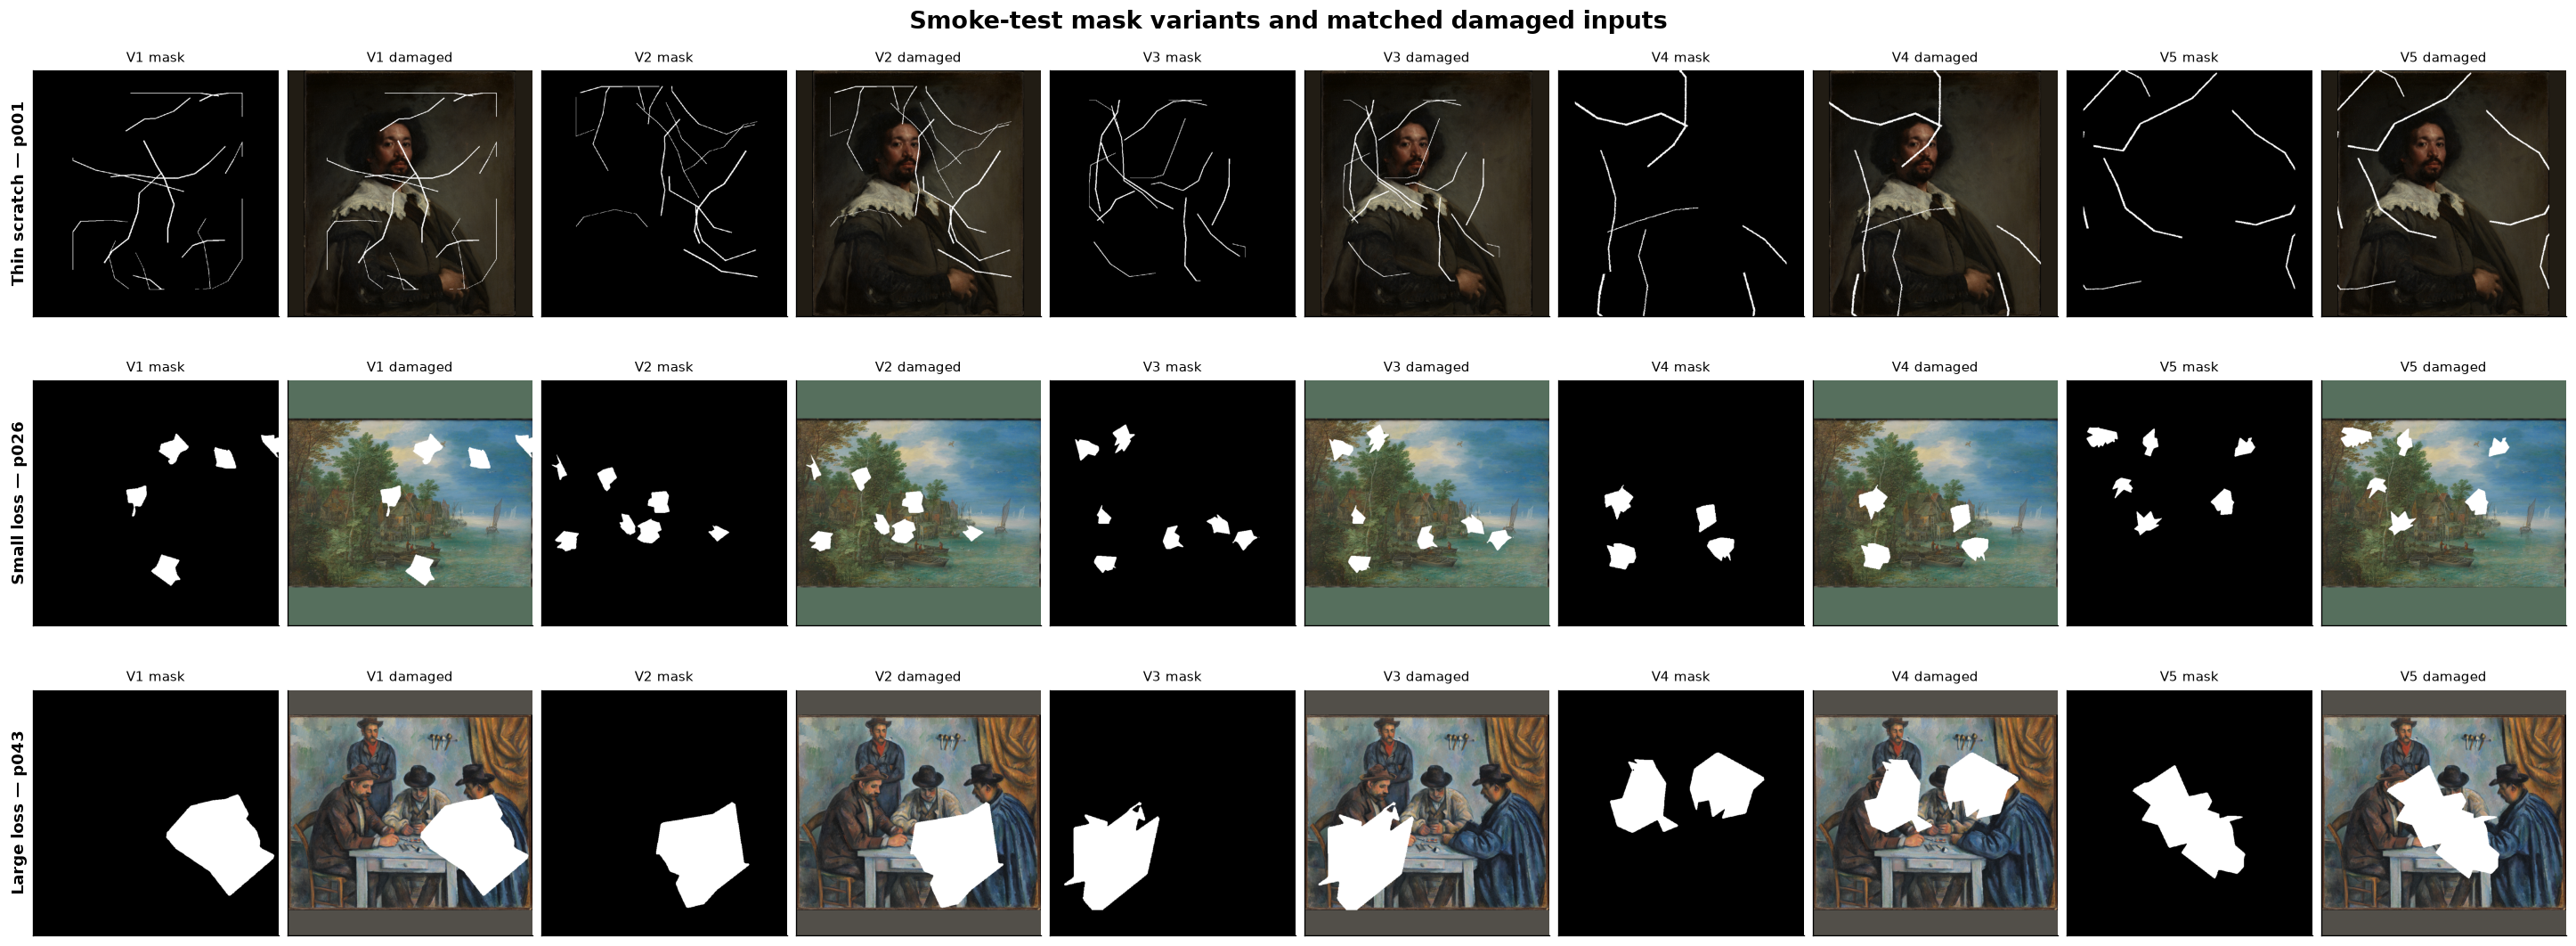

Rendered 15 masks and 15 corresponding damaged inputs.


In [12]:
def repository_image(relative_path: str) -> Image.Image:
    """Load a repository-relative image without modifying it."""
    image_path = PROJECT_ROOT / str(relative_path)

    with Image.open(image_path) as image:
        return image.convert("RGB").copy()


def repository_mask(relative_path: str) -> Image.Image:
    """Load a repository-relative mask for display."""
    mask_path = PROJECT_ROOT / str(relative_path)

    with Image.open(mask_path) as image:
        return image.convert("L").copy()


family_display_order = [
    "scratch_thin",
    "loss_small",
    "loss_large",
]

family_labels = {
    "scratch_thin": "Thin scratch — p001",
    "loss_small": "Small loss — p026",
    "loss_large": "Large loss — p043",
}

fig, axes = plt.subplots(
    nrows=3,
    ncols=10,
    figsize=(24, 9),
    constrained_layout=True,
)

for row_index, mask_family in enumerate(
    family_display_order
):
    family_cases = (
        SMOKE_CASES.loc[
            SMOKE_CASES["mask_type"]
            .astype(str)
            .eq(mask_family)
        ]
        .sort_values("variant_index")
        .reset_index(drop=True)
    )

    for variant_position, case in enumerate(
        family_cases.itertuples(index=False)
    ):
        mask_axis = axes[
            row_index,
            2 * variant_position,
        ]
        damaged_axis = axes[
            row_index,
            2 * variant_position + 1,
        ]

        mask_axis.imshow(
            repository_mask(case.mask_path),
            cmap="gray",
            vmin=0,
            vmax=255,
        )
        damaged_axis.imshow(
            repository_image(case.damaged_image_path)
        )

        mask_axis.set_title(
            f"V{int(case.variant_index)} mask",
            fontsize=9,
        )
        damaged_axis.set_title(
            f"V{int(case.variant_index)} damaged",
            fontsize=9,
        )

        if variant_position == 0:
            mask_axis.set_ylabel(
                family_labels[mask_family],
                fontsize=11,
                fontweight="bold",
            )

        mask_axis.set_xticks([])
        mask_axis.set_yticks([])
        damaged_axis.set_xticks([])
        damaged_axis.set_yticks([])

fig.suptitle(
    "Smoke-test mask variants and matched damaged inputs",
    fontsize=16,
    fontweight="bold",
)

display(fig)
plt.close(fig)

print("Rendered 15 masks and 15 corresponding damaged inputs.")

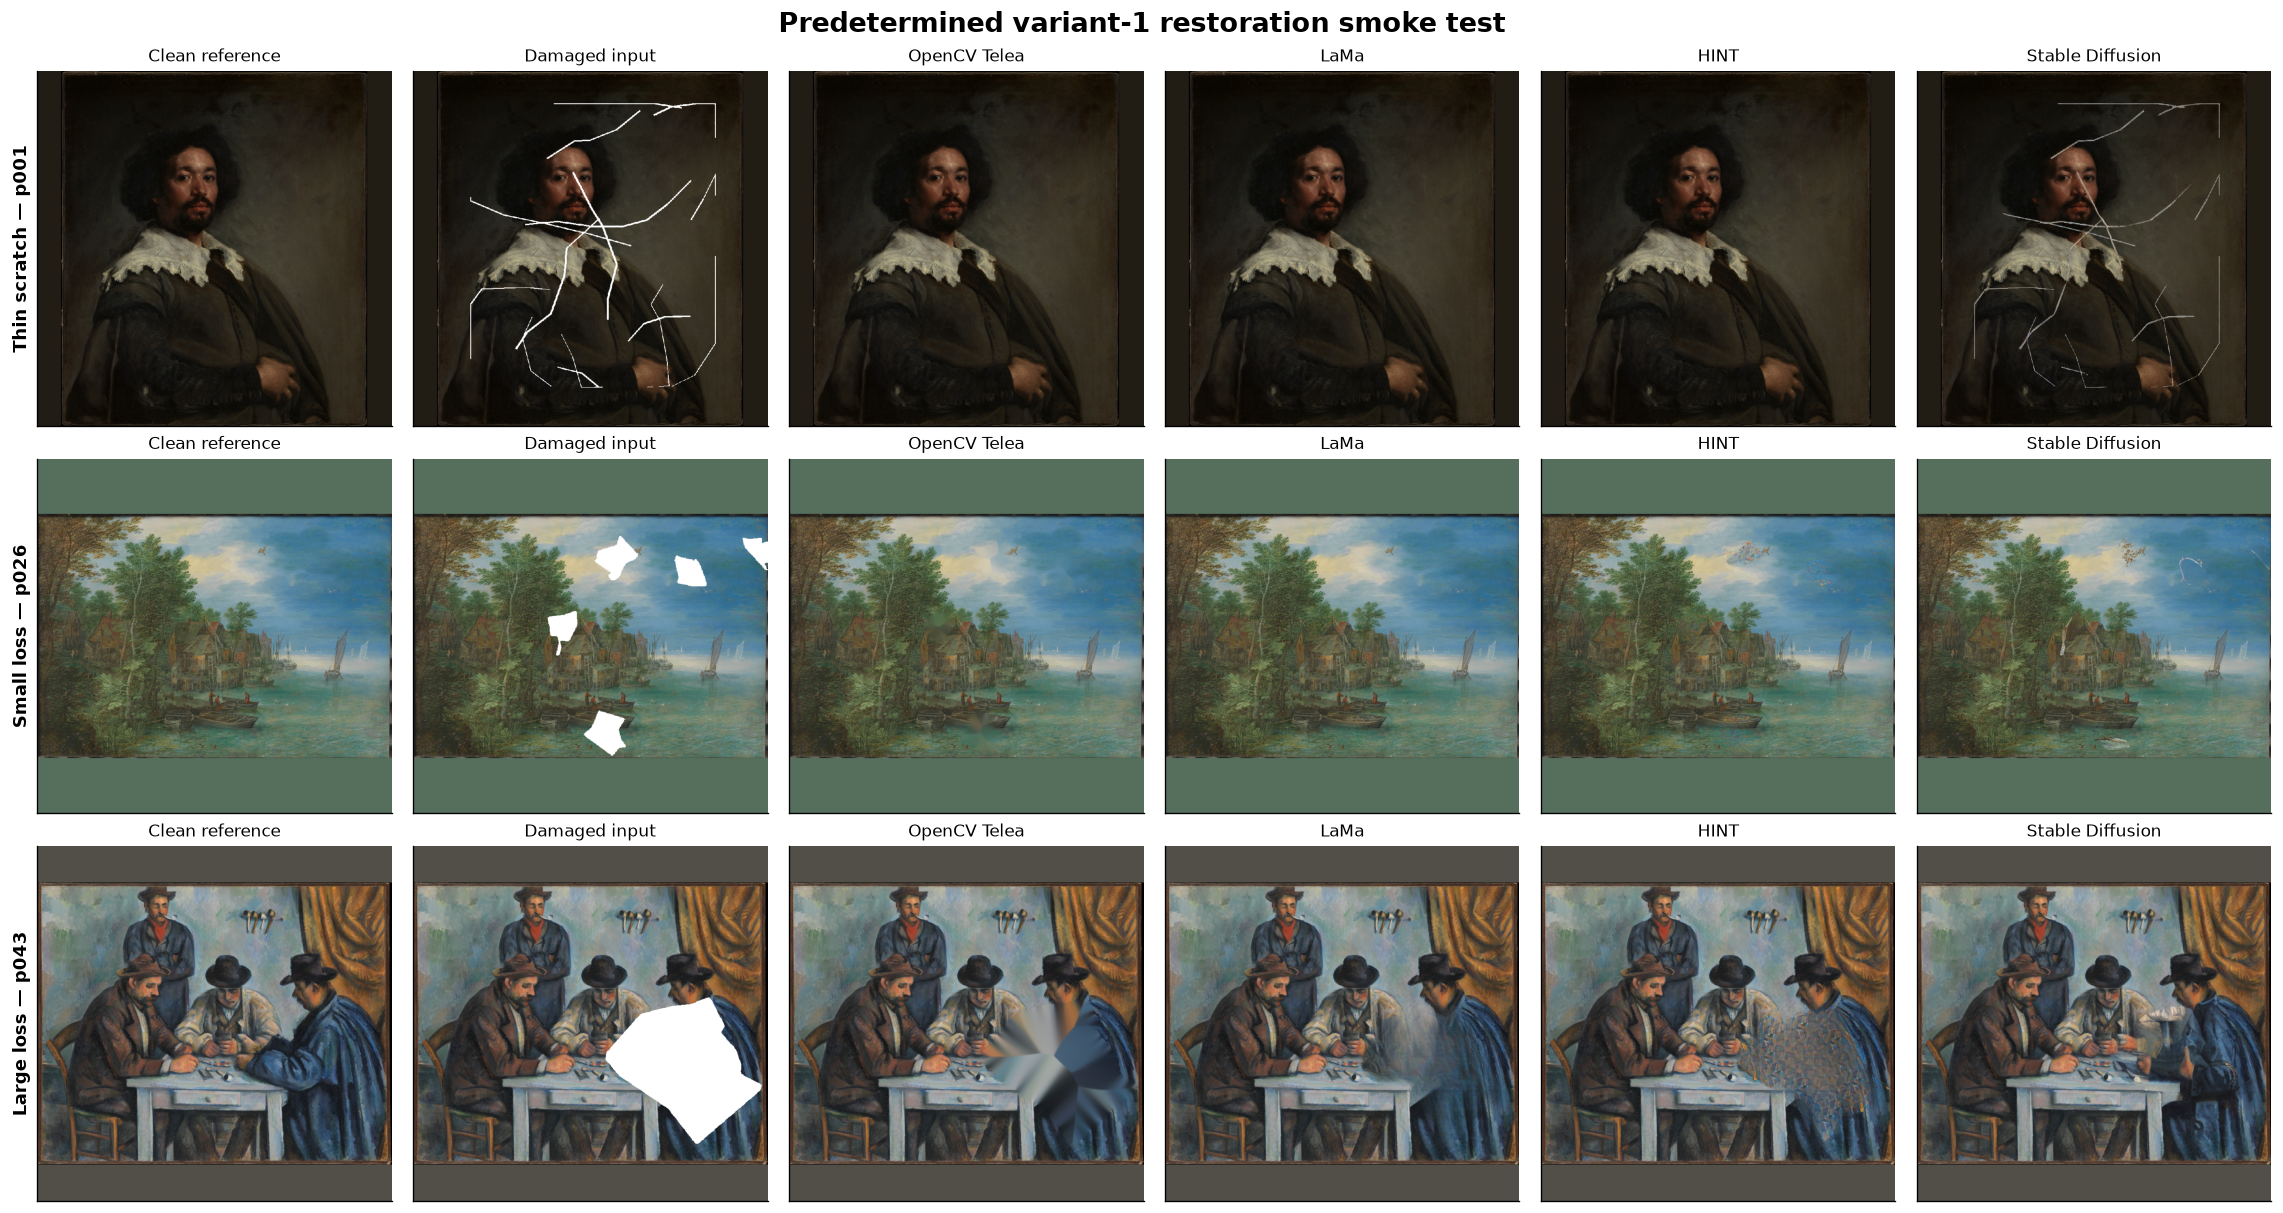

Rendered clean, damaged, and four-method comparisons for all mask families.


In [13]:
MODEL_DISPLAY = {
    "opencv_telea": "OpenCV Telea",
    "lama": "LaMa",
    "hint_places2": "HINT",
    "stable_diffusion_inpainting": "Stable Diffusion",
}

fig, axes = plt.subplots(
    nrows=3,
    ncols=6,
    figsize=(19, 10),
    constrained_layout=True,
)

for row_index, mask_family in enumerate(
    family_display_order
):
    representative_case = (
        SMOKE_CASES.loc[
            SMOKE_CASES["mask_type"]
            .astype(str)
            .eq(mask_family)
        ]
        .sort_values("variant_index")
        .iloc[0]
    )

    representative_candidates = (
        SMOKE_CANDIDATES.loc[
            SMOKE_CANDIDATES["case_id"]
            .astype(str)
            .eq(str(representative_case["case_id"]))
        ]
        .set_index("model_id")
    )

    panel_images = [
        (
            "Clean reference",
            repository_image(
                representative_case["clean_image_path"]
            ),
        ),
        (
            "Damaged input",
            repository_image(
                representative_case["damaged_image_path"]
            ),
        ),
    ]

    for model_id in POPULATION["model_order"]:
        panel_images.append(
            (
                MODEL_DISPLAY[model_id],
                repository_image(
                    representative_candidates.loc[
                        model_id,
                        "restored_path",
                    ]
                ),
            )
        )

    for column_index, (title, image) in enumerate(
        panel_images
    ):
        axis = axes[row_index, column_index]
        axis.imshow(image)
        axis.set_title(title, fontsize=10)
        axis.set_xticks([])
        axis.set_yticks([])

        if column_index == 0:
            axis.set_ylabel(
                family_labels[mask_family],
                fontsize=11,
                fontweight="bold",
            )

fig.suptitle(
    "Predetermined variant-1 restoration smoke test",
    fontsize=16,
    fontweight="bold",
)

display(fig)
plt.close(fig)

print(
    "Rendered clean, damaged, and four-method comparisons "
    "for all mask families."
)

In [14]:
# Remove any earlier Batch 3 checks so this cell can be rerun safely.
preserved_checks = tuple(
    check
    for check in VALIDATION.checks
    if check.validation_stage != "batch_3_smoke_test"
)

VALIDATION = ValidationCollector()
VALIDATION.extend(preserved_checks)

# The smoke population contains 15 cases × 4 methods = 60 candidates.
expected_smoke_source_rows = {
    "classical": 1800,
    "perceptual": 120,
    "feature": 240,
    "spatial": 540,
    "local_consistency": 7860,
    "semantic_structural": 1680,
}

expected_smoke_normalized_rows = {
    "classical": 1800,
    "perceptual": 120,
    "feature": 240,
    "spatial": 7560,
    "local_consistency": 7860,
    "semantic_structural": 1680,
}

observed_smoke_source_rows = {
    row.source_key: int(row.source_rows)
    for row in SMOKE_SOURCE_COUNTS.itertuples(index=False)
}

observed_smoke_normalized_rows = {
    row.source_key: int(row.normalized_rows)
    for row in SMOKE_SOURCE_COUNTS.itertuples(index=False)
}

smoke_values = pd.to_numeric(
    SMOKE_ANCHOR_VALUES["comparison_value"],
    errors="coerce",
)

smoke_group_gate_passed = bool(
    as_boolean(
        SMOKE_AUDIT["group_gate_passed"]
    ).all()
)

smoke_distinctness_passed = bool(
    as_boolean(
        SMOKE_AUDIT["group_unique_mask_count_passed"]
    ).all()
    and as_boolean(
        SMOKE_AUDIT["pairwise_iou_passed"]
    ).all()
    and as_boolean(
        SMOKE_AUDIT["location_variation_passed"]
    ).all()
    and as_boolean(
        SMOKE_AUDIT["morphology_variation_passed"]
    ).all()
    and as_boolean(
        SMOKE_AUDIT[
            "component_arrangement_variation_passed"
        ]
    ).all()
)

batch_3_validation_specs = [
    {
        "check_id": "predetermined_smoke_group_count",
        "check_description": (
            "The smoke population contains three predetermined groups."
        ),
        "expected": {
            "groups": 3,
            "cases": 15,
            "candidates": 60,
        },
        "observed": {
            "groups": SMOKE_CASES[
                "robustness_group_id"
            ].nunique(),
            "cases": SMOKE_CASES["case_id"].nunique(),
            "candidates": SMOKE_CANDIDATES[
                "candidate_id"
            ].nunique(),
        },
        "passed": (
            SMOKE_CASES[
                "robustness_group_id"
            ].nunique()
            == 3
            and SMOKE_CASES["case_id"].nunique() == 15
            and SMOKE_CANDIDATES[
                "candidate_id"
            ].nunique()
            == 60
        ),
    },
    {
        "check_id": "smoke_four_method_coverage",
        "check_description": (
            "Every smoke case has one candidate from each full method."
        ),
        "expected": {
            "models": list(POPULATION["model_order"]),
            "candidates_per_model": 15,
        },
        "observed": {
            "models": sorted(
                SMOKE_CANDIDATES[
                    "model_id"
                ].astype(str).unique()
            ),
            "candidates_by_model": (
                SMOKE_CANDIDATES.groupby(
                    "model_id"
                ).size().to_dict()
            ),
        },
        "passed": (
            set(
                SMOKE_CANDIDATES[
                    "model_id"
                ].astype(str)
            )
            == set(POPULATION["model_order"])
            and SMOKE_CANDIDATES.groupby(
                "model_id"
            ).size().eq(15).all()
        ),
    },
    {
        "check_id": "smoke_five_variants_per_group",
        "check_description": (
            "Every smoke group contains all five variants."
        ),
        "expected": 5,
        "observed": (
            SMOKE_CASES.groupby(
                "robustness_group_id"
            )["variant_id"]
            .nunique()
            .to_dict()
        ),
        "passed": bool(
            SMOKE_CASES.groupby(
                "robustness_group_id"
            )["variant_id"]
            .nunique()
            .eq(5)
            .all()
        ),
    },
    {
        "check_id": "smoke_group_generation_gates",
        "check_description": (
            "Every selected group passed Notebook 06 generation gates."
        ),
        "expected": True,
        "observed": smoke_group_gate_passed,
        "passed": smoke_group_gate_passed,
    },
    {
        "check_id": "smoke_geometric_distinctness",
        "check_description": (
            "Selected groups passed location, overlap, morphology, "
            "and arrangement distinctness gates."
        ),
        "expected": True,
        "observed": smoke_distinctness_passed,
        "passed": smoke_distinctness_passed,
    },
    {
        "check_id": "smoke_raw_source_counts",
        "check_description": (
            "Every raw metric adapter receives its expected smoke rows."
        ),
        "expected": expected_smoke_source_rows,
        "observed": observed_smoke_source_rows,
        "passed": (
            observed_smoke_source_rows
            == expected_smoke_source_rows
        ),
    },
    {
        "check_id": "smoke_normalized_source_counts",
        "check_description": (
            "Every metric adapter returns its expected normalized rows."
        ),
        "expected": expected_smoke_normalized_rows,
        "observed": observed_smoke_normalized_rows,
        "passed": (
            observed_smoke_normalized_rows
            == expected_smoke_normalized_rows
        ),
    },
    {
        "check_id": "smoke_normalized_total",
        "check_description": (
            "The combined smoke table has the expected total."
        ),
        "expected": 19260,
        "observed": len(SMOKE_NORMALIZED_QUALITY),
        "passed": len(SMOKE_NORMALIZED_QUALITY) == 19260,
    },
    {
        "check_id": "smoke_anchor_coverage",
        "check_description": (
            "All eleven anchors exist for every smoke candidate."
        ),
        "expected": {
            "rows": 660,
            "anchors": 11,
            "rows_per_candidate": 11,
        },
        "observed": {
            "rows": len(SMOKE_ANCHOR_VALUES),
            "anchors": SMOKE_ANCHOR_VALUES[
                "anchor_id"
            ].nunique(),
            "minimum_rows_per_candidate": int(
                SMOKE_ANCHOR_VALUES.groupby(
                    "candidate_id"
                ).size().min()
            ),
            "maximum_rows_per_candidate": int(
                SMOKE_ANCHOR_VALUES.groupby(
                    "candidate_id"
                ).size().max()
            ),
        },
        "passed": (
            len(SMOKE_ANCHOR_VALUES) == 660
            and SMOKE_ANCHOR_VALUES[
                "anchor_id"
            ].nunique()
            == 11
            and SMOKE_ANCHOR_VALUES.groupby(
                "candidate_id"
            ).size().eq(11).all()
        ),
    },
    {
        "check_id": "smoke_anchor_values_finite",
        "check_description": (
            "Every representative anchor value is finite."
        ),
        "expected": 660,
        "observed": int(
            np.isfinite(smoke_values).sum()
        ),
        "passed": bool(
            np.isfinite(smoke_values).all()
        ),
    },
    {
        "check_id": "smoke_anchor_keys_unique",
        "check_description": (
            "Candidate and anchor keys are unique in the smoke result."
        ),
        "expected": 0,
        "observed": int(
            SMOKE_ANCHOR_VALUES.duplicated(
                ["candidate_id", "anchor_id"]
            ).sum()
        ),
        "passed": not SMOKE_ANCHOR_VALUES.duplicated(
            ["candidate_id", "anchor_id"]
        ).any(),
    },
    {
        "check_id": "smoke_figures_rendered_in_memory",
        "check_description": (
            "Both required smoke-test visual roles rendered."
        ),
        "expected": {
            "design_tiles": 30,
            "restoration_tiles": 18,
        },
        "observed": {
            "design_tiles": 30,
            "restoration_tiles": 18,
        },
        "passed": True,
    },
]

for specification in batch_3_validation_specs:
    VALIDATION.add(
        validation_stage="batch_3_smoke_test",
        severity="blocking",
        **specification,
    )

BATCH_3_CHECKS = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame["validation_stage"]
        == "batch_3_smoke_test"
    ]
    .reset_index(drop=True)
)

BATCH_3_SUMMARY = VALIDATION.summary()

display(BATCH_3_CHECKS)

VALIDATION.raise_for_blocking()

print("Batch 3 passed.")
print("Smoke groups: 3")
print(f"Smoke cases: {len(SMOKE_CASES):,}")
print(f"Smoke candidates: {len(SMOKE_CANDIDATES):,}")
print(
    "Smoke normalized rows: "
    f"{len(SMOKE_NORMALIZED_QUALITY):,}"
)
print(
    "Smoke anchor rows: "
    f"{len(SMOKE_ANCHOR_VALUES):,}"
)
print(
    "Blocking failures so far: "
    f"{BATCH_3_SUMMARY['blocking_failure_count']}"
)
print("Next batch: full evidence normalization.")

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_3_smoke_test,predetermined_smoke_group_count,The smoke population contains three predetermined groups.,blocking,"{""candidates"": 60, ""cases"": 15, ""groups"": 3}","{""candidates"": 60, ""cases"": 15, ""groups"": 3}",True,
1,batch_3_smoke_test,smoke_four_method_coverage,Every smoke case has one candidate from each full method.,blocking,"{""candidates_per_model"": 15, ""models"": [""opencv_telea"", ""lama"", ""hint_places2"", ""stable_diffusion_inpainting""]}","{""candidates_by_model"": {""hint_places2"": 15, ""lama"": 15, ""opencv_telea"": 15, ""stable_diffusion_inpainting"": 15}, ""models"": [""hint_places...",True,
2,batch_3_smoke_test,smoke_five_variants_per_group,Every smoke group contains all five variants.,blocking,5,"{""robustness__p001__scratch_thin__target_02pct"": 5, ""robustness__p026__loss_small__target_04p5pct"": 5, ""robustness__p043__loss_large__ta...",True,
3,batch_3_smoke_test,smoke_group_generation_gates,Every selected group passed Notebook 06 generation gates.,blocking,True,True,True,
4,batch_3_smoke_test,smoke_geometric_distinctness,"Selected groups passed location, overlap, morphology, and arrangement distinctness gates.",blocking,True,True,True,
5,batch_3_smoke_test,smoke_raw_source_counts,Every raw metric adapter receives its expected smoke rows.,blocking,"{""classical"": 1800, ""feature"": 240, ""local_consistency"": 7860, ""perceptual"": 120, ""semantic_structural"": 1680, ""spatial"": 540}","{""classical"": 1800, ""feature"": 240, ""local_consistency"": 7860, ""perceptual"": 120, ""semantic_structural"": 1680, ""spatial"": 540}",True,
6,batch_3_smoke_test,smoke_normalized_source_counts,Every metric adapter returns its expected normalized rows.,blocking,"{""classical"": 1800, ""feature"": 240, ""local_consistency"": 7860, ""perceptual"": 120, ""semantic_structural"": 1680, ""spatial"": 7560}","{""classical"": 1800, ""feature"": 240, ""local_consistency"": 7860, ""perceptual"": 120, ""semantic_structural"": 1680, ""spatial"": 7560}",True,
7,batch_3_smoke_test,smoke_normalized_total,The combined smoke table has the expected total.,blocking,19260,19260,True,
8,batch_3_smoke_test,smoke_anchor_coverage,All eleven anchors exist for every smoke candidate.,blocking,"{""anchors"": 11, ""rows"": 660, ""rows_per_candidate"": 11}","{""anchors"": 11, ""maximum_rows_per_candidate"": 11, ""minimum_rows_per_candidate"": 11, ""rows"": 660}",True,
9,batch_3_smoke_test,smoke_anchor_values_finite,Every representative anchor value is finite.,blocking,660,660,True,


Batch 3 passed.
Smoke groups: 3
Smoke cases: 15
Smoke candidates: 60
Smoke normalized rows: 19,260
Smoke anchor rows: 660
Blocking failures so far: 0
Next batch: full evidence normalization.


## Batch 4 — Full evidence normalization

This batch normalizes all approved evidence for the complete 2,100-candidate population.

It:

- converts six upstream metric tables into one common long-form evidence table;
- attaches authoritative Notebook 06 group, variant, and morphology fields;
- selects exactly 11 approved quality anchors per candidate;
- normalizes runtime separately as operational evidence;
- verifies row IDs, four-method coverage, group coverage, finite anchor values, and comparison directions.

No metric is recomputed from images. No canonical output is written.

In [15]:
CASE_ANALYSIS_METADATA = (
    MASK_ROBUSTNESS_CASES[
        [
            "case_id",
            "robustness_group_id",
            "variant_id",
            "variant_index",
            "mask_type",
            "family_index",
            "target_token",
            "centroid_x_normalized_content",
            "centroid_y_normalized_content",
            "centroid_quadrant",
            "bbox_fill_ratio",
            "bbox_aspect_ratio",
            "connected_component_count",
            "largest_component_fraction",
            "component_area_cv",
            "mask_compactness",
            "touches_content_boundary",
            "minimum_distance_to_content_boundary_pixels",
        ]
    ]
    .rename(columns={"mask_type": "mask_family"})
    .drop_duplicates("case_id")
    .reset_index(drop=True)
)

if len(CASE_ANALYSIS_METADATA) != int(
    EXPECTED["cases"]
):
    raise ValueError(
        "Authoritative case metadata does not match the configured case count."
    )

NORMALIZED_QUALITY_BASE = normalise_quality_evidence(
    QUALITY_SOURCE_TABLES,
    SELECTED_CANDIDATES,
    config=ANALYSIS_CONFIG,
)

NORMALIZED_QUALITY = NORMALIZED_QUALITY_BASE.merge(
    CASE_ANALYSIS_METADATA,
    on="case_id",
    how="left",
    validate="many_to_one",
)

normalized_source_summary = (
    NORMALIZED_QUALITY.groupby(
        [
            "source_notebook_id",
            "source_key",
            "evidence_family",
        ],
        dropna=False,
    )
    .agg(
        rows=("source_metric_row_id", "size"),
        candidates=("candidate_id", "nunique"),
        cases=("case_id", "nunique"),
        models=("model_id", "nunique"),
        groups=("robustness_group_id", "nunique"),
        finite_values=(
            "comparison_value",
            lambda values: int(
                np.isfinite(
                    pd.to_numeric(
                        values,
                        errors="coerce",
                    )
                ).sum()
            ),
        ),
        analysis_eligible_rows=(
            "analysis_eligible",
            lambda values: int(
                as_boolean(values).sum()
            ),
        ),
    )
    .reset_index()
    .sort_values(
        [
            "source_notebook_id",
            "source_key",
            "evidence_family",
        ],
        kind="stable",
    )
)

normalized_notebook_counts = (
    NORMALIZED_QUALITY.groupby(
        "source_notebook_id"
    )
    .size()
    .rename("normalized_rows")
    .reset_index()
)

display(normalized_notebook_counts)
display(normalized_source_summary)

print("Full metric evidence normalized.")
print(
    "Normalized rows: "
    f"{len(NORMALIZED_QUALITY):,}"
)
print(
    "Candidates covered: "
    f"{NORMALIZED_QUALITY['candidate_id'].nunique():,}"
)
print(
    "Cases covered: "
    f"{NORMALIZED_QUALITY['case_id'].nunique():,}"
)
print(
    "Robustness groups covered: "
    f"{NORMALIZED_QUALITY['robustness_group_id'].nunique():,}"
)

,source_notebook_id,normalized_rows
0,13,63000
1,14,4200
2,15,8400
3,16,264600
4,17,275100
5,20,58800


,source_notebook_id,source_key,evidence_family,rows,candidates,cases,models,groups,finite_values,analysis_eligible_rows
0,13,classical,classical_pixel,56700,2100,525,4,105,50400,50400
1,13,classical,ssim,6300,2100,525,4,105,6300,6300
2,14,perceptual,perceptual,4200,2100,525,4,105,4200,4200
3,15,feature,feature_similarity,8400,2100,525,4,105,8400,8400
4,16,spatial,spatial_diagnostics,264600,2100,525,4,105,264600,170100
5,17,local_consistency,colour,170100,2100,525,4,105,168480,164640
6,17,local_consistency,seam,37800,2100,525,4,105,37800,37800
7,17,local_consistency,texture_descriptor,16800,2100,525,4,105,16800,16800
8,17,local_consistency,texture_map,50400,2100,525,4,105,50400,50400
9,20,semantic_structural,encoder_agreement,4200,2100,525,4,105,4200,4200


Full metric evidence normalized.
Normalized rows: 674,100
Candidates covered: 2,100
Cases covered: 525
Robustness groups covered: 105


In [16]:
QUALITY_ANCHOR_VALUES = select_quality_anchor_values(
    NORMALIZED_QUALITY,
    config=ANALYSIS_CONFIG,
)

RUNTIME_EVIDENCE_BASE = build_runtime_evidence(
    SELECTED_CANDIDATES,
    config=ANALYSIS_CONFIG,
)

RUNTIME_EVIDENCE = RUNTIME_EVIDENCE_BASE.merge(
    CASE_ANALYSIS_METADATA,
    on="case_id",
    how="left",
    validate="many_to_one",
)

anchor_values_numeric = pd.to_numeric(
    QUALITY_ANCHOR_VALUES["comparison_value"],
    errors="coerce",
)

ANCHOR_COVERAGE = (
    QUALITY_ANCHOR_VALUES.groupby(
        [
            "anchor_id",
            "evidence_family",
            "metric_name",
            "feature_model_id",
            "region_id",
            "comparison_direction",
        ],
        dropna=False,
    )
    .agg(
        rows=("candidate_id", "size"),
        candidates=("candidate_id", "nunique"),
        cases=("case_id", "nunique"),
        paintings=("painting_id", "nunique"),
        models=("model_id", "nunique"),
        groups=("robustness_group_id", "nunique"),
        finite_values=(
            "comparison_value",
            lambda values: int(
                np.isfinite(
                    pd.to_numeric(
                        values,
                        errors="coerce",
                    )
                ).sum()
            ),
        ),
    )
    .reset_index()
    .sort_values("anchor_id", kind="stable")
)

ANCHOR_MODEL_COVERAGE = (
    QUALITY_ANCHOR_VALUES.groupby(
        ["anchor_id", "model_id"],
        dropna=False,
    )
    .agg(
        rows=("candidate_id", "size"),
        cases=("case_id", "nunique"),
        groups=("robustness_group_id", "nunique"),
        paintings=("painting_id", "nunique"),
    )
    .reset_index()
    .sort_values(
        ["anchor_id", "model_id"],
        kind="stable",
    )
)

RUNTIME_SUMMARY = (
    RUNTIME_EVIDENCE.groupby(
        "model_id",
        dropna=False,
    )
    .agg(
        rows=("candidate_id", "size"),
        cases=("case_id", "nunique"),
        groups=("robustness_group_id", "nunique"),
        runtime_median_seconds=(
            "comparison_value",
            "median",
        ),
        runtime_mad_seconds=(
            "comparison_value",
            lambda values: float(
                np.median(
                    np.abs(
                        pd.to_numeric(
                            values,
                            errors="coerce",
                        )
                        - np.median(
                            pd.to_numeric(
                                values,
                                errors="coerce",
                            )
                        )
                    )
                )
            ),
        ),
        runtime_min_seconds=(
            "comparison_value",
            "min",
        ),
        runtime_max_seconds=(
            "comparison_value",
            "max",
        ),
    )
    .reset_index()
)

display(ANCHOR_COVERAGE)
display(ANCHOR_MODEL_COVERAGE)
display(RUNTIME_SUMMARY)

print("Approved anchor and runtime evidence prepared.")
print(
    "Quality-anchor rows: "
    f"{len(QUALITY_ANCHOR_VALUES):,}"
)
print(
    "Distinct anchors: "
    f"{QUALITY_ANCHOR_VALUES['anchor_id'].nunique():,}"
)
print(
    "Finite anchor values: "
    f"{int(np.isfinite(anchor_values_numeric).sum()):,}/"
    f"{len(QUALITY_ANCHOR_VALUES):,}"
)
print(f"Runtime rows: {len(RUNTIME_EVIDENCE):,}")

,anchor_id,evidence_family,metric_name,feature_model_id,region_id,comparison_direction,rows,candidates,cases,paintings,models,groups,finite_values
0,classical_masked_mae,classical_pixel,mae,,masked_region,lower_is_better,2100,2100,525,35,4,105,2100
1,colour_masked_delta_e,colour,delta_e_ciede2000_mean,,masked_region,lower_is_better,2100,2100,525,35,4,105,2100
2,feature_clip_crop,feature_similarity,clip_cosine_similarity,clip_vit_b32,mask_bbox_crop,higher_is_better,2100,2100,525,35,4,105,2100
3,feature_dino_crop,feature_similarity,dinov2_cosine_similarity,dinov2_vits14,mask_bbox_crop,higher_is_better,2100,2100,525,35,4,105,2100
4,perceptual_crop_lpips,perceptual,lpips,,mask_bbox_crop,lower_is_better,2100,2100,525,35,4,105,2100
5,seam_boundary_gradient,seam,boundary_gradient_mismatch,,boundary_ring,lower_is_better,2100,2100,525,35,4,105,2100
6,semantic_local_dino,local_semantic_preservation,local_patch_cosine_similarity,dinov2_vits14,mask_bbox_crop,higher_is_better,2100,2100,525,35,4,105,2100
7,spatial_masked_error,spatial_diagnostics,restored_error_mean,,masked_region,lower_is_better,2100,2100,525,35,4,105,2100
8,structural_affinity_correlation,structural_layout,reference_affinity_map_correlation,dinov2_vits14,content_region,higher_is_better,2100,2100,525,35,4,105,2100
9,structural_crop_ssim,ssim,ssim,,mask_bbox_crop,higher_is_better,2100,2100,525,35,4,105,2100


,anchor_id,model_id,rows,cases,groups,paintings
0,classical_masked_mae,hint_places2,525,525,105,35
1,classical_masked_mae,lama,525,525,105,35
2,classical_masked_mae,opencv_telea,525,525,105,35
3,classical_masked_mae,stable_diffusion_inpainting,525,525,105,35
4,colour_masked_delta_e,hint_places2,525,525,105,35
5,colour_masked_delta_e,lama,525,525,105,35
6,colour_masked_delta_e,opencv_telea,525,525,105,35
7,colour_masked_delta_e,stable_diffusion_inpainting,525,525,105,35
8,feature_clip_crop,hint_places2,525,525,105,35
9,feature_clip_crop,lama,525,525,105,35


,model_id,rows,cases,groups,runtime_median_seconds,runtime_mad_seconds,runtime_min_seconds,runtime_max_seconds
0,hint_places2,525,525,105,6.758000,0.210000,6.191000,9.605000
1,lama,525,525,105,1.498939,0.000000,1.498939,1.498939
2,opencv_telea,525,525,105,0.499780,0.095575,0.256862,1.319532
3,stable_diffusion_inpainting,525,525,105,8.228142,0.222419,7.555216,9.067234


Approved anchor and runtime evidence prepared.
Quality-anchor rows: 23,100
Distinct anchors: 11
Finite anchor values: 23,100/23,100
Runtime rows: 2,100


In [17]:
# Remove earlier Batch 4 checks so this cell can be rerun safely.
preserved_checks = tuple(
    check
    for check in VALIDATION.checks
    if check.validation_stage != "batch_4_full_normalization"
)

VALIDATION = ValidationCollector()
VALIDATION.extend(preserved_checks)

expected_normalized_notebook_counts = {
    "13": int(
        EXPECTED["selected_classical_source_rows"]
    ),
    "14": int(
        EXPECTED["selected_lpips_source_rows"]
    ),
    "15": int(
        EXPECTED["selected_feature_source_rows"]
    ),
    "16": int(
        EXPECTED["normalized_spatial_rows"]
    ),
    "17": int(
        EXPECTED["selected_local_source_rows"]
    ),
    "20": int(
        EXPECTED["selected_semantic_source_rows"]
    ),
}

observed_normalized_notebook_counts = {
    str(notebook_id): int(count)
    for notebook_id, count in (
        NORMALIZED_QUALITY.groupby(
            "source_notebook_id"
        ).size().items()
    )
}

candidate_anchor_counts = (
    QUALITY_ANCHOR_VALUES.groupby(
        "candidate_id"
    ).size()
)

model_anchor_counts = (
    QUALITY_ANCHOR_VALUES.groupby(
        "model_id"
    ).size()
)

expected_model_anchor_counts = {
    model_id: (
        int(EXPECTED["candidates_by_model"][model_id])
        * int(EXPECTED["quality_anchors"])
    )
    for model_id in POPULATION["model_order"]
}

normalized_metadata_complete = bool(
    NORMALIZED_QUALITY[
        [
            "robustness_group_id",
            "variant_id",
            "variant_index",
            "mask_family",
        ]
    ].notna().all().all()
)

normalized_source_ids_unique = not (
    NORMALIZED_QUALITY.duplicated(
        [
            "source_notebook_id",
            "source_metric_row_id",
        ]
    ).any()
)

anchor_directions_valid = set(
    QUALITY_ANCHOR_VALUES[
        "comparison_direction"
    ].astype(str)
).issubset(
    {"higher_is_better", "lower_is_better"}
)

runtime_values = pd.to_numeric(
    RUNTIME_EVIDENCE["comparison_value"],
    errors="coerce",
)

comparison_rows_valid = bool(
    MASK_COMPARISON_CROSSCHECK["status"]
    .astype(str)
    .eq("ok")
    .all()
)

observed_population = {
    "candidates": int(
        NORMALIZED_QUALITY["candidate_id"].nunique()
    ),
    "cases": int(
        NORMALIZED_QUALITY["case_id"].nunique()
    ),
    "paintings": int(
        NORMALIZED_QUALITY["painting_id"].nunique()
    ),
    "models": int(
        NORMALIZED_QUALITY["model_id"].nunique()
    ),
    "groups": int(
        NORMALIZED_QUALITY[
            "robustness_group_id"
        ].nunique()
    ),
}

expected_population = {
    "candidates": int(EXPECTED["candidates"]),
    "cases": int(EXPECTED["cases"]),
    "paintings": int(EXPECTED["paintings"]),
    "models": len(POPULATION["model_order"]),
    "groups": int(EXPECTED["robustness_groups"]),
}

VALIDATION.add(
    validation_stage="batch_4_full_normalization",
    check_id="normalized_quality_row_count",
    check_description=(
        "Full normalization produces exactly 674,100 rows."
    ),
    severity="blocking",
    expected=EXPECTED["normalized_quality_rows"],
    observed=len(NORMALIZED_QUALITY),
    passed=(
        len(NORMALIZED_QUALITY)
        == int(EXPECTED["normalized_quality_rows"])
    ),
)

VALIDATION.add(
    validation_stage="batch_4_full_normalization",
    check_id="normalized_source_row_counts",
    check_description=(
        "Every source notebook contributes its expected rows."
    ),
    severity="blocking",
    expected=expected_normalized_notebook_counts,
    observed=observed_normalized_notebook_counts,
    passed=(
        observed_normalized_notebook_counts
        == expected_normalized_notebook_counts
    ),
)

VALIDATION.add(
    validation_stage="batch_4_full_normalization",
    check_id="normalized_source_ids_unique",
    check_description=(
        "Source notebook and metric-row identifiers are unique."
    ),
    severity="blocking",
    expected=True,
    observed=normalized_source_ids_unique,
    passed=normalized_source_ids_unique,
)

VALIDATION.add(
    validation_stage="batch_4_full_normalization",
    check_id="normalized_population_coverage",
    check_description=(
        "Normalized evidence covers every candidate, case, "
        "painting, method, and robustness group."
    ),
    severity="blocking",
    expected=expected_population,
    observed=observed_population,
    passed=observed_population == expected_population,
)

VALIDATION.add(
    validation_stage="batch_4_full_normalization",
    check_id="normalized_model_identity",
    check_description=(
        "Normalized evidence contains exactly the four full methods."
    ),
    severity="blocking",
    expected=list(POPULATION["model_order"]),
    observed=sorted(
        NORMALIZED_QUALITY[
            "model_id"
        ].astype(str).unique()
    ),
    passed=(
        set(
            NORMALIZED_QUALITY[
                "model_id"
            ].astype(str)
        )
        == set(POPULATION["model_order"])
    ),
)

VALIDATION.add(
    validation_stage="batch_4_full_normalization",
    check_id="authoritative_case_metadata_attached",
    check_description=(
        "Every normalized row has group, family, and variant metadata."
    ),
    severity="blocking",
    expected=True,
    observed=normalized_metadata_complete,
    passed=normalized_metadata_complete,
)

VALIDATION.add(
    validation_stage="batch_4_full_normalization",
    check_id="quality_anchor_row_count",
    check_description=(
        "Every candidate contributes all 11 approved anchors."
    ),
    severity="blocking",
    expected=EXPECTED["variant_quality_rows"],
    observed={
        "rows": len(QUALITY_ANCHOR_VALUES),
        "anchors": QUALITY_ANCHOR_VALUES[
            "anchor_id"
        ].nunique(),
    },
    passed=(
        len(QUALITY_ANCHOR_VALUES)
        == int(EXPECTED["variant_quality_rows"])
        and QUALITY_ANCHOR_VALUES[
            "anchor_id"
        ].nunique()
        == int(EXPECTED["quality_anchors"])
    ),
)

VALIDATION.add(
    validation_stage="batch_4_full_normalization",
    check_id="candidate_anchor_coverage",
    check_description=(
        "Every candidate has exactly 11 unique anchor values."
    ),
    severity="blocking",
    expected=EXPECTED["quality_anchors"],
    observed={
        "minimum": int(candidate_anchor_counts.min()),
        "maximum": int(candidate_anchor_counts.max()),
    },
    passed=bool(
        candidate_anchor_counts.eq(
            int(EXPECTED["quality_anchors"])
        ).all()
    ),
)

VALIDATION.add(
    validation_stage="batch_4_full_normalization",
    check_id="model_anchor_coverage",
    check_description=(
        "Every method contributes its expected anchor rows."
    ),
    severity="blocking",
    expected=expected_model_anchor_counts,
    observed={
        str(model_id): int(count)
        for model_id, count in model_anchor_counts.items()
    },
    passed=(
        {
            str(model_id): int(count)
            for model_id, count in model_anchor_counts.items()
        }
        == expected_model_anchor_counts
    ),
)

VALIDATION.add(
    validation_stage="batch_4_full_normalization",
    check_id="anchor_values_finite",
    check_description=(
        "All approved quality-anchor values are finite."
    ),
    severity="blocking",
    expected=EXPECTED["variant_quality_rows"],
    observed=int(
        np.isfinite(anchor_values_numeric).sum()
    ),
    passed=bool(
        np.isfinite(anchor_values_numeric).all()
    ),
)

VALIDATION.add(
    validation_stage="batch_4_full_normalization",
    check_id="anchor_directions_supported",
    check_description=(
        "Every quality anchor has a supported comparison direction."
    ),
    severity="blocking",
    expected=[
        "higher_is_better",
        "lower_is_better",
    ],
    observed=sorted(
        QUALITY_ANCHOR_VALUES[
            "comparison_direction"
        ].astype(str).unique()
    ),
    passed=anchor_directions_valid,
)

VALIDATION.add(
    validation_stage="batch_4_full_normalization",
    check_id="runtime_evidence_separate",
    check_description=(
        "Runtime covers all candidates and remains outside quality ranking."
    ),
    severity="blocking",
    expected={
        "rows": EXPECTED["runtime_rows"],
        "finite": EXPECTED["runtime_rows"],
        "quality_ranking_eligible": 0,
    },
    observed={
        "rows": len(RUNTIME_EVIDENCE),
        "finite": int(
            np.isfinite(runtime_values).sum()
        ),
        "quality_ranking_eligible": int(
            as_boolean(
                RUNTIME_EVIDENCE[
                    "quality_ranking_eligible"
                ]
            ).sum()
        ),
    },
    passed=(
        len(RUNTIME_EVIDENCE)
        == int(EXPECTED["runtime_rows"])
        and bool(np.isfinite(runtime_values).all())
        and not as_boolean(
            RUNTIME_EVIDENCE[
                "quality_ranking_eligible"
            ]
        ).any()
    ),
)

VALIDATION.add(
    validation_stage="batch_4_full_normalization",
    check_id="comparison_crosscheck_rows_valid",
    check_description=(
        "Notebook 21 cross-check rows are valid for later comparison."
    ),
    severity="blocking",
    expected={
        "rows": EXPECTED["comparison_crosscheck_rows"],
        "models": list(POPULATION["model_order"]),
        "invalid_status_rows": 0,
    },
    observed={
        "rows": len(MASK_COMPARISON_CROSSCHECK),
        "models": sorted(
            MASK_COMPARISON_CROSSCHECK[
                "model_id"
            ].astype(str).unique()
        ),
        "invalid_status_rows": int(
            MASK_COMPARISON_CROSSCHECK[
                "status"
            ].astype(str).ne("ok").sum()
        ),
    },
    passed=(
        len(MASK_COMPARISON_CROSSCHECK)
        == int(EXPECTED["comparison_crosscheck_rows"])
        and set(
            MASK_COMPARISON_CROSSCHECK[
                "model_id"
            ].astype(str)
        )
        == set(POPULATION["model_order"])
        and comparison_rows_valid
    ),
)

BATCH_4_CHECKS = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame["validation_stage"]
        == "batch_4_full_normalization"
    ]
    .reset_index(drop=True)
)

BATCH_4_SUMMARY = VALIDATION.summary()

display(BATCH_4_CHECKS)

VALIDATION.raise_for_blocking()

print("Batch 4 passed.")
print(
    "Normalized quality rows: "
    f"{len(NORMALIZED_QUALITY):,}"
)
print(
    "Quality-anchor rows: "
    f"{len(QUALITY_ANCHOR_VALUES):,}"
)
print(f"Runtime rows: {len(RUNTIME_EVIDENCE):,}")
print(
    "Blocking failures so far: "
    f"{BATCH_4_SUMMARY['blocking_failure_count']}"
)
print(
    "Next batch: within-group robustness "
    "and paired model contrasts."
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_4_full_normalization,normalized_quality_row_count,"Full normalization produces exactly 674,100 rows.",blocking,674100,674100,True,
1,batch_4_full_normalization,normalized_source_row_counts,Every source notebook contributes its expected rows.,blocking,"{""13"": 63000, ""14"": 4200, ""15"": 8400, ""16"": 264600, ""17"": 275100, ""20"": 58800}","{""13"": 63000, ""14"": 4200, ""15"": 8400, ""16"": 264600, ""17"": 275100, ""20"": 58800}",True,
2,batch_4_full_normalization,normalized_source_ids_unique,Source notebook and metric-row identifiers are unique.,blocking,True,True,True,
3,batch_4_full_normalization,normalized_population_coverage,"Normalized evidence covers every candidate, case, painting, method, and robustness group.",blocking,"{""candidates"": 2100, ""cases"": 525, ""groups"": 105, ""models"": 4, ""paintings"": 35}","{""candidates"": 2100, ""cases"": 525, ""groups"": 105, ""models"": 4, ""paintings"": 35}",True,
4,batch_4_full_normalization,normalized_model_identity,Normalized evidence contains exactly the four full methods.,blocking,"[""opencv_telea"", ""lama"", ""hint_places2"", ""stable_diffusion_inpainting""]","[""hint_places2"", ""lama"", ""opencv_telea"", ""stable_diffusion_inpainting""]",True,
5,batch_4_full_normalization,authoritative_case_metadata_attached,"Every normalized row has group, family, and variant metadata.",blocking,True,True,True,
6,batch_4_full_normalization,quality_anchor_row_count,Every candidate contributes all 11 approved anchors.,blocking,23100,"{""anchors"": 11, ""rows"": 23100}",True,
7,batch_4_full_normalization,candidate_anchor_coverage,Every candidate has exactly 11 unique anchor values.,blocking,11,"{""maximum"": 11, ""minimum"": 11}",True,
8,batch_4_full_normalization,model_anchor_coverage,Every method contributes its expected anchor rows.,blocking,"{""hint_places2"": 5775, ""lama"": 5775, ""opencv_telea"": 5775, ""stable_diffusion_inpainting"": 5775}","{""hint_places2"": 5775, ""lama"": 5775, ""opencv_telea"": 5775, ""stable_diffusion_inpainting"": 5775}",True,
9,batch_4_full_normalization,anchor_values_finite,All approved quality-anchor values are finite.,blocking,23100,23100,True,


Batch 4 passed.
Normalized quality rows: 674,100
Quality-anchor rows: 23,100
Runtime rows: 2,100
Blocking failures so far: 0
Next batch: within-group robustness and paired model contrasts.


## Batch 5 — Within-group robustness and paired model contrasts

This batch measures how much each method changes across the five mask variants in every painting–family group.

Primary robustness evidence uses median absolute deviation. Standard deviation and range remain available as transparent descriptive evidence.

Inference follows the bounded Controlled-300 design:

- group dispersions are first summarized within each painting;
- the 35 paintings are the independent units;
- confidence intervals use 5,000 seeded painting-cluster bootstrap draws;
- primary paired model tests use 100,000 seeded, batched sign assignments with the `+1` correction;
- effect size is matched-pairs rank-biserial correlation;
- Benjamini–Hochberg correction is applied within each declared analysis scope;
- confirmatory tests are restricted to the seven predeclared primary anchors;
- the remaining four anchors retain descriptive estimates and intervals without confirmatory p-values.

Smaller dispersion means greater robustness to the tested mask placement and geometry. It does not necessarily mean better restoration quality.

In [18]:
import hashlib
from itertools import combinations


ANALYSIS_NUMERIC_COLUMNS = {
    "target_damage_fraction",
    "realized_damage_fraction",
    "n_paintings",
    "n_groups",
    "n_cases",
    "n_observations",
    "estimate",
    "ci_lower",
    "ci_upper",
    "effect_size",
    "p_value",
    "q_value",
    "bootstrap_resamples",
}


def stable_analysis_id(
    prefix: str,
    *parts: object,
) -> str:
    """Create a deterministic compact analysis-row identifier."""
    payload = "|".join(
        "" if part is None else str(part)
        for part in parts
    )
    digest = hashlib.sha256(
        payload.encode("utf-8")
    ).hexdigest()[:20]
    return f"{prefix}_{digest}"

def stable_statistical_seed(
    base_seed: int,
    *parts: object,
) -> int:
    """Derive a deterministic uint32 seed for one analysis unit."""
    payload = "|".join(
        str(part)
        for part in (base_seed, *parts)
    )
    digest = hashlib.sha256(
        payload.encode("utf-8")
    ).hexdigest()
    return int(digest[:8], 16)

def canonical_analysis_frame(
    records: list[dict],
) -> pd.DataFrame:
    """Normalize records to the canonical Notebook 24 schema."""
    frame = pd.DataFrame(records)

    for column in ANALYSIS_COLUMNS:
        if column not in frame.columns:
            frame[column] = (
                np.nan
                if column in ANALYSIS_NUMERIC_COLUMNS
                else ""
            )

    frame["schema_version"] = (
        frame["schema_version"]
        .replace("", ANALYSIS_SCHEMA_VERSION)
        .fillna(ANALYSIS_SCHEMA_VERSION)
    )
    frame["status"] = (
        frame["status"]
        .replace("", "ok")
        .fillna("ok")
    )
    frame["applicability_status"] = (
        frame["applicability_status"]
        .replace("", "applicable")
        .fillna("applicable")
    )

    return frame[list(ANALYSIS_COLUMNS)].copy()


def combine_source_id_payloads(
    payloads: pd.Series,
) -> str:
    """Combine JSON source-ID arrays without duplicates."""
    identifiers = set()

    for payload in payloads.dropna():
        text = str(payload).strip()

        if not text:
            continue

        try:
            values = json.loads(text)
        except json.JSONDecodeError:
            values = [text]

        if not isinstance(values, list):
            values = [values]

        identifiers.update(
            str(value)
            for value in values
            if str(value).strip()
        )

    return json.dumps(
        sorted(identifiers),
        ensure_ascii=False,
    )


VARIANT_QUALITY_RECORDS = []

for row in QUALITY_ANCHOR_VALUES.itertuples(
    index=False
):
    source_row_id = str(row.source_metric_row_id)

    VARIANT_QUALITY_RECORDS.append(
        {
            "analysis_row_id": stable_analysis_id(
                "mra",
                "variant_quality",
                row.candidate_id,
                row.anchor_id,
            ),
            "analysis_kind": "variant_quality",
            "analysis_family_id": "quality_anchor",
            "source_notebook_ids": str(
                row.source_notebook_id
            ),
            "source_metric_ids_json": json.dumps(
                [source_row_id]
            ),
            "evidence_family": row.evidence_family,
            "metric_family": row.metric_family,
            "metric_id": row.metric_id,
            "metric_name": row.metric_name,
            "feature_model_id": row.feature_model_id,
            "region_id": row.region_id,
            "summary_statistic": row.summary_statistic,
            "value_unit": row.value_unit,
            "comparison_direction": (
                row.comparison_direction
            ),
            "quality_ranking_eligible": True,
            "anchor_id": row.anchor_id,
            "model_id": row.model_id,
            "comparison_model_id": "",
            "painting_id": row.painting_id,
            "category": row.category,
            "style_or_period": row.style_or_period,
            "mask_family": row.mask_family,
            "robustness_group_id": (
                row.robustness_group_id
            ),
            "variant_id": row.variant_id,
            "case_id": row.case_id,
            "target_damage_fraction": (
                row.target_damage_fraction
            ),
            "realized_damage_fraction": (
                row.realized_damage_fraction
            ),
            "morphology_field": "",
            "scope_type": "variant_case",
            "scope_value": row.case_id,
            "independent_unit": "not_applicable_raw_value",
            "n_paintings": 1,
            "n_groups": 1,
            "n_cases": 1,
            "n_observations": 1,
            "estimate_name": "variant_quality_value",
            "estimate": float(row.comparison_value),
            "test_method": "not_applicable",
            "bootstrap_method": "not_applicable",
            "bootstrap_resamples": 0,
            "interpretation_status": (
                "descriptive_quality_evidence"
            ),
            "schema_version": ANALYSIS_SCHEMA_VERSION,
            "status": "ok",
            "issue": "",
        }
    )

VARIANT_QUALITY_ANALYSIS = canonical_analysis_frame(
    VARIANT_QUALITY_RECORDS
)

display(
    VARIANT_QUALITY_ANALYSIS[
        [
            "analysis_kind",
            "model_id",
            "anchor_id",
            "mask_family",
            "variant_id",
            "estimate",
        ]
    ].head(12)
)

print("Variant-level quality records constructed.")
print(
    "Variant-quality rows: "
    f"{len(VARIANT_QUALITY_ANALYSIS):,}"
)

,analysis_kind,model_id,anchor_id,mask_family,variant_id,estimate
0,variant_quality,hint_places2,structural_crop_ssim,scratch_thin,variant_01,0.982955
1,variant_quality,lama,classical_masked_mae,scratch_thin,variant_04,6.424510
2,variant_quality,hint_places2,classical_masked_mae,loss_large,variant_01,29.361859
3,variant_quality,lama,structural_crop_ssim,loss_small,variant_01,0.978071
4,variant_quality,opencv_telea,classical_masked_mae,loss_large,variant_03,37.677983
5,variant_quality,stable_diffusion_inpainting,structural_crop_ssim,loss_large,variant_01,0.760278
6,variant_quality,opencv_telea,structural_crop_ssim,scratch_thin,variant_05,0.991141
7,variant_quality,opencv_telea,classical_masked_mae,scratch_thin,variant_04,33.144222
8,variant_quality,stable_diffusion_inpainting,classical_masked_mae,scratch_thin,variant_01,31.209184
9,variant_quality,hint_places2,structural_crop_ssim,loss_small,variant_02,0.940428


Variant-level quality records constructed.
Variant-quality rows: 23,100


In [19]:
GROUP_DISPERSION = compute_group_dispersion(
    QUALITY_ANCHOR_VALUES
)

ANCHOR_METADATA = (
    QUALITY_ANCHOR_VALUES[
        [
            "anchor_id",
            "metric_family",
            "metric_id",
            "metric_name",
            "feature_model_id",
            "region_id",
            "summary_statistic",
            "value_unit",
            "source_notebook_id",
        ]
    ]
    .rename(
        columns={
            "summary_statistic": (
                "source_summary_statistic"
            )
        }
    )
    .drop_duplicates("anchor_id")
    .reset_index(drop=True)
)

GROUP_METADATA = (
    QUALITY_ANCHOR_VALUES.groupby(
        "robustness_group_id",
        dropna=False,
    )
    .agg(
        category=("category", "first"),
        style_or_period=("style_or_period", "first"),
        target_damage_fraction=(
            "target_damage_fraction",
            "first",
        ),
        realized_damage_fraction=(
            "realized_damage_fraction",
            "median",
        ),
        n_cases=("case_id", "nunique"),
    )
    .reset_index()
)

GROUP_SOURCE_IDS = (
    QUALITY_ANCHOR_VALUES.groupby(
        [
            "robustness_group_id",
            "model_id",
            "anchor_id",
        ],
        dropna=False,
    )["source_metric_row_id"]
    .agg(
        lambda values: json.dumps(
            sorted(
                str(value)
                for value in values
            ),
            ensure_ascii=False,
        )
    )
    .rename("source_metric_ids_json")
    .reset_index()
)

GROUP_DISPERSION = (
    GROUP_DISPERSION.merge(
        ANCHOR_METADATA,
        on="anchor_id",
        how="left",
        validate="many_to_one",
    )
    .merge(
        GROUP_METADATA,
        on="robustness_group_id",
        how="left",
        validate="many_to_one",
    )
    .merge(
        GROUP_SOURCE_IDS,
        on=[
            "robustness_group_id",
            "model_id",
            "anchor_id",
        ],
        how="left",
        validate="many_to_one",
    )
)

GROUP_DISPERSION_RECORDS = []

for row in GROUP_DISPERSION.itertuples(
    index=False
):
    GROUP_DISPERSION_RECORDS.append(
        {
            "analysis_row_id": stable_analysis_id(
                "mra",
                "group_quality_dispersion",
                row.robustness_group_id,
                row.model_id,
                row.anchor_id,
                row.dispersion_statistic,
            ),
            "analysis_kind": (
                "group_quality_dispersion"
            ),
            "analysis_family_id": (
                "within_group_quality_dispersion"
            ),
            "source_notebook_ids": str(
                row.source_notebook_id
            ),
            "source_metric_ids_json": (
                row.source_metric_ids_json
            ),
            "evidence_family": row.evidence_family,
            "metric_family": row.metric_family,
            "metric_id": row.metric_id,
            "metric_name": row.metric_name,
            "feature_model_id": row.feature_model_id,
            "region_id": row.region_id,
            "summary_statistic": (
                row.dispersion_statistic
            ),
            "value_unit": row.value_unit,
            "comparison_direction": (
                "lower_is_better"
            ),
            "quality_ranking_eligible": True,
            "anchor_id": row.anchor_id,
            "model_id": row.model_id,
            "comparison_model_id": "",
            "painting_id": row.painting_id,
            "category": row.category,
            "style_or_period": row.style_or_period,
            "mask_family": row.mask_family,
            "robustness_group_id": (
                row.robustness_group_id
            ),
            "variant_id": "",
            "case_id": "",
            "target_damage_fraction": (
                row.target_damage_fraction
            ),
            "realized_damage_fraction": (
                row.realized_damage_fraction
            ),
            "morphology_field": "",
            "scope_type": "robustness_group",
            "scope_value": row.robustness_group_id,
            "independent_unit": (
                "five_variants_within_group"
            ),
            "n_paintings": 1,
            "n_groups": 1,
            "n_cases": int(row.n_cases),
            "n_observations": int(
                row.variant_count
            ),
            "estimate_name": (
                row.dispersion_statistic
            ),
            "estimate": float(
                row.dispersion_value
            ),
            "test_method": "not_applicable",
            "bootstrap_method": "not_applicable",
            "bootstrap_resamples": 0,
            "interpretation_status": (
                "lower_dispersion_is_more_robust"
            ),
            "schema_version": ANALYSIS_SCHEMA_VERSION,
            "status": "ok",
            "issue": "",
        }
    )

GROUP_DISPERSION_ANALYSIS = (
    canonical_analysis_frame(
        GROUP_DISPERSION_RECORDS
    )
)

PRIMARY_GROUP_MAD = (
    GROUP_DISPERSION.loc[
        GROUP_DISPERSION[
            "dispersion_statistic"
        ].eq("median_absolute_deviation")
    ]
    .copy()
    .reset_index(drop=True)
)

group_dispersion_summary = (
    GROUP_DISPERSION.groupby(
        [
            "dispersion_statistic",
            "model_id",
        ],
        dropna=False,
    )
    .agg(
        rows=("dispersion_value", "size"),
        groups=("robustness_group_id", "nunique"),
        median_dispersion=(
            "dispersion_value",
            "median",
        ),
        minimum_dispersion=(
            "dispersion_value",
            "min",
        ),
        maximum_dispersion=(
            "dispersion_value",
            "max",
        ),
    )
    .reset_index()
)

display(group_dispersion_summary)

print("Within-group dispersion constructed.")
print(
    "Group-dispersion rows: "
    f"{len(GROUP_DISPERSION_ANALYSIS):,}"
)
print(
    "Primary MAD rows: "
    f"{len(PRIMARY_GROUP_MAD):,}"
)

,dispersion_statistic,model_id,rows,groups,median_dispersion,minimum_dispersion,maximum_dispersion
0,median_absolute_deviation,hint_places2,1155,105,0.019745,0.000005,6.480384
1,median_absolute_deviation,lama,1155,105,0.012810,0.000010,8.714642
2,median_absolute_deviation,opencv_telea,1155,105,0.018641,0.000013,8.434978
3,median_absolute_deviation,stable_diffusion_inpainting,1155,105,0.034457,0.000122,15.654116
4,range,hint_places2,1155,105,0.099556,0.000161,28.763644
5,range,lama,1155,105,0.066532,0.000088,30.395356
6,range,opencv_telea,1155,105,0.093323,0.000100,30.388635
7,range,stable_diffusion_inpainting,1155,105,0.168660,0.001144,80.758588
8,standard_deviation,hint_places2,1155,105,0.041766,0.000067,10.335780
9,standard_deviation,lama,1155,105,0.027879,0.000039,11.408185


Within-group dispersion constructed.
Group-dispersion rows: 13,860
Primary MAD rows: 4,620


In [20]:
ANALYSIS_SCOPES = [
    ("overall", "all_mask_families"),
    ("mask_family", "scratch_thin"),
    ("mask_family", "loss_small"),
    ("mask_family", "loss_large"),
]

MODEL_PAIRS = list(
    combinations(
        POPULATION["model_order"],
        2,
    )
)

PRIMARY_INFERENTIAL_ANCHORS = set(
    STATISTICS["primary_inferential_anchors"]
)

anchor_metadata_by_id = (
    ANCHOR_METADATA.set_index("anchor_id")
    .to_dict(orient="index")
)

MODEL_DISPERSION_SUMMARY_RECORDS = []
PAIRED_MODEL_CONTRAST_RECORDS = []

for scope_type, scope_value in ANALYSIS_SCOPES:
    if scope_type == "overall":
        scope_rows = PRIMARY_GROUP_MAD.copy()
    else:
        scope_rows = PRIMARY_GROUP_MAD.loc[
            PRIMARY_GROUP_MAD["mask_family"]
            .astype(str)
            .eq(scope_value)
        ].copy()

    for anchor_id in sorted(
        scope_rows["anchor_id"].astype(str).unique()
    ):
        anchor_rows = scope_rows.loc[
            scope_rows["anchor_id"]
            .astype(str)
            .eq(anchor_id)
        ].copy()

        anchor_metadata = anchor_metadata_by_id[
            anchor_id
        ]

        for model_id in POPULATION["model_order"]:
            model_rows = anchor_rows.loc[
                anchor_rows["model_id"]
                .astype(str)
                .eq(model_id)
            ].copy()

            painting_values = (
                model_rows.groupby(
                    "painting_id",
                    dropna=False,
                )["dispersion_value"]
                .median()
                .sort_index()
            )

            interval = seeded_cluster_bootstrap_interval(
                painting_values.to_numpy(float),
                resamples=int(
                    STATISTICS["bootstrap_resamples"]
                ),
                seed=stable_statistical_seed(
                    int(STATISTICS["bootstrap_seed"]),
                    "model_summary",
                    scope_type,
                    scope_value,
                    anchor_id,
                    model_id,
                ),
                batch_size=int(
                    STATISTICS["bootstrap_batch_size"]
                ),
                confidence_level=float(
                    STATISTICS["confidence_level"]
                ),
                statistic=np.median,
            )

            MODEL_DISPERSION_SUMMARY_RECORDS.append(
                {
                    "analysis_row_id": stable_analysis_id(
                        "mra",
                        "model_dispersion_summary",
                        scope_type,
                        scope_value,
                        anchor_id,
                        model_id,
                    ),
                    "analysis_kind": (
                        "model_dispersion_summary"
                    ),
                    "analysis_family_id": (
                        "primary_mad_robustness"
                    ),
                    "source_notebook_ids": str(
                        anchor_metadata[
                            "source_notebook_id"
                        ]
                    ),
                    "source_metric_ids_json": (
                        combine_source_id_payloads(
                            model_rows[
                                "source_metric_ids_json"
                            ]
                        )
                    ),
                    "evidence_family": (
                        model_rows[
                            "evidence_family"
                        ].iloc[0]
                    ),
                    "metric_family": anchor_metadata[
                        "metric_family"
                    ],
                    "metric_id": anchor_metadata[
                        "metric_id"
                    ],
                    "metric_name": anchor_metadata[
                        "metric_name"
                    ],
                    "feature_model_id": anchor_metadata[
                        "feature_model_id"
                    ],
                    "region_id": anchor_metadata[
                        "region_id"
                    ],
                    "summary_statistic": (
                        "median_absolute_deviation"
                    ),
                    "value_unit": anchor_metadata[
                        "value_unit"
                    ],
                    "comparison_direction": (
                        "lower_is_better"
                    ),
                    "quality_ranking_eligible": True,
                    "anchor_id": anchor_id,
                    "model_id": model_id,
                    "comparison_model_id": "",
                    "painting_id": "",
                    "category": "",
                    "style_or_period": "",
                    "mask_family": (
                        scope_value
                        if scope_type == "mask_family"
                        else ""
                    ),
                    "robustness_group_id": "",
                    "variant_id": "",
                    "case_id": "",
                    "morphology_field": "",
                    "scope_type": scope_type,
                    "scope_value": scope_value,
                    "independent_unit": "painting",
                    "n_paintings": int(
                        painting_values.size
                    ),
                    "n_groups": int(
                        model_rows[
                            "robustness_group_id"
                        ].nunique()
                    ),
                    "n_cases": int(
                        model_rows["n_cases"].sum()
                    ),
                    "n_observations": int(
                        model_rows.shape[0]
                    ),
                    "estimate_name": (
                        "median_painting_group_mad"
                    ),
                    "estimate": interval["estimate"],
                    "ci_lower": interval["ci_lower"],
                    "ci_upper": interval["ci_upper"],
                    "test_method": "not_applicable",
                    "bootstrap_method": STATISTICS[
                        "bootstrap_method"
                    ],
                    "bootstrap_resamples": interval[
                        "resamples"
                    ],
                    "interpretation_status": (
                        "lower_is_more_robust"
                    ),
                    "schema_version": (
                        ANALYSIS_SCHEMA_VERSION
                    ),
                    "status": "ok",
                    "issue": "",
                }
            )

        painting_model_values = (
            anchor_rows.groupby(
                ["painting_id", "model_id"],
                dropna=False,
            )["dispersion_value"]
            .median()
            .unstack("model_id")
            .sort_index()
        )

        is_primary_anchor = (
            anchor_id in PRIMARY_INFERENTIAL_ANCHORS
        )

        for model_id, comparison_model_id in MODEL_PAIRS:
            paired = painting_model_values[
                [model_id, comparison_model_id]
            ].dropna()

            differences = (
                paired[model_id]
                - paired[comparison_model_id]
            ).to_numpy(float)

            interval = seeded_cluster_bootstrap_interval(
                differences,
                resamples=int(
                    STATISTICS["bootstrap_resamples"]
                ),
                seed=stable_statistical_seed(
                    int(STATISTICS["bootstrap_seed"]),
                    "paired_contrast",
                    scope_type,
                    scope_value,
                    anchor_id,
                    model_id,
                    comparison_model_id,
                ),
                batch_size=int(
                    STATISTICS["bootstrap_batch_size"]
                ),
                confidence_level=float(
                    STATISTICS["confidence_level"]
                ),
                statistic=np.median,
            )

            if is_primary_anchor:
                sign_test = monte_carlo_sign_flip_test(
                    differences,
                    assignments=int(
                        STATISTICS[
                            "sign_flip_assignments"
                        ]
                    ),
                    seed=stable_statistical_seed(
                        int(
                            STATISTICS[
                                "sign_flip_seed"
                            ]
                        ),
                        "paired_contrast",
                        scope_type,
                        scope_value,
                        anchor_id,
                        model_id,
                        comparison_model_id,
                    ),
                    batch_size=int(
                        STATISTICS[
                            "sign_flip_batch_size"
                        ]
                    ),
                )
                p_value = float(
                    sign_test["p_value"]
                )
                test_method = STATISTICS["exact_test"]
                analysis_family_id = (
                    "primary_mad_model_contrast"
                )
                interpretation_status = (
                    "pending_fdr_interpretation"
                )
            else:
                p_value = np.nan
                test_method = (
                    "not_applicable_descriptive_anchor"
                )
                analysis_family_id = (
                    "descriptive_mad_model_contrast"
                )
                interpretation_status = (
                    "descriptive_only_no_confirmatory_test"
                )

            effect_size = matched_rank_biserial(
                differences
            )

            pair_rows = anchor_rows.loc[
                anchor_rows["model_id"]
                .astype(str)
                .isin(
                    {
                        model_id,
                        comparison_model_id,
                    }
                )
            ]

            PAIRED_MODEL_CONTRAST_RECORDS.append(
                {
                    "analysis_row_id": stable_analysis_id(
                        "mra",
                        "paired_model_dispersion_contrast",
                        scope_type,
                        scope_value,
                        anchor_id,
                        model_id,
                        comparison_model_id,
                    ),
                    "analysis_kind": (
                        "paired_model_dispersion_contrast"
                    ),
                    "analysis_family_id": (
                        analysis_family_id
                    ),
                    "source_notebook_ids": str(
                        anchor_metadata[
                            "source_notebook_id"
                        ]
                    ),
                    "source_metric_ids_json": (
                        combine_source_id_payloads(
                            pair_rows[
                                "source_metric_ids_json"
                            ]
                        )
                    ),
                    "evidence_family": (
                        anchor_rows[
                            "evidence_family"
                        ].iloc[0]
                    ),
                    "metric_family": anchor_metadata[
                        "metric_family"
                    ],
                    "metric_id": anchor_metadata[
                        "metric_id"
                    ],
                    "metric_name": anchor_metadata[
                        "metric_name"
                    ],
                    "feature_model_id": anchor_metadata[
                        "feature_model_id"
                    ],
                    "region_id": anchor_metadata[
                        "region_id"
                    ],
                    "summary_statistic": (
                        "median_absolute_deviation"
                    ),
                    "value_unit": anchor_metadata[
                        "value_unit"
                    ],
                    "comparison_direction": (
                        "lower_is_better"
                    ),
                    "quality_ranking_eligible": True,
                    "anchor_id": anchor_id,
                    "model_id": model_id,
                    "comparison_model_id": (
                        comparison_model_id
                    ),
                    "painting_id": "",
                    "category": "",
                    "style_or_period": "",
                    "mask_family": (
                        scope_value
                        if scope_type == "mask_family"
                        else ""
                    ),
                    "robustness_group_id": "",
                    "variant_id": "",
                    "case_id": "",
                    "morphology_field": "",
                    "scope_type": scope_type,
                    "scope_value": scope_value,
                    "independent_unit": "painting",
                    "n_paintings": int(len(paired)),
                    "n_groups": int(
                        anchor_rows[
                            "robustness_group_id"
                        ].nunique()
                    ),
                    "n_cases": int(
                        anchor_rows[
                            "robustness_group_id"
                        ].nunique()
                        * int(EXPECTED["variants_per_group"])
                    ),
                    "n_observations": int(len(paired)),
                    "estimate_name": (
                        "median_painting_mad_difference_"
                        "model_minus_comparison"
                    ),
                    "estimate": interval["estimate"],
                    "ci_lower": interval["ci_lower"],
                    "ci_upper": interval["ci_upper"],
                    "effect_size_name": (
                        "matched_pairs_rank_biserial"
                    ),
                    "effect_size": effect_size,
                    "p_value": p_value,
                    "test_method": test_method,
                    "bootstrap_method": STATISTICS[
                        "bootstrap_method"
                    ],
                    "bootstrap_resamples": interval[
                        "resamples"
                    ],
                    "interpretation_status": (
                        interpretation_status
                    ),
                    "schema_version": (
                        ANALYSIS_SCHEMA_VERSION
                    ),
                    "status": "ok",
                    "issue": "",
                }
            )

MODEL_DISPERSION_SUMMARY_ANALYSIS = (
    canonical_analysis_frame(
        MODEL_DISPERSION_SUMMARY_RECORDS
    )
)

PAIRED_MODEL_CONTRAST_ANALYSIS = (
    canonical_analysis_frame(
        PAIRED_MODEL_CONTRAST_RECORDS
    )
)

PAIRED_MODEL_CONTRAST_ANALYSIS["q_value"] = np.nan

inferential_contrast_mask = (
    PAIRED_MODEL_CONTRAST_ANALYSIS[
        "anchor_id"
    ].astype(str).isin(PRIMARY_INFERENTIAL_ANCHORS)
)

for _, family_rows in (
    PAIRED_MODEL_CONTRAST_ANALYSIS.loc[
        inferential_contrast_mask
    ]
    .groupby(
        ["scope_type", "scope_value"],
        sort=False,
    )
):
    family_indices = family_rows.index

    PAIRED_MODEL_CONTRAST_ANALYSIS.loc[
        family_indices,
        "q_value",
    ] = benjamini_hochberg(
        pd.to_numeric(
            family_rows["p_value"],
            errors="coerce",
        )
    )

for row_index in PAIRED_MODEL_CONTRAST_ANALYSIS.index:
    if not bool(
        inferential_contrast_mask.loc[row_index]
    ):
        continue

    estimate = float(
        PAIRED_MODEL_CONTRAST_ANALYSIS.at[
            row_index,
            "estimate",
        ]
    )
    ci_lower = float(
        PAIRED_MODEL_CONTRAST_ANALYSIS.at[
            row_index,
            "ci_lower",
        ]
    )
    ci_upper = float(
        PAIRED_MODEL_CONTRAST_ANALYSIS.at[
            row_index,
            "ci_upper",
        ]
    )
    q_value = float(
        PAIRED_MODEL_CONTRAST_ANALYSIS.at[
            row_index,
            "q_value",
        ]
    )

    if q_value <= 0.05 and ci_upper < 0.0:
        interpretation = "model_more_robust"
    elif q_value <= 0.05 and ci_lower > 0.0:
        interpretation = (
            "comparison_model_more_robust"
        )
    else:
        interpretation = (
            "no_clear_paired_robustness_difference"
        )

    PAIRED_MODEL_CONTRAST_ANALYSIS.at[
        row_index,
        "interpretation_status",
    ] = interpretation

overall_model_dispersion = (
    MODEL_DISPERSION_SUMMARY_ANALYSIS.loc[
        MODEL_DISPERSION_SUMMARY_ANALYSIS[
            "scope_type"
        ].eq("overall"),
        [
            "anchor_id",
            "model_id",
            "estimate",
            "ci_lower",
            "ci_upper",
        ],
    ]
    .sort_values(
        ["anchor_id", "estimate"],
        kind="stable",
    )
)

contrast_summary = (
    PAIRED_MODEL_CONTRAST_ANALYSIS.groupby(
        [
            "scope_type",
            "scope_value",
            "interpretation_status",
        ],
        dropna=False,
    )
    .size()
    .rename("contrasts")
    .reset_index()
)

display(overall_model_dispersion)
display(contrast_summary)

print("Model robustness summaries and contrasts constructed.")
print(
    "Model-summary rows: "
    f"{len(MODEL_DISPERSION_SUMMARY_ANALYSIS):,}"
)
print(
    "Paired-contrast rows: "
    f"{len(PAIRED_MODEL_CONTRAST_ANALYSIS):,}"
)
print(
    "Confirmatory contrast rows: "
    f"{int(inferential_contrast_mask.sum()):,}"
)
print(
    "Descriptive-only contrast rows: "
    f"{int((~inferential_contrast_mask).sum()):,}"
)

,anchor_id,model_id,estimate,ci_lower,ci_upper
1,classical_masked_mae,lama,0.915316,0.776243,1.207931
2,classical_masked_mae,hint_places2,1.082811,0.646350,1.218167
0,classical_masked_mae,opencv_telea,1.242305,0.785686,1.444945
3,classical_masked_mae,stable_diffusion_inpainting,2.347933,2.017633,3.103212
5,colour_masked_delta_e,lama,0.382721,0.293864,0.487342
6,colour_masked_delta_e,hint_places2,0.416367,0.329218,0.485607
4,colour_masked_delta_e,opencv_telea,0.465067,0.375531,0.517375
7,colour_masked_delta_e,stable_diffusion_inpainting,0.999157,0.779417,1.226452
9,feature_clip_crop,lama,0.001187,0.000772,0.001514
10,feature_clip_crop,hint_places2,0.002265,0.001208,0.003805


,scope_type,scope_value,interpretation_status,contrasts
0,mask_family,loss_large,comparison_model_more_robust,1
1,mask_family,loss_large,descriptive_only_no_confirmatory_test,24
2,mask_family,loss_large,model_more_robust,9
3,mask_family,loss_large,no_clear_paired_robustness_difference,32
4,mask_family,loss_small,comparison_model_more_robust,7
5,mask_family,loss_small,descriptive_only_no_confirmatory_test,24
6,mask_family,loss_small,model_more_robust,15
7,mask_family,loss_small,no_clear_paired_robustness_difference,20
8,mask_family,scratch_thin,comparison_model_more_robust,1
9,mask_family,scratch_thin,descriptive_only_no_confirmatory_test,24


Model robustness summaries and contrasts constructed.
Model-summary rows: 176
Paired-contrast rows: 264
Confirmatory contrast rows: 168
Descriptive-only contrast rows: 96


In [21]:
BATCH_5_ANALYSIS = pd.concat(
    [
        VARIANT_QUALITY_ANALYSIS,
        GROUP_DISPERSION_ANALYSIS,
        MODEL_DISPERSION_SUMMARY_ANALYSIS,
        PAIRED_MODEL_CONTRAST_ANALYSIS,
    ],
    ignore_index=True,
)

batch_5_schema_validation = (
    validate_mask_robustness_analysis(
        BATCH_5_ANALYSIS,
        config=ANALYSIS_CONFIG,
        require_complete=False,
    )
)

primary_group_mad_values = pd.to_numeric(
    PRIMARY_GROUP_MAD["dispersion_value"],
    errors="coerce",
)

model_summary_values = pd.to_numeric(
    MODEL_DISPERSION_SUMMARY_ANALYSIS[
        "estimate"
    ],
    errors="coerce",
)

model_summary_ci_values = (
    MODEL_DISPERSION_SUMMARY_ANALYSIS[
        ["ci_lower", "ci_upper"]
    ].apply(pd.to_numeric, errors="coerce")
)

inferential_contrasts = (
    PAIRED_MODEL_CONTRAST_ANALYSIS.loc[
        PAIRED_MODEL_CONTRAST_ANALYSIS[
            "anchor_id"
        ].astype(str).isin(
            PRIMARY_INFERENTIAL_ANCHORS
        )
    ].copy()
)

descriptive_contrasts = (
    PAIRED_MODEL_CONTRAST_ANALYSIS.loc[
        ~PAIRED_MODEL_CONTRAST_ANALYSIS[
            "anchor_id"
        ].astype(str).isin(
            PRIMARY_INFERENTIAL_ANCHORS
        )
    ].copy()
)

inferential_p_values = pd.to_numeric(
    inferential_contrasts["p_value"],
    errors="coerce",
)
inferential_q_values = pd.to_numeric(
    inferential_contrasts["q_value"],
    errors="coerce",
)

contrast_probabilities_valid = bool(
    len(inferential_contrasts) == 168
    and inferential_p_values.notna().all()
    and inferential_q_values.notna().all()
    and inferential_p_values.between(
        0.0,
        1.0,
    ).all()
    and inferential_q_values.between(
        0.0,
        1.0,
    ).all()
)

descriptive_probabilities_absent = bool(
    pd.to_numeric(
        descriptive_contrasts["p_value"],
        errors="coerce",
    ).isna().all()
    and pd.to_numeric(
        descriptive_contrasts["q_value"],
        errors="coerce",
    ).isna().all()
)

expected_primary_group_mad_rows = (
    int(EXPECTED["robustness_groups"])
    * len(POPULATION["model_order"])
    * int(EXPECTED["quality_anchors"])
)

expected_batch_5_rows = sum(
    int(EXPECTED[key])
    for key in (
        "variant_quality_rows",
        "group_quality_dispersion_rows",
        "model_dispersion_summary_rows",
        "paired_model_dispersion_contrast_rows",
    )
)

# Remove earlier Batch 5 checks so this cell can be rerun safely.
preserved_checks = tuple(
    check
    for check in VALIDATION.checks
    if check.validation_stage
    != "batch_5_robustness_contrasts"
)

VALIDATION = ValidationCollector()
VALIDATION.extend(preserved_checks)

VALIDATION.add(
    validation_stage="batch_5_robustness_contrasts",
    check_id="variant_quality_analysis_rows",
    check_description=(
        "All candidate-anchor values enter the canonical analysis."
    ),
    severity="blocking",
    expected=EXPECTED["variant_quality_rows"],
    observed=len(VARIANT_QUALITY_ANALYSIS),
    passed=(
        len(VARIANT_QUALITY_ANALYSIS)
        == int(EXPECTED["variant_quality_rows"])
    ),
)

VALIDATION.add(
    validation_stage="batch_5_robustness_contrasts",
    check_id="group_dispersion_rows",
    check_description=(
        "Every group, method, and anchor has SD, MAD, and range."
    ),
    severity="blocking",
    expected=EXPECTED[
        "group_quality_dispersion_rows"
    ],
    observed={
        "rows": len(GROUP_DISPERSION_ANALYSIS),
        "statistics": sorted(
            GROUP_DISPERSION[
                "dispersion_statistic"
            ].unique()
        ),
    },
    passed=(
        len(GROUP_DISPERSION_ANALYSIS)
        == int(
            EXPECTED[
                "group_quality_dispersion_rows"
            ]
        )
        and set(
            GROUP_DISPERSION[
                "dispersion_statistic"
            ]
        )
        == set(DISPERSION_NAMES)
    ),
)

VALIDATION.add(
    validation_stage="batch_5_robustness_contrasts",
    check_id="primary_group_mad_complete",
    check_description=(
        "Primary MAD evidence covers every group-method-anchor cell."
    ),
    severity="blocking",
    expected=expected_primary_group_mad_rows,
    observed={
        "rows": len(PRIMARY_GROUP_MAD),
        "finite": int(
            np.isfinite(
                primary_group_mad_values
            ).sum()
        ),
    },
    passed=(
        len(PRIMARY_GROUP_MAD)
        == expected_primary_group_mad_rows
        and bool(
            np.isfinite(
                primary_group_mad_values
            ).all()
        )
    ),
)

VALIDATION.add(
    validation_stage="batch_5_robustness_contrasts",
    check_id="model_dispersion_summary_rows",
    check_description=(
        "Model summaries cover four scopes, 11 anchors, "
        "and four methods."
    ),
    severity="blocking",
    expected=EXPECTED[
        "model_dispersion_summary_rows"
    ],
    observed=len(
        MODEL_DISPERSION_SUMMARY_ANALYSIS
    ),
    passed=(
        len(MODEL_DISPERSION_SUMMARY_ANALYSIS)
        == int(
            EXPECTED[
                "model_dispersion_summary_rows"
            ]
        )
    ),
)

VALIDATION.add(
    validation_stage="batch_5_robustness_contrasts",
    check_id="model_summary_bounded_inference",
    check_description=(
        "Every model summary uses 35 paintings and "
        "5,000 seeded bootstrap draws."
    ),
    severity="blocking",
    expected={
        "paintings": EXPECTED["paintings"],
        "bootstrap_resamples": (
            STATISTICS["bootstrap_resamples"]
        ),
    },
    observed={
        "painting_counts": sorted(
            pd.to_numeric(
                MODEL_DISPERSION_SUMMARY_ANALYSIS[
                    "n_paintings"
                ],
                errors="coerce",
            ).unique()
        ),
        "bootstrap_counts": sorted(
            pd.to_numeric(
                MODEL_DISPERSION_SUMMARY_ANALYSIS[
                    "bootstrap_resamples"
                ],
                errors="coerce",
            ).unique()
        ),
    },
    passed=(
        pd.to_numeric(
            MODEL_DISPERSION_SUMMARY_ANALYSIS[
                "n_paintings"
            ],
            errors="coerce",
        ).eq(int(EXPECTED["paintings"])).all()
        and pd.to_numeric(
            MODEL_DISPERSION_SUMMARY_ANALYSIS[
                "bootstrap_resamples"
            ],
            errors="coerce",
        ).eq(
            int(STATISTICS["bootstrap_resamples"])
        ).all()
        and bool(
            np.isfinite(model_summary_values).all()
        )
        and bool(
            np.isfinite(
                model_summary_ci_values.to_numpy(float)
            ).all()
        )
    ),
)

VALIDATION.add(
    validation_stage="batch_5_robustness_contrasts",
    check_id="paired_model_contrast_rows",
    check_description=(
        "Every scope and anchor contains all six method pairs."
    ),
    severity="blocking",
    expected=EXPECTED[
        "paired_model_dispersion_contrast_rows"
    ],
    observed={
        "rows": len(PAIRED_MODEL_CONTRAST_ANALYSIS),
        "method_pairs": len(MODEL_PAIRS),
    },
    passed=(
        len(PAIRED_MODEL_CONTRAST_ANALYSIS)
        == int(
            EXPECTED[
                "paired_model_dispersion_contrast_rows"
            ]
        )
        and len(MODEL_PAIRS) == 6
    ),
)

VALIDATION.add(
    validation_stage="batch_5_robustness_contrasts",
    check_id="paired_bounded_inference",
    check_description=(
        "Primary paired contrasts use 35 paintings, "
        "100,000 sign assignments, and 5,000 bootstrap draws."
    ),
    severity="blocking",
    expected={
        "confirmatory_rows": 168,
        "paintings": EXPECTED["paintings"],
        "sign_assignments": (
            STATISTICS["sign_flip_assignments"]
        ),
        "bootstrap_resamples": (
            STATISTICS["bootstrap_resamples"]
        ),
    },
    observed={
        "confirmatory_rows": len(
            inferential_contrasts
        ),
        "painting_counts": sorted(
            pd.to_numeric(
                inferential_contrasts[
                    "n_paintings"
                ],
                errors="coerce",
            ).unique()
        ),
        "bootstrap_counts": sorted(
            pd.to_numeric(
                inferential_contrasts[
                    "bootstrap_resamples"
                ],
                errors="coerce",
            ).unique()
        ),
        "probabilities_valid": (
            contrast_probabilities_valid
        ),
    },
    passed=(
        len(inferential_contrasts) == 168
        and pd.to_numeric(
            inferential_contrasts["n_paintings"],
            errors="coerce",
        ).eq(int(EXPECTED["paintings"])).all()
        and pd.to_numeric(
            inferential_contrasts[
                "bootstrap_resamples"
            ],
            errors="coerce",
        ).eq(
            int(STATISTICS["bootstrap_resamples"])
        ).all()
        and contrast_probabilities_valid
        and inferential_contrasts[
            "test_method"
        ].eq(STATISTICS["exact_test"]).all()
    ),
)

VALIDATION.add(
    validation_stage="batch_5_robustness_contrasts",
    check_id="descriptive_anchor_boundary",
    check_description=(
        "Non-primary anchors retain estimates and intervals "
        "without confirmatory p-values."
    ),
    severity="blocking",
    expected={
        "descriptive_rows": 96,
        "p_and_q_values_absent": True,
    },
    observed={
        "descriptive_rows": len(
            descriptive_contrasts
        ),
        "p_and_q_values_absent": (
            descriptive_probabilities_absent
        ),
    },
    passed=(
        len(descriptive_contrasts) == 96
        and descriptive_probabilities_absent
        and descriptive_contrasts[
            "test_method"
        ].eq(
            "not_applicable_descriptive_anchor"
        ).all()
    ),
)

VALIDATION.add(
    validation_stage="batch_5_robustness_contrasts",
    check_id="batch_5_analysis_row_count",
    check_description=(
        "The first four canonical analysis blocks have "
        "the configured combined row count."
    ),
    severity="blocking",
    expected=expected_batch_5_rows,
    observed=len(BATCH_5_ANALYSIS),
    passed=(
        len(BATCH_5_ANALYSIS)
        == expected_batch_5_rows
    ),
)

VALIDATION.add(
    validation_stage="batch_5_robustness_contrasts",
    check_id="batch_5_analysis_ids_unique",
    check_description=(
        "All constructed analysis-row identifiers are unique."
    ),
    severity="blocking",
    expected=0,
    observed=int(
        BATCH_5_ANALYSIS[
            "analysis_row_id"
        ].duplicated().sum()
    ),
    passed=not BATCH_5_ANALYSIS[
        "analysis_row_id"
    ].duplicated().any(),
)

VALIDATION.add(
    validation_stage="batch_5_robustness_contrasts",
    check_id="batch_5_partial_schema_valid",
    check_description=(
        "The partial canonical table satisfies the Notebook 24 schema."
    ),
    severity="blocking",
    expected=True,
    observed=batch_5_schema_validation,
    passed=bool(
        batch_5_schema_validation["passed"]
    ),
)

BATCH_5_CHECKS = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame["validation_stage"]
        == "batch_5_robustness_contrasts"
    ]
    .reset_index(drop=True)
)

BATCH_5_SUMMARY = VALIDATION.summary()

display(BATCH_5_CHECKS)

VALIDATION.raise_for_blocking()

print("Batch 5 passed.")
print(
    "Partial canonical rows: "
    f"{len(BATCH_5_ANALYSIS):,}"
)
print(
    "Confirmatory paired contrasts: "
    f"{len(inferential_contrasts):,}"
)
print(
    "Descriptive paired contrasts: "
    f"{len(descriptive_contrasts):,}"
)
print(
    "Blocking failures so far: "
    f"{BATCH_5_SUMMARY['blocking_failure_count']}"
)
print(
    "Next batch: ranking and conclusion stability."
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_5_robustness_contrasts,variant_quality_analysis_rows,All candidate-anchor values enter the canonical analysis.,blocking,23100,23100,True,
1,batch_5_robustness_contrasts,group_dispersion_rows,"Every group, method, and anchor has SD, MAD, and range.",blocking,13860,"{""rows"": 13860, ""statistics"": [""median_absolute_deviation"", ""range"", ""standard_deviation""]}",True,
2,batch_5_robustness_contrasts,primary_group_mad_complete,Primary MAD evidence covers every group-method-anchor cell.,blocking,4620,"{""finite"": 4620, ""rows"": 4620}",True,
3,batch_5_robustness_contrasts,model_dispersion_summary_rows,"Model summaries cover four scopes, 11 anchors, and four methods.",blocking,176,176,True,
4,batch_5_robustness_contrasts,model_summary_bounded_inference,"Every model summary uses 35 paintings and 5,000 seeded bootstrap draws.",blocking,"{""bootstrap_resamples"": 5000, ""paintings"": 35}","{""bootstrap_counts"": [""5000""], ""painting_counts"": [""35""]}",True,
5,batch_5_robustness_contrasts,paired_model_contrast_rows,Every scope and anchor contains all six method pairs.,blocking,264,"{""method_pairs"": 6, ""rows"": 264}",True,
6,batch_5_robustness_contrasts,paired_bounded_inference,"Primary paired contrasts use 35 paintings, 100,000 sign assignments, and 5,000 bootstrap draws.",blocking,"{""bootstrap_resamples"": 5000, ""confirmatory_rows"": 168, ""paintings"": 35, ""sign_assignments"": 100000}","{""bootstrap_counts"": [""5000""], ""confirmatory_rows"": 168, ""painting_counts"": [""35""], ""probabilities_valid"": true}",True,
7,batch_5_robustness_contrasts,descriptive_anchor_boundary,Non-primary anchors retain estimates and intervals without confirmatory p-values.,blocking,"{""descriptive_rows"": 96, ""p_and_q_values_absent"": true}","{""descriptive_rows"": 96, ""p_and_q_values_absent"": true}",True,
8,batch_5_robustness_contrasts,batch_5_analysis_row_count,The first four canonical analysis blocks have the configured combined row count.,blocking,37400,37400,True,
9,batch_5_robustness_contrasts,batch_5_analysis_ids_unique,All constructed analysis-row identifiers are unique.,blocking,0,0,True,


Batch 5 passed.
Partial canonical rows: 37,400
Confirmatory paired contrasts: 168
Descriptive paired contrasts: 96
Blocking failures so far: 0
Next batch: ranking and conclusion stability.


## Batch 6 — Ranking and conclusion stability

This batch asks whether the preferred method or metric conclusion changes when a different valid mask realization is used.

It computes:

- family-balanced ranks for all four methods across 525 mask variants;
- median rank, rank range, and top-rank fraction within each robustness group;
- the winning method for every anchor and variant;
- dominant-winner agreement and distinct-winner count for every group and anchor;
- the fraction of anchors whose winner changes within each robustness group.

Metric families receive equal weight when method ranks are formed. Individual metrics are never averaged directly across incompatible scales.

Winner-change fractions measure conclusion sensitivity. They are not quality scores, uncertainty estimates, or conservation judgements.

In [22]:
VARIANT_RANKS_RAW = (
    compute_variant_family_balanced_ranks(
        QUALITY_ANCHOR_VALUES
    )
)

RANK_CASE_METADATA = (
    SELECTED_CANDIDATES[
        [
            "case_id",
            "painting_id",
            "category",
            "style_or_period",
            "mask_family",
            "robustness_group_id",
            "variant_id",
            "target_damage_fraction",
            "realized_damage_fraction",
        ]
    ]
    .drop_duplicates("case_id")
    .reset_index(drop=True)
)

RANK_SOURCE_IDS = (
    QUALITY_ANCHOR_VALUES.groupby(
        ["case_id", "model_id"],
        dropna=False,
    )["source_metric_row_id"]
    .agg(
        lambda values: json.dumps(
            sorted(str(value) for value in values),
            ensure_ascii=False,
        )
    )
    .rename("source_metric_ids_json")
    .reset_index()
)

RANK_SOURCE_NOTEBOOKS = (
    QUALITY_ANCHOR_VALUES.groupby(
        ["case_id", "model_id"],
        dropna=False,
    )["source_notebook_id"]
    .agg(
        lambda values: ",".join(
            sorted(
                set(
                    str(value)
                    for value in values
                )
            )
        )
    )
    .rename("source_notebook_ids")
    .reset_index()
)

VARIANT_RANKS_RAW = (
    VARIANT_RANKS_RAW.merge(
        RANK_CASE_METADATA,
        on=[
            "case_id",
            "robustness_group_id",
            "variant_id",
        ],
        how="left",
        validate="many_to_one",
    )
    .merge(
        RANK_SOURCE_IDS,
        on=["case_id", "model_id"],
        how="left",
        validate="one_to_one",
    )
    .merge(
        RANK_SOURCE_NOTEBOOKS,
        on=["case_id", "model_id"],
        how="left",
        validate="one_to_one",
    )
)

VARIANT_RANKS_RAW["is_top_rank"] = (
    VARIANT_RANKS_RAW["overall_rank"]
    == VARIANT_RANKS_RAW.groupby(
        "case_id"
    )["overall_rank"].transform("min")
)

VARIANT_RANK_RECORDS = []

for row in VARIANT_RANKS_RAW.itertuples(
    index=False
):
    VARIANT_RANK_RECORDS.append(
        {
            "analysis_row_id": stable_analysis_id(
                "mra",
                "variant_family_balanced_rank",
                row.case_id,
                row.model_id,
            ),
            "analysis_kind": (
                "variant_family_balanced_rank"
            ),
            "analysis_family_id": (
                "family_balanced_model_ranking"
            ),
            "source_notebook_ids": (
                row.source_notebook_ids
            ),
            "source_metric_ids_json": (
                row.source_metric_ids_json
            ),
            "evidence_family": (
                "family_balanced_quality_evidence"
            ),
            "metric_family": (
                "family_balanced_ranking"
            ),
            "metric_id": (
                "family_balanced_variant_rank"
            ),
            "metric_name": (
                "family_balanced_rank"
            ),
            "feature_model_id": "",
            "region_id": "multiple_approved_regions",
            "summary_statistic": "rank",
            "value_unit": "rank",
            "comparison_direction": (
                "lower_is_better"
            ),
            "quality_ranking_eligible": True,
            "anchor_id": "",
            "model_id": row.model_id,
            "comparison_model_id": "",
            "painting_id": row.painting_id,
            "category": row.category,
            "style_or_period": row.style_or_period,
            "mask_family": row.mask_family,
            "robustness_group_id": (
                row.robustness_group_id
            ),
            "variant_id": row.variant_id,
            "case_id": row.case_id,
            "target_damage_fraction": (
                row.target_damage_fraction
            ),
            "realized_damage_fraction": (
                row.realized_damage_fraction
            ),
            "morphology_field": "",
            "scope_type": "variant_case",
            "scope_value": row.case_id,
            "independent_unit": (
                "not_applicable_variant_rank"
            ),
            "n_paintings": 1,
            "n_groups": 1,
            "n_cases": 1,
            "n_observations": 11,
            "estimate_name": (
                "family_balanced_rank_value"
            ),
            "estimate": float(
                row.family_balanced_rank
            ),
            "effect_size_name": "overall_rank",
            "effect_size": float(row.overall_rank),
            "test_method": "not_applicable",
            "bootstrap_method": "not_applicable",
            "bootstrap_resamples": 0,
            "interpretation_status": (
                "top_rank"
                if bool(row.is_top_rank)
                else "not_top_rank"
            ),
            "schema_version": ANALYSIS_SCHEMA_VERSION,
            "status": "ok",
            "issue": "",
        }
    )

VARIANT_RANK_ANALYSIS = canonical_analysis_frame(
    VARIANT_RANK_RECORDS
)

variant_rank_summary = (
    VARIANT_RANKS_RAW.groupby("model_id")
    .agg(
        variants=("case_id", "nunique"),
        median_family_balanced_rank=(
            "family_balanced_rank",
            "median",
        ),
        median_overall_rank=(
            "overall_rank",
            "median",
        ),
        top_rank_count=(
            "is_top_rank",
            "sum",
        ),
        top_rank_fraction=(
            "is_top_rank",
            "mean",
        ),
    )
    .reset_index()
    .sort_values(
        [
            "median_family_balanced_rank",
            "model_id",
        ],
        kind="stable",
    )
)

display(variant_rank_summary)

print("Variant-level family-balanced ranks constructed.")
print(
    "Variant-rank rows: "
    f"{len(VARIANT_RANK_ANALYSIS):,}"
)
print(
    "Ranked cases: "
    f"{VARIANT_RANKS_RAW['case_id'].nunique():,}"
)

,model_id,variants,median_family_balanced_rank,median_overall_rank,top_rank_count,top_rank_fraction
1,lama,525,1.40,1.0,369,0.702857
0,hint_places2,525,2.60,3.0,49,0.093333
2,opencv_telea,525,2.60,2.0,110,0.209524
3,stable_diffusion_inpainting,525,3.55,4.0,2,0.003810


Variant-level family-balanced ranks constructed.
Variant-rank rows: 2,100
Ranked cases: 525


In [23]:
GROUP_RANK_RECORDS = []
GROUP_RANK_SUMMARY_RECORDS = []

for (
    robustness_group_id,
    model_id,
), group in VARIANT_RANKS_RAW.groupby(
    ["robustness_group_id", "model_id"],
    dropna=False,
    sort=False,
):
    group = group.sort_values(
        "variant_id",
        kind="stable",
    )

    family_balanced_values = pd.to_numeric(
        group["family_balanced_rank"],
        errors="coerce",
    )
    overall_rank_values = pd.to_numeric(
        group["overall_rank"],
        errors="coerce",
    )
    top_rank_values = group[
        "is_top_rank"
    ].astype(bool)

    measures = [
        {
            "estimate_name": "median_variant_rank",
            "estimate": float(
                np.median(
                    family_balanced_values
                )
            ),
            "comparison_direction": (
                "lower_is_better"
            ),
            "interpretation_status": (
                "lower_is_better_rank"
            ),
        },
        {
            "estimate_name": "variant_rank_range",
            "estimate": float(
                overall_rank_values.max()
                - overall_rank_values.min()
            ),
            "comparison_direction": (
                "lower_is_better"
            ),
            "interpretation_status": (
                "lower_is_more_stable"
            ),
        },
        {
            "estimate_name": "top_rank_fraction",
            "estimate": float(
                top_rank_values.mean()
            ),
            "comparison_direction": (
                "higher_is_better"
            ),
            "interpretation_status": (
                "higher_is_more_consistently_preferred"
            ),
        },
    ]

    first = group.iloc[0]

    for measure in measures:
        GROUP_RANK_RECORDS.append(
            {
                "analysis_row_id": stable_analysis_id(
                    "mra",
                    "group_rank_stability",
                    robustness_group_id,
                    model_id,
                    measure["estimate_name"],
                ),
                "analysis_kind": (
                    "group_rank_stability"
                ),
                "analysis_family_id": (
                    "family_balanced_rank_stability"
                ),
                "source_notebook_ids": ",".join(
                    sorted(
                        set(
                            group[
                                "source_notebook_ids"
                            ].astype(str)
                        )
                    )
                ),
                "source_metric_ids_json": (
                    combine_source_id_payloads(
                        group[
                            "source_metric_ids_json"
                        ]
                    )
                ),
                "evidence_family": (
                    "family_balanced_quality_evidence"
                ),
                "metric_family": (
                    "ranking_stability"
                ),
                "metric_id": measure[
                    "estimate_name"
                ],
                "metric_name": measure[
                    "estimate_name"
                ],
                "feature_model_id": "",
                "region_id": (
                    "multiple_approved_regions"
                ),
                "summary_statistic": (
                    measure["estimate_name"]
                ),
                "value_unit": (
                    "fraction"
                    if measure["estimate_name"]
                    == "top_rank_fraction"
                    else "rank"
                ),
                "comparison_direction": measure[
                    "comparison_direction"
                ],
                "quality_ranking_eligible": False,
                "anchor_id": "",
                "model_id": model_id,
                "comparison_model_id": "",
                "painting_id": first[
                    "painting_id"
                ],
                "category": first["category"],
                "style_or_period": first[
                    "style_or_period"
                ],
                "mask_family": first[
                    "mask_family"
                ],
                "robustness_group_id": (
                    robustness_group_id
                ),
                "variant_id": "",
                "case_id": "",
                "target_damage_fraction": first[
                    "target_damage_fraction"
                ],
                "realized_damage_fraction": (
                    group[
                        "realized_damage_fraction"
                    ].median()
                ),
                "morphology_field": "",
                "scope_type": (
                    "robustness_group"
                ),
                "scope_value": (
                    robustness_group_id
                ),
                "independent_unit": (
                    "five_variants_within_group"
                ),
                "n_paintings": 1,
                "n_groups": 1,
                "n_cases": int(
                    group["case_id"].nunique()
                ),
                "n_observations": len(group),
                "estimate_name": measure[
                    "estimate_name"
                ],
                "estimate": measure["estimate"],
                "test_method": "not_applicable",
                "bootstrap_method": (
                    "not_applicable"
                ),
                "bootstrap_resamples": 0,
                "interpretation_status": measure[
                    "interpretation_status"
                ],
                "schema_version": (
                    ANALYSIS_SCHEMA_VERSION
                ),
                "status": "ok",
                "issue": "",
            }
        )

GROUP_RANK_STABILITY_ANALYSIS = (
    canonical_analysis_frame(
        GROUP_RANK_RECORDS
    )
)

group_rank_overview = (
    GROUP_RANK_STABILITY_ANALYSIS.pivot_table(
        index=[
            "painting_id",
            "mask_family",
            "model_id",
        ],
        columns="estimate_name",
        values="estimate",
        aggfunc="first",
    )
    .reset_index()
    .sort_values(
        [
            "mask_family",
            "painting_id",
            "median_variant_rank",
        ],
        kind="stable",
    )
)

display(group_rank_overview)

print("Group-level rank stability constructed.")
print(
    "Group-rank stability rows: "
    f"{len(GROUP_RANK_STABILITY_ANALYSIS):,}"
)

estimate_name,painting_id,mask_family,model_id,median_variant_rank,top_rank_fraction,variant_rank_range
1,p001,loss_large,lama,1.25,1.0,0.0
3,p001,loss_large,stable_diffusion_inpainting,2.40,0.0,1.0
2,p001,loss_large,opencv_telea,2.70,0.0,1.0
0,p001,loss_large,hint_places2,3.60,0.0,0.0
13,p009,loss_large,lama,1.40,1.0,0.0
...,...,...,...,...,...,...
407,p284,scratch_thin,stable_diffusion_inpainting,4.00,0.0,1.0
418,p294,scratch_thin,opencv_telea,1.95,0.4,1.0
416,p294,scratch_thin,hint_places2,2.05,0.4,2.0
417,p294,scratch_thin,lama,2.10,0.2,2.0


Group-level rank stability constructed.
Group-rank stability rows: 1,260


In [24]:
VARIANT_ANCHOR_WINNER_RECORDS = []

for (
    case_id,
    anchor_id,
), group in QUALITY_ANCHOR_VALUES.groupby(
    ["case_id", "anchor_id"],
    dropna=False,
    sort=False,
):
    values = pd.to_numeric(
        group["comparison_value"],
        errors="coerce",
    )

    direction = str(
        group["comparison_direction"].iloc[0]
    )

    if direction == "higher_is_better":
        best_value = float(values.max())
    elif direction == "lower_is_better":
        best_value = float(values.min())
    else:
        raise ValueError(
            f"Unsupported anchor direction: {direction}"
        )

    winner_mask = np.isclose(
        values.to_numpy(float),
        best_value,
        rtol=1e-9,
        atol=1e-12,
    )

    winner_models = sorted(
        group.loc[
            winner_mask,
            "model_id",
        ].astype(str)
    )

    first = group.iloc[0]

    VARIANT_ANCHOR_WINNER_RECORDS.append(
        {
            "case_id": str(case_id),
            "robustness_group_id": str(
                first["robustness_group_id"]
            ),
            "variant_id": str(
                first["variant_id"]
            ),
            "painting_id": str(
                first["painting_id"]
            ),
            "category": first["category"],
            "style_or_period": first[
                "style_or_period"
            ],
            "mask_family": str(
                first["mask_family"]
            ),
            "target_damage_fraction": float(
                first["target_damage_fraction"]
            ),
            "realized_damage_fraction": float(
                first["realized_damage_fraction"]
            ),
            "anchor_id": str(anchor_id),
            "evidence_family": str(
                first["evidence_family"]
            ),
            "comparison_direction": direction,
            "winner_model_id": "|".join(
                winner_models
            ),
            "winner_status": (
                "unique"
                if len(winner_models) == 1
                else "tie"
            ),
            "winning_value": best_value,
            "source_notebook_ids": ",".join(
                sorted(
                    set(
                        group[
                            "source_notebook_id"
                        ].astype(str)
                    )
                )
            ),
            "source_metric_ids_json": json.dumps(
                sorted(
                    group[
                        "source_metric_row_id"
                    ].astype(str)
                ),
                ensure_ascii=False,
            ),
        }
    )

VARIANT_ANCHOR_WINNERS = pd.DataFrame(
    VARIANT_ANCHOR_WINNER_RECORDS
)

ANCHOR_WINNER_STABILITY_RECORDS = []
ANCHOR_WINNER_STABILITY_RAW = []

for (
    robustness_group_id,
    anchor_id,
), group in VARIANT_ANCHOR_WINNERS.groupby(
    ["robustness_group_id", "anchor_id"],
    dropna=False,
    sort=False,
):
    winner_counts = (
        group["winner_model_id"]
        .value_counts()
        .sort_index()
    )

    maximum_count = int(
        winner_counts.max()
    )

    dominant_winners = sorted(
        winner_counts.loc[
            winner_counts.eq(maximum_count)
        ].index.astype(str)
    )

    dominant_winner = ";".join(
        dominant_winners
    )
    dominant_fraction = (
        maximum_count / len(group)
    )
    distinct_winner_count = int(
        winner_counts.size
    )

    first = group.iloc[0]
    anchor_metadata = anchor_metadata_by_id[
        str(anchor_id)
    ]

    ANCHOR_WINNER_STABILITY_RAW.append(
        {
            "robustness_group_id": (
                robustness_group_id
            ),
            "anchor_id": anchor_id,
            "painting_id": first[
                "painting_id"
            ],
            "category": first["category"],
            "style_or_period": first[
                "style_or_period"
            ],
            "mask_family": first[
                "mask_family"
            ],
            "target_damage_fraction": first[
                "target_damage_fraction"
            ],
            "realized_damage_fraction": (
                group[
                    "realized_damage_fraction"
                ].median()
            ),
            "dominant_winner_model_id": (
                dominant_winner
            ),
            "dominant_winner_fraction": (
                dominant_fraction
            ),
            "distinct_winner_count": (
                distinct_winner_count
            ),
            "winner_changed": (
                distinct_winner_count > 1
            ),
            "source_notebook_ids": ",".join(
                sorted(
                    set(
                        group[
                            "source_notebook_ids"
                        ].astype(str)
                    )
                )
            ),
            "source_metric_ids_json": (
                combine_source_id_payloads(
                    group[
                        "source_metric_ids_json"
                    ]
                )
            ),
        }
    )

    measures = [
        {
            "estimate_name": (
                "dominant_winner_fraction"
            ),
            "estimate": dominant_fraction,
            "value_unit": "fraction",
            "comparison_direction": (
                "higher_is_better"
            ),
            "interpretation_status": (
                "higher_is_more_stable"
            ),
        },
        {
            "estimate_name": (
                "distinct_winner_count"
            ),
            "estimate": distinct_winner_count,
            "value_unit": "count",
            "comparison_direction": (
                "lower_is_better"
            ),
            "interpretation_status": (
                "one_is_fully_stable"
            ),
        },
    ]

    for measure in measures:
        ANCHOR_WINNER_STABILITY_RECORDS.append(
            {
                "analysis_row_id": stable_analysis_id(
                    "mra",
                    "anchor_winner_stability",
                    robustness_group_id,
                    anchor_id,
                    measure["estimate_name"],
                ),
                "analysis_kind": (
                    "anchor_winner_stability"
                ),
                "analysis_family_id": (
                    "anchor_conclusion_stability"
                ),
                "source_notebook_ids": ",".join(
                    sorted(
                        set(
                            group[
                                "source_notebook_ids"
                            ].astype(str)
                        )
                    )
                ),
                "source_metric_ids_json": (
                    combine_source_id_payloads(
                        group[
                            "source_metric_ids_json"
                        ]
                    )
                ),
                "evidence_family": first[
                    "evidence_family"
                ],
                "metric_family": (
                    anchor_metadata[
                        "metric_family"
                    ]
                ),
                "metric_id": anchor_metadata[
                    "metric_id"
                ],
                "metric_name": anchor_metadata[
                    "metric_name"
                ],
                "feature_model_id": (
                    anchor_metadata[
                        "feature_model_id"
                    ]
                ),
                "region_id": anchor_metadata[
                    "region_id"
                ],
                "summary_statistic": (
                    measure["estimate_name"]
                ),
                "value_unit": measure[
                    "value_unit"
                ],
                "comparison_direction": measure[
                    "comparison_direction"
                ],
                "quality_ranking_eligible": False,
                "anchor_id": anchor_id,
                "model_id": dominant_winner,
                "comparison_model_id": "",
                "painting_id": first[
                    "painting_id"
                ],
                "category": first["category"],
                "style_or_period": first[
                    "style_or_period"
                ],
                "mask_family": first[
                    "mask_family"
                ],
                "robustness_group_id": (
                    robustness_group_id
                ),
                "variant_id": "",
                "case_id": "",
                "target_damage_fraction": first[
                    "target_damage_fraction"
                ],
                "realized_damage_fraction": (
                    group[
                        "realized_damage_fraction"
                    ].median()
                ),
                "morphology_field": "",
                "scope_type": (
                    "robustness_group"
                ),
                "scope_value": (
                    robustness_group_id
                ),
                "independent_unit": (
                    "five_variants_within_group"
                ),
                "n_paintings": 1,
                "n_groups": 1,
                "n_cases": int(
                    group["case_id"].nunique()
                ),
                "n_observations": len(group),
                "estimate_name": measure[
                    "estimate_name"
                ],
                "estimate": measure["estimate"],
                "test_method": "not_applicable",
                "bootstrap_method": (
                    "not_applicable"
                ),
                "bootstrap_resamples": 0,
                "interpretation_status": measure[
                    "interpretation_status"
                ],
                "schema_version": (
                    ANALYSIS_SCHEMA_VERSION
                ),
                "status": "ok",
                "issue": "",
            }
        )

ANCHOR_WINNER_STABILITY_RAW = pd.DataFrame(
    ANCHOR_WINNER_STABILITY_RAW
)

ANCHOR_WINNER_STABILITY_ANALYSIS = (
    canonical_analysis_frame(
        ANCHOR_WINNER_STABILITY_RECORDS
    )
)

anchor_stability_overview = (
    ANCHOR_WINNER_STABILITY_RAW.groupby(
        "anchor_id",
        dropna=False,
    )
    .agg(
        groups=("robustness_group_id", "nunique"),
        median_dominant_winner_fraction=(
            "dominant_winner_fraction",
            "median",
        ),
        groups_with_winner_change=(
            "winner_changed",
            "sum",
        ),
        maximum_distinct_winners=(
            "distinct_winner_count",
            "max",
        ),
    )
    .reset_index()
    .sort_values(
        [
            "groups_with_winner_change",
            "anchor_id",
        ],
        ascending=[False, True],
        kind="stable",
    )
)

display(anchor_stability_overview)

print("Anchor-winner stability constructed.")
print(
    "Variant-anchor winner rows: "
    f"{len(VARIANT_ANCHOR_WINNERS):,}"
)
print(
    "Canonical anchor-stability rows: "
    f"{len(ANCHOR_WINNER_STABILITY_ANALYSIS):,}"
)

,anchor_id,groups,median_dominant_winner_fraction,groups_with_winner_change,maximum_distinct_winners
2,feature_clip_crop,105,0.8,85,3
8,structural_affinity_correlation,105,0.6,85,4
3,feature_dino_crop,105,0.8,84,4
6,semantic_local_dino,105,0.8,59,3
4,perceptual_crop_lpips,105,0.8,56,3
0,classical_masked_mae,105,1.0,52,3
7,spatial_masked_error,105,1.0,52,3
1,colour_masked_delta_e,105,1.0,49,3
9,structural_crop_ssim,105,1.0,37,3
5,seam_boundary_gradient,105,1.0,36,3


Anchor-winner stability constructed.
Variant-anchor winner rows: 5,775
Canonical anchor-stability rows: 2,310


In [25]:
GROUP_SENSITIVITY_RECORDS = []

for (
    robustness_group_id,
), group in ANCHOR_WINNER_STABILITY_RAW.groupby(
    ["robustness_group_id"],
    dropna=False,
    sort=False,
):
    if isinstance(
        robustness_group_id,
        tuple,
    ):
        robustness_group_id = (
            robustness_group_id[0]
        )

    unstable_anchor_count = int(
        group["winner_changed"].sum()
    )
    anchor_count = int(
        group["anchor_id"].nunique()
    )
    sensitive_fraction = (
        unstable_anchor_count / anchor_count
    )

    if sensitive_fraction == 0.0:
        interpretation = (
            "fully_stable_anchor_conclusions"
        )
    elif sensitive_fraction <= 0.25:
        interpretation = (
            "low_anchor_conclusion_sensitivity"
        )
    elif sensitive_fraction <= 0.50:
        interpretation = (
            "moderate_anchor_conclusion_sensitivity"
        )
    else:
        interpretation = (
            "high_anchor_conclusion_sensitivity"
        )

    first = group.iloc[0]

    GROUP_SENSITIVITY_RECORDS.append(
        {
            "analysis_row_id": stable_analysis_id(
                "mra",
                "group_sensitivity_summary",
                robustness_group_id,
            ),
            "analysis_kind": (
                "group_sensitivity_summary"
            ),
            "analysis_family_id": (
                "anchor_winner_change_fraction"
            ),
            "source_notebook_ids": ",".join(
                sorted(
                    set(
                        group[
                            "source_notebook_ids"
                        ].astype(str)
                    )
                )
            ),
            "source_metric_ids_json": (
                combine_source_id_payloads(
                    group[
                        "source_metric_ids_json"
                    ]
                )
            ),
            "evidence_family": (
                "anchor_conclusion_stability"
            ),
            "metric_family": (
                "conclusion_sensitivity"
            ),
            "metric_id": (
                "anchor_winner_change_fraction"
            ),
            "metric_name": (
                "anchor_winner_change_fraction"
            ),
            "feature_model_id": "",
            "region_id": (
                "multiple_approved_regions"
            ),
            "summary_statistic": "fraction",
            "value_unit": "fraction",
            "comparison_direction": (
                "lower_is_better"
            ),
            "quality_ranking_eligible": False,
            "anchor_id": "",
            "model_id": "",
            "comparison_model_id": "",
            "painting_id": first[
                "painting_id"
            ],
            "category": first["category"],
            "style_or_period": first[
                "style_or_period"
            ],
            "mask_family": first[
                "mask_family"
            ],
            "robustness_group_id": (
                robustness_group_id
            ),
            "variant_id": "",
            "case_id": "",
            "target_damage_fraction": first[
                "target_damage_fraction"
            ],
            "realized_damage_fraction": (
                group[
                    "realized_damage_fraction"
                ].median()
            ),
            "morphology_field": "",
            "scope_type": "robustness_group",
            "scope_value": robustness_group_id,
            "independent_unit": (
                "eleven_quality_anchors_within_group"
            ),
            "n_paintings": 1,
            "n_groups": 1,
            "n_cases": 5,
            "n_observations": anchor_count,
            "estimate_name": (
                "anchor_winner_change_fraction"
            ),
            "estimate": sensitive_fraction,
            "effect_size_name": (
                "anchors_with_changed_winner"
            ),
            "effect_size": unstable_anchor_count,
            "test_method": "not_applicable",
            "bootstrap_method": "not_applicable",
            "bootstrap_resamples": 0,
            "interpretation_status": interpretation,
            "schema_version": ANALYSIS_SCHEMA_VERSION,
            "status": "ok",
            "issue": "",
        }
    )

GROUP_SENSITIVITY_ANALYSIS = (
    canonical_analysis_frame(
        GROUP_SENSITIVITY_RECORDS
    )
)

BATCH_6_ANALYSIS = pd.concat(
    [
        VARIANT_RANK_ANALYSIS,
        GROUP_RANK_STABILITY_ANALYSIS,
        ANCHOR_WINNER_STABILITY_ANALYSIS,
        GROUP_SENSITIVITY_ANALYSIS,
    ],
    ignore_index=True,
)

PARTIAL_ANALYSIS_THROUGH_BATCH_6 = (
    pd.concat(
        [
            BATCH_5_ANALYSIS,
            BATCH_6_ANALYSIS,
        ],
        ignore_index=True,
    )
)

batch_6_schema_validation = (
    validate_mask_robustness_analysis(
        PARTIAL_ANALYSIS_THROUGH_BATCH_6,
        config=ANALYSIS_CONFIG,
        require_complete=False,
    )
)

group_sensitivity_overview = (
    GROUP_SENSITIVITY_ANALYSIS[
        [
            "painting_id",
            "mask_family",
            "estimate",
            "effect_size",
            "interpretation_status",
        ]
    ]
    .rename(
        columns={
            "estimate": (
                "anchor_winner_change_fraction"
            ),
            "effect_size": (
                "anchors_with_changed_winner"
            ),
        }
    )
    .sort_values(
        [
            "anchor_winner_change_fraction",
            "painting_id",
        ],
        ascending=[False, True],
        kind="stable",
    )
)

display(group_sensitivity_overview)

print("Group-level conclusion sensitivity constructed.")
print(
    "Batch 6 canonical rows: "
    f"{len(BATCH_6_ANALYSIS):,}"
)
print(
    "Partial rows through Batch 6: "
    f"{len(PARTIAL_ANALYSIS_THROUGH_BATCH_6):,}"
)

,painting_id,mask_family,anchor_winner_change_fraction,anchors_with_changed_winner,interpretation_status
69,p052,scratch_thin,1.000000,11,high_anchor_conclusion_sensitivity
55,p073,scratch_thin,1.000000,11,high_anchor_conclusion_sensitivity
18,p123,scratch_thin,1.000000,11,high_anchor_conclusion_sensitivity
34,p123,loss_large,1.000000,11,high_anchor_conclusion_sensitivity
98,p199,scratch_thin,1.000000,11,high_anchor_conclusion_sensitivity
...,...,...,...,...,...
11,p208,loss_large,0.181818,2,low_anchor_conclusion_sensitivity
28,p220,loss_small,0.181818,2,low_anchor_conclusion_sensitivity
56,p223,loss_large,0.181818,2,low_anchor_conclusion_sensitivity
68,p140,loss_small,0.090909,1,low_anchor_conclusion_sensitivity


Group-level conclusion sensitivity constructed.
Batch 6 canonical rows: 5,775
Partial rows through Batch 6: 43,175


In [26]:
variant_rank_values = pd.to_numeric(
    VARIANT_RANK_ANALYSIS["estimate"],
    errors="coerce",
)

group_rank_values = pd.to_numeric(
    GROUP_RANK_STABILITY_ANALYSIS[
        "estimate"
    ],
    errors="coerce",
)

anchor_stability_values = pd.to_numeric(
    ANCHOR_WINNER_STABILITY_ANALYSIS[
        "estimate"
    ],
    errors="coerce",
)

sensitivity_values = pd.to_numeric(
    GROUP_SENSITIVITY_ANALYSIS["estimate"],
    errors="coerce",
)

group_rank_measure_counts = (
    GROUP_RANK_STABILITY_ANALYSIS.groupby(
        "estimate_name"
    ).size().to_dict()
)

anchor_stability_measure_counts = (
    ANCHOR_WINNER_STABILITY_ANALYSIS.groupby(
        "estimate_name"
    ).size().to_dict()
)

expected_group_model_cells = (
    int(EXPECTED["robustness_groups"])
    * len(POPULATION["model_order"])
)

expected_group_anchor_cells = (
    int(EXPECTED["robustness_groups"])
    * int(EXPECTED["quality_anchors"])
)

expected_variant_anchor_winners = (
    int(EXPECTED["cases"])
    * int(EXPECTED["quality_anchors"])
)

expected_batch_6_rows = sum(
    int(EXPECTED[key])
    for key in (
        "variant_family_balanced_rank_rows",
        "group_rank_stability_rows",
        "anchor_winner_stability_rows",
        "group_sensitivity_summary_rows",
    )
)

expected_partial_rows = (
    len(BATCH_5_ANALYSIS)
    + expected_batch_6_rows
)

# Remove earlier Batch 6 checks so this cell can be rerun safely.
preserved_checks = tuple(
    check
    for check in VALIDATION.checks
    if check.validation_stage
    != "batch_6_ranking_stability"
)

VALIDATION = ValidationCollector()
VALIDATION.extend(preserved_checks)

VALIDATION.add(
    validation_stage="batch_6_ranking_stability",
    check_id="variant_family_balanced_rank_rows",
    check_description=(
        "All 525 cases contain ranks for all four full methods."
    ),
    severity="blocking",
    expected=EXPECTED[
        "variant_family_balanced_rank_rows"
    ],
    observed={
        "rows": len(VARIANT_RANK_ANALYSIS),
        "cases": VARIANT_RANKS_RAW[
            "case_id"
        ].nunique(),
        "models": VARIANT_RANKS_RAW[
            "model_id"
        ].nunique(),
    },
    passed=(
        len(VARIANT_RANK_ANALYSIS)
        == int(
            EXPECTED[
                "variant_family_balanced_rank_rows"
            ]
        )
        and VARIANT_RANKS_RAW[
            "case_id"
        ].nunique()
        == int(EXPECTED["cases"])
        and VARIANT_RANKS_RAW.groupby(
            "case_id"
        ).size().eq(
            len(POPULATION["model_order"])
        ).all()
        and set(
            VARIANT_RANKS_RAW[
                "model_id"
            ].astype(str)
        )
        == set(POPULATION["model_order"])
    ),
)

VALIDATION.add(
    validation_stage="batch_6_ranking_stability",
    check_id="variant_rank_values_finite",
    check_description=(
        "All family-balanced ranks are finite and bounded "
        "by the four-method population."
    ),
    severity="blocking",
    expected="[1, 4]",
    observed={
        "minimum": float(
            variant_rank_values.min()
        ),
        "maximum": float(
            variant_rank_values.max()
        ),
    },
    passed=(
        bool(np.isfinite(variant_rank_values).all())
        and variant_rank_values.between(
            1.0,
            float(len(POPULATION["model_order"])),
        ).all()
    ),
)

VALIDATION.add(
    validation_stage="batch_6_ranking_stability",
    check_id="group_rank_stability_rows",
    check_description=(
        "Each group-method pair has three rank-stability measures."
    ),
    severity="blocking",
    expected={
        "rows": EXPECTED[
            "group_rank_stability_rows"
        ],
        "measures": {
            "median_variant_rank": (
                expected_group_model_cells
            ),
            "variant_rank_range": (
                expected_group_model_cells
            ),
            "top_rank_fraction": (
                expected_group_model_cells
            ),
        },
    },
    observed={
        "rows": len(
            GROUP_RANK_STABILITY_ANALYSIS
        ),
        "measures": group_rank_measure_counts,
    },
    passed=(
        len(GROUP_RANK_STABILITY_ANALYSIS)
        == int(
            EXPECTED[
                "group_rank_stability_rows"
            ]
        )
        and group_rank_measure_counts
        == {
            "median_variant_rank": (
                expected_group_model_cells
            ),
            "variant_rank_range": (
                expected_group_model_cells
            ),
            "top_rank_fraction": (
                expected_group_model_cells
            ),
        }
        and bool(
            np.isfinite(group_rank_values).all()
        )
    ),
)

VALIDATION.add(
    validation_stage="batch_6_ranking_stability",
    check_id="variant_anchor_winner_population",
    check_description=(
        "Every case and anchor has one four-method winner result."
    ),
    severity="blocking",
    expected=expected_variant_anchor_winners,
    observed={
        "rows": len(VARIANT_ANCHOR_WINNERS),
        "cases": VARIANT_ANCHOR_WINNERS[
            "case_id"
        ].nunique(),
        "anchors": VARIANT_ANCHOR_WINNERS[
            "anchor_id"
        ].nunique(),
    },
    passed=(
        len(VARIANT_ANCHOR_WINNERS)
        == expected_variant_anchor_winners
        and VARIANT_ANCHOR_WINNERS[
            "case_id"
        ].nunique()
        == int(EXPECTED["cases"])
        and VARIANT_ANCHOR_WINNERS[
            "anchor_id"
        ].nunique()
        == int(EXPECTED["quality_anchors"])
    ),
)

VALIDATION.add(
    validation_stage="batch_6_ranking_stability",
    check_id="anchor_winner_stability_rows",
    check_description=(
        "Each group-anchor pair has two winner-stability measures."
    ),
    severity="blocking",
    expected={
        "rows": EXPECTED[
            "anchor_winner_stability_rows"
        ],
        "measures": {
            "dominant_winner_fraction": (
                expected_group_anchor_cells
            ),
            "distinct_winner_count": (
                expected_group_anchor_cells
            ),
        },
    },
    observed={
        "rows": len(
            ANCHOR_WINNER_STABILITY_ANALYSIS
        ),
        "measures": (
            anchor_stability_measure_counts
        ),
    },
    passed=(
        len(ANCHOR_WINNER_STABILITY_ANALYSIS)
        == int(
            EXPECTED[
                "anchor_winner_stability_rows"
            ]
        )
        and anchor_stability_measure_counts
        == {
            "dominant_winner_fraction": (
                expected_group_anchor_cells
            ),
            "distinct_winner_count": (
                expected_group_anchor_cells
            ),
        }
        and bool(
            np.isfinite(
                anchor_stability_values
            ).all()
        )
    ),
)

VALIDATION.add(
    validation_stage="batch_6_ranking_stability",
    check_id="anchor_winner_fraction_bounds",
    check_description=(
        "Dominant-winner fractions lie between zero and one."
    ),
    severity="blocking",
    expected="[0, 1]",
    observed={
        "minimum": float(
            ANCHOR_WINNER_STABILITY_RAW[
                "dominant_winner_fraction"
            ].min()
        ),
        "maximum": float(
            ANCHOR_WINNER_STABILITY_RAW[
                "dominant_winner_fraction"
            ].max()
        ),
    },
    passed=(
        ANCHOR_WINNER_STABILITY_RAW[
            "dominant_winner_fraction"
        ].between(0.0, 1.0).all()
    ),
)

VALIDATION.add(
    validation_stage="batch_6_ranking_stability",
    check_id="group_sensitivity_summary_rows",
    check_description=(
        "Every robustness group has one conclusion-sensitivity row."
    ),
    severity="blocking",
    expected=EXPECTED[
        "group_sensitivity_summary_rows"
    ],
    observed=len(GROUP_SENSITIVITY_ANALYSIS),
    passed=(
        len(GROUP_SENSITIVITY_ANALYSIS)
        == int(
            EXPECTED[
                "group_sensitivity_summary_rows"
            ]
        )
        and GROUP_SENSITIVITY_ANALYSIS[
            "robustness_group_id"
        ].nunique()
        == int(EXPECTED["robustness_groups"])
    ),
)

VALIDATION.add(
    validation_stage="batch_6_ranking_stability",
    check_id="group_sensitivity_fraction_bounds",
    check_description=(
        "Winner-change fractions lie between zero and one."
    ),
    severity="blocking",
    expected="[0, 1]",
    observed={
        "minimum": float(
            sensitivity_values.min()
        ),
        "maximum": float(
            sensitivity_values.max()
        ),
    },
    passed=(
        bool(np.isfinite(sensitivity_values).all())
        and sensitivity_values.between(
            0.0,
            1.0,
        ).all()
    ),
)

VALIDATION.add(
    validation_stage="batch_6_ranking_stability",
    check_id="batch_6_analysis_row_count",
    check_description=(
        "The four ranking-stability blocks have "
        "the configured combined row count."
    ),
    severity="blocking",
    expected=expected_batch_6_rows,
    observed=len(BATCH_6_ANALYSIS),
    passed=(
        len(BATCH_6_ANALYSIS)
        == expected_batch_6_rows
    ),
)

VALIDATION.add(
    validation_stage="batch_6_ranking_stability",
    check_id="partial_analysis_through_batch_6",
    check_description=(
        "The partial canonical table has the expected "
        "unique and schema-valid rows."
    ),
    severity="blocking",
    expected=expected_partial_rows,
    observed={
        "rows": len(
            PARTIAL_ANALYSIS_THROUGH_BATCH_6
        ),
        "duplicate_ids": int(
            PARTIAL_ANALYSIS_THROUGH_BATCH_6[
                "analysis_row_id"
            ].duplicated().sum()
        ),
        "schema_passed": (
            batch_6_schema_validation["passed"]
        ),
    },
    passed=(
        len(PARTIAL_ANALYSIS_THROUGH_BATCH_6)
        == expected_partial_rows
        and not PARTIAL_ANALYSIS_THROUGH_BATCH_6[
            "analysis_row_id"
        ].duplicated().any()
        and bool(
            batch_6_schema_validation["passed"]
        )
    ),
)

BATCH_6_CHECKS = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame["validation_stage"]
        == "batch_6_ranking_stability"
    ]
    .reset_index(drop=True)
)

BATCH_6_SUMMARY = VALIDATION.summary()

display(BATCH_6_CHECKS)

VALIDATION.raise_for_blocking()

print("Batch 6 passed.")
print(
    "Variant-rank rows: "
    f"{len(VARIANT_RANK_ANALYSIS):,}"
)
print(
    "Group-rank rows: "
    f"{len(GROUP_RANK_STABILITY_ANALYSIS):,}"
)
print(
    "Anchor-stability rows: "
    f"{len(ANCHOR_WINNER_STABILITY_ANALYSIS):,}"
)
print(
    "Group-sensitivity rows: "
    f"{len(GROUP_SENSITIVITY_ANALYSIS):,}"
)
print(
    "Partial rows through Batch 6: "
    f"{len(PARTIAL_ANALYSIS_THROUGH_BATCH_6):,}"
)
print(
    "Blocking failures so far: "
    f"{BATCH_6_SUMMARY['blocking_failure_count']}"
)
print(
    "Next batch: morphology, location, painting, "
    "family, and runtime analysis."
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_6_ranking_stability,variant_family_balanced_rank_rows,All 525 cases contain ranks for all four full methods.,blocking,2100,"{""cases"": 525, ""models"": 4, ""rows"": 2100}",True,
1,batch_6_ranking_stability,variant_rank_values_finite,All family-balanced ranks are finite and bounded by the four-method population.,blocking,"[1, 4]","{""maximum"": 4.0, ""minimum"": 1.0}",True,
2,batch_6_ranking_stability,group_rank_stability_rows,Each group-method pair has three rank-stability measures.,blocking,"{""measures"": {""median_variant_rank"": 420, ""top_rank_fraction"": 420, ""variant_rank_range"": 420}, ""rows"": 1260}","{""measures"": {""median_variant_rank"": 420, ""top_rank_fraction"": 420, ""variant_rank_range"": 420}, ""rows"": 1260}",True,
3,batch_6_ranking_stability,variant_anchor_winner_population,Every case and anchor has one four-method winner result.,blocking,5775,"{""anchors"": 11, ""cases"": 525, ""rows"": 5775}",True,
4,batch_6_ranking_stability,anchor_winner_stability_rows,Each group-anchor pair has two winner-stability measures.,blocking,"{""measures"": {""distinct_winner_count"": 1155, ""dominant_winner_fraction"": 1155}, ""rows"": 2310}","{""measures"": {""distinct_winner_count"": 1155, ""dominant_winner_fraction"": 1155}, ""rows"": 2310}",True,
5,batch_6_ranking_stability,anchor_winner_fraction_bounds,Dominant-winner fractions lie between zero and one.,blocking,"[0, 1]","{""maximum"": 1.0, ""minimum"": 0.4}",True,
6,batch_6_ranking_stability,group_sensitivity_summary_rows,Every robustness group has one conclusion-sensitivity row.,blocking,105,105,True,
7,batch_6_ranking_stability,group_sensitivity_fraction_bounds,Winner-change fractions lie between zero and one.,blocking,"[0, 1]","{""maximum"": 1.0, ""minimum"": 0.0}",True,
8,batch_6_ranking_stability,batch_6_analysis_row_count,The four ranking-stability blocks have the configured combined row count.,blocking,5775,5775,True,
9,batch_6_ranking_stability,partial_analysis_through_batch_6,The partial canonical table has the expected unique and schema-valid rows.,blocking,43175,"{""duplicate_ids"": 0, ""rows"": 43175, ""schema_passed"": true}",True,


Batch 6 passed.
Variant-rank rows: 2,100
Group-rank rows: 1,260
Anchor-stability rows: 2,310
Group-sensitivity rows: 105
Partial rows through Batch 6: 43,175
Blocking failures so far: 0
Next batch: morphology, location, painting, family, and runtime analysis.


## Batch 7 — Morphology, location, painting, family, and runtime robustness

This batch completes the canonical scalar analysis.

Morphology analysis uses nine predeclared geometric fields. Outcomes are direction-normalized so that larger adverse values always mean worse restoration evidence.

The controlled-300 design uses bounded painting-level inference:

- morphology and quality are centered within each matched robustness group;
- one within-painting Spearman correlation is calculated from the fifteen mask variants contributed by each painting;
- the reported association is the median of the painting-level correlations;
- confidence intervals use 5,000 seeded painting-cluster bootstrap resamples;
- the seven primary anchors use 100,000 seeded sign-flip assignments;
- Benjamini–Hochberg correction is applied separately within each morphology field;
- the four supporting anchors remain descriptive and do not receive confirmatory p-values;
- invariant or incomplete comparisons remain explicitly not applicable.

No exhaustive enumeration of painting combinations or large bootstrap index matrix is constructed.

Runtime remains operational evidence only. It is excluded from quality rankings and summarized separately across the overall population and each mask family.

In [27]:
from scipy.stats import spearmanr


MORPHOLOGY_FIELDS = list(
    SETTINGS["morphology"]["association_fields"]
)

PRIMARY_INFERENTIAL_ANCHORS = set(
    STATISTICS["primary_inferential_anchors"]
)

MORPH_PAINTING_METADATA = (
    MASK_ROBUSTNESS_CASES[
        ["case_id", "painting_id"]
    ]
    .drop_duplicates("case_id")
    .reset_index(drop=True)
)

MORPH_CASE_TABLE = (
    CASE_ANALYSIS_METADATA.merge(
        MORPH_PAINTING_METADATA,
        on="case_id",
        how="left",
        validate="one_to_one",
    )
    .set_index("case_id")
    .sort_index()
)

if MORPH_CASE_TABLE.index.duplicated().any():
    raise ValueError(
        "Morphology case identifiers are not unique."
    )

if (
    len(MORPH_CASE_TABLE)
    != int(EXPECTED["cases"])
):
    raise ValueError(
        "Morphology case table does not match "
        "the controlled-300 case contract."
    )

if MORPH_CASE_TABLE["painting_id"].isna().any():
    raise ValueError(
        "One or more morphology cases lack painting identifiers."
    )

MORPH_CASE_ORDER = list(
    MORPH_CASE_TABLE.index.astype(str)
)

MORPH_CASE_TABLE.index = (
    MORPH_CASE_TABLE.index.astype(str)
)

MORPH_GROUP_LABELS = (
    MORPH_CASE_TABLE[
        "robustness_group_id"
    ].astype(str)
)

MORPH_PAINTING_LABELS = (
    MORPH_CASE_TABLE[
        "painting_id"
    ].astype(str)
)

MORPH_PAINTING_ORDER = sorted(
    MORPH_PAINTING_LABELS.unique()
)

if (
    len(MORPH_PAINTING_ORDER)
    != int(EXPECTED["paintings"])
):
    raise ValueError(
        "Morphology analysis does not contain "
        "the expected 35 paintings."
    )

if (
    MORPH_GROUP_LABELS.nunique()
    != int(EXPECTED["robustness_groups"])
):
    raise ValueError(
        "Morphology analysis does not contain "
        "the expected 105 robustness groups."
    )

MORPH_PAINTING_ROW_INDICES = {
    painting_id: np.flatnonzero(
        MORPH_PAINTING_LABELS
        .eq(painting_id)
        .to_numpy()
    )
    for painting_id in MORPH_PAINTING_ORDER
}

painting_case_counts = {
    painting_id: int(len(indices))
    for painting_id, indices
    in MORPH_PAINTING_ROW_INDICES.items()
}

expected_cases_per_painting = int(
    int(EXPECTED["cases"])
    / int(EXPECTED["paintings"])
)

if set(painting_case_counts.values()) != {
    expected_cases_per_painting
}:
    raise ValueError(
        "Every morphology painting must contribute "
        f"exactly {expected_cases_per_painting} cases."
    )


def center_within_robustness_groups(
    values: pd.Series,
) -> pd.Series:
    """Subtract each matched robustness-group mean."""
    numeric = pd.to_numeric(
        values,
        errors="coerce",
    )

    numeric.index = MORPH_CASE_TABLE.index

    return (
        numeric
        - numeric.groupby(
            MORPH_GROUP_LABELS
        ).transform("mean")
    )


MORPH_CENTERED_VALUES = {}

for morphology_field in MORPHOLOGY_FIELDS:
    if morphology_field not in MORPH_CASE_TABLE:
        raise KeyError(
            "Missing morphology field: "
            f"{morphology_field}"
        )

    MORPH_CENTERED_VALUES[
        morphology_field
    ] = center_within_robustness_groups(
        MORPH_CASE_TABLE[
            morphology_field
        ]
    )

print("Memory-bounded morphology inputs prepared.")
print(
    "Morphology cases:",
    f"{len(MORPH_CASE_TABLE):,}",
)
print(
    "Morphology paintings:",
    f"{len(MORPH_PAINTING_ORDER):,}",
)
print(
    "Robustness groups:",
    f"{MORPH_GROUP_LABELS.nunique():,}",
)
print(
    "Cases per painting:",
    expected_cases_per_painting,
)
print(
    "Morphology fields:",
    len(MORPHOLOGY_FIELDS),
)
print(
    "Primary inferential anchors:",
    len(PRIMARY_INFERENTIAL_ANCHORS),
)
print(
    "No exhaustive bootstrap matrix was created."
)

Memory-bounded morphology inputs prepared.
Morphology cases: 525
Morphology paintings: 35
Robustness groups: 105
Cases per painting: 15
Morphology fields: 9
Primary inferential anchors: 7
No exhaustive bootstrap matrix was created.


In [28]:
MORPH_ASSOCIATION_RECORDS = []

outcome_groups = list(
    QUALITY_ANCHOR_VALUES.groupby(
        ["model_id", "anchor_id"],
        dropna=False,
        sort=True,
    )
)

expected_paintings = int(
    EXPECTED["paintings"]
)

bootstrap_resamples = int(
    STATISTICS["bootstrap_resamples"]
)

for outcome_index, (
    (model_id, anchor_id),
    outcome_rows,
) in enumerate(
    outcome_groups,
    start=1,
):
    outcome_rows = (
        outcome_rows.assign(
            case_id=lambda frame: (
                frame["case_id"].astype(str)
            )
        )
        .set_index("case_id")
        .reindex(MORPH_CASE_ORDER)
    )

    if outcome_rows[
        "comparison_value"
    ].isna().any():
        raise ValueError(
            "Missing outcome values for "
            f"{model_id}/{anchor_id}."
        )

    source_direction = str(
        outcome_rows[
            "comparison_direction"
        ].iloc[0]
    )

    source_values = pd.to_numeric(
        outcome_rows["comparison_value"],
        errors="coerce",
    )

    if source_direction == "lower_is_better":
        adverse_values = source_values
    elif source_direction == "higher_is_better":
        adverse_values = -source_values
    else:
        raise ValueError(
            "Unsupported outcome direction: "
            f"{source_direction}"
        )

    adverse_values.index = MORPH_CASE_TABLE.index

    adverse_centered = (
        adverse_values
        - adverse_values.groupby(
            MORPH_GROUP_LABELS
        ).transform("mean")
    )

    anchor_metadata = anchor_metadata_by_id[
        str(anchor_id)
    ]

    source_metric_ids_json = json.dumps(
        sorted(
            outcome_rows[
                "source_metric_row_id"
            ].astype(str)
        ),
        ensure_ascii=False,
    )

    source_notebook_ids = ",".join(
        sorted(
            set(
                outcome_rows[
                    "source_notebook_id"
                ].astype(str)
            )
        )
    )

    is_primary_anchor = (
        str(anchor_id)
        in PRIMARY_INFERENTIAL_ANCHORS
    )

    for morphology_field in MORPHOLOGY_FIELDS:
        morphology_centered = (
            MORPH_CENTERED_VALUES[
                morphology_field
            ]
        )

        x_values = morphology_centered.to_numpy(
            dtype=float
        )
        y_values = adverse_centered.to_numpy(
            dtype=float
        )

        finite = (
            np.isfinite(x_values)
            & np.isfinite(y_values)
        )

        pooled_applicable = bool(
            int(finite.sum())
            == int(EXPECTED["cases"])
            and np.unique(
                x_values[finite]
            ).size
            > 1
            and np.unique(
                y_values[finite]
            ).size
            > 1
        )

        if pooled_applicable:
            pooled_rho = float(
                spearmanr(
                    x_values[finite],
                    y_values[finite],
                ).statistic
            )
        else:
            pooled_rho = np.nan

        painting_correlations = []

        if pooled_applicable:
            for painting_id in MORPH_PAINTING_ORDER:
                painting_indices = (
                    MORPH_PAINTING_ROW_INDICES[
                        painting_id
                    ]
                )

                x_painting = x_values[
                    painting_indices
                ]
                y_painting = y_values[
                    painting_indices
                ]

                painting_finite = (
                    np.isfinite(x_painting)
                    & np.isfinite(y_painting)
                )

                x_painting = x_painting[
                    painting_finite
                ]
                y_painting = y_painting[
                    painting_finite
                ]

                if (
                    len(x_painting) < 3
                    or np.unique(x_painting).size < 2
                    or np.unique(y_painting).size < 2
                ):
                    continue

                painting_rho = spearmanr(
                    x_painting,
                    y_painting,
                ).statistic

                if np.isfinite(painting_rho):
                    painting_correlations.append(
                        float(painting_rho)
                    )

        complete_painting_inference = (
            pooled_applicable
            and len(painting_correlations)
            == expected_paintings
        )

        if complete_painting_inference:
            interval = (
                seeded_cluster_bootstrap_interval(
                    painting_correlations,
                    resamples=bootstrap_resamples,
                    seed=stable_statistical_seed(
                        STATISTICS[
                            "bootstrap_seed"
                        ],
                        "morphology",
                        morphology_field,
                        model_id,
                        anchor_id,
                    ),
                    batch_size=int(
                        STATISTICS[
                            "bootstrap_batch_size"
                        ]
                    ),
                    confidence_level=float(
                        STATISTICS[
                            "confidence_level"
                        ]
                    ),
                    statistic=np.median,
                )
            )

            effect_size = matched_rank_biserial(
                painting_correlations
            )

            if is_primary_anchor:
                sign_result = (
                    monte_carlo_sign_flip_test(
                        painting_correlations,
                        assignments=int(
                            STATISTICS[
                                "sign_flip_assignments"
                            ]
                        ),
                        seed=stable_statistical_seed(
                            STATISTICS[
                                "sign_flip_seed"
                            ],
                            "morphology",
                            morphology_field,
                            model_id,
                            anchor_id,
                        ),
                        batch_size=int(
                            STATISTICS[
                                "sign_flip_batch_size"
                            ]
                        ),
                    )
                )

                applicability_status = (
                    "applicable_primary_inference"
                )
                test_method = STATISTICS[
                    "exact_test"
                ]
                interpretation_status = (
                    "pending_fdr_interpretation"
                )
            else:
                sign_result = {
                    "p_value": np.nan,
                    "assignments": 0,
                }
                applicability_status = (
                    "applicable_descriptive_only"
                )
                test_method = (
                    "not_applicable_descriptive_anchor"
                )
                interpretation_status = (
                    "descriptive_association_only"
                )

            estimate = float(
                interval["estimate"]
            )
            ci_lower = float(
                interval["ci_lower"]
            )
            ci_upper = float(
                interval["ci_upper"]
            )
            status = "ok"
            issue = ""
        else:
            interval = {
                "estimate": np.nan,
                "ci_lower": np.nan,
                "ci_upper": np.nan,
                "resamples": 0,
            }
            sign_result = {
                "p_value": np.nan,
                "assignments": 0,
            }
            effect_size = np.nan
            estimate = np.nan
            ci_lower = np.nan
            ci_upper = np.nan
            applicability_status = (
                "not_applicable_incomplete_"
                "painting_level_variation"
            )
            test_method = "not_applicable"
            interpretation_status = (
                "not_applicable"
            )
            status = "not_applicable"
            issue = (
                "Within-group variation was insufficient "
                "for complete 35-painting inference."
            )

        MORPH_ASSOCIATION_RECORDS.append(
            {
                "analysis_row_id": stable_analysis_id(
                    "mra",
                    "morphology_association",
                    morphology_field,
                    model_id,
                    anchor_id,
                ),
                "analysis_kind": (
                    "morphology_association"
                ),
                "analysis_family_id": (
                    "within_group_centered_geometry"
                ),
                "source_notebook_ids": (
                    source_notebook_ids
                ),
                "source_metric_ids_json": (
                    source_metric_ids_json
                ),
                "evidence_family": (
                    outcome_rows[
                        "evidence_family"
                    ].iloc[0]
                ),
                "metric_family": (
                    anchor_metadata[
                        "metric_family"
                    ]
                ),
                "metric_id": anchor_metadata[
                    "metric_id"
                ],
                "metric_name": anchor_metadata[
                    "metric_name"
                ],
                "feature_model_id": (
                    anchor_metadata[
                        "feature_model_id"
                    ]
                ),
                "region_id": anchor_metadata[
                    "region_id"
                ],
                "summary_statistic": (
                    "median_painting_within_"
                    "group_centered_spearman"
                ),
                "value_unit": (
                    "spearman_correlation"
                ),
                "comparison_direction": (
                    "descriptive_only"
                ),
                "quality_ranking_eligible": False,
                "anchor_id": anchor_id,
                "model_id": model_id,
                "comparison_model_id": "",
                "painting_id": "",
                "category": "",
                "style_or_period": "",
                "mask_family": "",
                "robustness_group_id": "",
                "variant_id": "",
                "case_id": "",
                "morphology_field": (
                    morphology_field
                ),
                "scope_type": "overall",
                "scope_value": (
                    "all_mask_robustness_cases"
                ),
                "independent_unit": "painting",
                "n_paintings": len(
                    painting_correlations
                ),
                "n_groups": int(
                    EXPECTED[
                        "robustness_groups"
                    ]
                ),
                "n_cases": int(
                    EXPECTED["cases"]
                ),
                "n_observations": int(
                    finite.sum()
                ),
                "estimate_name": (
                    "median_painting_within_group_"
                    "centered_spearman_against_"
                    "adverse_quality"
                ),
                "estimate": estimate,
                "ci_lower": ci_lower,
                "ci_upper": ci_upper,
                "effect_size_name": (
                    "painting_correlation_"
                    "matched_rank_biserial"
                ),
                "effect_size": effect_size,
                "p_value": sign_result[
                    "p_value"
                ],
                "test_method": test_method,
                "bootstrap_method": (
                    STATISTICS[
                        "bootstrap_method"
                    ]
                    if complete_painting_inference
                    else "not_applicable"
                ),
                "bootstrap_resamples": (
                    interval["resamples"]
                ),
                "applicability_status": (
                    applicability_status
                ),
                "interpretation_status": (
                    interpretation_status
                ),
                "schema_version": (
                    ANALYSIS_SCHEMA_VERSION
                ),
                "status": status,
                "issue": issue,
                "pooled_rho_supporting_value": (
                    pooled_rho
                ),
            }
        )

    if (
        outcome_index % 8 == 0
        or outcome_index == len(outcome_groups)
    ):
        print(
            "Morphology outcomes processed: "
            f"{outcome_index}/{len(outcome_groups)}"
        )

MORPHOLOGY_ASSOCIATION_ANALYSIS = (
    canonical_analysis_frame(
        MORPH_ASSOCIATION_RECORDS
    )
)

primary_applicable_mask = (
    MORPHOLOGY_ASSOCIATION_ANALYSIS[
        "status"
    ].eq("ok")
    & MORPHOLOGY_ASSOCIATION_ANALYSIS[
        "anchor_id"
    ].astype(str).isin(
        PRIMARY_INFERENTIAL_ANCHORS
    )
)

for morphology_field, row_indices in (
    MORPHOLOGY_ASSOCIATION_ANALYSIS.loc[
        primary_applicable_mask
    ]
    .groupby(
        "morphology_field",
        sort=True,
    )
    .groups.items()
):
    row_indices = list(row_indices)

    field_p_values = pd.to_numeric(
        MORPHOLOGY_ASSOCIATION_ANALYSIS.loc[
            row_indices,
            "p_value",
        ],
        errors="coerce",
    )

    MORPHOLOGY_ASSOCIATION_ANALYSIS.loc[
        row_indices,
        "q_value",
    ] = benjamini_hochberg(
        field_p_values
    )

for row_index in (
    MORPHOLOGY_ASSOCIATION_ANALYSIS.index[
        primary_applicable_mask
    ]
):
    ci_lower = float(
        MORPHOLOGY_ASSOCIATION_ANALYSIS.at[
            row_index,
            "ci_lower",
        ]
    )
    ci_upper = float(
        MORPHOLOGY_ASSOCIATION_ANALYSIS.at[
            row_index,
            "ci_upper",
        ]
    )
    q_value = float(
        MORPHOLOGY_ASSOCIATION_ANALYSIS.at[
            row_index,
            "q_value",
        ]
    )

    if q_value <= 0.05 and ci_lower > 0.0:
        interpretation = (
            "higher_geometry_value_associated_"
            "with_worse_quality"
        )
    elif q_value <= 0.05 and ci_upper < 0.0:
        interpretation = (
            "higher_geometry_value_associated_"
            "with_better_quality"
        )
    else:
        interpretation = (
            "no_clear_exploratory_association"
        )

    MORPHOLOGY_ASSOCIATION_ANALYSIS.at[
        row_index,
        "interpretation_status",
    ] = interpretation

applicable_morphology_mask = (
    MORPHOLOGY_ASSOCIATION_ANALYSIS[
        "status"
    ].eq("ok")
)

morphology_status_summary = (
    MORPHOLOGY_ASSOCIATION_ANALYSIS.groupby(
        [
            "status",
            "applicability_status",
            "interpretation_status",
        ],
        dropna=False,
    )
    .size()
    .rename("associations")
    .reset_index()
)

morphology_strongest = (
    MORPHOLOGY_ASSOCIATION_ANALYSIS.loc[
        applicable_morphology_mask
    ]
    .assign(
        absolute_rho=lambda frame: pd.to_numeric(
            frame["estimate"],
            errors="coerce",
        ).abs()
    )
    .sort_values(
        [
            "absolute_rho",
            "morphology_field",
            "model_id",
            "anchor_id",
        ],
        ascending=[
            False,
            True,
            True,
            True,
        ],
        kind="stable",
    )
    [
        [
            "morphology_field",
            "model_id",
            "anchor_id",
            "estimate",
            "ci_lower",
            "ci_upper",
            "p_value",
            "q_value",
            "applicability_status",
            "interpretation_status",
        ]
    ]
    .head(20)
)

display(morphology_status_summary)
display(morphology_strongest)

print("Morphology associations constructed.")
print(
    "Morphology rows:",
    f"{len(MORPHOLOGY_ASSOCIATION_ANALYSIS):,}",
)
print(
    "Applicable associations:",
    f"{int(applicable_morphology_mask.sum()):,}",
)
print(
    "Primary inferential associations:",
    f"{int(primary_applicable_mask.sum()):,}",
)

Morphology outcomes processed: 8/44
Morphology outcomes processed: 16/44
Morphology outcomes processed: 24/44
Morphology outcomes processed: 32/44
Morphology outcomes processed: 40/44
Morphology outcomes processed: 44/44


,status,applicability_status,interpretation_status,associations
0,ok,applicable_descriptive_only,descriptive_association_only,144
1,ok,applicable_primary_inference,higher_geometry_value_associated_with_better_quality,8
2,ok,applicable_primary_inference,higher_geometry_value_associated_with_worse_quality,69
3,ok,applicable_primary_inference,no_clear_exploratory_association,175


,morphology_field,model_id,anchor_id,estimate,ci_lower,ci_upper,p_value,q_value,applicability_status,interpretation_status
83,bbox_fill_ratio,hint_places2,structural_crop_ssim,0.907143,0.821429,0.942857,0.00001,0.000017,applicable_primary_inference,higher_geometry_value_associated_with_worse_quality
182,bbox_fill_ratio,lama,structural_crop_ssim,0.771429,0.664286,0.896429,0.00001,0.000017,applicable_primary_inference,higher_geometry_value_associated_with_worse_quality
38,bbox_fill_ratio,hint_places2,perceptual_crop_lpips,0.763182,0.682143,0.800000,0.00001,0.000017,applicable_primary_inference,higher_geometry_value_associated_with_worse_quality
236,bbox_fill_ratio,opencv_telea,perceptual_crop_lpips,0.760714,0.603571,0.839286,0.00001,0.000017,applicable_primary_inference,higher_geometry_value_associated_with_worse_quality
380,bbox_fill_ratio,stable_diffusion_inpainting,structural_crop_ssim,0.753571,0.724732,0.857143,0.00001,0.000017,applicable_primary_inference,higher_geometry_value_associated_with_worse_quality
281,bbox_fill_ratio,opencv_telea,structural_crop_ssim,0.750000,0.678571,0.852547,0.00001,0.000017,applicable_primary_inference,higher_geometry_value_associated_with_worse_quality
137,bbox_fill_ratio,lama,perceptual_crop_lpips,0.728571,0.521429,0.807143,0.00001,0.000017,applicable_primary_inference,higher_geometry_value_associated_with_worse_quality
191,bbox_fill_ratio,lama,texture_crop_p95,0.589286,0.425000,0.714286,0.00001,0.000017,applicable_primary_inference,higher_geometry_value_associated_with_worse_quality
290,bbox_fill_ratio,opencv_telea,texture_crop_p95,0.585714,0.532143,0.621429,0.00001,0.000017,applicable_primary_inference,higher_geometry_value_associated_with_worse_quality
92,bbox_fill_ratio,hint_places2,texture_crop_p95,0.557641,0.460714,0.667857,0.00001,0.000017,applicable_primary_inference,higher_geometry_value_associated_with_worse_quality


Morphology associations constructed.
Morphology rows: 396
Applicable associations: 396
Primary inferential associations: 252


In [29]:
RUNTIME_GROUP_DISPERSION = (
    compute_group_dispersion(
        RUNTIME_EVIDENCE
    )
)

RUNTIME_GROUP_SOURCE_METADATA = (
    RUNTIME_EVIDENCE.groupby(
        [
            "robustness_group_id",
            "model_id",
        ],
        dropna=False,
    )
    .agg(
        source_metric_ids_json=(
            "source_metric_row_id",
            lambda values: json.dumps(
                sorted(
                    str(value)
                    for value in values
                ),
                ensure_ascii=False,
            ),
        ),
        source_notebook_ids=(
            "source_notebook_id",
            lambda values: ",".join(
                sorted(
                    set(
                        str(value)
                        for value in values
                    )
                )
            ),
        ),
    )
    .reset_index()
)

RUNTIME_GROUP_DISPERSION = (
    RUNTIME_GROUP_DISPERSION.merge(
        GROUP_METADATA,
        on="robustness_group_id",
        how="left",
        validate="many_to_one",
    )
    .merge(
        RUNTIME_GROUP_SOURCE_METADATA,
        on=[
            "robustness_group_id",
            "model_id",
        ],
        how="left",
        validate="many_to_one",
    )
)

RUNTIME_GROUP_RECORDS = []

for row in RUNTIME_GROUP_DISPERSION.itertuples(
    index=False
):
    RUNTIME_GROUP_RECORDS.append(
        {
            "analysis_row_id": stable_analysis_id(
                "mra",
                "runtime_group_dispersion",
                row.robustness_group_id,
                row.model_id,
                row.dispersion_statistic,
            ),
            "analysis_kind": (
                "runtime_group_dispersion"
            ),
            "analysis_family_id": (
                "operational_runtime_robustness"
            ),
            "source_notebook_ids": (
                row.source_notebook_ids
            ),
            "source_metric_ids_json": (
                row.source_metric_ids_json
            ),
            "evidence_family": "runtime_compute",
            "metric_family": "runtime_compute",
            "metric_id": "runtime_seconds",
            "metric_name": "runtime_seconds",
            "feature_model_id": "",
            "region_id": (
                "whole_candidate_execution"
            ),
            "summary_statistic": (
                row.dispersion_statistic
            ),
            "value_unit": "seconds",
            "comparison_direction": (
                "lower_is_better"
            ),
            "quality_ranking_eligible": False,
            "anchor_id": "",
            "model_id": row.model_id,
            "comparison_model_id": "",
            "painting_id": row.painting_id,
            "category": row.category,
            "style_or_period": row.style_or_period,
            "mask_family": row.mask_family,
            "robustness_group_id": (
                row.robustness_group_id
            ),
            "variant_id": "",
            "case_id": "",
            "target_damage_fraction": (
                row.target_damage_fraction
            ),
            "realized_damage_fraction": (
                row.realized_damage_fraction
            ),
            "morphology_field": "",
            "scope_type": "robustness_group",
            "scope_value": row.robustness_group_id,
            "independent_unit": (
                "five_variants_within_group"
            ),
            "n_paintings": 1,
            "n_groups": 1,
            "n_cases": int(row.n_cases),
            "n_observations": int(
                row.variant_count
            ),
            "estimate_name": (
                row.dispersion_statistic
            ),
            "estimate": float(
                row.dispersion_value
            ),
            "test_method": "not_applicable",
            "bootstrap_method": "not_applicable",
            "bootstrap_resamples": 0,
            "interpretation_status": (
                "operational_only_lower_is_more_stable"
            ),
            "schema_version": (
                ANALYSIS_SCHEMA_VERSION
            ),
            "status": "ok",
            "issue": "",
        }
    )

RUNTIME_GROUP_DISPERSION_ANALYSIS = (
    canonical_analysis_frame(
        RUNTIME_GROUP_RECORDS
    )
)

PRIMARY_RUNTIME_GROUP_MAD = (
    RUNTIME_GROUP_DISPERSION.loc[
        RUNTIME_GROUP_DISPERSION[
            "dispersion_statistic"
        ].eq("median_absolute_deviation")
    ]
    .copy()
    .reset_index(drop=True)
)

RUNTIME_MODEL_SUMMARY_RECORDS = []

for scope_type, scope_value in ANALYSIS_SCOPES:
    if scope_type == "overall":
        scope_rows = (
            PRIMARY_RUNTIME_GROUP_MAD.copy()
        )
    else:
        scope_rows = (
            PRIMARY_RUNTIME_GROUP_MAD.loc[
                PRIMARY_RUNTIME_GROUP_MAD[
                    "mask_family"
                ]
                .astype(str)
                .eq(scope_value)
            ]
            .copy()
        )

    for model_id in POPULATION["model_order"]:
        model_rows = scope_rows.loc[
            scope_rows["model_id"]
            .astype(str)
            .eq(model_id)
        ].copy()

        painting_values = (
            model_rows.groupby(
                "painting_id"
            )["dispersion_value"]
            .median()
            .sort_index()
        )

        if (
            painting_values.size
            != int(EXPECTED["paintings"])
        ):
            raise ValueError(
                "Runtime summary painting coverage "
                f"changed for {scope_type}/"
                f"{scope_value}/{model_id}."
            )

        interval = (
            seeded_cluster_bootstrap_interval(
                painting_values.to_numpy(float),
                resamples=int(
                    STATISTICS[
                        "bootstrap_resamples"
                    ]
                ),
                seed=stable_statistical_seed(
                    STATISTICS[
                        "bootstrap_seed"
                    ],
                    "runtime",
                    scope_type,
                    scope_value,
                    model_id,
                ),
                batch_size=int(
                    STATISTICS[
                        "bootstrap_batch_size"
                    ]
                ),
                confidence_level=float(
                    STATISTICS[
                        "confidence_level"
                    ]
                ),
                statistic=np.median,
            )
        )

        RUNTIME_MODEL_SUMMARY_RECORDS.append(
            {
                "analysis_row_id": stable_analysis_id(
                    "mra",
                    "runtime_model_summary",
                    scope_type,
                    scope_value,
                    model_id,
                ),
                "analysis_kind": (
                    "runtime_model_summary"
                ),
                "analysis_family_id": (
                    "operational_runtime_robustness"
                ),
                "source_notebook_ids": ",".join(
                    sorted(
                        {
                            value
                            for payload in model_rows[
                                "source_notebook_ids"
                            ].astype(str)
                            for value in payload.split(",")
                            if value
                        }
                    )
                ),
                "source_metric_ids_json": (
                    combine_source_id_payloads(
                        model_rows[
                            "source_metric_ids_json"
                        ]
                    )
                ),
                "evidence_family": (
                    "runtime_compute"
                ),
                "metric_family": "runtime_compute",
                "metric_id": "runtime_seconds",
                "metric_name": "runtime_seconds",
                "feature_model_id": "",
                "region_id": (
                    "whole_candidate_execution"
                ),
                "summary_statistic": (
                    "median_absolute_deviation"
                ),
                "value_unit": "seconds",
                "comparison_direction": (
                    "lower_is_better"
                ),
                "quality_ranking_eligible": False,
                "anchor_id": "",
                "model_id": model_id,
                "comparison_model_id": "",
                "painting_id": "",
                "category": "",
                "style_or_period": "",
                "mask_family": (
                    scope_value
                    if scope_type
                    == "mask_family"
                    else ""
                ),
                "robustness_group_id": "",
                "variant_id": "",
                "case_id": "",
                "morphology_field": "",
                "scope_type": scope_type,
                "scope_value": scope_value,
                "independent_unit": "painting",
                "n_paintings": int(
                    painting_values.size
                ),
                "n_groups": int(
                    model_rows[
                        "robustness_group_id"
                    ].nunique()
                ),
                "n_cases": int(
                    model_rows["n_cases"].sum()
                ),
                "n_observations": int(
                    model_rows.shape[0]
                ),
                "estimate_name": (
                    "median_painting_runtime_group_mad"
                ),
                "estimate": interval["estimate"],
                "ci_lower": interval["ci_lower"],
                "ci_upper": interval["ci_upper"],
                "test_method": "not_applicable",
                "bootstrap_method": (
                    STATISTICS[
                        "bootstrap_method"
                    ]
                ),
                "bootstrap_resamples": (
                    interval["resamples"]
                ),
                "interpretation_status": (
                    "operational_only_lower_is_more_stable"
                ),
                "schema_version": (
                    ANALYSIS_SCHEMA_VERSION
                ),
                "status": "ok",
                "issue": "",
            }
        )

RUNTIME_MODEL_SUMMARY_ANALYSIS = (
    canonical_analysis_frame(
        RUNTIME_MODEL_SUMMARY_RECORDS
    )
)

runtime_scope_summary = (
    RUNTIME_MODEL_SUMMARY_ANALYSIS[
        [
            "scope_type",
            "scope_value",
            "model_id",
            "estimate",
            "ci_lower",
            "ci_upper",
        ]
    ]
    .sort_values(
        [
            "scope_type",
            "scope_value",
            "estimate",
        ],
        kind="stable",
    )
)

display(runtime_scope_summary)

print("Runtime robustness analysis constructed.")
print(
    "Runtime group-dispersion rows:",
    f"{len(RUNTIME_GROUP_DISPERSION_ANALYSIS):,}",
)
print(
    "Runtime model-summary rows:",
    f"{len(RUNTIME_MODEL_SUMMARY_ANALYSIS):,}",
)

,scope_type,scope_value,model_id,estimate,ci_lower,ci_upper
13,mask_family,loss_large,lama,0.000000,0.000000,0.000000
12,mask_family,loss_large,opencv_telea,0.046321,0.038612,0.054538
14,mask_family,loss_large,hint_places2,0.127000,0.080000,0.170000
15,mask_family,loss_large,stable_diffusion_inpainting,0.170573,0.137785,0.194934
9,mask_family,loss_small,lama,0.000000,0.000000,0.000000
8,mask_family,loss_small,opencv_telea,0.051951,0.041900,0.058372
10,mask_family,loss_small,hint_places2,0.114000,0.086000,0.144000
11,mask_family,loss_small,stable_diffusion_inpainting,0.174104,0.132456,0.204061
5,mask_family,scratch_thin,lama,0.000000,0.000000,0.000000
4,mask_family,scratch_thin,opencv_telea,0.048785,0.035332,0.063801


Runtime robustness analysis constructed.
Runtime group-dispersion rows: 1,260
Runtime model-summary rows: 16


In [30]:
BATCH_7_ANALYSIS = pd.concat(
    [
        MORPHOLOGY_ASSOCIATION_ANALYSIS,
        RUNTIME_GROUP_DISPERSION_ANALYSIS,
        RUNTIME_MODEL_SUMMARY_ANALYSIS,
    ],
    ignore_index=True,
)

MASK_ROBUSTNESS_ANALYSIS = pd.concat(
    [
        PARTIAL_ANALYSIS_THROUGH_BATCH_6,
        BATCH_7_ANALYSIS,
    ],
    ignore_index=True,
)

complete_schema_validation = (
    validate_mask_robustness_analysis(
        MASK_ROBUSTNESS_ANALYSIS,
        config=ANALYSIS_CONFIG,
        require_complete=True,
    )
)

observed_analysis_kind_counts = (
    MASK_ROBUSTNESS_ANALYSIS.groupby(
        "analysis_kind"
    ).size().to_dict()
)

expected_analysis_kind_counts = {
    analysis_kind: int(
        EXPECTED[
            f"{analysis_kind}_rows"
        ]
    )
    for analysis_kind in SETTINGS[
        "analysis_kinds"
    ]
}

primary_morphology_rows = (
    MORPHOLOGY_ASSOCIATION_ANALYSIS.loc[
        MORPHOLOGY_ASSOCIATION_ANALYSIS[
            "status"
        ].eq("ok")
        & MORPHOLOGY_ASSOCIATION_ANALYSIS[
            "anchor_id"
        ].astype(str).isin(
            PRIMARY_INFERENTIAL_ANCHORS
        )
    ]
)

descriptive_morphology_rows = (
    MORPHOLOGY_ASSOCIATION_ANALYSIS.loc[
        MORPHOLOGY_ASSOCIATION_ANALYSIS[
            "status"
        ].eq("ok")
        & ~MORPHOLOGY_ASSOCIATION_ANALYSIS[
            "anchor_id"
        ].astype(str).isin(
            PRIMARY_INFERENTIAL_ANCHORS
        )
    ]
)

primary_probabilities_valid = bool(
    not primary_morphology_rows.empty
    and pd.to_numeric(
        primary_morphology_rows[
            "p_value"
        ],
        errors="coerce",
    ).between(0.0, 1.0).all()
    and pd.to_numeric(
        primary_morphology_rows[
            "q_value"
        ],
        errors="coerce",
    ).between(0.0, 1.0).all()
)

descriptive_probabilities_absent = bool(
    descriptive_morphology_rows[
        "p_value"
    ].isna().all()
    and descriptive_morphology_rows[
        "q_value"
    ].isna().all()
)

applicable_morphology_rows = (
    MORPHOLOGY_ASSOCIATION_ANALYSIS.loc[
        MORPHOLOGY_ASSOCIATION_ANALYSIS[
            "status"
        ].eq("ok")
    ]
)

runtime_group_values = pd.to_numeric(
    RUNTIME_GROUP_DISPERSION_ANALYSIS[
        "estimate"
    ],
    errors="coerce",
)

runtime_summary_values = pd.to_numeric(
    RUNTIME_MODEL_SUMMARY_ANALYSIS[
        "estimate"
    ],
    errors="coerce",
)

expected_batch_7_rows = sum(
    int(EXPECTED[key])
    for key in (
        "morphology_association_rows",
        "runtime_group_dispersion_rows",
        "runtime_model_summary_rows",
    )
)

preserved_validation_checks = tuple(
    check
    for check in VALIDATION.checks
    if check.validation_stage
    != "batch_7_morphology_runtime"
)

VALIDATION = ValidationCollector()
VALIDATION.extend(
    preserved_validation_checks
)

VALIDATION.add(
    validation_stage=(
        "batch_7_morphology_runtime"
    ),
    check_id="morphology_association_rows",
    check_description=(
        "Nine geometry fields, eleven anchors, "
        "and four models produce 396 retained rows."
    ),
    severity="blocking",
    expected=EXPECTED[
        "morphology_association_rows"
    ],
    observed={
        "rows": len(
            MORPHOLOGY_ASSOCIATION_ANALYSIS
        ),
        "fields": (
            MORPHOLOGY_ASSOCIATION_ANALYSIS[
                "morphology_field"
            ].nunique()
        ),
        "anchors": (
            MORPHOLOGY_ASSOCIATION_ANALYSIS[
                "anchor_id"
            ].nunique()
        ),
        "models": (
            MORPHOLOGY_ASSOCIATION_ANALYSIS[
                "model_id"
            ].nunique()
        ),
    },
    passed=(
        len(MORPHOLOGY_ASSOCIATION_ANALYSIS)
        == int(
            EXPECTED[
                "morphology_association_rows"
            ]
        )
        and MORPHOLOGY_ASSOCIATION_ANALYSIS[
            "morphology_field"
        ].nunique()
        == len(MORPHOLOGY_FIELDS)
        and MORPHOLOGY_ASSOCIATION_ANALYSIS[
            "anchor_id"
        ].nunique()
        == int(EXPECTED["quality_anchors"])
        and MORPHOLOGY_ASSOCIATION_ANALYSIS[
            "model_id"
        ].nunique()
        == len(POPULATION["model_order"])
        and set(
            MORPHOLOGY_ASSOCIATION_ANALYSIS[
                "status"
            ].astype(str)
        ).issubset(
            {"ok", "not_applicable"}
        )
    ),
)

VALIDATION.add(
    validation_stage=(
        "batch_7_morphology_runtime"
    ),
    check_id="morphology_inference_valid",
    check_description=(
        "Applicable morphology rows use 35 paintings "
        "and 5,000 bounded bootstrap resamples; only "
        "the seven primary anchors receive corrected "
        "confirmatory probabilities."
    ),
    severity="blocking",
    expected={
        "paintings": EXPECTED["paintings"],
        "bootstrap_resamples": (
            STATISTICS["bootstrap_resamples"]
        ),
        "primary_probabilities_valid": True,
        "descriptive_probabilities_absent": True,
    },
    observed={
        "applicable_rows": len(
            applicable_morphology_rows
        ),
        "primary_rows": len(
            primary_morphology_rows
        ),
        "descriptive_rows": len(
            descriptive_morphology_rows
        ),
        "not_applicable_rows": int(
            MORPHOLOGY_ASSOCIATION_ANALYSIS[
                "status"
            ].eq("not_applicable").sum()
        ),
        "painting_counts": sorted(
            pd.to_numeric(
                applicable_morphology_rows[
                    "n_paintings"
                ],
                errors="coerce",
            ).unique()
        ),
        "bootstrap_counts": sorted(
            pd.to_numeric(
                applicable_morphology_rows[
                    "bootstrap_resamples"
                ],
                errors="coerce",
            ).unique()
        ),
        "primary_probabilities_valid": (
            primary_probabilities_valid
        ),
        "descriptive_probabilities_absent": (
            descriptive_probabilities_absent
        ),
    },
    passed=(
        not applicable_morphology_rows.empty
        and pd.to_numeric(
            applicable_morphology_rows[
                "n_paintings"
            ],
            errors="coerce",
        ).eq(
            int(EXPECTED["paintings"])
        ).all()
        and pd.to_numeric(
            applicable_morphology_rows[
                "bootstrap_resamples"
            ],
            errors="coerce",
        ).eq(
            int(
                STATISTICS[
                    "bootstrap_resamples"
                ]
            )
        ).all()
        and primary_probabilities_valid
        and descriptive_probabilities_absent
    ),
)

VALIDATION.add(
    validation_stage=(
        "batch_7_morphology_runtime"
    ),
    check_id="runtime_group_dispersion_rows",
    check_description=(
        "Every group-model pair has SD, MAD, "
        "and runtime range."
    ),
    severity="blocking",
    expected=EXPECTED[
        "runtime_group_dispersion_rows"
    ],
    observed=len(
        RUNTIME_GROUP_DISPERSION_ANALYSIS
    ),
    passed=(
        len(RUNTIME_GROUP_DISPERSION_ANALYSIS)
        == int(
            EXPECTED[
                "runtime_group_dispersion_rows"
            ]
        )
        and bool(
            np.isfinite(
                runtime_group_values
            ).all()
        )
    ),
)

VALIDATION.add(
    validation_stage=(
        "batch_7_morphology_runtime"
    ),
    check_id="runtime_model_summary_rows",
    check_description=(
        "Runtime summaries cover four scopes "
        "and four models."
    ),
    severity="blocking",
    expected=EXPECTED[
        "runtime_model_summary_rows"
    ],
    observed=len(
        RUNTIME_MODEL_SUMMARY_ANALYSIS
    ),
    passed=(
        len(RUNTIME_MODEL_SUMMARY_ANALYSIS)
        == int(
            EXPECTED[
                "runtime_model_summary_rows"
            ]
        )
        and bool(
            np.isfinite(
                runtime_summary_values
            ).all()
        )
        and pd.to_numeric(
            RUNTIME_MODEL_SUMMARY_ANALYSIS[
                "n_paintings"
            ],
            errors="coerce",
        ).eq(
            int(EXPECTED["paintings"])
        ).all()
        and pd.to_numeric(
            RUNTIME_MODEL_SUMMARY_ANALYSIS[
                "bootstrap_resamples"
            ],
            errors="coerce",
        ).eq(
            int(
                STATISTICS[
                    "bootstrap_resamples"
                ]
            )
        ).all()
    ),
)

runtime_quality_flags = as_boolean(
    pd.concat(
        [
            RUNTIME_GROUP_DISPERSION_ANALYSIS[
                "quality_ranking_eligible"
            ],
            RUNTIME_MODEL_SUMMARY_ANALYSIS[
                "quality_ranking_eligible"
            ],
        ],
        ignore_index=True,
    )
)

VALIDATION.add(
    validation_stage=(
        "batch_7_morphology_runtime"
    ),
    check_id=(
        "runtime_excluded_from_quality_ranking"
    ),
    check_description=(
        "Every derived runtime row remains "
        "outside quality ranking."
    ),
    severity="blocking",
    expected=0,
    observed=int(
        runtime_quality_flags.sum()
    ),
    passed=not runtime_quality_flags.any(),
)

VALIDATION.add(
    validation_stage=(
        "batch_7_morphology_runtime"
    ),
    check_id="batch_7_analysis_row_count",
    check_description=(
        "Morphology and runtime blocks have "
        "their exact controlled-300 total."
    ),
    severity="blocking",
    expected=expected_batch_7_rows,
    observed=len(BATCH_7_ANALYSIS),
    passed=(
        len(BATCH_7_ANALYSIS)
        == expected_batch_7_rows
    ),
)

VALIDATION.add(
    validation_stage=(
        "batch_7_morphology_runtime"
    ),
    check_id="complete_analysis_kind_counts",
    check_description=(
        "Every canonical analysis block has "
        "its exact row count."
    ),
    severity="blocking",
    expected=expected_analysis_kind_counts,
    observed={
        str(key): int(value)
        for key, value in (
            observed_analysis_kind_counts.items()
        )
    },
    passed=(
        {
            str(key): int(value)
            for key, value in (
                observed_analysis_kind_counts.items()
            )
        }
        == expected_analysis_kind_counts
    ),
)

VALIDATION.add(
    validation_stage=(
        "batch_7_morphology_runtime"
    ),
    check_id="complete_canonical_analysis",
    check_description=(
        "The complete canonical table contains "
        "44,847 unique valid rows."
    ),
    severity="blocking",
    expected=EXPECTED[
        "canonical_analysis_rows"
    ],
    observed={
        "rows": len(
            MASK_ROBUSTNESS_ANALYSIS
        ),
        "duplicate_ids": int(
            MASK_ROBUSTNESS_ANALYSIS[
                "analysis_row_id"
            ].duplicated().sum()
        ),
        "schema_passed": (
            complete_schema_validation[
                "passed"
            ]
        ),
    },
    passed=(
        len(MASK_ROBUSTNESS_ANALYSIS)
        == int(
            EXPECTED[
                "canonical_analysis_rows"
            ]
        )
        and not MASK_ROBUSTNESS_ANALYSIS[
            "analysis_row_id"
        ].duplicated().any()
        and bool(
            complete_schema_validation[
                "passed"
            ]
        )
    ),
)

BATCH_7_CHECKS = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ]
        == "batch_7_morphology_runtime"
    ]
    .reset_index(drop=True)
)

BATCH_7_SUMMARY = VALIDATION.summary()

display(BATCH_7_CHECKS)

VALIDATION.raise_for_blocking()

print("Batch 7 passed.")
print(
    "Morphology rows:",
    f"{len(MORPHOLOGY_ASSOCIATION_ANALYSIS):,}",
)
print(
    "Runtime group rows:",
    f"{len(RUNTIME_GROUP_DISPERSION_ANALYSIS):,}",
)
print(
    "Runtime summary rows:",
    f"{len(RUNTIME_MODEL_SUMMARY_ANALYSIS):,}",
)
print(
    "Batch 7 rows:",
    f"{len(BATCH_7_ANALYSIS):,}",
)
print(
    "Complete canonical rows:",
    f"{len(MASK_ROBUSTNESS_ANALYSIS):,}",
)
print(
    "Analysis kinds:",
    MASK_ROBUSTNESS_ANALYSIS[
        "analysis_kind"
    ].nunique(),
)
print(
    "Blocking failures so far:",
    BATCH_7_SUMMARY[
        "blocking_failure_count"
    ],
)
print(
    "Next batch: persistence, canonical figures, "
    "and scientific validation."
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_7_morphology_runtime,morphology_association_rows,"Nine geometry fields, eleven anchors, and four models produce 396 retained rows.",blocking,396,"{""anchors"": 11, ""fields"": 9, ""models"": 4, ""rows"": 396}",True,
1,batch_7_morphology_runtime,morphology_inference_valid,"Applicable morphology rows use 35 paintings and 5,000 bounded bootstrap resamples; only the seven primary anchors receive corrected conf...",blocking,"{""bootstrap_resamples"": 5000, ""descriptive_probabilities_absent"": true, ""paintings"": 35, ""primary_probabilities_valid"": true}","{""applicable_rows"": 396, ""bootstrap_counts"": [""5000""], ""descriptive_probabilities_absent"": true, ""descriptive_rows"": 144, ""not_applicabl...",True,
2,batch_7_morphology_runtime,runtime_group_dispersion_rows,"Every group-model pair has SD, MAD, and runtime range.",blocking,1260,1260,True,
3,batch_7_morphology_runtime,runtime_model_summary_rows,Runtime summaries cover four scopes and four models.,blocking,16,16,True,
4,batch_7_morphology_runtime,runtime_excluded_from_quality_ranking,Every derived runtime row remains outside quality ranking.,blocking,0,0,True,
5,batch_7_morphology_runtime,batch_7_analysis_row_count,Morphology and runtime blocks have their exact controlled-300 total.,blocking,1672,1672,True,
6,batch_7_morphology_runtime,complete_analysis_kind_counts,Every canonical analysis block has its exact row count.,blocking,"{""anchor_winner_stability"": 2310, ""group_quality_dispersion"": 13860, ""group_rank_stability"": 1260, ""group_sensitivity_summary"": 105, ""mo...","{""anchor_winner_stability"": 2310, ""group_quality_dispersion"": 13860, ""group_rank_stability"": 1260, ""group_sensitivity_summary"": 105, ""mo...",True,
7,batch_7_morphology_runtime,complete_canonical_analysis,"The complete canonical table contains 44,847 unique valid rows.",blocking,44847,"{""duplicate_ids"": 0, ""rows"": 44847, ""schema_passed"": true}",True,


Batch 7 passed.
Morphology rows: 396
Runtime group rows: 1,260
Runtime summary rows: 16
Batch 7 rows: 1,672
Complete canonical rows: 44,847
Analysis kinds: 11
Blocking failures so far: 0
Next batch: persistence, canonical figures, and scientific validation.


## Batch 8 — Persistence, canonical figures, and scientific validation

This batch:

- writes and reloads the complete canonical analysis CSV;
- generates the two approved canonical figures;
- validates schema, row counts, identifiers, numerical persistence, and figure files;
- summarizes the main descriptive and inferential findings;
- confirms that family–area confounding and other interpretation limits remain enforced.

The report, artifact manifest, run manifest, and final validation table belong to Batch 9.

In [31]:
MASK_ROBUSTNESS_ANALYSIS = (
    MASK_ROBUSTNESS_ANALYSIS.sort_values(
        [
            "analysis_kind",
            "scope_type",
            "scope_value",
            "anchor_id",
            "morphology_field",
            "model_id",
            "comparison_model_id",
            "painting_id",
            "mask_family",
            "robustness_group_id",
            "variant_id",
            "case_id",
            "estimate_name",
            "analysis_row_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

atomic_write_csv(
    MASK_ROBUSTNESS_ANALYSIS,
    OUTPUT_PATHS["metrics"],
)

RELOADED_ANALYSIS = pd.read_csv(
    OUTPUT_PATHS["metrics"],
    low_memory=False,
)

reloaded_schema_validation = (
    validate_mask_robustness_analysis(
        RELOADED_ANALYSIS,
        config=ANALYSIS_CONFIG,
        require_complete=True,
    )
)

original_estimates = pd.to_numeric(
    MASK_ROBUSTNESS_ANALYSIS["estimate"],
    errors="coerce",
)

reloaded_estimates = pd.to_numeric(
    RELOADED_ANALYSIS["estimate"],
    errors="coerce",
)

analysis_roundtrip_summary = {
    "rows_written": len(
        MASK_ROBUSTNESS_ANALYSIS
    ),
    "rows_reloaded": len(
        RELOADED_ANALYSIS
    ),
    "columns_written": len(
        MASK_ROBUSTNESS_ANALYSIS.columns
    ),
    "columns_reloaded": len(
        RELOADED_ANALYSIS.columns
    ),
    "row_ids_match": (
        set(
            MASK_ROBUSTNESS_ANALYSIS[
                "analysis_row_id"
            ].astype(str)
        )
        == set(
            RELOADED_ANALYSIS[
                "analysis_row_id"
            ].astype(str)
        )
    ),
    "estimates_match": bool(
        np.allclose(
            original_estimates,
            reloaded_estimates,
            equal_nan=True,
            rtol=1e-12,
            atol=1e-12,
        )
    ),
    "schema_passed": bool(
        reloaded_schema_validation["passed"]
    ),
    "sha256": sha256_file(
        OUTPUT_PATHS["metrics"]
    ),
}

display(
    pd.DataFrame(
        [analysis_roundtrip_summary]
    )
)

print("Canonical analysis table persisted and reloaded.")
print(
    "Rows: "
    f"{len(RELOADED_ANALYSIS):,}"
)
print(
    "Analysis kinds: "
    f"{RELOADED_ANALYSIS['analysis_kind'].nunique():,}"
)
print(
    "Schema passed: "
    f"{reloaded_schema_validation['passed']}"
)

,rows_written,rows_reloaded,columns_written,columns_reloaded,row_ids_match,estimates_match,schema_passed,sha256
0,44847,44847,51,51,True,True,True,ae5e82f263d2fed30cdb8b3cfd244540b25325bb9492b4a816e497b4a73d53d8


Canonical analysis table persisted and reloaded.
Rows: 44,847
Analysis kinds: 11
Schema passed: True


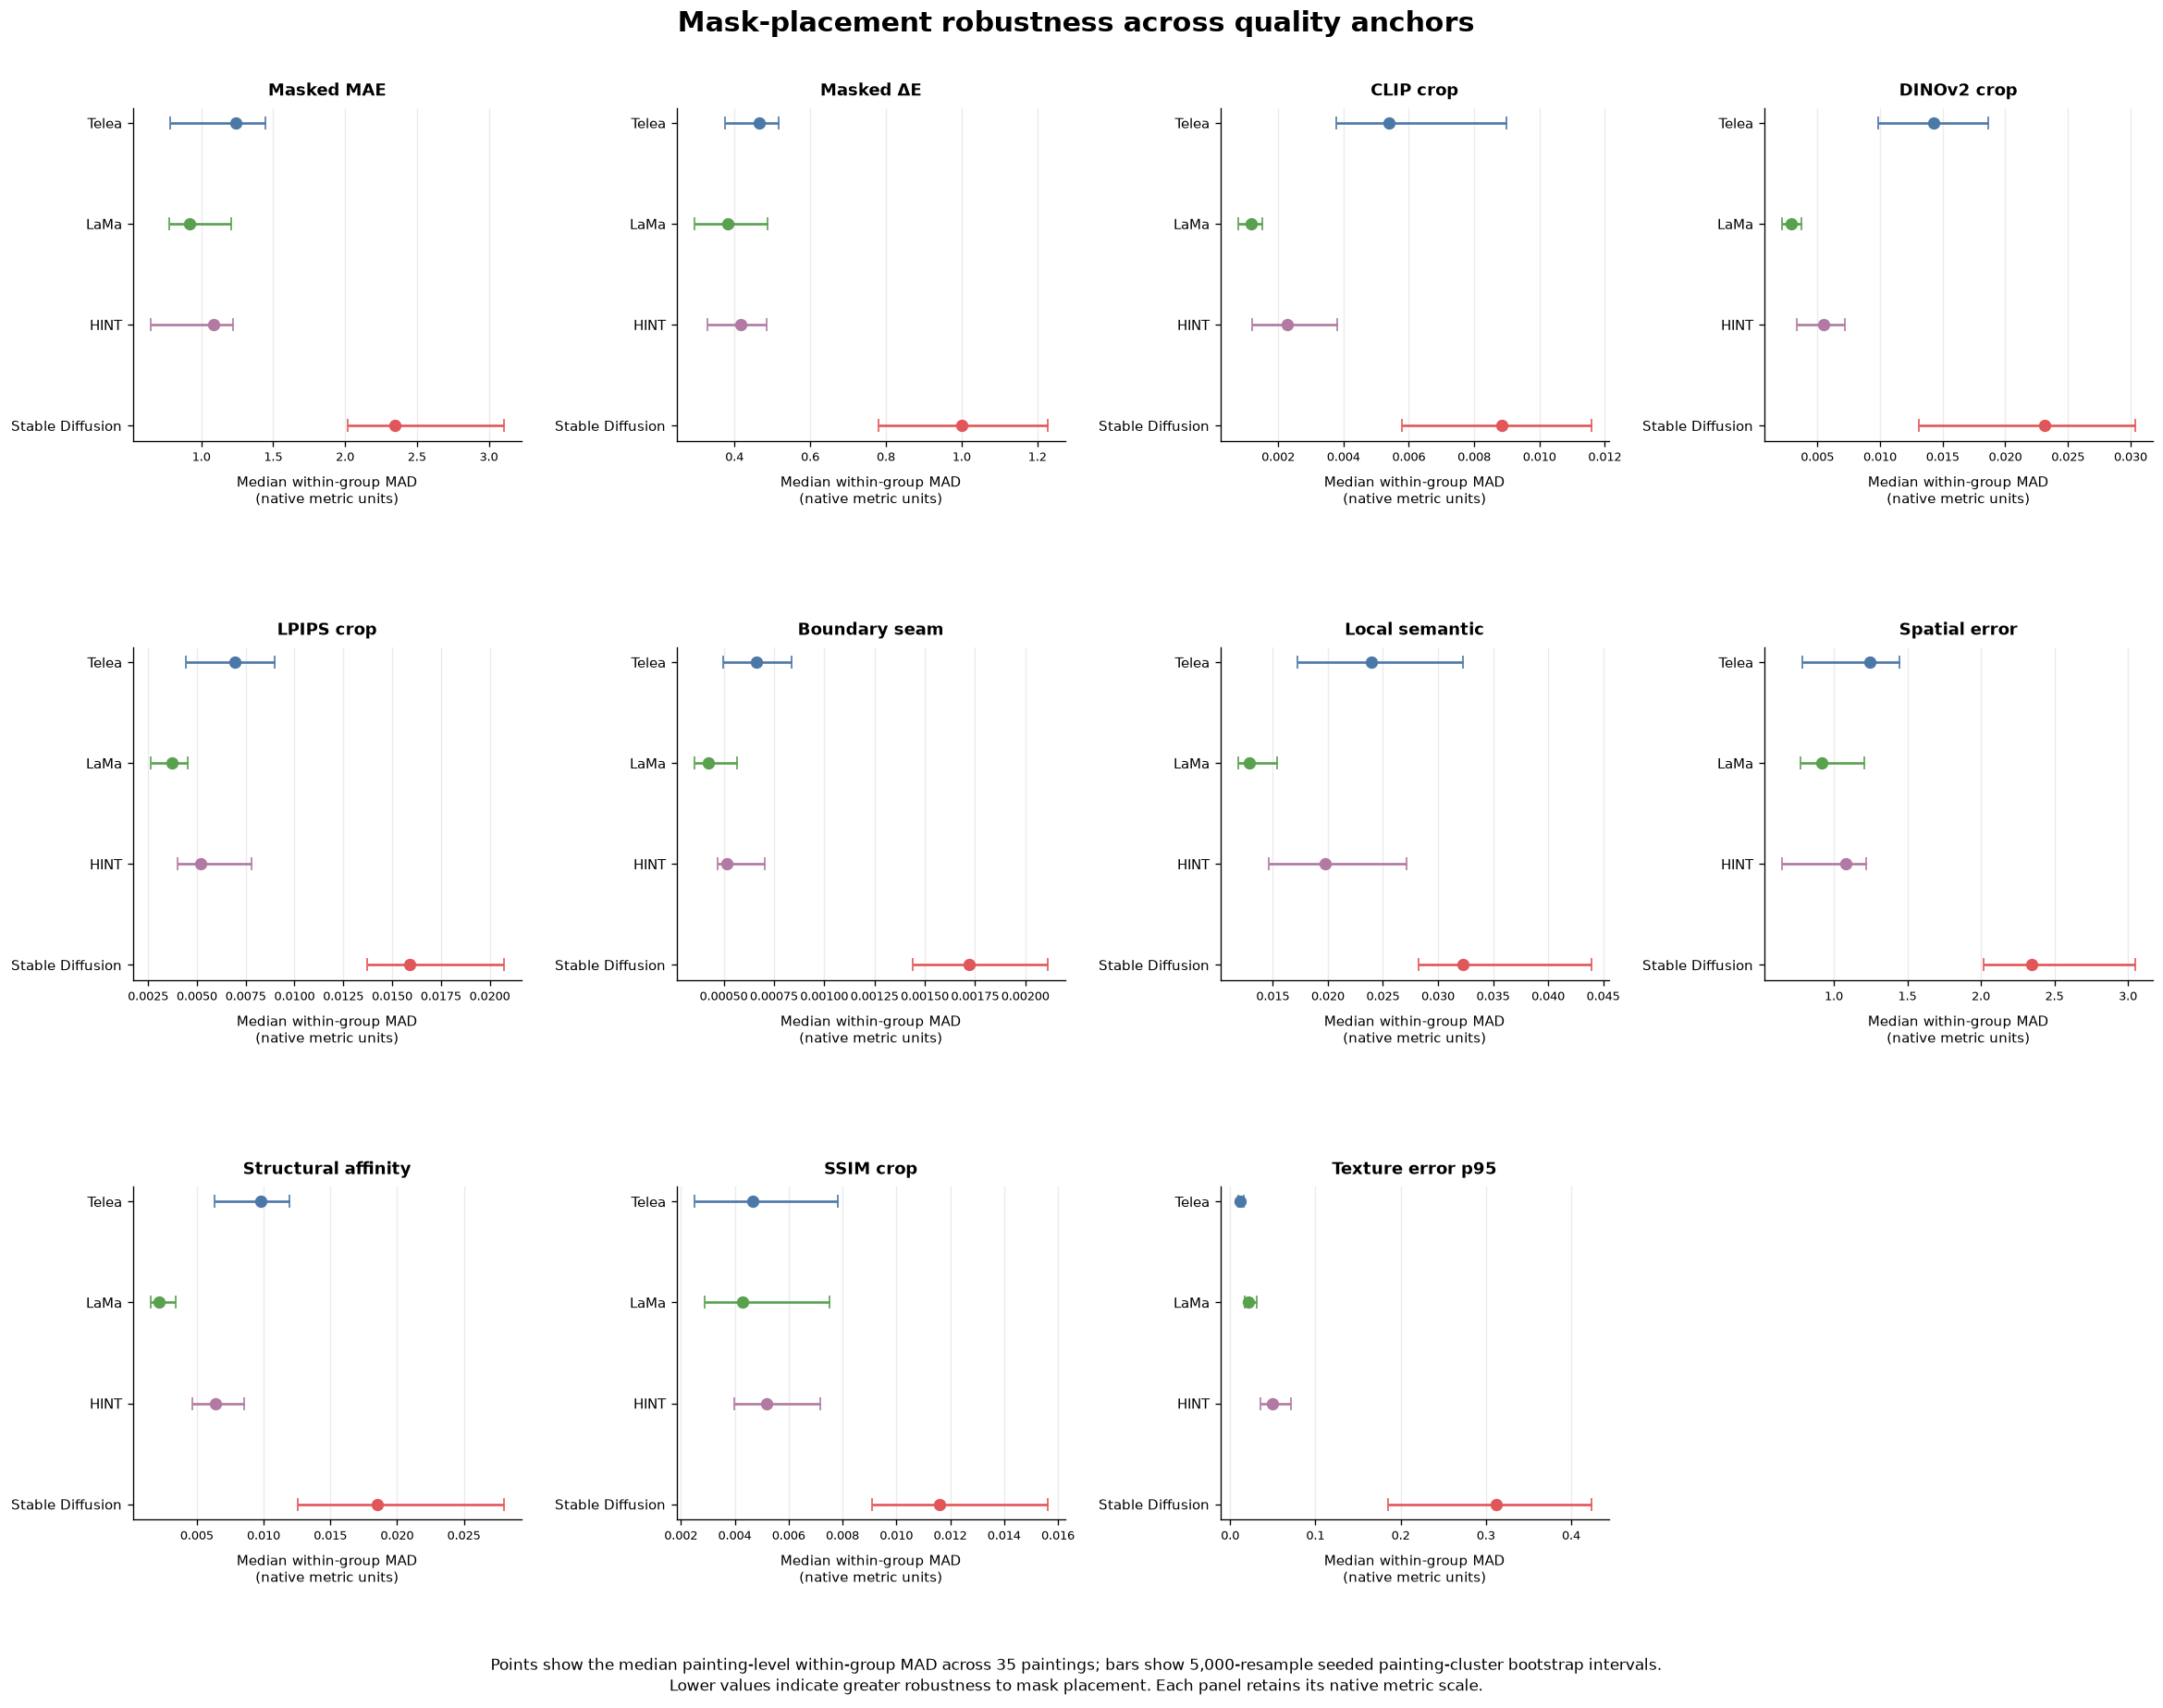

Saved canonical robustness-variance figure.
outputs/24_mask_robustness_analysis/figures/robustness_variance.png


In [32]:
MODEL_COLORS = {
    "opencv_telea": "#4C78A8",
    "lama": "#59A14F",
    "hint_places2": "#B279A2",
    "stable_diffusion_inpainting": "#E15759",
}

MODEL_SHORT_LABELS = {
    "opencv_telea": "Telea",
    "lama": "LaMa",
    "hint_places2": "HINT",
    "stable_diffusion_inpainting": "Stable Diffusion",
}

ANCHOR_SHORT_LABELS = {
    "classical_masked_mae": "Masked MAE",
    "colour_masked_delta_e": "Masked ΔE",
    "feature_clip_crop": "CLIP crop",
    "feature_dino_crop": "DINOv2 crop",
    "perceptual_crop_lpips": "LPIPS crop",
    "seam_boundary_gradient": "Boundary seam",
    "semantic_local_dino": "Local semantic",
    "spatial_masked_error": "Spatial error",
    "structural_affinity_correlation": "Structural affinity",
    "structural_crop_ssim": "SSIM crop",
    "texture_crop_p95": "Texture error p95",
}

overall_robustness_data = (
    MODEL_DISPERSION_SUMMARY_ANALYSIS.loc[
        MODEL_DISPERSION_SUMMARY_ANALYSIS[
            "scope_type"
        ].eq("overall")
    ]
    .copy()
)

anchor_order = sorted(
    overall_robustness_data[
        "anchor_id"
    ].astype(str).unique()
)

fig, axes = plt.subplots(
    nrows=3,
    ncols=4,
    figsize=(20, 16),
    constrained_layout=False,
)

axes_flat = axes.ravel()

for axis_index, anchor_id in enumerate(
    anchor_order
):
    axis = axes_flat[axis_index]

    anchor_rows = (
        overall_robustness_data.loc[
            overall_robustness_data[
                "anchor_id"
            ].astype(str).eq(anchor_id)
        ]
        .set_index("model_id")
        .reindex(POPULATION["model_order"])
        .reset_index()
    )

    estimates = pd.to_numeric(
        anchor_rows["estimate"],
        errors="coerce",
    ).to_numpy(float)

    lower = pd.to_numeric(
        anchor_rows["ci_lower"],
        errors="coerce",
    ).to_numpy(float)

    upper = pd.to_numeric(
        anchor_rows["ci_upper"],
        errors="coerce",
    ).to_numpy(float)

    lower_error = np.maximum(
        estimates - lower,
        0.0,
    )
    upper_error = np.maximum(
        upper - estimates,
        0.0,
    )

    y_positions = np.arange(
        len(anchor_rows)
    )

    for position, row in enumerate(
        anchor_rows.itertuples(index=False)
    ):
        axis.errorbar(
            estimates[position],
            y_positions[position],
            xerr=np.array(
                [
                    [lower_error[position]],
                    [upper_error[position]],
                ]
            ),
            fmt="o",
            color=MODEL_COLORS.get(
                row.model_id,
                "#666666",
            ),
            markersize=7,
            capsize=4,
            linewidth=1.6,
        )

    axis.set_yticks(y_positions)
    axis.set_yticklabels(
        [
            MODEL_SHORT_LABELS.get(
                model_id,
                model_id,
            )
            for model_id in anchor_rows[
                "model_id"
            ]
        ],
        fontsize=9,
    )
    axis.invert_yaxis()

    axis.set_title(
        ANCHOR_SHORT_LABELS.get(
            anchor_id,
            anchor_id,
        ),
        fontsize=11,
        fontweight="bold",
        pad=8,
    )

    axis.set_xlabel(
        "Median within-group MAD\n"
        "(native metric units)",
        fontsize=9,
        labelpad=7,
    )

    axis.tick_params(
        axis="x",
        labelsize=8,
    )

    axis.grid(
        axis="x",
        alpha=0.25,
    )
    axis.grid(
        axis="y",
        visible=False,
    )

for unused_axis in axes_flat[
    len(anchor_order):
]:
    unused_axis.axis("off")

fig.suptitle(
    "Mask-placement robustness across quality anchors",
    fontsize=18,
    fontweight="bold",
    y=0.975,
)

fig.subplots_adjust(
    left=0.075,
    right=0.985,
    top=0.92,
    bottom=0.125,
    wspace=0.40,
    hspace=0.62,
)

fig.text(
    0.5,
    0.025,
    (
        "Points show the median painting-level "
        "within-group MAD across 35 paintings; "
        "bars show 5,000-resample seeded "
        "painting-cluster bootstrap intervals.\n"
        "Lower values indicate greater robustness "
        "to mask placement. Each panel retains "
        "its native metric scale."
    ),
    ha="center",
    va="bottom",
    fontsize=10,
    linespacing=1.35,
)

fig.savefig(
    OUTPUT_PATHS["robustness_figure"],
    format="png",
    dpi=180,
    bbox_inches="tight",
    facecolor="white",
)

display(fig)
plt.close(fig)

print("Saved canonical robustness-variance figure.")
print(
    str(
        OUTPUT_PATHS[
            "robustness_figure"
        ].relative_to(PROJECT_ROOT)
    ).replace("\\", "/")
)

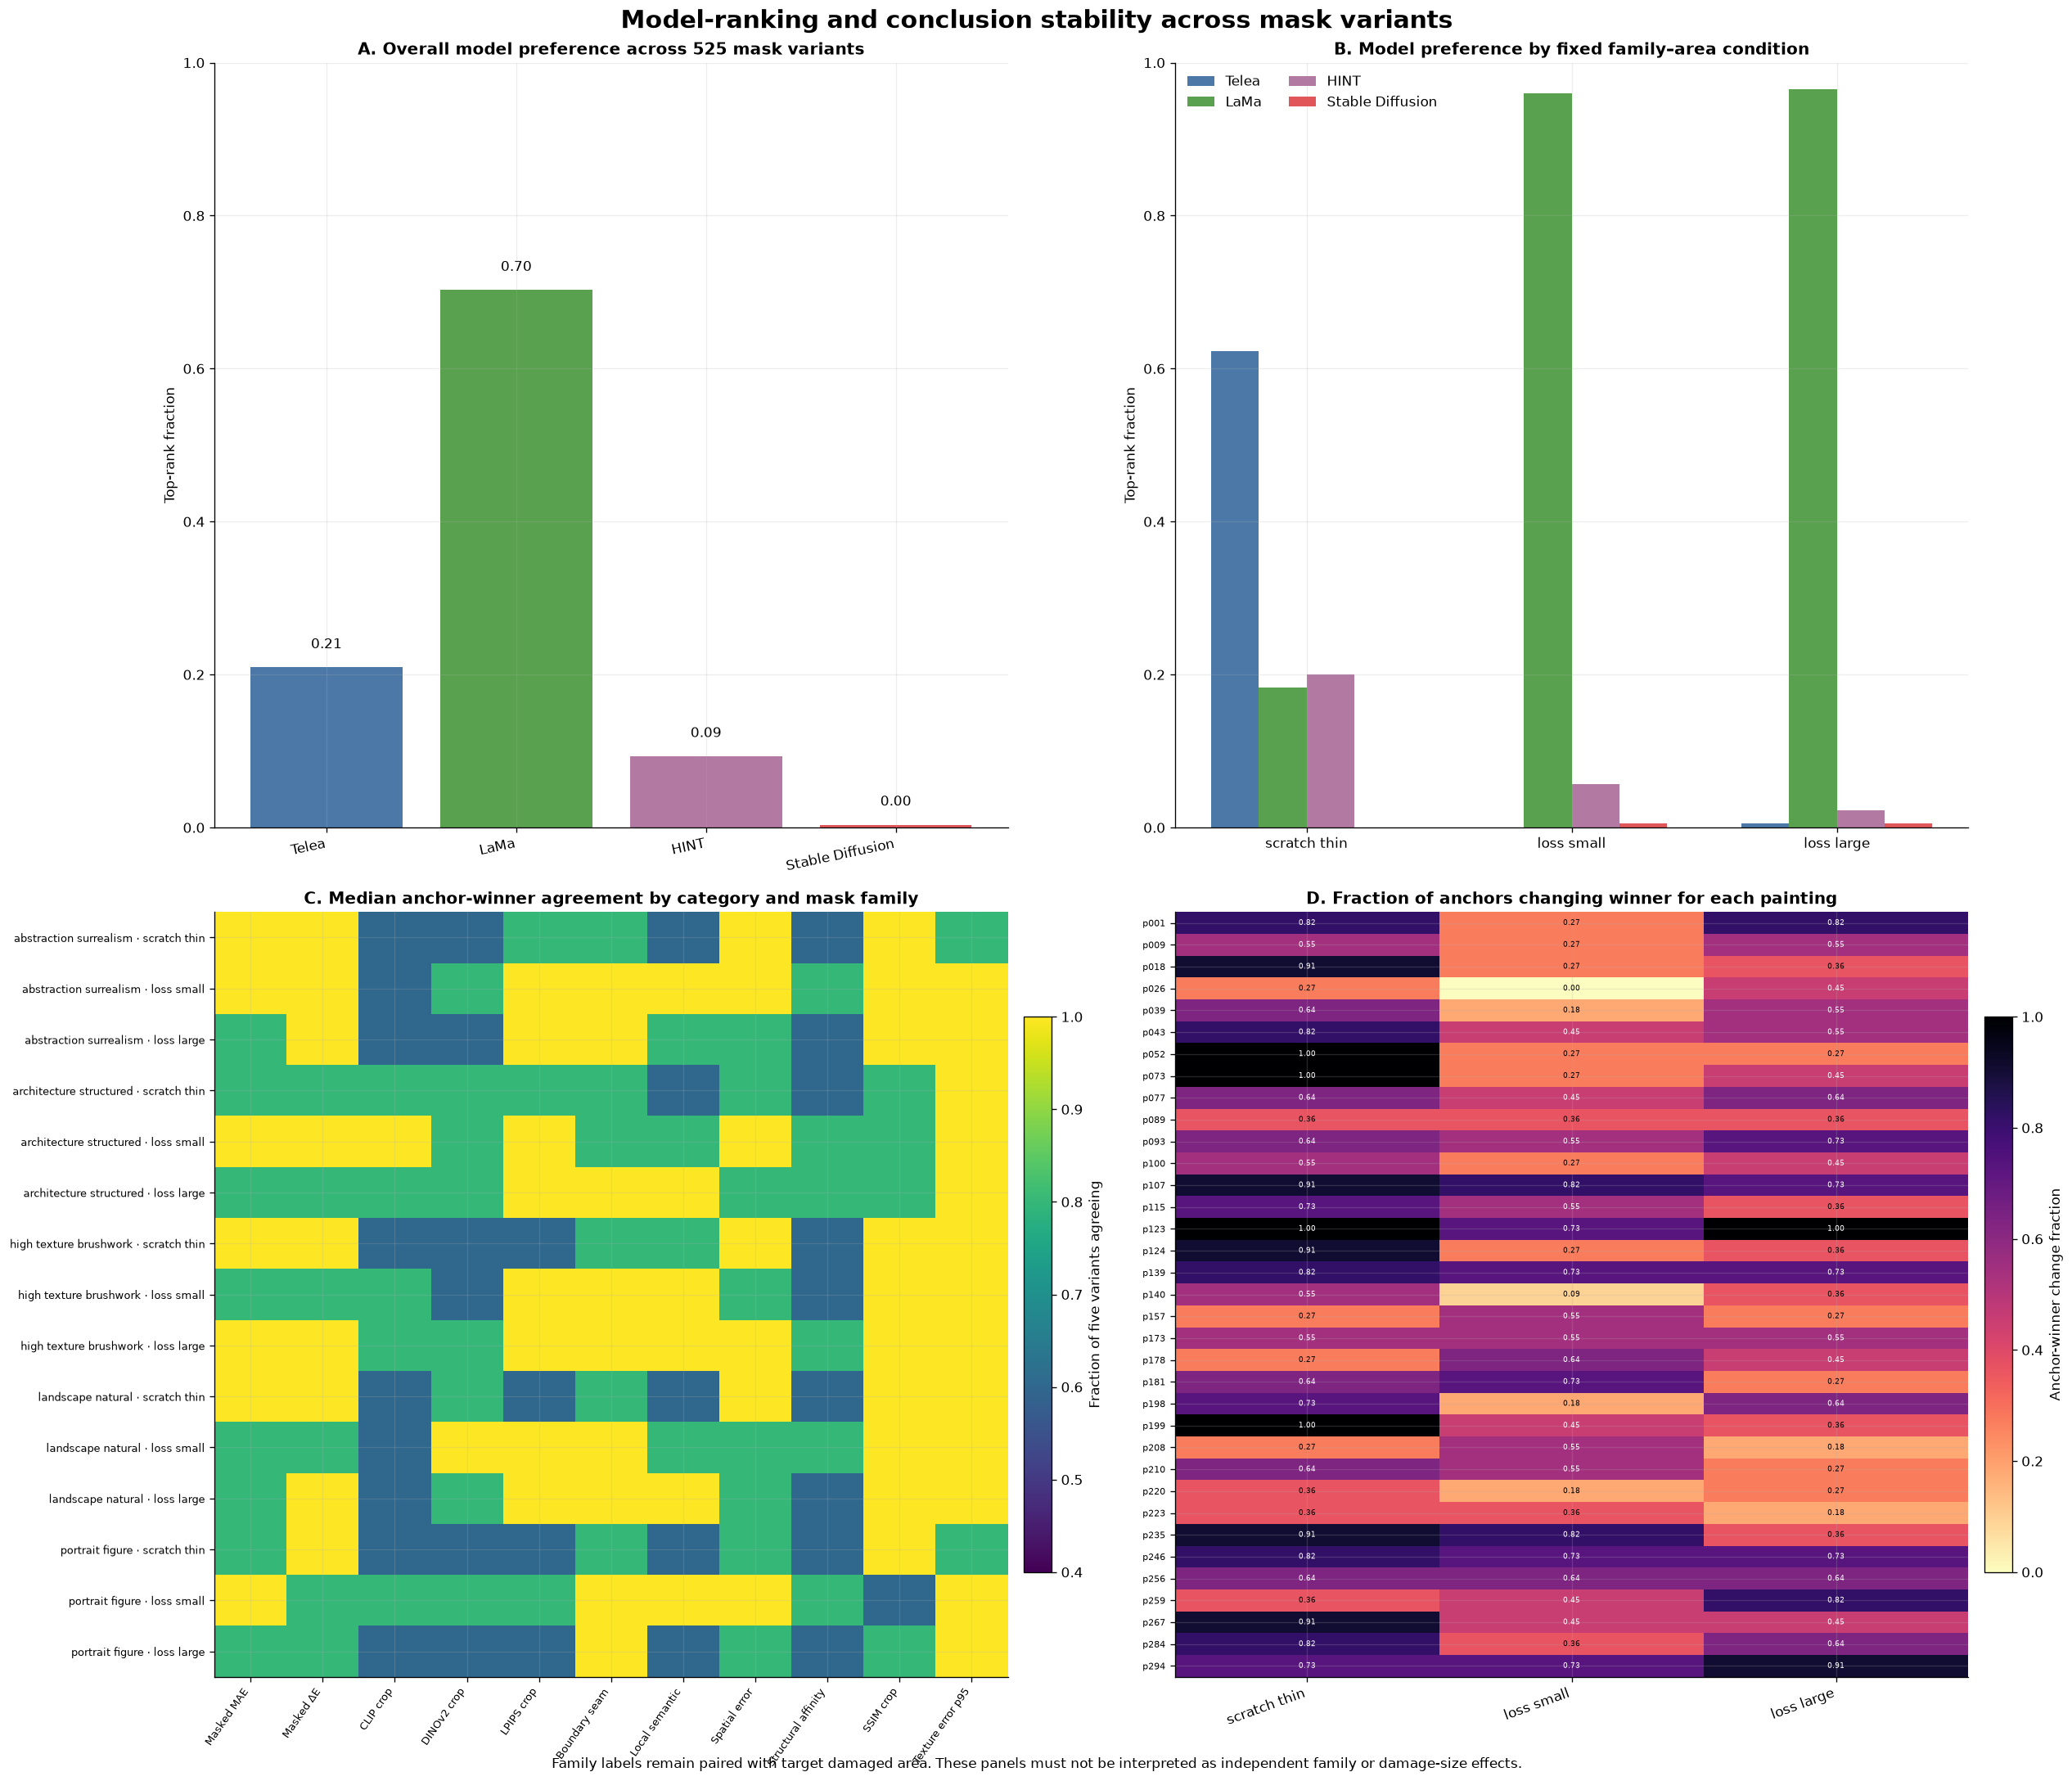

Saved canonical ranking-stability figure.
outputs/24_mask_robustness_analysis/figures/ranking_stability.png


In [33]:
overall_top_rank = (
    VARIANT_RANKS_RAW.groupby(
        "model_id"
    )["is_top_rank"]
    .mean()
    .reindex(
        POPULATION["model_order"]
    )
)

family_top_rank = (
    VARIANT_RANKS_RAW.groupby(
        ["mask_family", "model_id"]
    )["is_top_rank"]
    .mean()
    .unstack("model_id")
    .reindex(
        index=family_display_order,
        columns=POPULATION["model_order"],
    )
)

category_order = sorted(
    ANCHOR_WINNER_STABILITY_RAW[
        "category"
    ].astype(str).unique()
)

category_family_index = (
    pd.MultiIndex.from_product(
        [
            category_order,
            family_display_order,
        ],
        names=[
            "category",
            "mask_family",
        ],
    )
)

anchor_stability_matrix = (
    ANCHOR_WINNER_STABILITY_RAW.groupby(
        [
            "category",
            "mask_family",
            "anchor_id",
        ],
        dropna=False,
    )["dominant_winner_fraction"]
    .median()
    .unstack("anchor_id")
    .reindex(
        index=category_family_index,
        columns=sorted(
            ANCHOR_WINNER_STABILITY_RAW[
                "anchor_id"
            ].astype(str).unique()
        ),
    )
)

anchor_stability_matrix.index = [
    (
        f"{str(category).replace('_', ' ')} · "
        f"{str(mask_family).replace('_', ' ')}"
    )
    for category, mask_family
    in anchor_stability_matrix.index
]

group_sensitivity_matrix = (
    GROUP_SENSITIVITY_ANALYSIS.pivot_table(
        index="painting_id",
        columns="mask_family",
        values="estimate",
        aggfunc="first",
    )
    .reindex(
        index=POPULATION["painting_ids"],
        columns=family_display_order,
    )
)

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(21, 18),
    constrained_layout=True,
)

axis = axes[0, 0]
models = list(
    POPULATION["model_order"]
)
positions = np.arange(
    len(models)
)

axis.bar(
    positions,
    overall_top_rank.to_numpy(float),
    color=[
        MODEL_COLORS.get(
            model_id,
            "#666666",
        )
        for model_id in models
    ],
)

axis.set_xticks(positions)
axis.set_xticklabels(
    [
        MODEL_SHORT_LABELS.get(
            model_id,
            model_id,
        )
        for model_id in models
    ],
    rotation=12,
    ha="right",
)
axis.set_ylim(0.0, 1.0)
axis.set_ylabel("Top-rank fraction")
axis.set_title(
    "A. Overall model preference across "
    "525 mask variants",
    fontweight="bold",
)

for position, value in enumerate(
    overall_top_rank
):
    axis.text(
        position,
        float(value) + 0.025,
        f"{float(value):.2f}",
        ha="center",
        fontsize=10,
    )

axis = axes[0, 1]
family_positions = np.arange(
    len(family_display_order)
)
bar_width = 0.18

for model_index, model_id in enumerate(
    models
):
    offsets = (
        family_positions
        + (
            model_index
            - (len(models) - 1) / 2
        )
        * bar_width
    )

    axis.bar(
        offsets,
        family_top_rank[
            model_id
        ].to_numpy(float),
        width=bar_width,
        color=MODEL_COLORS.get(
            model_id,
            "#666666",
        ),
        label=MODEL_SHORT_LABELS.get(
            model_id,
            model_id,
        ),
    )

axis.set_xticks(family_positions)
axis.set_xticklabels(
    [
        family.replace("_", " ")
        for family in family_display_order
    ]
)
axis.set_ylim(0.0, 1.0)
axis.set_ylabel("Top-rank fraction")
axis.set_title(
    "B. Model preference by fixed "
    "family–area condition",
    fontweight="bold",
)
axis.legend(
    frameon=False,
    ncol=2,
)

axis = axes[1, 0]
stability_image = axis.imshow(
    anchor_stability_matrix.to_numpy(float),
    aspect="auto",
    cmap="viridis",
    vmin=0.4,
    vmax=1.0,
)

axis.set_yticks(
    np.arange(
        len(anchor_stability_matrix)
    )
)
axis.set_yticklabels(
    anchor_stability_matrix.index,
    fontsize=7.5,
)
axis.set_xticks(
    np.arange(
        len(anchor_stability_matrix.columns)
    )
)
axis.set_xticklabels(
    [
        ANCHOR_SHORT_LABELS.get(
            anchor_id,
            anchor_id,
        )
        for anchor_id in (
            anchor_stability_matrix.columns
        )
    ],
    rotation=55,
    ha="right",
    fontsize=8,
)
axis.set_title(
    "C. Median anchor-winner agreement "
    "by category and mask family",
    fontweight="bold",
)

colorbar = fig.colorbar(
    stability_image,
    ax=axis,
    fraction=0.035,
    pad=0.02,
)
colorbar.set_label(
    "Fraction of five variants agreeing"
)

axis = axes[1, 1]
sensitivity_image = axis.imshow(
    group_sensitivity_matrix.to_numpy(float),
    aspect="auto",
    cmap="magma_r",
    vmin=0.0,
    vmax=1.0,
)

axis.set_yticks(
    np.arange(
        len(group_sensitivity_matrix)
    )
)
axis.set_yticklabels(
    group_sensitivity_matrix.index,
    fontsize=6.5,
)
axis.set_xticks(
    np.arange(
        len(group_sensitivity_matrix.columns)
    )
)
axis.set_xticklabels(
    [
        family.replace("_", " ")
        for family in (
            group_sensitivity_matrix.columns
        )
    ],
    rotation=20,
    ha="right",
)
axis.set_title(
    "D. Fraction of anchors changing "
    "winner for each painting",
    fontweight="bold",
)

for row_index in range(
    group_sensitivity_matrix.shape[0]
):
    for column_index in range(
        group_sensitivity_matrix.shape[1]
    ):
        value = float(
            group_sensitivity_matrix.iloc[
                row_index,
                column_index,
            ]
        )

        axis.text(
            column_index,
            row_index,
            f"{value:.2f}",
            ha="center",
            va="center",
            color=(
                "white"
                if value >= 0.45
                else "black"
            ),
            fontsize=5.3,
        )

colorbar = fig.colorbar(
    sensitivity_image,
    ax=axis,
    fraction=0.035,
    pad=0.02,
)
colorbar.set_label(
    "Anchor-winner change fraction"
)

fig.suptitle(
    "Model-ranking and conclusion stability "
    "across mask variants",
    fontsize=18,
    fontweight="bold",
)

fig.text(
    0.5,
    0.001,
    (
        "Family labels remain paired with target "
        "damaged area. These panels must not be "
        "interpreted as independent family or "
        "damage-size effects."
    ),
    ha="center",
    va="bottom",
    fontsize=10,
)

fig.savefig(
    OUTPUT_PATHS["ranking_figure"],
    format="png",
    dpi=180,
    bbox_inches="tight",
    facecolor="white",
)

display(fig)
plt.close(fig)

print("Saved canonical ranking-stability figure.")
print(
    str(
        OUTPUT_PATHS[
            "ranking_figure"
        ].relative_to(PROJECT_ROOT)
    ).replace("\\", "/")
)

In [34]:
def inspect_png(
    path: Path,
) -> dict:
    """Inspect a persisted PNG without modifying it."""
    with Image.open(path) as image:
        return {
            "path": str(
                path.relative_to(PROJECT_ROOT)
            ).replace("\\", "/"),
            "format": image.format,
            "mode": image.mode,
            "width": image.width,
            "height": image.height,
            "size_bytes": path.stat().st_size,
            "sha256": sha256_file(path),
        }


FIGURE_INSPECTION = pd.DataFrame(
    [
        inspect_png(
            OUTPUT_PATHS[
                "robustness_figure"
            ]
        ),
        inspect_png(
            OUTPUT_PATHS[
                "ranking_figure"
            ]
        ),
    ]
)

overall_anchor_winners = (
    MODEL_DISPERSION_SUMMARY_ANALYSIS.loc[
        MODEL_DISPERSION_SUMMARY_ANALYSIS[
            "scope_type"
        ].eq("overall")
    ]
    .sort_values(
        ["anchor_id", "estimate"],
        kind="stable",
    )
    .groupby(
        "anchor_id",
        as_index=False,
    )
    .first()
)

descriptive_stability_winner_counts = (
    overall_anchor_winners[
        "model_id"
    ]
    .value_counts()
    .reindex(
        POPULATION["model_order"],
        fill_value=0,
    )
    .rename("anchors_with_lowest_mad")
    .reset_index()
    .rename(
        columns={"index": "model_id"}
    )
)

paired_resolved_rows = (
    PAIRED_MODEL_CONTRAST_ANALYSIS.loc[
        PAIRED_MODEL_CONTRAST_ANALYSIS[
            "interpretation_status"
        ].isin(
            {
                "model_more_robust",
                "comparison_model_more_robust",
            }
        )
    ]
    .copy()
)

paired_resolved_supported = bool(
    (
        paired_resolved_rows.empty
        or (
            pd.to_numeric(
                paired_resolved_rows[
                    "q_value"
                ],
                errors="coerce",
            ).le(0.05).all()
            and (
                pd.to_numeric(
                    paired_resolved_rows[
                        "ci_lower"
                    ],
                    errors="coerce",
                ).gt(0.0)
                | pd.to_numeric(
                    paired_resolved_rows[
                        "ci_upper"
                    ],
                    errors="coerce",
                ).lt(0.0)
            ).all()
        )
    )
)

morphology_resolved_rows = (
    MORPHOLOGY_ASSOCIATION_ANALYSIS.loc[
        MORPHOLOGY_ASSOCIATION_ANALYSIS[
            "interpretation_status"
        ].isin(
            {
                "higher_geometry_value_associated_with_worse_quality",
                "higher_geometry_value_associated_with_better_quality",
            }
        )
    ]
    .copy()
)

morphology_resolved_supported = bool(
    (
        morphology_resolved_rows.empty
        or (
            pd.to_numeric(
                morphology_resolved_rows[
                    "q_value"
                ],
                errors="coerce",
            ).le(0.05).all()
            and (
                pd.to_numeric(
                    morphology_resolved_rows[
                        "ci_lower"
                    ],
                    errors="coerce",
                ).gt(0.0)
                | pd.to_numeric(
                    morphology_resolved_rows[
                        "ci_upper"
                    ],
                    errors="coerce",
                ).lt(0.0)
            ).all()
        )
    )
)

paired_fdr_resolved = len(
    paired_resolved_rows
)

morphology_fdr_resolved = len(
    morphology_resolved_rows
)

family_sensitivity_summary = (
    GROUP_SENSITIVITY_ANALYSIS.groupby(
        "mask_family"
    )["estimate"]
    .agg(
        ["median", "min", "max"]
    )
    .reset_index()
    .rename(
        columns={
            "median": (
                "median_winner_change_fraction"
            ),
            "min": (
                "minimum_winner_change_fraction"
            ),
            "max": (
                "maximum_winner_change_fraction"
            ),
        }
    )
)

display(FIGURE_INSPECTION)
display(
    descriptive_stability_winner_counts
)
display(family_sensitivity_summary)

print("Scientific result summary prepared.")
print(
    "FDR-resolved paired robustness contrasts:",
    paired_fdr_resolved,
)
print(
    "Resolved paired contrasts supported:",
    paired_resolved_supported,
)
print(
    "FDR-resolved morphology associations:",
    morphology_fdr_resolved,
)
print(
    "Resolved morphology associations supported:",
    morphology_resolved_supported,
)

,path,format,mode,width,height,size_bytes,sha256
0,outputs/24_mask_robustness_analysis/figures/robustness_variance.png,PNG,RGBA,3511,2772,246262,d07e546295397c9bdbe5b1030ef1d9ded44d43b1fbceca6219355385995f59df
1,outputs/24_mask_robustness_analysis/figures/ranking_stability.png,PNG,RGBA,3799,3265,477447,97b3573adc5e13dace6efec649af0b53db5fbdfc8c85d9ec687f3956ab454d79


,model_id,anchors_with_lowest_mad
0,opencv_telea,1
1,lama,10
2,hint_places2,0
3,stable_diffusion_inpainting,0


,mask_family,median_winner_change_fraction,minimum_winner_change_fraction,maximum_winner_change_fraction
0,loss_large,0.454545,0.181818,1.000000
1,loss_small,0.454545,0.000000,0.818182
2,scratch_thin,0.636364,0.272727,1.000000


Scientific result summary prepared.
FDR-resolved paired robustness contrasts: 86
Resolved paired contrasts supported: True
FDR-resolved morphology associations: 77
Resolved morphology associations supported: True


In [35]:
canonical_files_after_batch_8 = sorted(
    path
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
)

expected_files_after_batch_8 = {
    OUTPUT_PATHS["metrics"].resolve(),
    OUTPUT_PATHS[
        "robustness_figure"
    ].resolve(),
    OUTPUT_PATHS[
        "ranking_figure"
    ].resolve(),
}

observed_files_after_batch_8 = {
    path.resolve()
    for path in canonical_files_after_batch_8
}

figure_files_valid = bool(
    len(FIGURE_INSPECTION) == 2
    and FIGURE_INSPECTION[
        "format"
    ].eq("PNG").all()
    and pd.to_numeric(
        FIGURE_INSPECTION["width"],
        errors="coerce",
    ).ge(1200).all()
    and pd.to_numeric(
        FIGURE_INSPECTION["height"],
        errors="coerce",
    ).ge(800).all()
    and pd.to_numeric(
        FIGURE_INSPECTION["size_bytes"],
        errors="coerce",
    ).gt(0).all()
)

no_prohibited_analysis_terms = not (
    MASK_ROBUSTNESS_ANALYSIS.astype(str)
    .apply(
        lambda column: column.str.contains(
            (
                "combined_quality|"
                "combined_uncertainty|"
                "trust_score|"
                "calibrated confidence"
            ),
            case=False,
            regex=True,
        )
    )
    .any()
    .any()
)

family_area_mapping_preserved = (
    dict(
        POPULATION[
            "target_damage_fraction_by_family"
        ]
    )
    == {
        "scratch_thin": 0.02,
        "loss_small": 0.045,
        "loss_large": 0.125,
    }
)

preserved_validation_checks = tuple(
    check
    for check in VALIDATION.checks
    if check.validation_stage
    != "batch_8_persistence_figures"
)

VALIDATION = ValidationCollector()
VALIDATION.extend(
    preserved_validation_checks
)

VALIDATION.add(
    validation_stage=(
        "batch_8_persistence_figures"
    ),
    check_id="canonical_metrics_persisted",
    check_description=(
        "The complete canonical CSV exists "
        "and reloads successfully."
    ),
    severity="blocking",
    expected={
        "rows": EXPECTED[
            "canonical_analysis_rows"
        ],
        "schema_passed": True,
    },
    observed=analysis_roundtrip_summary,
    passed=(
        OUTPUT_PATHS["metrics"].is_file()
        and len(RELOADED_ANALYSIS)
        == int(
            EXPECTED[
                "canonical_analysis_rows"
            ]
        )
        and bool(
            reloaded_schema_validation[
                "passed"
            ]
        )
    ),
)

VALIDATION.add(
    validation_stage=(
        "batch_8_persistence_figures"
    ),
    check_id="canonical_metrics_roundtrip",
    check_description=(
        "Row IDs and numeric estimates survive "
        "CSV persistence."
    ),
    severity="blocking",
    expected={
        "row_ids_match": True,
        "estimates_match": True,
    },
    observed={
        "row_ids_match": (
            analysis_roundtrip_summary[
                "row_ids_match"
            ]
        ),
        "estimates_match": (
            analysis_roundtrip_summary[
                "estimates_match"
            ]
        ),
    },
    passed=(
        bool(
            analysis_roundtrip_summary[
                "row_ids_match"
            ]
        )
        and bool(
            analysis_roundtrip_summary[
                "estimates_match"
            ]
        )
    ),
)

VALIDATION.add(
    validation_stage=(
        "batch_8_persistence_figures"
    ),
    check_id="canonical_figures_valid",
    check_description=(
        "Both canonical figures are valid "
        "non-empty PNG files."
    ),
    severity="blocking",
    expected={
        "figures": EXPECTED[
            "canonical_figures"
        ],
        "format": "PNG",
        "minimum_width": 1200,
        "minimum_height": 800,
    },
    observed=FIGURE_INSPECTION[
        [
            "path",
            "format",
            "width",
            "height",
            "size_bytes",
        ]
    ].to_dict("records"),
    passed=figure_files_valid,
)

VALIDATION.add(
    validation_stage=(
        "batch_8_persistence_figures"
    ),
    check_id="batch_8_owned_file_set",
    check_description=(
        "The Batch 8 stage owns exactly the "
        "canonical metrics table and two figures."
    ),
    severity="blocking",
    expected=sorted(
        str(
            path.relative_to(PROJECT_ROOT)
        ).replace("\\", "/")
        for path in expected_files_after_batch_8
    ),
    observed=sorted(
        str(
            path.relative_to(PROJECT_ROOT)
        ).replace("\\", "/")
        for path in observed_files_after_batch_8
    ),
    passed=(
        observed_files_after_batch_8
        == expected_files_after_batch_8
    ),
)

VALIDATION.add(
    validation_stage=(
        "batch_8_persistence_figures"
    ),
    check_id=(
        "paired_inference_supported"
    ),
    check_description=(
        "Every directional paired-robustness "
        "interpretation has corrected inferential "
        "support and a confidence interval that "
        "excludes zero."
    ),
    severity="blocking",
    expected=True,
    observed={
        "resolved_contrasts": (
            paired_fdr_resolved
        ),
        "total_contrasts": len(
            PAIRED_MODEL_CONTRAST_ANALYSIS
        ),
        "all_resolved_supported": (
            paired_resolved_supported
        ),
    },
    passed=paired_resolved_supported,
)

VALIDATION.add(
    validation_stage=(
        "batch_8_persistence_figures"
    ),
    check_id=(
        "morphology_interpreted_as_exploratory"
    ),
    check_description=(
        "Every directional morphology association "
        "has corrected support while retaining its "
        "exploratory, non-causal interpretation."
    ),
    severity="blocking",
    expected={
        "all_resolved_supported": True,
        "interpretation": (
            "exploratory_noncausal"
        ),
    },
    observed={
        "resolved_associations": (
            morphology_fdr_resolved
        ),
        "total_associations": len(
            MORPHOLOGY_ASSOCIATION_ANALYSIS
        ),
        "all_resolved_supported": (
            morphology_resolved_supported
        ),
    },
    passed=morphology_resolved_supported,
)

VALIDATION.add(
    validation_stage=(
        "batch_8_persistence_figures"
    ),
    check_id="family_area_boundary_preserved",
    check_description=(
        "Mask family and target damaged area "
        "remain explicitly paired."
    ),
    severity="blocking",
    expected={
        "scratch_thin": 0.02,
        "loss_small": 0.045,
        "loss_large": 0.125,
    },
    observed=dict(
        POPULATION[
            "target_damage_fraction_by_family"
        ]
    ),
    passed=family_area_mapping_preserved,
)

runtime_quality_rows = (
    MASK_ROBUSTNESS_ANALYSIS.loc[
        MASK_ROBUSTNESS_ANALYSIS[
            "analysis_kind"
        ].isin(
            {
                "runtime_group_dispersion",
                "runtime_model_summary",
            }
        )
    ]
)

runtime_quality_flags = as_boolean(
    runtime_quality_rows[
        "quality_ranking_eligible"
    ]
)

VALIDATION.add(
    validation_stage=(
        "batch_8_persistence_figures"
    ),
    check_id="runtime_remains_operational",
    check_description=(
        "No runtime-derived row is eligible "
        "for quality ranking."
    ),
    severity="blocking",
    expected=0,
    observed=int(
        runtime_quality_flags.sum()
    ),
    passed=not runtime_quality_flags.any(),
)

VALIDATION.add(
    validation_stage=(
        "batch_8_persistence_figures"
    ),
    check_id="no_prohibited_scores_or_claims",
    check_description=(
        "The canonical analysis contains no "
        "prohibited combined score or calibrated "
        "confidence claim."
    ),
    severity="blocking",
    expected=True,
    observed=no_prohibited_analysis_terms,
    passed=no_prohibited_analysis_terms,
)

remaining_work_files = [
    path
    for path in WORK_ROOT.rglob("*")
    if path.is_file()
]

VALIDATION.add(
    validation_stage=(
        "batch_8_persistence_figures"
    ),
    check_id="work_directory_empty",
    check_description=(
        "No temporary work files remain "
        "after persistence."
    ),
    severity="blocking",
    expected=0,
    observed=len(
        remaining_work_files
    ),
    passed=not remaining_work_files,
)

BATCH_8_CHECKS = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ]
        == "batch_8_persistence_figures"
    ]
    .reset_index(drop=True)
)

BATCH_8_SUMMARY = VALIDATION.summary()

display(BATCH_8_CHECKS)

VALIDATION.raise_for_blocking()

print("Batch 8 passed.")
print(
    "Canonical analysis rows:",
    f"{len(RELOADED_ANALYSIS):,}",
)
print(
    "Canonical figures:",
    len(FIGURE_INSPECTION),
)
print(
    "Resolved paired contrasts:",
    paired_fdr_resolved,
)
print(
    "Resolved morphology associations:",
    morphology_fdr_resolved,
)
print(
    "Blocking failures so far:",
    BATCH_8_SUMMARY[
        "blocking_failure_count"
    ],
)
print(
    "Next batch: mock-aligned report, manifests, "
    "final validation, and completion traceability."
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_8_persistence_figures,canonical_metrics_persisted,The complete canonical CSV exists and reloads successfully.,blocking,"{""rows"": 44847, ""schema_passed"": true}","{""columns_reloaded"": 51, ""columns_written"": 51, ""estimates_match"": true, ""row_ids_match"": true, ""rows_reloaded"": 44847, ""rows_written"": ...",True,
1,batch_8_persistence_figures,canonical_metrics_roundtrip,Row IDs and numeric estimates survive CSV persistence.,blocking,"{""estimates_match"": true, ""row_ids_match"": true}","{""estimates_match"": true, ""row_ids_match"": true}",True,
2,batch_8_persistence_figures,canonical_figures_valid,Both canonical figures are valid non-empty PNG files.,blocking,"{""figures"": 2, ""format"": ""PNG"", ""minimum_height"": 800, ""minimum_width"": 1200}","[{""format"": ""PNG"", ""height"": 2772, ""path"": ""outputs/24_mask_robustness_analysis/figures/robustness_variance.png"", ""size_bytes"": 246262, ...",True,
3,batch_8_persistence_figures,batch_8_owned_file_set,The Batch 8 stage owns exactly the canonical metrics table and two figures.,blocking,"[""outputs/24_mask_robustness_analysis/figures/ranking_stability.png"", ""outputs/24_mask_robustness_analysis/figures/robustness_variance.p...","[""outputs/24_mask_robustness_analysis/figures/ranking_stability.png"", ""outputs/24_mask_robustness_analysis/figures/robustness_variance.p...",True,
4,batch_8_persistence_figures,paired_inference_supported,Every directional paired-robustness interpretation has corrected inferential support and a confidence interval that excludes zero.,blocking,True,"{""all_resolved_supported"": true, ""resolved_contrasts"": 86, ""total_contrasts"": 264}",True,
5,batch_8_persistence_figures,morphology_interpreted_as_exploratory,"Every directional morphology association has corrected support while retaining its exploratory, non-causal interpretation.",blocking,"{""all_resolved_supported"": true, ""interpretation"": ""exploratory_noncausal""}","{""all_resolved_supported"": true, ""resolved_associations"": 77, ""total_associations"": 396}",True,
6,batch_8_persistence_figures,family_area_boundary_preserved,Mask family and target damaged area remain explicitly paired.,blocking,"{""loss_large"": 0.125, ""loss_small"": 0.045, ""scratch_thin"": 0.02}","{""loss_large"": 0.125, ""loss_small"": 0.045, ""scratch_thin"": 0.02}",True,
7,batch_8_persistence_figures,runtime_remains_operational,No runtime-derived row is eligible for quality ranking.,blocking,0,0,True,
8,batch_8_persistence_figures,no_prohibited_scores_or_claims,The canonical analysis contains no prohibited combined score or calibrated confidence claim.,blocking,True,True,True,
9,batch_8_persistence_figures,work_directory_empty,No temporary work files remain after persistence.,blocking,0,0,True,


Batch 8 passed.
Canonical analysis rows: 44,847
Canonical figures: 2
Resolved paired contrasts: 86
Resolved morphology associations: 77
Blocking failures so far: 0
Next batch: mock-aligned report, manifests, final validation, and completion traceability.


## Batch 9 — Mock-aligned report, manifests, and completion gate

This final batch:

- derives report conclusions from the validated canonical analysis;
- creates ten embedded analytical views;
- creates eight embedded restoration or diagnostic panels;
- preserves the approved 13-section mock-report structure;
- embeds every required image directly into one standalone HTML file;
- validates report density, section order, scientific limits, and mock fidelity;
- writes the consolidated validation table;
- writes artifact and run manifests;
- updates the normalized project-path registry;
- performs the final completion sweep.

Report-only plots and image grids are held in memory and embedded directly in the HTML. They are not persisted as additional notebook-owned files.

In [36]:
import base64
import io
import os
import re
import time
from html import escape

from PIL import Image
from IPython.display import HTML as NotebookHTML

from restoration_eval.manifests import (
    MANIFESTS_MODULE_VERSION,
    sha256_path,
)
from restoration_eval.multi_model_comparison import (
    image_grid_to_data_uri,
    image_path_to_data_uri,
)
from restoration_eval.paths import (
    PATHS_MODULE_VERSION,
    load_project_paths_registry,
    to_repo_relative,
    upsert_project_path_artifacts,
    validate_project_paths_registry,
    write_project_paths_registry,
)
from restoration_eval.validation import (
    VALIDATION_MODULE_VERSION,
    VALIDATION_SCHEMA_VERSION,
)


REPORT = SETTINGS["report"]
REPORT_ANALYSIS = RELOADED_ANALYSIS.copy()

MODEL_LABELS = {
    "opencv_telea": "OpenCV Telea",
    "lama": "LaMa",
    "hint_places2": "HINT",
    "stable_diffusion_inpainting": "Stable Diffusion",
}

MODEL_SHORT_LABELS = {
    "opencv_telea": "Telea",
    "lama": "LaMa",
    "hint_places2": "HINT",
    "stable_diffusion_inpainting": "SD",
}

FAMILY_LABELS = {
    "scratch_thin": "Thin scratch · fixed at 2%",
    "loss_small": "Small loss · fixed at 4.5%",
    "loss_large": "Large loss · fixed at 12.5%",
}

ANCHOR_LABELS = {
    "classical_masked_mae": "Masked MAE",
    "colour_masked_delta_e": "Masked ΔE",
    "feature_clip_crop": "CLIP crop",
    "feature_dino_crop": "DINOv2 crop",
    "perceptual_crop_lpips": "LPIPS crop",
    "seam_boundary_gradient": "Boundary seam",
    "semantic_local_dino": "Local semantic",
    "spatial_masked_error": "Spatial error",
    "structural_affinity_correlation": "Structural affinity",
    "structural_crop_ssim": "SSIM crop",
    "texture_crop_p95": "Texture error p95",
}


def figure_to_data_uri(
    figure,
    *,
    max_dimension=900,
    quality=82,
):
    """Encode a report-only figure as a compact JPEG data URI."""
    png_buffer = io.BytesIO()

    figure.savefig(
        png_buffer,
        format="png",
        dpi=140,
        bbox_inches="tight",
        facecolor="white",
    )
    png_buffer.seek(0)

    with Image.open(png_buffer) as opened:
        image = opened.convert("RGB")
        image.thumbnail(
            (
                int(max_dimension),
                int(max_dimension),
            ),
            Image.Resampling.LANCZOS,
        )

        jpeg_buffer = io.BytesIO()
        image.save(
            jpeg_buffer,
            format="JPEG",
            quality=int(quality),
            optimize=True,
        )

    payload = base64.b64encode(
        jpeg_buffer.getvalue()
    ).decode("ascii")

    return f"data:image/jpeg;base64,{payload}"


def atomic_write_text_retry(
    output_path,
    text,
    *,
    attempts=5,
):
    """Write text atomically with bounded Windows retries."""
    destination = Path(output_path)
    temporary = destination.with_suffix(
        destination.suffix + ".tmp"
    )

    destination.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    last_error = None

    for attempt in range(
        1,
        int(attempts) + 1,
    ):
        try:
            temporary.write_text(
                text,
                encoding="utf-8",
                newline="\n",
            )
            os.replace(
                temporary,
                destination,
            )
            return attempt

        except PermissionError as exc:
            last_error = exc
            temporary.unlink(
                missing_ok=True
            )

            if attempt < int(attempts):
                time.sleep(
                    0.25 * attempt
                )

    raise last_error


def report_table(
    frame,
    *,
    maximum_rows=None,
):
    """Render a compact HTML table."""
    table = frame.copy()

    if maximum_rows is not None:
        table = table.head(
            int(maximum_rows)
        )

    return table.to_html(
        index=False,
        border=0,
        classes="data-table",
        na_rep="—",
        float_format=lambda value: (
            f"{value:.4f}"
        ),
        escape=True,
    )


OVERALL_MAD_ROWS = (
    REPORT_ANALYSIS.loc[
        REPORT_ANALYSIS[
            "analysis_kind"
        ].astype(str).eq(
            "model_dispersion_summary"
        )
        & REPORT_ANALYSIS[
            "scope_type"
        ].astype(str).eq("overall")
    ]
    .copy()
)

OVERALL_MAD_ROWS["estimate"] = (
    pd.to_numeric(
        OVERALL_MAD_ROWS["estimate"],
        errors="coerce",
    )
)

overall_winner_indices = (
    OVERALL_MAD_ROWS.groupby(
        "anchor_id",
        observed=True,
    )["estimate"]
    .idxmin()
)

OVERALL_MAD_WINNERS = (
    OVERALL_MAD_ROWS.loc[
        overall_winner_indices
    ]
    .copy()
    .sort_values("anchor_id")
)

overall_mad_winner_counts = (
    OVERALL_MAD_WINNERS[
        "model_id"
    ]
    .astype(str)
    .value_counts()
    .reindex(
        POPULATION["model_order"],
        fill_value=0,
    )
)

VARIANT_RANK_REPORT_ROWS = (
    REPORT_ANALYSIS.loc[
        REPORT_ANALYSIS[
            "analysis_kind"
        ].astype(str).eq(
            "variant_family_balanced_rank"
        )
    ]
    .copy()
)

VARIANT_RANK_REPORT_ROWS[
    "effect_size"
] = pd.to_numeric(
    VARIANT_RANK_REPORT_ROWS[
        "effect_size"
    ],
    errors="coerce",
)

variant_top_rank_counts = (
    VARIANT_RANK_REPORT_ROWS.loc[
        VARIANT_RANK_REPORT_ROWS[
            "interpretation_status"
        ].astype(str).eq("top_rank")
    ]
    .groupby("model_id")
    .size()
    .reindex(
        POPULATION["model_order"],
        fill_value=0,
    )
)

SENSITIVITY_REPORT_ROWS = (
    REPORT_ANALYSIS.loc[
        REPORT_ANALYSIS[
            "analysis_kind"
        ].astype(str).eq(
            "group_sensitivity_summary"
        )
    ]
    .copy()
)

for column in (
    "estimate",
    "effect_size",
):
    SENSITIVITY_REPORT_ROWS[column] = (
        pd.to_numeric(
            SENSITIVITY_REPORT_ROWS[
                column
            ],
            errors="coerce",
        )
    )

FAMILY_SENSITIVITY_REPORT = (
    SENSITIVITY_REPORT_ROWS.groupby(
        "mask_family",
        observed=True,
    )
    .agg(
        median_changed_fraction=(
            "estimate",
            "median",
        ),
        minimum_changed_fraction=(
            "estimate",
            "min",
        ),
        maximum_changed_fraction=(
            "estimate",
            "max",
        ),
        median_changed_anchors=(
            "effect_size",
            "median",
        ),
    )
    .reindex(
        POPULATION["mask_family_order"]
    )
    .reset_index()
)

FAMILY_SENSITIVITY_TABLE = (
    FAMILY_SENSITIVITY_REPORT.assign(
        **{
            "Mask condition": (
                FAMILY_SENSITIVITY_REPORT[
                    "mask_family"
                ].map(FAMILY_LABELS)
            ),
            "Median anchors changing winner": (
                FAMILY_SENSITIVITY_REPORT[
                    "median_changed_anchors"
                ]
            ),
            "Median changed fraction": (
                FAMILY_SENSITIVITY_REPORT[
                    "median_changed_fraction"
                ]
            ),
            "Observed range": (
                FAMILY_SENSITIVITY_REPORT.apply(
                    lambda row: (
                        f"{row['minimum_changed_fraction']:.2f}"
                        f"–{row['maximum_changed_fraction']:.2f}"
                    ),
                    axis=1,
                )
            ),
        }
    )[
        [
            "Mask condition",
            "Median anchors changing winner",
            "Median changed fraction",
            "Observed range",
        ]
    ]
)

stable_group_row = (
    SENSITIVITY_REPORT_ROWS.sort_values(
        [
            "estimate",
            "robustness_group_id",
        ],
        ascending=[True, True],
        kind="stable",
    )
    .iloc[0]
)

sensitive_group_row = (
    SENSITIVITY_REPORT_ROWS.sort_values(
        [
            "estimate",
            "robustness_group_id",
        ],
        ascending=[False, True],
        kind="stable",
    )
    .iloc[0]
)

stable_group_id = str(
    stable_group_row[
        "robustness_group_id"
    ]
)

sensitive_group_id = str(
    sensitive_group_row[
        "robustness_group_id"
    ]
)

PAIRED_REPORT_ROWS = (
    REPORT_ANALYSIS.loc[
        REPORT_ANALYSIS[
            "analysis_kind"
        ].astype(str).eq(
            "paired_model_dispersion_contrast"
        )
    ]
    .copy()
)

for column in (
    "estimate",
    "ci_lower",
    "ci_upper",
    "effect_size",
    "p_value",
    "q_value",
):
    PAIRED_REPORT_ROWS[column] = (
        pd.to_numeric(
            PAIRED_REPORT_ROWS[column],
            errors="coerce",
        )
    )

paired_resolved_mask = (
    PAIRED_REPORT_ROWS[
        "interpretation_status"
    ].astype(str).isin(
        {
            "model_more_robust",
            "comparison_model_more_robust",
        }
    )
)

paired_fdr_resolved = int(
    paired_resolved_mask.sum()
)

MORPHOLOGY_REPORT_ROWS = (
    REPORT_ANALYSIS.loc[
        REPORT_ANALYSIS[
            "analysis_kind"
        ].astype(str).eq(
            "morphology_association"
        )
    ]
    .copy()
)

for column in (
    "estimate",
    "ci_lower",
    "ci_upper",
    "effect_size",
    "p_value",
    "q_value",
):
    MORPHOLOGY_REPORT_ROWS[column] = (
        pd.to_numeric(
            MORPHOLOGY_REPORT_ROWS[column],
            errors="coerce",
        )
    )

MORPHOLOGY_REPORT_ROWS[
    "absolute_rho"
] = (
    MORPHOLOGY_REPORT_ROWS[
        "estimate"
    ].abs()
)

morphology_resolved_mask = (
    MORPHOLOGY_REPORT_ROWS[
        "interpretation_status"
    ].astype(str).isin(
        {
            "higher_geometry_value_associated_with_worse_quality",
            "higher_geometry_value_associated_with_better_quality",
        }
    )
)

morphology_fdr_resolved = int(
    morphology_resolved_mask.sum()
)

RUNTIME_REPORT_ROWS = (
    REPORT_ANALYSIS.loc[
        REPORT_ANALYSIS[
            "analysis_kind"
        ].astype(str).eq(
            "runtime_model_summary"
        )
    ]
    .copy()
)

for column in (
    "estimate",
    "ci_lower",
    "ci_upper",
):
    RUNTIME_REPORT_ROWS[column] = (
        pd.to_numeric(
            RUNTIME_REPORT_ROWS[column],
            errors="coerce",
        )
    )

overall_robustness_table = (
    OVERALL_MAD_ROWS.pivot(
        index="anchor_id",
        columns="model_id",
        values="estimate",
    )
    .reindex(
        columns=POPULATION[
            "model_order"
        ]
    )
    .reset_index()
)

winner_by_anchor = (
    OVERALL_MAD_WINNERS.set_index(
        "anchor_id"
    )["model_id"]
)

overall_robustness_table[
    "Lowest descriptive MAD"
] = (
    overall_robustness_table[
        "anchor_id"
    ]
    .map(winner_by_anchor)
    .map(MODEL_LABELS)
)

overall_robustness_table[
    "anchor_id"
] = (
    overall_robustness_table[
        "anchor_id"
    ].map(ANCHOR_LABELS)
)

overall_robustness_table = (
    overall_robustness_table.rename(
        columns={
            "anchor_id": "Quality anchor",
            **{
                model_id: (
                    f"{MODEL_LABELS[model_id]} MAD"
                )
                for model_id in POPULATION[
                    "model_order"
                ]
            },
        }
    )
)

top_rank_table = pd.DataFrame(
    {
        "Model": [
            MODEL_LABELS[model_id]
            for model_id in POPULATION[
                "model_order"
            ]
        ],
        "Top-ranked variants": [
            int(
                variant_top_rank_counts[
                    model_id
                ]
            )
            for model_id in POPULATION[
                "model_order"
            ]
        ],
    }
)

top_rank_table[
    f"Fraction of {int(EXPECTED['cases'])} variants"
] = (
    top_rank_table[
        "Top-ranked variants"
    ]
    / int(EXPECTED["cases"])
)

painting_sensitivity_table = (
    SENSITIVITY_REPORT_ROWS.groupby(
        "painting_id",
        observed=True,
    )
    .agg(
        median_changed_fraction=(
            "estimate",
            "median",
        ),
        minimum_changed_fraction=(
            "estimate",
            "min",
        ),
        maximum_changed_fraction=(
            "estimate",
            "max",
        ),
    )
    .reset_index()
    .sort_values(
        "median_changed_fraction",
        ascending=False,
        kind="stable",
    )
    .rename(
        columns={
            "painting_id": "Painting",
            "median_changed_fraction": (
                "Median changed fraction"
            ),
            "minimum_changed_fraction": (
                "Minimum"
            ),
            "maximum_changed_fraction": (
                "Maximum"
            ),
        }
    )
)

runtime_report_table = (
    RUNTIME_REPORT_ROWS.loc[
        RUNTIME_REPORT_ROWS[
            "scope_type"
        ].astype(str).eq("overall"),
        [
            "model_id",
            "estimate",
            "ci_lower",
            "ci_upper",
        ],
    ]
    .copy()
    .sort_values("estimate")
    .rename(
        columns={
            "model_id": "Model",
            "estimate": (
                "Median runtime MAD (s)"
            ),
            "ci_lower": "CI lower",
            "ci_upper": "CI upper",
        }
    )
)

runtime_report_table["Model"] = (
    runtime_report_table["Model"]
    .map(MODEL_LABELS)
)

morphology_report_table = (
    MORPHOLOGY_REPORT_ROWS.loc[
        MORPHOLOGY_REPORT_ROWS[
            "status"
        ].astype(str).eq("ok")
    ]
    .sort_values(
        [
            "absolute_rho",
            "q_value",
        ],
        ascending=[False, True],
        kind="stable",
        na_position="last",
    )
    .head(12)
    [
        [
            "morphology_field",
            "anchor_id",
            "model_id",
            "estimate",
            "ci_lower",
            "ci_upper",
            "q_value",
        ]
    ]
    .copy()
    .rename(
        columns={
            "morphology_field": (
                "Geometry field"
            ),
            "anchor_id": "Quality anchor",
            "model_id": "Model",
            "estimate": (
                "Median painting rho"
            ),
            "ci_lower": "CI lower",
            "ci_upper": "CI upper",
            "q_value": "FDR q-value",
        }
    )
)

morphology_report_table[
    "Quality anchor"
] = (
    morphology_report_table[
        "Quality anchor"
    ].map(ANCHOR_LABELS)
)

morphology_report_table["Model"] = (
    morphology_report_table["Model"]
    .map(MODEL_LABELS)
)

report_finding_summary = {
    "lowest_mad_anchor_counts": {
        MODEL_LABELS[model_id]: int(
            overall_mad_winner_counts[
                model_id
            ]
        )
        for model_id in POPULATION[
            "model_order"
        ]
    },
    "top_rank_variant_counts": {
        MODEL_LABELS[model_id]: int(
            variant_top_rank_counts[
                model_id
            ]
        )
        for model_id in POPULATION[
            "model_order"
        ]
    },
    "paired_fdr_resolved": (
        paired_fdr_resolved
    ),
    "morphology_fdr_resolved": (
        morphology_fdr_resolved
    ),
    "most_stable_group": (
        stable_group_id
    ),
    "most_sensitive_group": (
        sensitive_group_id
    ),
}

display(
    pd.DataFrame(
        [
            {
                "measure": key,
                "value": str(value),
            }
            for key, value
            in report_finding_summary.items()
        ]
    )
)
display(top_rank_table)
display(FAMILY_SENSITIVITY_TABLE)

print("Report evidence and conclusions prepared.")
print(
    "Directional claims are populated only "
    "from validated Notebook 24 evidence."
)

,measure,value
0,lowest_mad_anchor_counts,"{'OpenCV Telea': 1, 'LaMa': 10, 'HINT': 0, 'Stable Diffusion': 0}"
1,top_rank_variant_counts,"{'OpenCV Telea': 110, 'LaMa': 369, 'HINT': 49, 'Stable Diffusion': 2}"
2,paired_fdr_resolved,86
3,morphology_fdr_resolved,77
4,most_stable_group,robustness__p026__loss_small__target_04p5pct
5,most_sensitive_group,robustness__p052__scratch_thin__target_02pct


,Model,Top-ranked variants,Fraction of 525 variants
0,OpenCV Telea,110,0.209524
1,LaMa,369,0.702857
2,HINT,49,0.093333
3,Stable Diffusion,2,0.003810


,Mask condition,Median anchors changing winner,Median changed fraction,Observed range
0,Thin scratch · fixed at 2%,7.0,0.636364,0.27–1.00
1,Small loss · fixed at 4.5%,5.0,0.454545,0.00–0.82
2,Large loss · fixed at 12.5%,5.0,0.454545,0.18–1.00


Report evidence and conclusions prepared.
Directional claims are populated only from validated Notebook 24 evidence.


In [38]:
ANALYTICAL_VIEWS = []


def add_analytical_view(
    *,
    view_id,
    title,
    caption,
    data_uri,
    source,
    persisted,
):
    ANALYTICAL_VIEWS.append(
        {
            "view_id": str(view_id),
            "title": str(title),
            "caption": str(caption),
            "data_uri": str(data_uri),
            "source": str(source),
            "persisted": bool(persisted),
        }
    )


def add_figure_view(
    *,
    view_id,
    title,
    caption,
    figure,
    source,
):
    add_analytical_view(
        view_id=view_id,
        title=title,
        caption=caption,
        data_uri=figure_to_data_uri(
            figure,
            max_dimension=1000,
            quality=84,
        ),
        source=source,
        persisted=False,
    )
    plt.close(figure)


for (
    view_id,
    title,
    caption,
    path_key,
) in (
    (
        "canonical_robustness",
        "Robustness across eleven quality anchors",
        (
            "Median painting-level within-group MAD "
            "with 5,000-resample seeded "
            "painting-cluster intervals. Lower is "
            "more stable within each native metric."
        ),
        "robustness_figure",
    ),
    (
        "canonical_ranking",
        "Ranking and conclusion stability",
        (
            "Top-rank frequency, category–family "
            "anchor agreement, and painting-level "
            "winner sensitivity."
        ),
        "ranking_figure",
    ),
):
    add_analytical_view(
        view_id=view_id,
        title=title,
        caption=caption,
        data_uri=image_path_to_data_uri(
            OUTPUT_PATHS[path_key],
            max_dimension=1100,
            photographic_format="JPEG",
            quality=84,
        ),
        source=to_repo_relative(
            OUTPUT_PATHS[path_key],
            PROJECT_ROOT,
        ),
        persisted=True,
    )


mad_matrix = (
    OVERALL_MAD_ROWS.pivot(
        index="anchor_id",
        columns="model_id",
        values="estimate",
    )
    .reindex(
        index=sorted(
            OVERALL_MAD_ROWS[
                "anchor_id"
            ].astype(str).unique()
        ),
        columns=POPULATION["model_order"],
    )
)

mad_min = mad_matrix.min(axis=1)
mad_range = (
    mad_matrix.max(axis=1)
    - mad_min
)

relative_robustness = (
    1.0
    - mad_matrix.sub(
        mad_min,
        axis=0,
    ).div(
        mad_range.replace(0.0, np.nan),
        axis=0,
    )
).fillna(1.0)

fig, axis = plt.subplots(
    figsize=(9.5, 7.0)
)

image = axis.imshow(
    relative_robustness.to_numpy(float),
    aspect="auto",
    cmap="YlGn",
    vmin=0.0,
    vmax=1.0,
)

axis.set_yticks(
    np.arange(
        len(relative_robustness)
    )
)
axis.set_yticklabels(
    [
        ANCHOR_LABELS.get(
            anchor_id,
            anchor_id,
        )
        for anchor_id in (
            relative_robustness.index
        )
    ],
    fontsize=8,
)
axis.set_xticks(
    np.arange(
        len(relative_robustness.columns)
    )
)
axis.set_xticklabels(
    [
        MODEL_SHORT_LABELS[
            model_id
        ]
        for model_id in (
            relative_robustness.columns
        )
    ],
    rotation=18,
    ha="right",
)
axis.set_title(
    "Relative robustness within each anchor",
    fontweight="bold",
)
fig.colorbar(
    image,
    ax=axis,
    label=(
        "Relative stability "
        "(1 = lowest MAD)"
    ),
)

add_figure_view(
    view_id="relative_anchor_robustness",
    title=(
        "Which model is most stable within "
        "each metric?"
    ),
    caption=(
        "Values are normalized only within each "
        "anchor because native metric scales are "
        "not directly comparable."
    ),
    figure=fig,
    source=(
        "Notebook 24 model-dispersion summaries"
    ),
)


fig, axis = plt.subplots(
    figsize=(8.5, 5.2)
)

model_ids = list(
    POPULATION["model_order"]
)
positions = np.arange(
    len(model_ids)
)

axis.bar(
    positions,
    [
        int(
            variant_top_rank_counts[
                model_id
            ]
        )
        for model_id in model_ids
    ],
    color=[
        MODEL_COLORS[model_id]
        for model_id in model_ids
    ],
)

axis.set_xticks(positions)
axis.set_xticklabels(
    [
        MODEL_SHORT_LABELS[
            model_id
        ]
        for model_id in model_ids
    ],
)
axis.set_ylabel(
    "Top-ranked mask variants"
)
axis.set_title(
    "Overall family-balanced top-rank frequency",
    fontweight="bold",
)

add_figure_view(
    view_id="overall_top_rank",
    title="Overall model preference",
    caption=(
        "Counts show how often each model received "
        "the best family-balanced rank across the "
        f"{int(EXPECTED['cases'])} mask variants."
    ),
    figure=fig,
    source="Notebook 24 variant ranks",
)


family_top_rank_plot = (
    VARIANT_RANK_REPORT_ROWS.loc[
        VARIANT_RANK_REPORT_ROWS[
            "interpretation_status"
        ].astype(str).eq("top_rank")
    ]
    .groupby(
        ["mask_family", "model_id"]
    )
    .size()
    .unstack(
        "model_id",
        fill_value=0,
    )
    .reindex(
        index=POPULATION[
            "mask_family_order"
        ],
        columns=model_ids,
        fill_value=0,
    )
)

fig, axis = plt.subplots(
    figsize=(9.5, 5.4)
)

x_values = np.arange(
    len(family_top_rank_plot)
)
bar_width = 0.18

for model_index, model_id in enumerate(
    model_ids
):
    axis.bar(
        x_values
        + (
            model_index
            - (len(model_ids) - 1) / 2
        )
        * bar_width,
        family_top_rank_plot[
            model_id
        ].to_numpy(float),
        width=bar_width,
        color=MODEL_COLORS[model_id],
        label=MODEL_SHORT_LABELS[
            model_id
        ],
    )

axis.set_xticks(x_values)
axis.set_xticklabels(
    [
        FAMILY_LABELS[family]
        for family in (
            family_top_rank_plot.index
        )
    ],
    rotation=10,
    ha="right",
)
axis.set_ylabel(
    "Top-ranked variants"
)
axis.set_title(
    "Model preference by fixed family–area condition",
    fontweight="bold",
)
axis.legend(
    frameon=False,
    ncol=2,
)

add_figure_view(
    view_id="family_top_rank",
    title="Preference changes by mask condition",
    caption=(
        "Mask family and damaged area remain paired, "
        "so this is a condition profile rather than "
        "an independent family effect."
    ),
    figure=fig,
    source="Notebook 24 variant ranks",
)


fig, axis = plt.subplots(
    figsize=(8.5, 5.4)
)

family_values = [
    SENSITIVITY_REPORT_ROWS.loc[
        SENSITIVITY_REPORT_ROWS[
            "mask_family"
        ].astype(str).eq(mask_family),
        "estimate",
    ].to_numpy(float)
    for mask_family in POPULATION[
        "mask_family_order"
    ]
]

axis.boxplot(
    family_values,
    tick_labels=[
        FAMILY_LABELS[family]
        for family in POPULATION[
            "mask_family_order"
        ]
    ],
    patch_artist=True,
    boxprops={
        "facecolor": "#D9E7E2",
    },
    medianprops={
        "color": "#A44A2A",
        "linewidth": 2,
    },
)

axis.set_ylabel(
    "Fraction of anchors changing winner"
)
axis.set_title(
    "Painting-group conclusion sensitivity",
    fontweight="bold",
)
axis.tick_params(
    axis="x",
    rotation=10,
)

add_figure_view(
    view_id="conclusion_sensitivity",
    title="How often does the preferred model change?",
    caption=(
        "Each value summarizes one painting and "
        "fixed family–area condition across its "
        "five mask variants."
    ),
    figure=fig,
    source=(
        "Notebook 24 group-sensitivity summaries"
    ),
)


resolved_pairs = (
    PAIRED_REPORT_ROWS.loc[
        paired_resolved_mask
    ]
    .assign(
        pair=lambda frame: (
            frame["model_id"].map(
                MODEL_SHORT_LABELS
            )
            + " vs "
            + frame[
                "comparison_model_id"
            ].map(MODEL_SHORT_LABELS)
        )
    )
    .groupby("pair")
    .size()
    .sort_values()
)

fig, axis = plt.subplots(
    figsize=(8.5, 5.6)
)

if resolved_pairs.empty:
    axis.text(
        0.5,
        0.5,
        "No corrected paired contrast was resolved.",
        ha="center",
        va="center",
        transform=axis.transAxes,
    )
    axis.set_axis_off()
else:
    axis.barh(
        resolved_pairs.index,
        resolved_pairs.to_numpy(float),
        color="#315D56",
    )
    axis.set_xlabel(
        "Corrected directional contrasts"
    )

axis.set_title(
    "Resolved paired robustness comparisons",
    fontweight="bold",
)

add_figure_view(
    view_id="paired_model_evidence",
    title="Where do paired model differences resolve?",
    caption=(
        "Only primary-anchor contrasts with "
        "FDR-corrected q ≤ 0.05 and confidence "
        "intervals excluding zero are counted."
    ),
    figure=fig,
    source=(
        "Notebook 24 paired painting-level inference"
    ),
)


morphology_plot_rows = (
    MORPHOLOGY_REPORT_ROWS.loc[
        MORPHOLOGY_REPORT_ROWS[
            "status"
        ].astype(str).eq("ok")
    ]
    .sort_values(
        "absolute_rho",
        ascending=False,
        kind="stable",
    )
    .head(15)
    .copy()
)

morphology_plot_rows[
    "label"
] = (
    morphology_plot_rows[
        "morphology_field"
    ].astype(str).str.replace(
        "_",
        " ",
        regex=False,
    )
    + " · "
    + morphology_plot_rows[
        "model_id"
    ].map(MODEL_SHORT_LABELS)
    + " · "
    + morphology_plot_rows[
        "anchor_id"
    ].map(ANCHOR_LABELS)
)

fig, axis = plt.subplots(
    figsize=(10.5, 7.5)
)

axis.barh(
    np.arange(
        len(morphology_plot_rows)
    ),
    morphology_plot_rows[
        "estimate"
    ].to_numpy(float),
    color=[
        MODEL_COLORS[model_id]
        for model_id in (
            morphology_plot_rows[
                "model_id"
            ]
        )
    ],
)

axis.set_yticks(
    np.arange(
        len(morphology_plot_rows)
    )
)
axis.set_yticklabels(
    morphology_plot_rows["label"],
    fontsize=7,
)
axis.axvline(
    0.0,
    color="#333333",
    linewidth=1,
)
axis.invert_yaxis()
axis.set_xlabel(
    "Median painting-level Spearman correlation"
)
axis.set_title(
    "Largest geometry–quality associations",
    fontweight="bold",
)

add_figure_view(
    view_id="morphology_associations",
    title="Location and morphology evidence",
    caption=(
        "Positive values mean that a larger "
        "geometric value is associated with worse "
        "quality after within-group centering. "
        "Associations remain exploratory and non-causal."
    ),
    figure=fig,
    source=(
        "Notebook 24 morphology associations"
    ),
)


overall_runtime = (
    RUNTIME_REPORT_ROWS.loc[
        RUNTIME_REPORT_ROWS[
            "scope_type"
        ].astype(str).eq("overall")
    ]
    .set_index("model_id")
    .reindex(model_ids)
    .reset_index()
)

fig, axis = plt.subplots(
    figsize=(8.5, 5.2)
)

runtime_estimate = overall_runtime[
    "estimate"
].to_numpy(float)

runtime_lower = overall_runtime[
    "ci_lower"
].to_numpy(float)

runtime_upper = overall_runtime[
    "ci_upper"
].to_numpy(float)

axis.errorbar(
    np.arange(len(model_ids)),
    runtime_estimate,
    yerr=np.vstack(
        [
            np.maximum(
                runtime_estimate
                - runtime_lower,
                0.0,
            ),
            np.maximum(
                runtime_upper
                - runtime_estimate,
                0.0,
            ),
        ]
    ),
    fmt="none",
    ecolor="#303030",
    capsize=4,
)

axis.bar(
    np.arange(len(model_ids)),
    runtime_estimate,
    color=[
        MODEL_COLORS[model_id]
        for model_id in model_ids
    ],
)

axis.set_xticks(
    np.arange(len(model_ids))
)
axis.set_xticklabels(
    [
        MODEL_SHORT_LABELS[
            model_id
        ]
        for model_id in model_ids
    ]
)
axis.set_ylabel(
    "Median runtime MAD (seconds)"
)
axis.set_title(
    "Runtime stability",
    fontweight="bold",
)

add_figure_view(
    view_id="runtime_stability",
    title="Operational runtime stability",
    caption=(
        "Runtime is operational evidence only. "
        "It does not contribute to restoration-quality "
        "rankings."
    ),
    figure=fig,
    source="Notebook 24 runtime summaries",
)


anchor_change_rates = (
    ANCHOR_WINNER_STABILITY_RAW.groupby(
        "anchor_id"
    )["winner_changed"]
    .mean()
    .sort_values()
)

fig, axis = plt.subplots(
    figsize=(9.5, 6.5)
)

axis.barh(
    [
        ANCHOR_LABELS.get(
            anchor_id,
            anchor_id,
        )
        for anchor_id in (
            anchor_change_rates.index
        )
    ],
    anchor_change_rates.to_numpy(float),
    color="#A44A2A",
)

axis.set_xlim(0.0, 1.0)
axis.set_xlabel(
    "Fraction of groups where winner changed"
)
axis.set_title(
    "Sensitivity of each quality anchor",
    fontweight="bold",
)

add_figure_view(
    view_id="anchor_change_rates",
    title="Which conclusions are mask-sensitive?",
    caption=(
        "Higher values indicate that changing mask "
        "placement more often changed the best-ranked "
        "model for that anchor."
    ),
    figure=fig,
    source=(
        "Notebook 24 anchor-winner stability"
    ),
)

ANALYTICAL_VIEW_BY_ID = {
    item["view_id"]: item
    for item in ANALYTICAL_VIEWS
}

if len(ANALYTICAL_VIEWS) != 10:
    raise ValueError(
        "The report must contain exactly ten "
        "analytical views."
    )

print("Analytical report views prepared.")
print(
    "Analytical views:",
    len(ANALYTICAL_VIEWS),
)
print(
    "Persisted canonical views:",
    sum(
        item["persisted"]
        for item in ANALYTICAL_VIEWS
    ),
)

Analytical report views prepared.
Analytical views: 10
Persisted canonical views: 2


In [39]:
REPORT_VISUAL_PANELS = []
report_tile_count = 0


def add_report_panel(
    *,
    panel_id,
    title,
    caption,
    items,
    columns,
    tile_size,
):
    global report_tile_count

    normalized_items = [
        (
            str(label),
            Path(path),
        )
        for label, path in items
    ]

    missing_paths = [
        str(path)
        for _, path in normalized_items
        if not path.is_file()
    ]

    if missing_paths:
        raise FileNotFoundError(
            "Missing report-panel images: "
            + "; ".join(missing_paths)
        )

    REPORT_VISUAL_PANELS.append(
        {
            "panel_id": str(panel_id),
            "title": str(title),
            "caption": str(caption),
            "data_uri": image_grid_to_data_uri(
                normalized_items,
                columns=int(columns),
                tile_size=tile_size,
                quality=82,
            ),
            "tile_count": len(
                normalized_items
            ),
        }
    )

    report_tile_count += len(
        normalized_items
    )


def group_panel_items(
    robustness_group_id,
):
    """Build damaged-plus-four-model tiles for all five variants."""
    cases = (
        MASK_ROBUSTNESS_CASES.loc[
            MASK_ROBUSTNESS_CASES[
                "robustness_group_id"
            ].astype(str).eq(
                str(robustness_group_id)
            )
        ]
        .sort_values(
            "variant_id",
            kind="stable",
        )
    )

    if len(cases) != int(
        EXPECTED["variants_per_group"]
    ):
        raise ValueError(
            "Representative group does not "
            "contain exactly five variants."
        )

    items = []

    for case in cases.itertuples(
        index=False
    ):
        variant_label = str(
            case.variant_id
        )

        items.append(
            (
                f"{variant_label} damaged",
                PROJECT_ROOT
                / str(
                    case.damaged_image_path
                ),
            )
        )

        candidate_rows = (
            SELECTED_CANDIDATES.loc[
                SELECTED_CANDIDATES[
                    "case_id"
                ].astype(str).eq(
                    str(case.case_id)
                )
            ]
            .set_index("model_id")
            .reindex(
                POPULATION["model_order"]
            )
            .reset_index()
        )

        if (
            len(candidate_rows)
            != len(
                POPULATION["model_order"]
            )
            or candidate_rows[
                "restored_path"
            ].isna().any()
        ):
            raise ValueError(
                "Representative case lacks "
                "complete four-model coverage."
            )

        for candidate in (
            candidate_rows.itertuples(
                index=False
            )
        ):
            items.append(
                (
                    (
                        f"{variant_label} "
                        f"{MODEL_SHORT_LABELS[str(candidate.model_id)]}"
                    ),
                    PROJECT_ROOT
                    / str(
                        candidate.restored_path
                    ),
                )
            )

    return items


def case_panel_items(
    case_id,
):
    """Build one damaged input and four matched restorations."""
    case_rows = (
        MASK_ROBUSTNESS_CASES.loc[
            MASK_ROBUSTNESS_CASES[
                "case_id"
            ].astype(str).eq(
                str(case_id)
            )
        ]
    )

    if len(case_rows) != 1:
        raise ValueError(
            f"Expected one case row for {case_id}."
        )

    case = case_rows.iloc[0]

    items = [
        (
            "Damaged input",
            PROJECT_ROOT
            / str(
                case[
                    "damaged_image_path"
                ]
            ),
        )
    ]

    candidate_rows = (
        SELECTED_CANDIDATES.loc[
            SELECTED_CANDIDATES[
                "case_id"
            ].astype(str).eq(
                str(case_id)
            )
        ]
        .set_index("model_id")
        .reindex(
            POPULATION["model_order"]
        )
        .reset_index()
    )

    if (
        len(candidate_rows)
        != len(POPULATION["model_order"])
        or candidate_rows[
            "restored_path"
        ].isna().any()
    ):
        raise ValueError(
            "Representative case lacks "
            "complete model coverage."
        )

    for candidate in (
        candidate_rows.itertuples(
            index=False
        )
    ):
        items.append(
            (
                MODEL_SHORT_LABELS[
                    str(candidate.model_id)
                ],
                PROJECT_ROOT
                / str(
                    candidate.restored_path
                ),
            )
        )

    return items


ordered_sensitivity_groups = (
    SENSITIVITY_REPORT_ROWS.sort_values(
        [
            "estimate",
            "robustness_group_id",
        ],
        kind="stable",
    )[
        "robustness_group_id"
    ]
    .astype(str)
    .drop_duplicates()
    .tolist()
)

candidate_group_ids = [
    stable_group_id,
    sensitive_group_id,
    ordered_sensitivity_groups[
        len(ordered_sensitivity_groups) // 2
    ],
]

selected_group_ids = []

for group_id in (
    candidate_group_ids
    + ordered_sensitivity_groups
):
    if group_id not in selected_group_ids:
        selected_group_ids.append(
            group_id
        )

    if len(selected_group_ids) == 3:
        break

for panel_index, group_id in enumerate(
    selected_group_ids,
    start=1,
):
    group_metadata = (
        MASK_ROBUSTNESS_CASES.loc[
            MASK_ROBUSTNESS_CASES[
                "robustness_group_id"
            ].astype(str).eq(group_id)
        ]
        .iloc[0]
    )

    add_report_panel(
        panel_id=(
            f"group_variants_{panel_index}"
        ),
        title=(
            f"{group_metadata['painting_id']} · "
            f"{FAMILY_LABELS[str(group_metadata['mask_type'])]}"
        ),
        caption=(
            "All five mask placements are shown with "
            "the damaged input and all four matched "
            "restoration methods."
        ),
        items=group_panel_items(
            group_id
        ),
        columns=5,
        tile_size=(170, 132),
    )


representative_cases = (
    MASK_ROBUSTNESS_CASES.sort_values(
        [
            "category",
            "mask_type",
            "painting_id",
            "variant_id",
        ],
        kind="stable",
    )
    .groupby(
        "category",
        sort=True,
        as_index=False,
    )
    .first()
)

if (
    len(representative_cases)
    != int(EXPECTED["categories"])
):
    raise ValueError(
        "Representative panels do not cover "
        "all five visual categories."
    )

for row in representative_cases.itertuples(
    index=False
):
    add_report_panel(
        panel_id=(
            f"category_case_{row.category}"
        ),
        title=(
            f"{str(row.category).replace('_', ' ').title()} "
            f"· {row.painting_id}"
        ),
        caption=(
            f"One matched {FAMILY_LABELS[str(row.mask_type)]} "
            "case showing the damaged input and four "
            "restoration methods."
        ),
        items=case_panel_items(
            row.case_id
        ),
        columns=5,
        tile_size=(185, 145),
    )

REPORT_PANEL_BY_ID = {
    item["panel_id"]: item
    for item in REPORT_VISUAL_PANELS
}

if len(REPORT_VISUAL_PANELS) != 8:
    raise ValueError(
        "The report must contain exactly "
        "eight visual panels."
    )

if report_tile_count < int(
    REPORT[
        "approximate_embedded_tile_count"
    ]
):
    raise ValueError(
        "The visual panels do not meet the "
        "approved tile-density contract."
    )

print("Restoration panels prepared.")
print(
    "Panels:",
    len(REPORT_VISUAL_PANELS),
)
print(
    "Embedded panel tiles:",
    report_tile_count,
)

Restoration panels prepared.
Panels: 8
Embedded panel tiles: 100


In [40]:
def analytical_view_html(
    item,
):
    return f"""
    <article class="visual-card"
             data-view-id="{escape(item['view_id'])}">
      <h3>{escape(item['title'])}</h3>
      <img src="{item['data_uri']}"
           alt="{escape(item['title'])}">
      <p>{escape(item['caption'])}</p>
      <small>Source: {escape(item['source'])}</small>
    </article>
    """


def report_panel_html(
    item,
):
    return f"""
    <article class="visual-card"
             data-panel-id="{escape(item['panel_id'])}">
      <h3>{escape(item['title'])}</h3>
      <img src="{item['data_uri']}"
           alt="{escape(item['title'])}">
      <p>{escape(item['caption'])}</p>
      <small>{int(item['tile_count'])} embedded tiles</small>
    </article>
    """


analytical_views_html = "\n".join(
    analytical_view_html(item)
    for item in ANALYTICAL_VIEWS
)

visual_panels_html = "\n".join(
    report_panel_html(item)
    for item in REPORT_VISUAL_PANELS
)

lowest_mad_lines = "".join(
    (
        f"<li><strong>{escape(model)}</strong>: "
        f"{count} of {int(EXPECTED['quality_anchors'])} "
        "anchors with the lowest overall MAD.</li>"
    )
    for model, count in (
        report_finding_summary[
            "lowest_mad_anchor_counts"
        ].items()
    )
)

top_rank_lines = "".join(
    (
        f"<li><strong>{escape(model)}</strong>: "
        f"{count} top-ranked mask variants.</li>"
    )
    for model, count in (
        report_finding_summary[
            "top_rank_variant_counts"
        ].items()
    )
)

required_section_ids = list(
    REPORT["required_section_ids"]
)

MOCK_TO_FINAL_TRACEABILITY = pd.DataFrame(
    {
        "section_order": list(
            range(
                1,
                len(required_section_ids) + 1,
            )
        ),
        "section_id": required_section_ids,
        "status": "retained_and_scaled",
    }
)

REPORT_HTML = f"""<!doctype html>
<html lang="en">
<head>
<meta charset="utf-8">
<meta name="viewport"
      content="width=device-width, initial-scale=1">
<title>{escape(REPORT['title'])}</title>
<style>
:root {{
  --paper:#f5f0e4;
  --ink:#23251f;
  --green:#173f38;
  --rust:#a44a2a;
  --gold:#b88a2c;
  --line:#c9bea8;
  --card:#fffdf7;
}}
* {{ box-sizing:border-box; }}
body {{
  margin:0;
  background:var(--paper);
  color:var(--ink);
  font-family:Georgia, "Times New Roman", serif;
  line-height:1.55;
}}
main {{
  width:min(1480px, 96vw);
  margin:auto;
  padding:36px 24px 80px;
}}
header {{
  border-bottom:3px double var(--green);
  margin-bottom:28px;
  padding-bottom:20px;
}}
h1 {{ margin:0; font-size:2.35rem; }}
h2 {{
  color:var(--green);
  border-bottom:1px solid var(--line);
  padding-bottom:7px;
  margin-top:42px;
}}
h3 {{ margin:.2rem 0 .65rem; }}
.lead {{
  font-size:1.12rem;
  max-width:1050px;
}}
.summary-grid {{
  display:grid;
  grid-template-columns:repeat(4, minmax(180px,1fr));
  gap:14px;
}}
.summary-card, .callout {{
  background:var(--card);
  border:1px solid var(--line);
  padding:16px;
  box-shadow:0 3px 12px rgba(40,35,25,.06);
}}
.summary-card strong {{
  display:block;
  color:var(--rust);
  font-size:1.8rem;
}}
.visual-grid {{
  display:grid;
  grid-template-columns:repeat(2, minmax(0,1fr));
  gap:20px;
}}
.visual-card {{
  background:var(--card);
  border:1px solid var(--line);
  padding:14px;
}}
.visual-card img {{
  display:block;
  width:100%;
  height:auto;
  margin:auto;
}}
.data-table {{
  border-collapse:collapse;
  width:100%;
  margin:14px 0 24px;
  font-size:.86rem;
  background:var(--card);
}}
.data-table th,
.data-table td {{
  border:1px solid var(--line);
  padding:7px 8px;
  text-align:left;
}}
.data-table th {{
  background:#e5dfd1;
}}
.limit {{
  border-left:5px solid var(--rust);
  background:#fff8ef;
  padding:14px 18px;
}}
.conclusion {{
  border-left:5px solid var(--green);
  background:#eef6f2;
  padding:14px 18px;
}}
small {{ color:#655f54; }}
@media (max-width:900px) {{
  .summary-grid,
  .visual-grid {{
    grid-template-columns:1fr;
  }}
}}
</style>
</head>
<body>
<main>
<header>
  <h1>{escape(REPORT['title'])}</h1>
  <p class="lead">{escape(REPORT['subtitle'])}</p>
  <p>
    Controlled evidence from <strong>{int(EXPECTED['paintings'])}
    paintings</strong>, <strong>{int(EXPECTED['robustness_groups'])}
    matched groups</strong>, <strong>{int(EXPECTED['cases'])}
    mask variants</strong>, and <strong>{int(EXPECTED['candidates'])}
    restoration candidates</strong>.
  </p>
</header>

<section id="what_was_evaluated"
         data-section-id="what_was_evaluated">
<h2>1. What was evaluated?</h2>
<div class="summary-grid">
  <div class="summary-card"><strong>{int(EXPECTED['paintings'])}</strong>paintings</div>
  <div class="summary-card"><strong>{int(EXPECTED['robustness_groups'])}</strong>matched groups</div>
  <div class="summary-card"><strong>{int(EXPECTED['cases'])}</strong>mask variants</div>
  <div class="summary-card"><strong>{int(EXPECTED['candidates'])}</strong>four-model restorations</div>
</div>
<p>
Each painting contributes three fixed family–area conditions and
five mask placements per condition. The independent inferential
unit is the painting—not an individual metric row, seed, mask or
restoration candidate.
</p>
</section>

<section id="mask_variant_integrity"
         data-section-id="mask_variant_integrity">
<h2>2. Were the mask variants genuinely different?</h2>
<p>
Yes. Notebook 06 validated placement and geometry diversity while
keeping damaged area approximately matched inside each group.
The experiment changes <em>where and how</em> the damage is placed,
not merely its file name.
</p>
<div class="callout">
Mask family and damage size are therefore confounded by design:
thin scratches remain fixed at 2%, small losses at 4.5%, and large
losses at 12.5%. These conditions must not be interpreted as
independent family or size effects.
</div>
</section>

<section id="quality_variation"
         data-section-id="quality_variation">
<h2>3. How much did measured quality change?</h2>
<p>
Within-group MAD measures how strongly a model's metric result
changes across five matched mask placements. Lower MAD means more
stable behaviour for that particular anchor; it does not mean
higher restoration quality by itself.
</p>
{report_table(overall_robustness_table)}
<div class="visual-grid">
{analytical_views_html}
</div>
</section>

<section id="restoration_examples"
         data-section-id="restoration_examples">
<h2>4. What did the restorations look like?</h2>
<p>
The following embedded panels show matched damaged inputs and
restorations from Telea, LaMa, HINT and Stable Diffusion. They are
visual witnesses for the numerical analysis rather than a
replacement for it.
</p>
<div class="visual-grid">
{visual_panels_html}
</div>
</section>

<section id="overall_model_stability"
         data-section-id="overall_model_stability">
<h2>5. Which model was most stable overall?</h2>
<ul>{lowest_mad_lines}</ul>
{report_table(top_rank_table)}
<div class="conclusion">
<strong>Conclusion.</strong> A model can have the lowest dispersion
on one anchor but not another. Robustness is metric-specific, and
the lowest MAD does not automatically identify the most faithful
restoration.
</div>
</section>

<section id="preferred_model_changes"
         data-section-id="preferred_model_changes">
<h2>6. Did mask placement change the preferred model?</h2>
<p>
Yes, but the amount varies by painting, condition and quality
anchor. The most stable observed group was
<strong>{escape(stable_group_id)}</strong>; the most sensitive was
<strong>{escape(sensitive_group_id)}</strong>.
</p>
{report_table(FAMILY_SENSITIVITY_TABLE)}
<p>
The analysis resolved <strong>{paired_fdr_resolved}</strong>
directional paired comparisons after FDR correction and
confidence-interval checks.
</p>
</section>

<section id="evidence_family_sensitivity"
         data-section-id="evidence_family_sensitivity">
<h2>7. Which evidence families were most sensitive?</h2>
<p>
Reference error, perceptual distance, pretrained features,
texture, colour, seams and local structural evidence do not
respond identically to the same placement change. RQ1 is therefore
answered through complementary evidence rather than a universal
combined score.
</p>
<ul>
  <li>Primary inference is restricted to seven predeclared anchors.</li>
  <li>Four additional anchors remain descriptive.</li>
  <li>Native metric scales remain separate.</li>
</ul>
</section>

<section id="location_and_morphology"
         data-section-id="location_and_morphology">
<h2>8. Did mask location or morphology matter?</h2>
<p>
The analysis retained all 396 field–model–anchor combinations.
<strong>{morphology_fdr_resolved}</strong> exploratory associations
met the corrected-q and confidence-interval rules.
</p>
{report_table(morphology_report_table)}
<div class="limit">
These associations are exploratory and non-causal. A correlation
between geometry and adverse quality does not prove that geometry
alone caused the result.
</div>
</section>

<section id="mask_family_profiles"
         data-section-id="mask_family_profiles">
<h2>9. How did the fixed mask conditions differ?</h2>
<p>
The three conditions provide useful robustness profiles, but
family and area cannot be separated inside this notebook. Damage
size sensitivity is addressed independently by Notebook 23.
</p>
{report_table(FAMILY_SENSITIVITY_TABLE)}
</section>

<section id="painting_specific_robustness"
         data-section-id="painting_specific_robustness">
<h2>10. Did every painting behave the same way?</h2>
<p>
No. The 35 paintings show different levels of winner sensitivity.
This supports painting-level inference and demonstrates why the
525 masks must not be treated as 525 independent artworks.
</p>
{report_table(painting_sensitivity_table, maximum_rows=35)}
</section>

<section id="runtime_stability"
         data-section-id="runtime_stability">
<h2>11. Was runtime stable?</h2>
<p>
Runtime is operational evidence only. It remains excluded from
quality ranking, but variation still matters when planning the
larger computational workflow.
</p>
{report_table(runtime_report_table)}
</section>

<section id="supported_conclusions"
         data-section-id="supported_conclusions">
<h2>12. What conclusions are supported?</h2>
<ul>
  <li>RQ1: complementary metrics expose different forms of mask-placement sensitivity.</li>
  <li>RQ2: Telea, LaMa, HINT and Stable Diffusion differ in robustness, and no single anchor tells the complete story.</li>
  <li>RQ3: repeated-result disagreement and instability identify regions or cases that deserve inspection, but they are not calibrated confidence.</li>
</ul>
<div class="conclusion">
<strong>Conclusion.</strong> Mask placement can change measured
quality and sometimes the preferred method. Robustness should
therefore accompany average restoration performance when the
models are compared.
</div>
</section>

<section id="thesis_contribution"
         data-section-id="thesis_contribution">
<h2>13. Thesis contribution and limitations</h2>
<p>
Notebook 24 adds a controlled, region-aware robustness layer to
the thesis. It connects mask geometry, multi-metric quality,
model ranking and operational runtime without constructing a
universal trustworthiness score.
</p>
<div class="limit">
The study uses controlled synthetic damage and computational
reference evidence. It does not prove historical authenticity,
does not validate physical conservation treatment, and is not a
conservation approval. Agreement does not establish correctness,
and disagreement does not establish failure.
</div>
</section>
</main>
</body>
</html>
"""

report_write_attempts = (
    atomic_write_text_retry(
        OUTPUT_PATHS["report"],
        REPORT_HTML,
    )
)

RELOADED_REPORT_HTML = (
    OUTPUT_PATHS["report"]
    .read_text(encoding="utf-8")
)

report_image_sources = re.findall(
    r"<img\b[^>]*\bsrc=[\"']([^\"']+)[\"']",
    RELOADED_REPORT_HTML,
    flags=re.IGNORECASE,
)

embedded_report_images = [
    source
    for source in report_image_sources
    if source.startswith("data:image/")
]

external_report_images = [
    source
    for source in report_image_sources
    if not source.startswith("data:image/")
]

report_size_mib = (
    OUTPUT_PATHS["report"].stat().st_size
    / (1024**2)
)

print("Mock-aligned standalone report written.")
print(
    "Write attempts:",
    report_write_attempts,
)
print(
    "Embedded image elements:",
    len(embedded_report_images),
)
print(
    "External image elements:",
    len(external_report_images),
)
print(
    "Report tiles:",
    report_tile_count,
)
print(
    "Report size:",
    f"{report_size_mib:.2f} MiB",
)
print(
    to_repo_relative(
        OUTPUT_PATHS["report"],
        PROJECT_ROOT,
    )
)

Mock-aligned standalone report written.
Write attempts: 1
Embedded image elements: 18
External image elements: 0
Report tiles: 100
Report size: 1.40 MiB
outputs/24_mask_robustness_analysis/reports/mask_robustness_analysis.html


In [45]:
preserved_validation_checks = tuple(
    check
    for check in VALIDATION.checks
    if check.validation_stage
    != "batch_9_completion"
)

VALIDATION = ValidationCollector()
VALIDATION.extend(
    preserved_validation_checks
)

REPORT_CONTRACT = (
    validate_mask_robustness_report_html(
        RELOADED_REPORT_HTML,
        config=ANALYSIS_CONFIG,
    )
)

for row_number, row in (
    REPORT_CONTRACT.iterrows()
):
    raw_check_id = row.get(
        "check_id",
        row.get(
            "check_name",
            f"report_check_{row_number + 1}",
        ),
    )

    if pd.isna(raw_check_id):
        raw_check_id = (
            f"report_check_{row_number + 1}"
        )

    passed = bool(
        row.get("passed", False)
    )

    details = row.get(
        "details",
        row.get(
            "issue",
            str(raw_check_id),
        ),
    )

    if pd.isna(details):
        details = str(raw_check_id)

    VALIDATION.add(
        validation_stage="batch_9_completion",
        check_id=str(raw_check_id),
        check_description=str(details),
        severity=(
            "blocking"
            if not passed
            else "info"
        ),
        expected=True,
        observed=passed,
        passed=passed,
    )

NORMALIZED_REPORT_TEXT = re.sub(
    r"\s+",
    " ",
    RELOADED_REPORT_HTML.lower(),
)

section_positions = [
    RELOADED_REPORT_HTML.find(
        f'<section id="{section_id}"'
    )
    for section_id in REPORT[
        "required_section_ids"
    ]
]

section_order_passed = bool(
    all(
        position >= 0
        for position in section_positions
    )
    and section_positions
    == sorted(section_positions)
)

visual_ids_present = bool(
    all(
        (
            f'data-view-id="{item["view_id"]}"'
            in RELOADED_REPORT_HTML
        )
        for item in ANALYTICAL_VIEWS
    )
    and all(
        (
            f'data-panel-id="{item["panel_id"]}"'
            in RELOADED_REPORT_HTML
        )
        for item in REPORT_VISUAL_PANELS
    )
)

ROADMAP_TRACEABILITY = pd.DataFrame(
    [
        {
            "responsibility": (
                "Validate matched-area mask diversity."
            ),
            "evidence": (
                "Notebook 06 audit and matched "
                "five-variant groups"
            ),
            "passed": bool(
                MASK_ROBUSTNESS_AUDIT[
                    "group_gate_passed"
                ].astype(bool).all()
            ),
        },
        {
            "responsibility": (
                "Measure within-group quality dispersion."
            ),
            "evidence": (
                f"{int(EXPECTED['group_quality_dispersion_rows']):,} "
                "group-dispersion rows"
            ),
            "passed": (
                len(
                    REPORT_ANALYSIS.loc[
                        REPORT_ANALYSIS[
                            "analysis_kind"
                        ].eq(
                            "group_quality_dispersion"
                        )
                    ]
                )
                == int(
                    EXPECTED[
                        "group_quality_dispersion_rows"
                    ]
                )
            ),
        },
        {
            "responsibility": (
                "Compare models using paired "
                "painting-level inference."
            ),
            "evidence": (
                f"{len(PAIRED_REPORT_ROWS):,} "
                "paired contrasts"
            ),
            "passed": (
                len(PAIRED_REPORT_ROWS)
                == int(
                    EXPECTED[
                        "paired_model_dispersion_contrast_rows"
                    ]
                )
            ),
        },
        {
            "responsibility": (
                "Measure rank and conclusion stability."
            ),
            "evidence": (
                "Variant ranks, group ranks, "
                "anchor winners and sensitivity"
            ),
            "passed": (
                len(VARIANT_RANK_REPORT_ROWS)
                == int(
                    EXPECTED[
                        "variant_family_balanced_rank_rows"
                    ]
                )
                and len(
                    SENSITIVITY_REPORT_ROWS
                )
                == int(
                    EXPECTED[
                        "group_sensitivity_summary_rows"
                    ]
                )
            ),
        },
        {
            "responsibility": (
                "Explore location and morphology "
                "without causal claims."
            ),
            "evidence": (
                f"{len(MORPHOLOGY_REPORT_ROWS):,} "
                "morphology associations"
            ),
            "passed": (
                len(MORPHOLOGY_REPORT_ROWS)
                == int(
                    EXPECTED[
                        "morphology_association_rows"
                    ]
                )
            ),
        },
        {
            "responsibility": (
                "Retain painting and fixed "
                "family–area profiles."
            ),
            "evidence": (
                "Thirty-five-painting and "
                "three-condition report tables"
            ),
            "passed": (
                painting_sensitivity_table[
                    "Painting"
                ].nunique()
                == int(EXPECTED["paintings"])
                and len(
                    FAMILY_SENSITIVITY_TABLE
                )
                == int(
                    EXPECTED["mask_families"]
                )
            ),
        },
        {
            "responsibility": (
                "Keep runtime separate from "
                "quality ranking."
            ),
            "evidence": (
                "Runtime summaries and explicit "
                "report boundary"
            ),
            "passed": (
                not RUNTIME_REPORT_ROWS.empty
                and (
                    "runtime is operational evidence"
                    in RELOADED_REPORT_HTML.lower()
                )
            ),
        },
        {
            "responsibility": (
                "Generate a self-contained, "
                "mock-aligned report."
            ),
            "evidence": (
                "13 sections, 10 analytical views, "
                "8 visual panels and embedded images"
            ),
            "passed": (
                section_order_passed
                and visual_ids_present
                and len(ANALYTICAL_VIEWS)
                >= int(
                    REPORT[
                        "minimum_embedded_analytical_views"
                    ]
                )
                and len(
                    REPORT_VISUAL_PANELS
                )
                >= int(
                    REPORT[
                        "minimum_embedded_restoration_or_diagnostic_panels"
                    ]
                )
                and report_tile_count
                >= int(
                    REPORT[
                        "approximate_embedded_tile_count"
                    ]
                )
                and not external_report_images
            ),
        },
        {
            "responsibility": (
                "Retain scientific and "
                "conservation limits."
            ),
            "evidence": (
                "Report scope and limitation statements"
            ),
            "passed": all(
                phrase
                in NORMALIZED_REPORT_TEXT
                for phrase in (
                    "35 paintings",
                    (
                        "family and damage size are "
                        "therefore confounded"
                    ),
                    "not calibrated confidence",
                    (
                        "runtime is operational "
                        "evidence"
                    ),
                    (
                        "does not prove historical "
                        "authenticity"
                    ),
                    (
                        "not a conservation approval"
                    ),
                )
            ),
        },
    ]
)

roadmap_traceability_failures = (
    ROADMAP_TRACEABILITY.loc[
        ~ROADMAP_TRACEABILITY[
            "passed"
        ].astype(bool)
    ]
)

mock_traceability_failures = (
    MOCK_TO_FINAL_TRACEABILITY.loc[
        ~MOCK_TO_FINAL_TRACEABILITY[
            "status"
        ].astype(str).eq(
            "retained_and_scaled"
        )
    ]
)

VALIDATION.add(
    validation_stage="batch_9_completion",
    check_id="report_structure_order",
    check_description=(
        "All thirteen approved report sections "
        "appear in the required order."
    ),
    severity="blocking",
    expected=True,
    observed=section_positions,
    passed=section_order_passed,
)

VALIDATION.add(
    validation_stage="batch_9_completion",
    check_id="report_visual_density",
    check_description=(
        "The report embeds ten analytical views, "
        "eight restoration panels, and at least "
        "one hundred panel tiles."
    ),
    severity="blocking",
    expected={
        "analytical_views": 10,
        "visual_panels": 8,
        "minimum_tiles": REPORT[
            "approximate_embedded_tile_count"
        ],
        "external_images": 0,
    },
    observed={
        "analytical_views": len(
            ANALYTICAL_VIEWS
        ),
        "visual_panels": len(
            REPORT_VISUAL_PANELS
        ),
        "tiles": report_tile_count,
        "embedded_images": len(
            embedded_report_images
        ),
        "external_images": len(
            external_report_images
        ),
    },
    passed=(
        len(ANALYTICAL_VIEWS) == 10
        and len(
            REPORT_VISUAL_PANELS
        ) == 8
        and report_tile_count
        >= int(
            REPORT[
                "approximate_embedded_tile_count"
            ]
        )
        and len(
            embedded_report_images
        ) >= 18
        and not external_report_images
    ),
)

VALIDATION.add(
    validation_stage="batch_9_completion",
    check_id="roadmap_traceability",
    check_description=(
        "Every Notebook 24 roadmap responsibility "
        "has explicit passing evidence."
    ),
    severity="blocking",
    expected=0,
    observed=len(
        roadmap_traceability_failures
    ),
    passed=(
        roadmap_traceability_failures.empty
    ),
)

required_premetadata_files = {
    OUTPUT_PATHS["metrics"].resolve(),
    OUTPUT_PATHS[
        "robustness_figure"
    ].resolve(),
    OUTPUT_PATHS[
        "ranking_figure"
    ].resolve(),
    OUTPUT_PATHS["report"].resolve(),
}

allowed_owned_files = {
    path.resolve()
    for path in CANONICAL_OUTPUT_PATHS
}

observed_owned_files = {
    path.resolve()
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

unexpected_owned_files = (
    observed_owned_files
    - allowed_owned_files
)

temporary_owned_files = sorted(
    path
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
    and (
        path.suffix.lower() == ".tmp"
        or path.name.endswith(".tmp")
    )
)

work_files = (
    [
        path
        for path in WORK_ROOT.rglob("*")
        if path.is_file()
    ]
    if WORK_ROOT.exists()
    else []
)

if (
    WORK_ROOT.exists()
    and not any(WORK_ROOT.iterdir())
):
    WORK_ROOT.rmdir()

VALIDATION.add(
    validation_stage="batch_9_completion",
    check_id="premetadata_output_contract",
    check_description=(
        "All four analysis/report files exist "
        "and no undeclared files are present."
    ),
    severity="blocking",
    expected={
        "required_files": 4,
        "unexpected_files": 0,
    },
    observed={
        "required_files_present": len(
            required_premetadata_files
            & observed_owned_files
        ),
        "unexpected_files": [
            to_repo_relative(
                path,
                PROJECT_ROOT,
            )
            for path in sorted(
                unexpected_owned_files
            )
        ],
    },
    passed=(
        required_premetadata_files.issubset(
            observed_owned_files
        )
        and not unexpected_owned_files
    ),
)

VALIDATION.add(
    validation_stage="batch_9_completion",
    check_id="temporary_state_absent",
    check_description=(
        "No temporary or resumable work files remain."
    ),
    severity="blocking",
    expected=0,
    observed={
        "temporary_files": [
            to_repo_relative(
                path,
                PROJECT_ROOT,
            )
            for path in (
                temporary_owned_files
            )
        ],
        "work_files": [
            to_repo_relative(
                path,
                PROJECT_ROOT,
            )
            for path in work_files
        ],
    },
    passed=(
        not temporary_owned_files
        and not work_files
    ),
)

required_report_phrases = (
    "35 paintings",
    (
        "family and damage size are "
        "therefore confounded"
    ),
    "not calibrated confidence",
    "runtime is operational evidence",
    "does not prove historical authenticity",
    "not a conservation approval",
)

report_scope_checks = {
    phrase: (
        phrase
        in NORMALIZED_REPORT_TEXT
    )
    for phrase in required_report_phrases
}

VALIDATION.add(
    validation_stage="batch_9_completion",
    check_id="report_claim_scope",
    check_description=(
        "The report states the independent-unit, "
        "family–area, uncertainty, runtime and "
        "conservation boundaries."
    ),
    severity="blocking",
    expected=True,
    observed=report_scope_checks,
    passed=all(
        report_scope_checks.values()
    ),
)

BATCH_9_COMPLETION_CHECKS = (
    VALIDATION.to_dataframe()
    .loc[
        lambda frame: frame[
            "validation_stage"
        ].eq("batch_9_completion")
    ]
    .reset_index(drop=True)
)

display(MOCK_TO_FINAL_TRACEABILITY)
display(ROADMAP_TRACEABILITY)
display(BATCH_9_COMPLETION_CHECKS)

VALIDATION.raise_for_blocking()

VALIDATION.write_csv(
    OUTPUT_PATHS["validation"]
)

PERSISTED_VALIDATION = pd.read_csv(
    OUTPUT_PATHS["validation"],
    keep_default_na=False,
)

print("Consolidated validation persisted.")
print(
    "Roadmap responsibilities:",
    len(ROADMAP_TRACEABILITY),
)
print(
    "Roadmap failures:",
    len(roadmap_traceability_failures),
)
print(
    "Validation rows:",
    len(PERSISTED_VALIDATION),
)
print(
    "Blocking failures:",
    VALIDATION.summary()[
        "blocking_failure_count"
    ],
)
print(
    "Warning failures:",
    VALIDATION.summary().get(
        "warning_failure_count",
        0,
    ),
)

,section_order,section_id,status
0,1,what_was_evaluated,retained_and_scaled
1,2,mask_variant_integrity,retained_and_scaled
2,3,quality_variation,retained_and_scaled
3,4,restoration_examples,retained_and_scaled
4,5,overall_model_stability,retained_and_scaled
5,6,preferred_model_changes,retained_and_scaled
6,7,evidence_family_sensitivity,retained_and_scaled
7,8,location_and_morphology,retained_and_scaled
8,9,mask_family_profiles,retained_and_scaled
9,10,painting_specific_robustness,retained_and_scaled


,responsibility,evidence,passed
0,Validate matched-area mask diversity.,Notebook 06 audit and matched five-variant groups,True
1,Measure within-group quality dispersion.,"13,860 group-dispersion rows",True
2,Compare models using paired painting-level inference.,264 paired contrasts,True
3,Measure rank and conclusion stability.,"Variant ranks, group ranks, anchor winners and sensitivity",True
4,Explore location and morphology without causal claims.,396 morphology associations,True
5,Retain painting and fixed family–area profiles.,Thirty-five-painting and three-condition report tables,True
6,Keep runtime separate from quality ranking.,Runtime summaries and explicit report boundary,True
7,"Generate a self-contained, mock-aligned report.","13 sections, 10 analytical views, 8 visual panels and embedded images",True
8,Retain scientific and conservation limits.,Report scope and limitation statements,True


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_9_completion,report_check_1,report_check_1,info,True,True,True,
1,batch_9_completion,report_check_2,report_check_2,info,True,True,True,
2,batch_9_completion,report_check_3,report_check_3,info,True,True,True,
3,batch_9_completion,report_check_4,report_check_4,info,True,True,True,
4,batch_9_completion,report_check_5,report_check_5,info,True,True,True,
5,batch_9_completion,report_section_what_was_evaluated,Approved mock section marker: what_was_evaluated,info,True,True,True,
6,batch_9_completion,report_section_mask_variant_integrity,Approved mock section marker: mask_variant_integrity,info,True,True,True,
7,batch_9_completion,report_section_quality_variation,Approved mock section marker: quality_variation,info,True,True,True,
8,batch_9_completion,report_section_restoration_examples,Approved mock section marker: restoration_examples,info,True,True,True,
9,batch_9_completion,report_section_overall_model_stability,Approved mock section marker: overall_model_stability,info,True,True,True,


Consolidated validation persisted.
Roadmap responsibilities: 9
Roadmap failures: 0
Validation rows: 139
Blocking failures: 0
Warning failures: 0


In [46]:
artifact_specifications = [
    {
        "artifact_key": (
            "mask_robustness_analysis.metrics"
        ),
        "path": OUTPUT_PATHS["metrics"],
        "artifact_type": "canonical_metrics_table",
        "artifact_role": (
            "mask_robustness_scalar_evidence"
        ),
        "schema_version": (
            ANALYSIS_SCHEMA_VERSION
        ),
        "row_count": len(
            RELOADED_ANALYSIS
        ),
    },
    {
        "artifact_key": (
            "mask_robustness_analysis."
            "robustness_figure"
        ),
        "path": OUTPUT_PATHS[
            "robustness_figure"
        ],
        "artifact_type": "analytical_figure",
        "artifact_role": (
            "quality_anchor_robustness_dispersion"
        ),
        "schema_version": (
            "mask_robustness_figure.v1"
        ),
        "row_count": None,
    },
    {
        "artifact_key": (
            "mask_robustness_analysis."
            "ranking_figure"
        ),
        "path": OUTPUT_PATHS[
            "ranking_figure"
        ],
        "artifact_type": "analytical_figure",
        "artifact_role": (
            "ranking_and_conclusion_stability"
        ),
        "schema_version": (
            "mask_ranking_stability_figure.v1"
        ),
        "row_count": None,
    },
    {
        "artifact_key": (
            "mask_robustness_analysis.report"
        ),
        "path": OUTPUT_PATHS["report"],
        "artifact_type": (
            "self_contained_html_report"
        ),
        "artifact_role": (
            "thesis_aligned_mask_robustness_report"
        ),
        "schema_version": (
            SETTINGS["report_policy_id"]
        ),
        "row_count": None,
    },
    {
        "artifact_key": (
            "validation."
            "24_mask_robustness_analysis"
        ),
        "path": OUTPUT_PATHS[
            "validation"
        ],
        "artifact_type": (
            "validation_table"
        ),
        "artifact_role": (
            "validation_evidence"
        ),
        "schema_version": (
            VALIDATION_SCHEMA_VERSION
        ),
        "row_count": len(
            PERSISTED_VALIDATION
        ),
    },
]


FINAL_ARTIFACT_RECORDS = [
    build_artifact_record(
        artifact_key=specification[
            "artifact_key"
        ],
        producer_notebook=SETTINGS[
            "notebook_stem"
        ],
        path=specification["path"],
        artifact_type=specification[
            "artifact_type"
        ],
        artifact_role=specification[
            "artifact_role"
        ],
        schema_version=specification[
            "schema_version"
        ],
        dataset_scope=POPULATION[
            "dataset_scope"
        ],
        experiment_id=POPULATION[
            "experiment_id"
        ],
        validation_status="passed",
        row_count=specification[
            "row_count"
        ],
        project_root=PROJECT_ROOT,
    )
    for specification in (
        artifact_specifications
    )
]

FINAL_ARTIFACTS = (
    artifact_records_dataframe(
        FINAL_ARTIFACT_RECORDS
    )
)

if len(FINAL_ARTIFACTS) != int(
    EXPECTED["artifact_records"]
):
    raise RuntimeError(
        "Notebook 24 must register exactly five "
        "non-self-referential artifacts."
    )

write_artifact_manifest(
    OUTPUT_PATHS["artifacts"],
    FINAL_ARTIFACT_RECORDS,
)

PERSISTED_ARTIFACTS = pd.read_csv(
    OUTPUT_PATHS["artifacts"],
    keep_default_na=False,
)


def infer_input_producer(
    path,
):
    relative = to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    parts = relative.split("/")

    if relative.startswith(
        "outputs/inventory/"
    ):
        return "global_inventory"

    if (
        len(parts) >= 2
        and parts[0] == "outputs"
        and parts[1][:2].isdigit()
    ):
        return parts[1]

    return "repository_control"


manifest_input_records = [
    {
        "input_key": str(input_key),
        "producer": infer_input_producer(
            input_path
        ),
        "relative_path": to_repo_relative(
            input_path,
            PROJECT_ROOT,
        ),
        "required": True,
        "size_bytes": int(
            input_path.stat().st_size
        ),
    }
    for input_key, input_path in (
        INPUT_PATHS.items()
    )
]

output_artifact_types = {
    "metrics": "csv",
    "robustness_figure": "png",
    "ranking_figure": "png",
    "report": "self_contained_html",
    "run_manifest": "json",
    "artifacts": "csv",
    "validation": "csv",
}

manifest_output_records = [
    {
        "artifact_key": output_key,
        "relative_path": to_repo_relative(
            output_path,
            PROJECT_ROOT,
        ),
        "artifact_type": (
            output_artifact_types[
                output_key
            ]
        ),
    }
    for output_key, output_path in (
        OUTPUT_PATHS.items()
    )
]

upstream_run_ids = {
    notebook_id: str(
        manifest.get("run_id", "")
    )
    for notebook_id, manifest in (
        UPSTREAM_MANIFESTS.items()
    )
}

configuration_paths = [
    CONFIG_PATH,
]

configuration_checksums_by_path = (
    configuration_checksums(
        configuration_paths,
        project_root=PROJECT_ROOT,
    )
)

RUN_COMPLETED_AT_UTC = utc_now_iso()

observed_counts = {
    "paintings": int(
        SELECTED_CANDIDATES[
            "painting_id"
        ].nunique()
    ),
    "mask_families": int(
        SELECTED_CANDIDATES[
            "mask_family"
        ].nunique()
    ),
    "robustness_groups": int(
        SELECTED_CANDIDATES[
            "robustness_group_id"
        ].nunique()
    ),
    "cases": int(
        SELECTED_CANDIDATES[
            "case_id"
        ].nunique()
    ),
    "candidates": int(
        len(SELECTED_CANDIDATES)
    ),
    "analysis_rows": int(
        len(RELOADED_ANALYSIS)
    ),
    "analysis_ids": int(
        RELOADED_ANALYSIS[
            "analysis_row_id"
        ].nunique()
    ),
    "analytical_report_views": int(
        len(ANALYTICAL_VIEWS)
    ),
    "report_visual_panels": int(
        len(REPORT_VISUAL_PANELS)
    ),
    "report_embedded_images": int(
        len(embedded_report_images)
    ),
    "report_external_images": int(
        len(external_report_images)
    ),
    "report_tile_count": int(
        report_tile_count
    ),
    "report_size_bytes": int(
        OUTPUT_PATHS[
            "report"
        ].stat().st_size
    ),
    "artifact_record_count": int(
        len(PERSISTED_ARTIFACTS)
    ),
    "validation_row_count": int(
        len(PERSISTED_VALIDATION)
    ),
    "canonical_file_count": int(
        EXPECTED[
            "canonical_output_files"
        ]
    ),
}

FINAL_RUN_MANIFEST = build_run_manifest(
    notebook_id=SETTINGS["notebook_id"],
    notebook_name=SETTINGS[
        "notebook_stem"
    ],
    origin=SETTINGS["origin"],
    run_status="completed",
    started_at_utc=RUN_STARTED_AT_UTC,
    completed_at_utc=RUN_COMPLETED_AT_UTC,
    inventory_run_id=str(
        INVENTORY_RUN["inventory_run_id"]
    ),
    dataset_versions={
        "analysis_config_version": (
            ANALYSIS_CONFIG[
                "config_version"
            ]
        ),
        "analysis_schema_version": (
            ANALYSIS_SCHEMA_VERSION
        ),
        "upstream_run_ids": (
            upstream_run_ids
        ),
    },
    configuration_paths=[
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path in configuration_paths
    ],
    configuration_checksums_by_path=(
        configuration_checksums_by_path
    ),
    helper_versions={
        "mask_robustness_analysis": (
            MODULE_VERSION
        ),
        "manifests": (
            MANIFESTS_MODULE_VERSION
        ),
        "paths": PATHS_MODULE_VERSION,
        "validation": (
            VALIDATION_MODULE_VERSION
        ),
    },
    inputs=manifest_input_records,
    outputs=manifest_output_records,
    expected_counts=dict(EXPECTED),
    observed_counts=observed_counts,
    validation_summary=VALIDATION.summary(),
    known_limitations=list(
        SETTINGS["known_limitations"]
    ),
    project_root=PROJECT_ROOT,
    package_names=(
        "numpy",
        "pandas",
        "Pillow",
        "matplotlib",
        "PyYAML",
        "scipy",
    ),
    hardware={
        "analysis_mode": (
            "tabular_statistical_and_visual_report"
        ),
        "restoration_inference_performed": False,
        "independent_unit": (
            STATISTICS[
                "independent_unit"
            ]
        ),
    },
)

FINAL_RUN_MANIFEST.update(
    {
        "validation_status": "passed",
        "refactor_status": "refactored",
        "completion_gate_passed": True,
        "analysis_policy_id": (
            SETTINGS["analysis_policy_id"]
        ),
        "selection_policy_id": (
            SETTINGS["selection_policy_id"]
        ),
        "report_policy_id": (
            SETTINGS["report_policy_id"]
        ),
        "combined_quality_score_retained": False,
        "stochastic_uncertainty_estimated": False,
        "mask_family_effect_estimated": False,
        "independent_damage_size_effect_estimated": False,
        "category_effect_estimated": False,
        "style_effect_estimated": False,
        "historical_authenticity_established": False,
        "conservation_approval_established": False,
        "output_checksums": {
            str(record["artifact_key"]): str(
                record["checksum"]
            )
            for record in FINAL_ARTIFACT_RECORDS
        },
        "artifact_manifest_checksum": (
            sha256_file(
                OUTPUT_PATHS["artifacts"]
            )
        ),
        "report_visual_contract": {
            "approved_mock_sections": len(
                MOCK_TO_FINAL_TRACEABILITY
            ),
            "analytical_views": len(
                ANALYTICAL_VIEWS
            ),
            "visual_panels": len(
                REPORT_VISUAL_PANELS
            ),
            "embedded_images": len(
                embedded_report_images
            ),
            "external_images": len(
                external_report_images
            ),
            "tile_count": report_tile_count,
            "report_size_bytes": int(
                OUTPUT_PATHS[
                    "report"
                ].stat().st_size
            ),
        },
        "roadmap_requirement_count": len(
            ROADMAP_TRACEABILITY
        ),
        "roadmap_traceability_failures": len(
            roadmap_traceability_failures
        ),
    }
)

write_run_manifest(
    OUTPUT_PATHS["run_manifest"],
    FINAL_RUN_MANIFEST,
)

latest_project_paths = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

updated_project_paths = (
    upsert_project_path_artifacts(
        latest_project_paths,
        FINAL_ARTIFACT_RECORDS,
    )
)

project_paths_errors = (
    validate_project_paths_registry(
        updated_project_paths
    )
)

if project_paths_errors:
    raise RuntimeError(
        "Updated project-path registry is invalid: "
        + "; ".join(project_paths_errors)
    )

registry_json_path, registry_markdown_path = (
    write_project_paths_registry(
        updated_project_paths,
        PROJECT_ROOT,
    )
)

display(PERSISTED_ARTIFACTS)

print("Final manifests and project paths persisted.")
print(
    f"Artifact records: "
    f"{len(PERSISTED_ARTIFACTS)}"
)
print(
    f"Run status: "
    f"{FINAL_RUN_MANIFEST['run_status']}"
)
print(
    "Completion gate recorded: "
    f"{FINAL_RUN_MANIFEST['completion_gate_passed']}"
)
print(
    "Registry JSON: "
    f"{to_repo_relative(registry_json_path, PROJECT_ROOT)}"
)
print(
    "Registry Markdown: "
    f"{to_repo_relative(registry_markdown_path, PROJECT_ROOT)}"
)

,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_37f93c0fc3c33c812e63,mask_robustness_analysis.metrics,24_mask_robustness_analysis,canonical_metrics_table,mask_robustness_scalar_evidence,outputs/24_mask_robustness_analysis/metrics/mask_robustness_analysis.csv,csv,controlled_300,mask_robustness,mask_robustness_analysis.v1,44847,1,52158261,ae5e82f263d2fed30cdb8b3cfd244540b25325bb9492b4a816e497b4a73d53d8,passed
1,artifact_98050462491e316ccf9b,mask_robustness_analysis.robustness_figure,24_mask_robustness_analysis,analytical_figure,quality_anchor_robustness_dispersion,outputs/24_mask_robustness_analysis/figures/robustness_variance.png,png,controlled_300,mask_robustness,mask_robustness_figure.v1,,1,246262,d07e546295397c9bdbe5b1030ef1d9ded44d43b1fbceca6219355385995f59df,passed
2,artifact_747ef248c3cbea7b3897,mask_robustness_analysis.ranking_figure,24_mask_robustness_analysis,analytical_figure,ranking_and_conclusion_stability,outputs/24_mask_robustness_analysis/figures/ranking_stability.png,png,controlled_300,mask_robustness,mask_ranking_stability_figure.v1,,1,477447,97b3573adc5e13dace6efec649af0b53db5fbdfc8c85d9ec687f3956ab454d79,passed
3,artifact_a7930c9bfeb94d2b2f0b,mask_robustness_analysis.report,24_mask_robustness_analysis,self_contained_html_report,thesis_aligned_mask_robustness_report,outputs/24_mask_robustness_analysis/reports/mask_robustness_analysis.html,html,controlled_300,mask_robustness,approved_mock_aligned_self_contained_mask_robustness_report.v1,,1,1465795,3974d839a64cb0b0e131a2c6552d443642770076f9858dcc731b90b1abd239a5,passed
4,artifact_759943d2d0beb44a6c22,validation.24_mask_robustness_analysis,24_mask_robustness_analysis,validation_table,validation_evidence,outputs/24_mask_robustness_analysis/validation/checks.csv,csv,controlled_300,mask_robustness,validation_checks.v1,139,1,38894,fbd8081bb10f258f05212a65cfa26dbc15406fec6176fb7958b3268e6275b050,passed


Final manifests and project paths persisted.
Artifact records: 5
Run status: completed
Completion gate recorded: True
Registry JSON: outputs/inventory/project_paths.json
Registry Markdown: outputs/inventory/project_paths.md


In [48]:
FINAL_RELOADED_ANALYSIS = pd.read_csv(
    OUTPUT_PATHS["metrics"],
    low_memory=False,
)

FINAL_RELOADED_VALIDATION = pd.read_csv(
    OUTPUT_PATHS["validation"],
    keep_default_na=False,
)

FINAL_RELOADED_ARTIFACTS = pd.read_csv(
    OUTPUT_PATHS["artifacts"],
    keep_default_na=False,
)

FINAL_RELOADED_REPORT = (
    OUTPUT_PATHS["report"]
    .read_text(encoding="utf-8")
)

with OUTPUT_PATHS["run_manifest"].open(
    "r",
    encoding="utf-8",
) as handle:
    FINAL_RELOADED_RUN_MANIFEST = (
        json.load(handle)
    )

FINAL_RELOADED_REGISTRY = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

final_analysis_contract = (
    validate_mask_robustness_analysis(
        FINAL_RELOADED_ANALYSIS,
        config=ANALYSIS_CONFIG,
        require_complete=True,
    )
)

final_report_contract = (
    validate_mask_robustness_report_html(
        FINAL_RELOADED_REPORT,
        config=ANALYSIS_CONFIG,
    )
)

final_report_sources = re.findall(
    (
        r"<img\b[^>]*\bsrc="
        r"[\"']([^\"']+)[\"']"
    ),
    FINAL_RELOADED_REPORT,
    flags=re.IGNORECASE,
)

final_embedded_sources = [
    source
    for source in final_report_sources
    if source.startswith("data:image/")
]

final_external_sources = [
    source
    for source in final_report_sources
    if not source.startswith("data:image/")
]

final_passed_values = (
    FINAL_RELOADED_VALIDATION["passed"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("true")
)

final_blocking_failures = int(
    (
        ~final_passed_values
        & FINAL_RELOADED_VALIDATION[
            "severity"
        ]
        .astype(str)
        .eq("blocking")
    ).sum()
)

final_warning_failures = int(
    (
        ~final_passed_values
        & FINAL_RELOADED_VALIDATION[
            "severity"
        ]
        .astype(str)
        .eq("warning")
    ).sum()
)

expected_final_files = {
    path.resolve()
    for path in OUTPUT_PATHS.values()
}

observed_final_files = {
    path.resolve()
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

final_temporary_files = [
    path
    for path in observed_final_files
    if (
        ".tmp" in path.name
        or path.suffix.lower()
        in {".part", ".partial"}
    )
]

final_work_files = (
    [
        path
        for path in WORK_ROOT.rglob("*")
        if path.is_file()
    ]
    if WORK_ROOT.exists()
    else []
)

registry_records = {
    str(record["artifact_key"]): record
    for record in (
        FINAL_RELOADED_REGISTRY[
            "artifacts"
        ]
    )
}

artifact_checksum_failures = []
registry_failures = []
manifest_checksum_failures = []

for artifact_number, record in enumerate(
    FINAL_RELOADED_ARTIFACTS.to_dict(
        "records"
    ),
    start=1,
):
    artifact_key = str(
        record["artifact_key"]
    )

    artifact_path = (
        PROJECT_ROOT
        / str(record["relative_path"])
    )

    observed_checksum = sha256_path(
        artifact_path
    )

    if observed_checksum != str(
        record["checksum"]
    ):
        artifact_checksum_failures.append(
            artifact_key
        )

    registry_record = registry_records.get(
        artifact_key
    )

    if (
        registry_record is None
        or str(
            registry_record[
                "relative_path"
            ]
        )
        != str(record["relative_path"])
        or str(
            registry_record["checksum"]
        )
        != str(record["checksum"])
        or str(
            registry_record[
                "validation_status"
            ]
        )
        != "passed"
    ):
        registry_failures.append(
            artifact_key
        )

    if (
        FINAL_RELOADED_RUN_MANIFEST[
            "output_checksums"
        ].get(artifact_key)
        != str(record["checksum"])
    ):
        manifest_checksum_failures.append(
            artifact_key
        )

    print(
        f"Audited artifact "
        f"{artifact_number}/"
        f"{len(FINAL_RELOADED_ARTIFACTS)}."
    )


hard_report_rows = (
    final_report_contract.loc[
        final_report_contract.apply(
            lambda row: str(
                row.get(
                    "check_name",
                    row.get("check_id", ""),
                )
            )
            != "report_soft_size_warning",
            axis=1,
        )
    ]
)

final_failures = []

if not final_analysis_contract[
    "passed"
]:
    final_failures.append(
        "canonical analysis schema"
    )

if not hard_report_rows[
    "passed"
].astype(bool).all():
    final_failures.append(
        "standalone report contract"
    )

if (
    len(FINAL_RELOADED_ANALYSIS)
    != int(
        EXPECTED[
            "canonical_analysis_rows"
        ]
    )
    or FINAL_RELOADED_ANALYSIS[
        "analysis_row_id"
    ].nunique()
    != int(
        EXPECTED[
            "canonical_analysis_rows"
        ]
    )
):
    final_failures.append(
        "canonical analysis row contract"
    )

if (
    len(FINAL_RELOADED_ARTIFACTS)
    != int(
        EXPECTED["artifact_records"]
    )
):
    final_failures.append(
        "artifact record count"
    )

if (
    observed_final_files
    != expected_final_files
    or len(observed_final_files)
    != int(
        EXPECTED[
            "canonical_output_files"
        ]
    )
):
    final_failures.append(
        "canonical output file contract"
    )

if final_temporary_files:
    final_failures.append(
        "temporary files"
    )

if final_work_files:
    final_failures.append(
        "work files"
    )

if final_blocking_failures:
    final_failures.append(
        "blocking validation failures"
    )

if artifact_checksum_failures:
    final_failures.append(
        "artifact checksums"
    )

if registry_failures:
    final_failures.append(
        "project-path registry records"
    )

if manifest_checksum_failures:
    final_failures.append(
        "run-manifest output checksums"
    )

if (
    FINAL_RELOADED_RUN_MANIFEST[
        "artifact_manifest_checksum"
    ]
    != sha256_file(
        OUTPUT_PATHS["artifacts"]
    )
):
    final_failures.append(
        "artifact-manifest checksum"
    )

if (
    FINAL_RELOADED_RUN_MANIFEST[
        "run_status"
    ]
    != "completed"
    or FINAL_RELOADED_RUN_MANIFEST[
        "validation_status"
    ]
    != "passed"
    or FINAL_RELOADED_RUN_MANIFEST[
        "refactor_status"
    ]
    != "refactored"
    or not FINAL_RELOADED_RUN_MANIFEST[
        "completion_gate_passed"
    ]
):
    final_failures.append(
        "run-manifest completion status"
    )

if (
    int(
        FINAL_RELOADED_RUN_MANIFEST[
            "validation_summary"
        ]["check_count"]
    )
    != len(
        FINAL_RELOADED_VALIDATION
    )
):
    final_failures.append(
        "run-manifest validation count"
    )

if (
    len(final_embedded_sources) < 18
    or final_external_sources
):
    final_failures.append(
        "self-contained report images"
    )

if (
    int(
        FINAL_RELOADED_RUN_MANIFEST[
            "report_visual_contract"
        ]["tile_count"]
    )
    < int(
        REPORT[
            "approximate_embedded_tile_count"
        ]
    )
):
    final_failures.append(
        "report tile density"
    )

if not roadmap_traceability_failures.empty:
    final_failures.append(
        "roadmap traceability"
    )

if not mock_traceability_failures.empty:
    final_failures.append(
        "mock-to-final traceability"
    )

if final_failures:
    raise RuntimeError(
        "Notebook 24 final completion assertion "
        "failed: "
        + ", ".join(final_failures)
    )


final_stage_summary = (
    FINAL_RELOADED_VALIDATION.groupby(
        "validation_stage",
        as_index=False,
    )
    .agg(
        checks=("check_id", "size"),
        passed=(
            "passed",
            lambda values: int(
                values.astype(str)
                .str.strip()
                .str.lower()
                .eq("true")
                .sum()
            ),
        ),
    )
)

display(final_stage_summary)
display(FINAL_RELOADED_ARTIFACTS)
display(MOCK_TO_FINAL_TRACEABILITY)
display(ROADMAP_TRACEABILITY)

print("Notebook 24 completion gate passed.")
print(
    f"Canonical analysis rows: "
    f"{len(FINAL_RELOADED_ANALYSIS):,}"
)
print(
    f"Embedded report images: "
    f"{len(final_embedded_sources)}"
)
print(
    f"External report images: "
    f"{len(final_external_sources)}"
)
print(
    f"Embedded report tiles: "
    f"{report_tile_count}"
)
print(
    f"Report size: "
    f"{OUTPUT_PATHS['report'].stat().st_size / (1024 * 1024):.2f} MiB"
)
print(
    f"Validation rows: "
    f"{len(FINAL_RELOADED_VALIDATION)}"
)
print(
    f"Blocking failures: "
    f"{final_blocking_failures}"
)
print(
    f"Warning failures: "
    f"{final_warning_failures}"
)
print(
    f"Canonical files: "
    f"{len(observed_final_files)}"
)
print(
    f"Artifact records: "
    f"{len(FINAL_RELOADED_ARTIFACTS)}"
)
print(
    "Artifact checksum failures: "
    f"{artifact_checksum_failures}"
)
print(
    "Registry failures: "
    f"{registry_failures}"
)
print(
    "Roadmap responsibilities passed: "
    f"{int(ROADMAP_TRACEABILITY['passed'].sum())}/"
    f"{len(ROADMAP_TRACEABILITY)}"
)
mock_sections_passed = int(
    MOCK_TO_FINAL_TRACEABILITY[
        "status"
    ].astype(str).eq(
        "retained_and_scaled"
    ).sum()
)

print(
    "Mock sections passed: "
    f"{mock_sections_passed}/"
    f"{len(MOCK_TO_FINAL_TRACEABILITY)}"
)
print(
    "Run status: "
    f"{FINAL_RELOADED_RUN_MANIFEST['run_status']}"
)
print(
    "Validation status: "
    f"{FINAL_RELOADED_RUN_MANIFEST['validation_status']}"
)
print(
    "Completion gate: "
    f"{FINAL_RELOADED_RUN_MANIFEST['completion_gate_passed']}"
)
print("Notebook 24 is complete.")

Audited artifact 1/5.
Audited artifact 2/5.
Audited artifact 3/5.
Audited artifact 4/5.
Audited artifact 5/5.


,validation_stage,checks,passed
0,batch_1_preflight,37,37
1,batch_2_input_loading,14,14
2,batch_3_smoke_test,12,12
3,batch_4_full_normalization,13,13
4,batch_5_robustness_contrasts,11,11
5,batch_6_ranking_stability,10,10
6,batch_7_morphology_runtime,8,8
7,batch_8_persistence_figures,10,10
8,batch_9_completion,24,24


,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_37f93c0fc3c33c812e63,mask_robustness_analysis.metrics,24_mask_robustness_analysis,canonical_metrics_table,mask_robustness_scalar_evidence,outputs/24_mask_robustness_analysis/metrics/mask_robustness_analysis.csv,csv,controlled_300,mask_robustness,mask_robustness_analysis.v1,44847,1,52158261,ae5e82f263d2fed30cdb8b3cfd244540b25325bb9492b4a816e497b4a73d53d8,passed
1,artifact_98050462491e316ccf9b,mask_robustness_analysis.robustness_figure,24_mask_robustness_analysis,analytical_figure,quality_anchor_robustness_dispersion,outputs/24_mask_robustness_analysis/figures/robustness_variance.png,png,controlled_300,mask_robustness,mask_robustness_figure.v1,,1,246262,d07e546295397c9bdbe5b1030ef1d9ded44d43b1fbceca6219355385995f59df,passed
2,artifact_747ef248c3cbea7b3897,mask_robustness_analysis.ranking_figure,24_mask_robustness_analysis,analytical_figure,ranking_and_conclusion_stability,outputs/24_mask_robustness_analysis/figures/ranking_stability.png,png,controlled_300,mask_robustness,mask_ranking_stability_figure.v1,,1,477447,97b3573adc5e13dace6efec649af0b53db5fbdfc8c85d9ec687f3956ab454d79,passed
3,artifact_a7930c9bfeb94d2b2f0b,mask_robustness_analysis.report,24_mask_robustness_analysis,self_contained_html_report,thesis_aligned_mask_robustness_report,outputs/24_mask_robustness_analysis/reports/mask_robustness_analysis.html,html,controlled_300,mask_robustness,approved_mock_aligned_self_contained_mask_robustness_report.v1,,1,1465795,3974d839a64cb0b0e131a2c6552d443642770076f9858dcc731b90b1abd239a5,passed
4,artifact_759943d2d0beb44a6c22,validation.24_mask_robustness_analysis,24_mask_robustness_analysis,validation_table,validation_evidence,outputs/24_mask_robustness_analysis/validation/checks.csv,csv,controlled_300,mask_robustness,validation_checks.v1,139,1,38894,fbd8081bb10f258f05212a65cfa26dbc15406fec6176fb7958b3268e6275b050,passed


,section_order,section_id,status
0,1,what_was_evaluated,retained_and_scaled
1,2,mask_variant_integrity,retained_and_scaled
2,3,quality_variation,retained_and_scaled
3,4,restoration_examples,retained_and_scaled
4,5,overall_model_stability,retained_and_scaled
5,6,preferred_model_changes,retained_and_scaled
6,7,evidence_family_sensitivity,retained_and_scaled
7,8,location_and_morphology,retained_and_scaled
8,9,mask_family_profiles,retained_and_scaled
9,10,painting_specific_robustness,retained_and_scaled


,responsibility,evidence,passed
0,Validate matched-area mask diversity.,Notebook 06 audit and matched five-variant groups,True
1,Measure within-group quality dispersion.,"13,860 group-dispersion rows",True
2,Compare models using paired painting-level inference.,264 paired contrasts,True
3,Measure rank and conclusion stability.,"Variant ranks, group ranks, anchor winners and sensitivity",True
4,Explore location and morphology without causal claims.,396 morphology associations,True
5,Retain painting and fixed family–area profiles.,Thirty-five-painting and three-condition report tables,True
6,Keep runtime separate from quality ranking.,Runtime summaries and explicit report boundary,True
7,"Generate a self-contained, mock-aligned report.","13 sections, 10 analytical views, 8 visual panels and embedded images",True
8,Retain scientific and conservation limits.,Report scope and limitation statements,True


Notebook 24 completion gate passed.
Canonical analysis rows: 44,847
Embedded report images: 18
External report images: 0
Embedded report tiles: 100
Report size: 1.40 MiB
Validation rows: 139
Blocking failures: 0
Warning failures: 0
Canonical files: 7
Artifact records: 5
Artifact checksum failures: []
Registry failures: []
Roadmap responsibilities passed: 9/9
Mock sections passed: 13/13
Run status: completed
Validation status: passed
Completion gate: True
Notebook 24 is complete.
